In [1]:
import scanpy as sc
import anndata as ann
import numpy as np
import scipy as sp
import pandas as pd
import seaborn as sb

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, colors

import os

# Define the path to the directory you want to change to
new_directory = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single/DEG_updated/Microglia'

# Use os.chdir() to change the working directory
os.chdir(new_directory)

In [2]:
save_dir = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single/DEG_updated/Microglia'

In [3]:
from matplotlib import rcParams
from matplotlib import cm, colors

# Create a custom color map using 'PuRd' color map
colors2 = plt.cm.PuRd(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.585, 0.8, 20))
colorsComb = np.vstack([colors3, colors2])
mymap = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

In [4]:
#Define a nice colour map for gene expression
colors2 = plt.cm.plasma(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.585,0.8,20))
colorsComb = np.vstack([colors3, colors2])
mymap2 = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

In [5]:
plt.rcParams['figure.figsize']=(5,5) #rescale figures
sc.settings.verbosity = 3
sc.set_figure_params(scanpy=True, dpi=100, dpi_save=300,transparent=True, fontsize=12) #color_map=mymap2)
sc.settings.figdir = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single/DEG_updated/Microglia/figures/'
sc.logging.print_header()

scanpy==1.10.1 anndata==0.10.7 umap==0.5.6 numpy==1.26.4 scipy==1.11.4 pandas==2.2.2 scikit-learn==1.4.2 statsmodels==0.14.1 igraph==0.11.4 pynndescent==0.5.12


In [6]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles

def plot_venn2_from_sets(set1, set2, labels, colors, title, save_path=None):
    """
    Plots a 2-set Venn diagram with consistent styling (bold text, clean layout).

    Parameters:
    - set1, set2: sets to compare
    - labels: tuple of 2 labels (str)
    - colors: tuple of 2 hex color strings
    - title: plot title (str)
    - save_path: optional path to save the figure (e.g., 'figs/my_venn2.png')
    """

    # Compute subset sizes
    only1 = len(set1 - set2)
    only2 = len(set2 - set1)
    both = len(set1 & set2)

    subsets = (only1, only2, both)

    # Plot Venn
    plt.figure(figsize=(6, 6))
    venn = venn2(
        subsets=subsets,
        set_labels=labels,
        set_colors=colors,
        alpha=0.8
    )

    # Circles (outline)
    circles = venn2_circles(subsets=subsets, linestyle='solid')
    for c in circles:
        if c:
            c.set_linewidth(1.5)
            c.set_edgecolor('black')

    # Subset labels (numbers inside circles)
    for subset in venn.subset_labels:
        if subset:
            subset.set_fontsize(22)
            subset.set_fontweight('bold')

    # Set labels (group names)
    for text in venn.set_labels:
        if text:
            text.set_fontsize(18)
            text.set_fontweight('bold')

    # Title
    plt.title(title, fontsize=24, fontweight='bold')

    # Save figure if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='none')
        print(f"Saved Venn diagram to: {save_path}")

    plt.show()

In [7]:
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt

def plot_venn3_from_sets(set1, set2, set3, labels, colors, title, save_path=None):
    """
    Plots a 3-set Venn diagram with automatic circle and label styling.

    Parameters:
    - set1, set2, set3: sets of gene names
    - labels: tuple of 3 labels (str)
    - colors: tuple of 3 hex color strings
    - title: plot title (str)
    - save_path: optional path to save the figure (e.g., 'figs/my_venn.png')
    """
    # Compute subset sizes
    only1 = len(set1 - set2 - set3)
    only2 = len(set2 - set1 - set3)
    only3 = len(set3 - set1 - set2)

    shared12 = len(set1 & set2 - set3)
    shared13 = len(set1 & set3 - set2)
    shared23 = len(set2 & set3 - set1)

    shared123 = len(set1 & set2 & set3)

    subsets = (only1, only2, shared12, only3, shared13, shared23, shared123)

    # Plot Venn
    plt.figure(figsize=(6, 6))
    venn = venn3(
        subsets=subsets,
        set_labels=labels,
        set_colors=colors,
        alpha=0.8
    )

    # Circles
    circles = venn3_circles(subsets=subsets, linestyle='solid')
    for c in circles:
        if c:
            c.set_linewidth(1.5)
            c.set_edgecolor('black')

    # Subset labels (numbers inside)
    for subset in venn.subset_labels:
        if subset:
            subset.set_fontsize(22)
            subset.set_fontweight('bold')  # Make bold

    # Set labels (group names)
    for text in venn.set_labels:
        if text:
            text.set_fontsize(18)
            text.set_fontweight('bold')  # Optional — bold the group labels too

    # Title
    plt.title(title, fontsize=24, fontweight='bold')

    # Save if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='none')
        print(f"Saved Venn diagram to: {save_path}")

    plt.show()

## Set up DEG lists

In [8]:
MOL_NAWM = pd.read_csv('./files/GLMM_full_results_with_quality_NAWMvWM_MG_noPVM_cleaned.csv', index_col=None)
MOL_NAWM.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_NAWM.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_NAWM.shape

(8739, 11)

In [9]:
MOL_AL = pd.read_csv('./files/GLMM_full_results_with_quality_ALvWM_MG_noPVM_cleaned.csv', index_col=None)
MOL_AL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_AL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_AL.shape

(10675, 11)

In [10]:
MOL_CAL = pd.read_csv('./files/GLMM_full_results_with_quality_CALvWM_MG_noPVM_cleaned.csv', index_col=None)
MOL_CAL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_CAL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_CAL.shape

(10749, 11)

In [11]:
MOL_CIL = pd.read_csv('./files/GLMM_full_results_with_quality_CILvWM_MG_noPVM_cleaned.csv', index_col=None)
MOL_CIL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_CIL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_CIL.shape

(9491, 11)

In [12]:
MOL_RL = pd.read_csv('./files/GLMM_full_results_with_quality_RLvWM_MG_noPVM_cleaned.csv', index_col=None)
MOL_RL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_RL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_RL.shape

(9714, 11)

In [13]:
MOL_RL.head

<bound method NDFrame.head of             gene   logFC_WM        se        pvalue  convergence  pdHess  \
0          CD163  -5.528126  0.761287  3.826696e-13            0    True   
1           PLD3  -0.589657  0.084026  2.257916e-12            0    True   
2     AC027031.2   0.656023  0.099223  3.802518e-11            0    True   
3        L3MBTL4   0.407370  0.061491  3.474247e-11            0    True   
4       ARHGAP24   0.331490  0.053726  6.829354e-10            0    True   
...          ...        ...       ...           ...          ...     ...   
9709   LINC00987   0.189999       NaN           NaN            0    True   
9710       ABCA8  -0.768880       NaN           NaN            0    True   
9711       ICAM5 -99.021738       NaN           NaN            0    True   
9712      IGLON5  -1.571159       NaN           NaN            0    True   
9713      CLDN14  -1.634914       NaN           NaN            0    True   

          logLik         AIC  error           FDR status 

In [14]:
MOL_NAWM['logFC'] = MOL_NAWM['logFC_WM'] * -1
MOL_NAWM[:5]

,gene,logFC_WM,se,pvalue,convergence,pdHess,logLik,AIC,error,FDR,status,logFC
0,HIST2H2BE,1.329526,0.190164,2.720480e-12,0,True,-105.234605,228.469210,NaN,5.300403e-09,OK,-1.329526
1,DOCK8,0.448478,0.063227,1.311491e-12,0,True,-189.821991,397.643982,NaN,5.300403e-09,OK,-0.448478
2,CGNL1,2.221592,0.317313,2.536592e-12,0,True,-109.969268,237.938537,NaN,5.300403e-09,OK,-2.221592
3,STARD13,-1.101068,0.166795,4.074953e-11,0,True,-168.994648,355.989296,NaN,6.805172e-08,OK,1.101068
4,PKN2,0.313100,0.047920,6.410276e-11,0,True,-146.238449,310.476898,NaN,8.551626e-08,OK,-0.313100


In [15]:
MOL_AL['logFC'] = MOL_AL['logFC_WM'] * -1
#MOL_AL[:5]

In [16]:
MOL_CAL['logFC'] = MOL_CAL['logFC_WM'] * -1
#MOL_CAL[:5]

In [17]:
MOL_CIL['logFC'] = MOL_CIL['logFC_WM'] * -1
#MOL_CIL[:5]

In [18]:
MOL_RL['logFC'] = MOL_RL['logFC_WM'] * -1
#MOL_RL[:5]

# Add a barchart of DEG #s

In [19]:
# Filter for upregulated genes
MOL_NAWM_up = MOL_NAWM[(MOL_NAWM.FDR < 0.05) & (MOL_NAWM.logFC >= 0.585)]
print(MOL_NAWM_up.shape)

# Filter for downregulated genes
MOL_NAWM_down = MOL_NAWM[(MOL_NAWM.FDR < 0.05) & (MOL_NAWM.logFC <= -0.585)]
print(MOL_NAWM_down.shape)

(228, 12)
(114, 12)


In [20]:
# Filter for upregulated genes
MOL_AL_up = MOL_AL[(MOL_AL.FDR < 0.05) & (MOL_AL.logFC >= 0.585)]
print(MOL_AL_up.shape)

# Filter for downregulated genes
MOL_AL_down = MOL_AL[(MOL_AL.FDR < 0.05) & (MOL_AL.logFC <= -0.585)]
print(MOL_AL_down.shape)

(305, 12)
(258, 12)


In [21]:
# Filter for upregulated genes
MOL_CAL_up = MOL_CAL[(MOL_CAL.FDR < 0.05) & (MOL_CAL.logFC >= 0.585)]
print(MOL_CAL_up.shape)

# Filter for downregulated genes
MOL_CAL_down = MOL_CAL[(MOL_CAL.FDR < 0.05) & (MOL_CAL.logFC <= -0.585)]
print(MOL_CAL_down.shape)

(366, 12)
(588, 12)


In [22]:
# Filter for upregulated genes
MOL_CIL_up = MOL_CIL[(MOL_CIL.FDR < 0.05) & (MOL_CIL.logFC >= 0.585)]
print(MOL_CIL_up.shape)

# Filter for downregulated genes
MOL_CIL_down = MOL_CIL[(MOL_CIL.FDR < 0.05) & (MOL_CIL.logFC <= -0.585)]
print(MOL_CIL_down.shape)

(367, 12)
(335, 12)


In [23]:
# Filter for upregulated genes
MOL_RL_up = MOL_RL[(MOL_RL.FDR < 0.05) & (MOL_RL.logFC >= 0.585)]
print(MOL_RL_up.shape)

# Filter for downregulated genes
MOL_RL_down = MOL_RL[(MOL_RL.FDR < 0.05) & (MOL_RL.logFC <= -0.585)]
print(MOL_RL_down.shape)

(303, 12)
(235, 12)


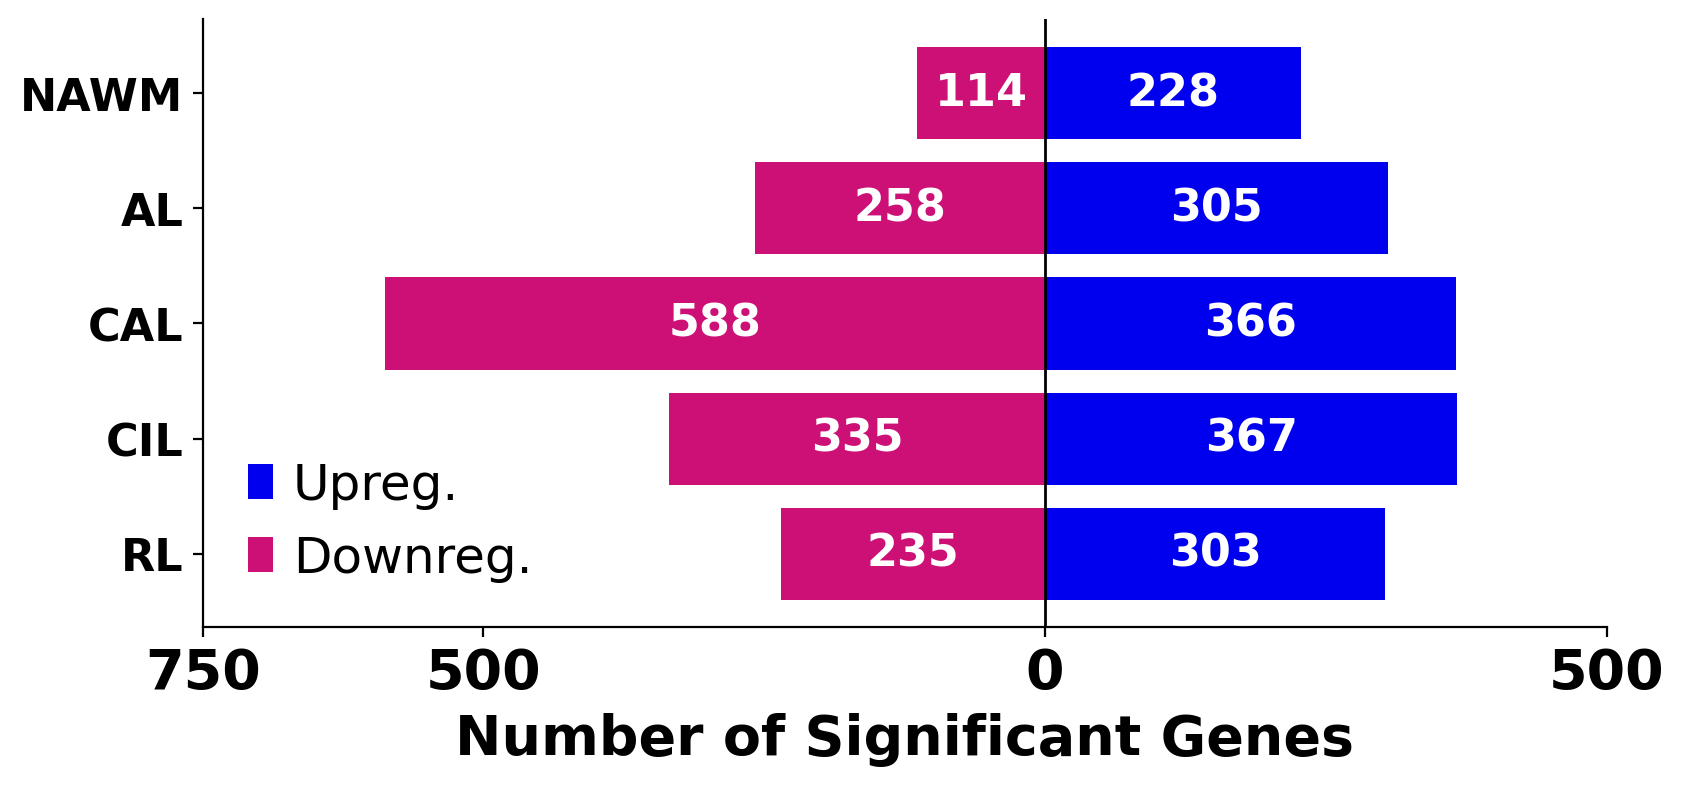

In [24]:
# Data
conditions = ["NAWM", "AL", "CAL", "CIL", "RL"]

up_genes = np.array([228, 305, 366, 367, 303])
down_genes = np.array([-114, -258, -588, -335, -235])  # negative for left alignment

# Reverse all data
conditions = conditions[::-1]
up_genes = up_genes[::-1]
down_genes = down_genes[::-1]

# Bar width (increased) and figure size (shorter height)
bar_width = 0.8
fig, ax = plt.subplots(figsize=(9, 4))  # Reduce height to save space

# Plot downregulated genes (left side)
bars_down = ax.barh(
    conditions,
    down_genes,
    color='#CD1076',
    label="Downregulated Genes",
    height=bar_width
)

# Plot upregulated genes (right side)
bars_up = ax.barh(
    conditions,
    up_genes,
    color='#0000EE',
    label="Upregulated Genes",
    height=bar_width
)

# Add number labels (always white)
for bar, value in zip(bars_down, down_genes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(abs(value)),
        ha='center',
        va='center',
        color='white',
        fontsize=16,           # bigger number labels
        fontweight='bold'
    )

for bar, value in zip(bars_up, up_genes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        ha='center',
        va='center',
        color='white',
        fontsize=16,           # bigger number labels
        fontweight='bold'
    )

# Formatting axis labels and ticks
ax.set_yticks(np.arange(len(conditions)))
ax.set_yticklabels(conditions, fontsize=16, fontweight='bold')  # Bigger Y tick labels
ax.set_xlabel("Number of Significant Genes", fontsize=20, fontweight='bold')  # Bigger X label

# Adjust x-axis to show only -1000, -500, 0, 500, 1000
ax.set_xticks([-750, -500, 0, 500])
ax.set_xticklabels([750, 500, 0, 500], fontsize=20, fontweight='bold')  # Bigger X tick labels

ax.axvline(0, color='black', linewidth=1)  # Zero line

# Remove right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Remove grid lines
ax.grid(False)

# Properly reorder the legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    [handles[1], handles[0]],
    ["Upreg.", "Downreg."],
    loc="lower left",
    fontsize=18,          # Bigger legend text
    frameon=False         # Cleaner look
)

# Save the plot
plt.savefig("./human_MG_DEG_bar_chart_GLMM_full_updated.png", dpi=300, bbox_inches='tight')

# Show plot
plt.show()

# Upset plots

In [25]:
from upsetplot import plot
from upsetplot import from_contents
from upsetplot import UpSet

In [26]:
print(len(MOL_NAWM))
print(len(MOL_AL))
print(len(MOL_CAL))
print(len(MOL_CIL))
print(len(MOL_RL))

8739
10675
10749
9491
9714


In [ ]:
## IMPORTANT FILTER FOR GENES TESTING IN ALL CONDITIONS

genes_all_conditions = (
    set(MOL_NAWM['gene'])
    & set(MOL_AL['gene'])
    & set(MOL_RL['gene'])
    & set(MOL_CAL['gene'])
    & set(MOL_CIL['gene'])
)

In [ ]:
len(genes_all_conditions)

In [ ]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene'].isin(genes_all_conditions)]

# Apply filtering to each DEG DataFrame
MOL_NAWM_up = filter_genes(MOL_NAWM_up)
MOL_AL_up = filter_genes(MOL_AL_up)
MOL_CAL_up = filter_genes(MOL_CAL_up)
MOL_CIL_up = filter_genes(MOL_CIL_up)
MOL_RL_up = filter_genes(MOL_RL_up)

print(MOL_NAWM_up.shape)
print(MOL_AL_up.shape)
print(MOL_CAL_up.shape)
print(MOL_CIL_up.shape)
print(MOL_RL_up.shape)

In [27]:
# Create gene lists for each condition
genes_NAWM_up = MOL_NAWM_up['gene'].tolist()
genes_AL_up = MOL_AL_up['gene'].tolist()
genes_CAL_up = MOL_CAL_up['gene'].tolist()
genes_CIL_up = MOL_CIL_up['gene'].tolist()
genes_RL_up = MOL_RL_up['gene'].tolist()

# Define a helper function to create DataFrames with a True flag
def create_gene_df(genes_list, label):
    """
    Create a DataFrame with a column indicating presence in this list
    and a column with gene names.
    """
    return pd.DataFrame({
        label: True,
        'Gene': genes_list
    })

# Create individual DataFrames
NAWM_up_df = create_gene_df(genes_NAWM_up, 'NAWM_up')
AL_up_df = create_gene_df(genes_AL_up, 'AL_up')
CAL_up_df = create_gene_df(genes_CAL_up, 'CAL_up')
CIL_up_df = create_gene_df(genes_CIL_up, 'CIL_up')
RL_up_df = create_gene_df(genes_RL_up, 'RL_up')

In [28]:
# Hierarchically merge all the DataFrames on 'Gene'
up_df = NAWM_up_df.merge(
    AL_up_df.merge(
        CAL_up_df.merge(
            CIL_up_df.merge(
                RL_up_df, on='Gene', how='outer'
            ), on='Gene', how='outer'
        ), on='Gene', how='outer'
    ), on='Gene', how='outer'
)

# Replace NaN with False
up_df = up_df.fillna(False)

# Set 'Gene' as the index (optional, but useful for plotting)
up_df_plot = up_df.set_index([
    'NAWM_up', 'AL_up', 'CAL_up', 'CIL_up', 'RL_up'
])

# Print the final merged DataFrame
print("Upregulated genes across all conditions (hierarchically merged):")
print(up_df_plot)

Upregulated genes across all conditions (hierarchically merged):
                                      Gene
NAWM_up AL_up CAL_up CIL_up RL_up         
True    False False  True   True     ABCA1
False   True  False  False  False    ABCC2
        False False  True   False    ABCC3
              True   False  False    ABCF3
              False  False  True   ABHD17C
...                                    ...
              True   False  False   ZNF549
                            False   ZNF586
              False  False  True    ZNF704
True    True  True   True   False  ZNF804A
                            False      ZYX

[961 rows x 1 columns]


/tmp/2310260.1.long/ipykernel_385997/575165265.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  up_df = up_df.fillna(False)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

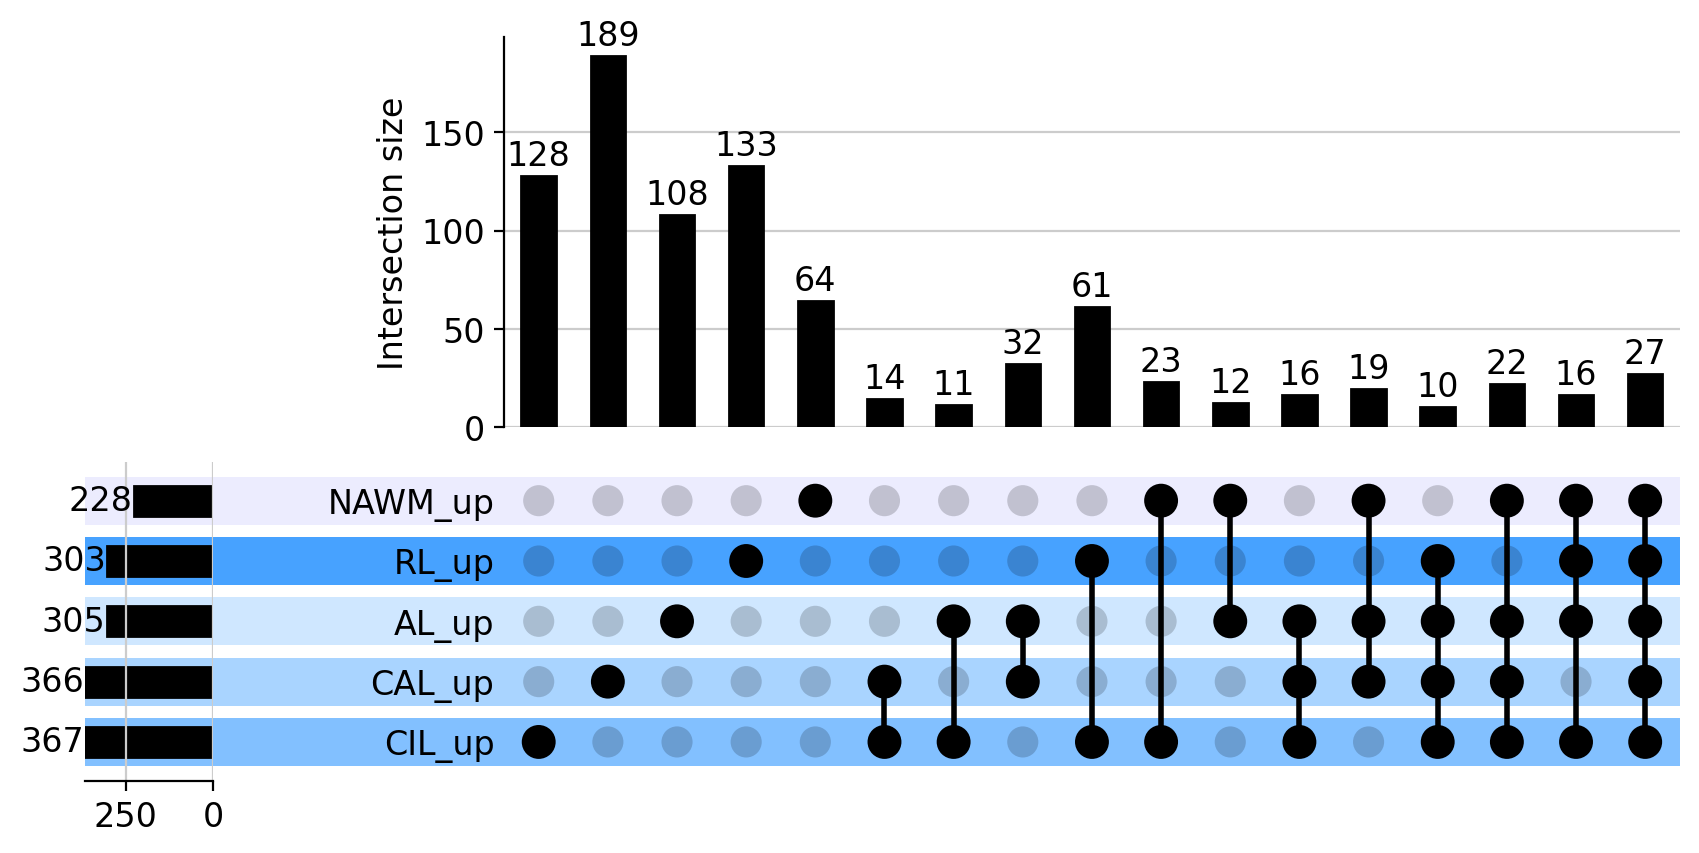

In [30]:
# Create UpSet plot
upset = UpSet(up_df_plot, subset_size='count', show_counts=True, facecolor="black", min_subset_size = 10)

# Style the subsets
upset.style_categories(
    'NAWM_up',
    shading_facecolor="#ececfe",
)

# Style the subsets
upset.style_categories(
    'AL_up',
    shading_facecolor="#cfe7ff",
)

# Style the subsets
upset.style_categories(
    'CAL_up',
    shading_facecolor="#a9d4ff",
)

# Style the subsets
upset.style_categories(
    'CIL_up',
    shading_facecolor="#82c0ff",
)

# Style the subsets
upset.style_categories(
    'RL_up',
    shading_facecolor="#47a2ff",
)

# Plot the UpSet plot
upset.plot()
plt.suptitle("")

# Save the plot as PDF
plt.savefig('./figures/hs_MG_upset_plot_up_n5_glmm.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [40]:
# Create sets
set_NAWM_up = set(genes_NAWM_up)
set_AL_up = set(genes_AL_up)
set_CAL_up = set(genes_CAL_up)
set_CIL_up = set(genes_CIL_up)
set_RL_up = set(genes_RL_up)

In [41]:
genes_common_up = set_NAWM_up & set_AL_up & set_CAL_up & set_CIL_up & set_RL_up
length_common_up = len(genes_common_up)

print(length_common_up)

# Convert to a comma-separated string
genes_common_up_str = ', '.join(genes_common_up)

# Print the result
print(genes_common_up_str)

27
CRTC3, ST14, CD163, F13A1, PLXND1, ADGRG6, FAM107A, CD163L1, CDK14, RGL1, MCTP1, PLXNC1, SELENOP, LINC01146, SHMT2, POLR2F, ITGA4, STARD13, GFAP, CDK18, AP002991.1, ALDH1A2, SORCS2, AP001636.3, TRHDE, RTN1, CLEC5A


In [42]:
genes_AL_CAL = set_AL_up & set_CAL_up - set_NAWM_up - set_CIL_up - set_RL_up
lenght = len(genes_AL_CAL)

print(lenght)
print(genes_AL_CAL)

32
{'NR1H3', 'YARS', 'TGFA', 'STIP1', 'CTSZ', 'SH3RF1', 'RUVBL2', 'CDK2AP2', 'ENGASE', 'PDIA4', 'CASP7', 'GHDC', 'CPAMD8', 'CASP5', 'PPP1R14B', 'STEAP3', 'AP4B1', 'CCT3', 'CASP1', 'IDH1', 'CERS6', 'CLIC2', 'DRAM1', 'AC004540.1', 'MCU', 'SIRT6', 'DNTTIP2', 'MRPL18', 'NUDC', 'TUBA1C', 'HMOX1', 'SUGT1'}


In [43]:
genes_RL_CIL = set_RL_up & set_CIL_up - set_NAWM_up - set_CAL_up - set_AL_up
lenght = len(genes_RL_CIL)

print(lenght)
print(genes_RL_CIL)

61
{'SH3BP5', 'ISG20', 'FGR', 'PLIN2', 'MACC1', 'MEGF9', 'SH3PXD2B', 'SOCS3', 'SFXN3', 'CLU', 'CDK2', 'MAMLD1', 'NAMPT', 'ADGRE2', 'METRNL', 'IL4R', 'SECTM1', 'FYN', 'DISP1', 'IFITM2', 'GLIPR2', 'FOSL2', 'THBD', 'AGTRAP', 'ALOX15B', 'PGS1', 'ST18', 'RAPGEF4', 'VDR', 'GFOD1', 'CCDC170', 'NOD2', 'ZDHHC18', 'RHOU', 'PDK4', 'AQP9', 'AC021594.2', 'TMEM236', 'PYGL', 'AKAP6', 'ATP2B4', 'CD93', 'INF2', 'IL18R1', 'PWRN1', 'SRGAP1', 'APOLD1', 'TBC1D14', 'SEL1L3', 'PAM', 'CREB5', 'PRKCE', 'CEMIP2', 'SMIM3', 'MS4A4A', 'CD72', 'ZBTB16', 'AHI1', 'SLC16A10', 'SDC3', 'SLA'}


### Now down

In [ ]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene'].isin(genes_all_conditions)]

# Apply filtering to each DEG DataFrame
MOL_NAWM_down = filter_genes(MOL_NAWM_down)
MOL_AL_down = filter_genes(MOL_AL_down)
MOL_CAL_down = filter_genes(MOL_CAL_down)
MOL_CIL_down = filter_genes(MOL_CIL_down)
MOL_RL_down = filter_genes(MOL_RL_down)

print(MOL_NAWM_down.shape)
print(MOL_AL_down.shape)
print(MOL_CAL_down.shape)
print(MOL_CIL_down.shape)
print(MOL_RL_down.shape)

In [35]:
# Create gene lists for each condition
genes_NAWM_down = MOL_NAWM_down['gene'].tolist()
genes_AL_down = MOL_AL_down['gene'].tolist()
genes_CAL_down = MOL_CAL_down['gene'].tolist()
genes_CIL_down = MOL_CIL_down['gene'].tolist()
genes_RL_down = MOL_RL_down['gene'].tolist()

# Define a helper function to create DataFrames with a True flag
def create_gene_df(genes_list, label):
    """
    Create a DataFrame with a column indicating presence in this list
    and a column with gene names.
    """
    return pd.DataFrame({
        label: True,
        'Gene': genes_list
    })

# Create individual DataFrames
NAWM_down_df = create_gene_df(genes_NAWM_down, 'NAWM_down')
AL_down_df = create_gene_df(genes_AL_down, 'AL_down')
CAL_down_df = create_gene_df(genes_CAL_down, 'CAL_down')
CIL_down_df = create_gene_df(genes_CIL_down, 'CIL_down')
RL_down_df = create_gene_df(genes_RL_down, 'RL_down')

In [36]:
# Hierarchically merge all the DataFrames on 'Gene'
down_df = NAWM_down_df.merge(
    AL_down_df.merge(
        CAL_down_df.merge(
            CIL_down_df.merge(
                RL_down_df, on='Gene', how='outer'
            ), on='Gene', how='outer'
        ), on='Gene', how='outer'
    ), on='Gene', how='outer'
)

# Replace NaN with False
down_df = down_df.fillna(False)

# Set 'Gene' as the index (optional, but useful for plotting)
down_df_plot = down_df.set_index([
    'NAWM_down', 'AL_down', 'CAL_down', 'CIL_down', 'RL_down'
])

# Print the final merged DataFrame
print("Downregulated genes across all conditions (hierarchically merged):")
print(down_df_plot)

Downregulated genes across all conditions (hierarchically merged):
                                               Gene
NAWM_down AL_down CAL_down CIL_down RL_down        
False     False   False    True     True        A2M
                           False    True      ABCB4
          True    True     True     True      ABCC4
          False   False    True     False    ABHD11
                  True     False    False      ABI1
...                                             ...
          True    True     True     False    ZNF711
          False   True     False    False    ZNF821
                                    False    ZNF846
                                    False     ZNRF2
          True    False    False    False    ZSWIM6

[932 rows x 1 columns]


/tmp/2310260.1.long/ipykernel_385997/2996960993.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  down_df = down_df.fillna(False)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

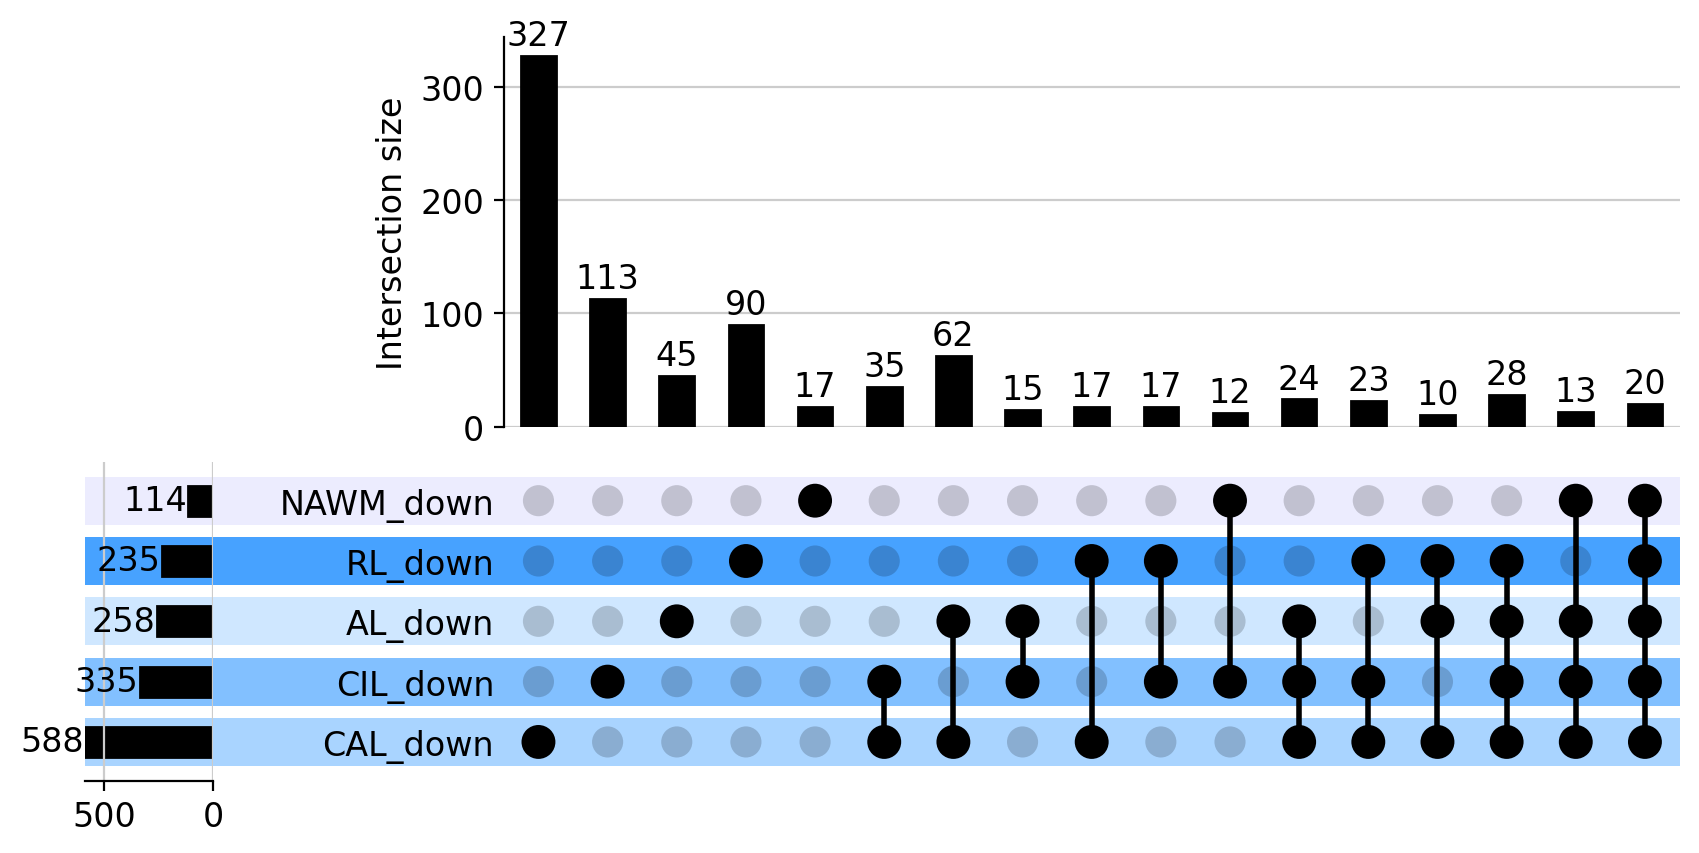

In [39]:
# Create UpSet plot
upset = UpSet(down_df_plot, subset_size='count', show_counts=True, facecolor="black", min_subset_size=10)

# Style the subsets
upset.style_categories(
    'NAWM_down',
    shading_facecolor="#ececfe",
)

# Style the subsets
upset.style_categories(
    'AL_down',
    shading_facecolor="#cfe7ff",
)

# Style the subsets
upset.style_categories(
    'CAL_down',
    shading_facecolor="#a9d4ff",
)

# Style the subsets
upset.style_categories(
    'CIL_down',
    shading_facecolor="#82c0ff",
)

# Style the subsets
upset.style_categories(
    'RL_down',
    shading_facecolor="#47a2ff",
)

# Plot the UpSet plot
upset.plot()
plt.suptitle("")

# Save the plot as PDF
plt.savefig('./figures/hs_MG_upset_plot_down_n8_glmm.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [44]:
# Create sets
set_NAWM_down = set(genes_NAWM_down)
set_AL_down = set(genes_AL_down)
set_CAL_down = set(genes_CAL_down)
set_CIL_down = set(genes_CIL_down)
set_RL_down = set(genes_RL_down)

In [45]:
genes_common_down = set_NAWM_down & set_AL_down & set_CAL_down & set_CIL_down & set_RL_down
length = len(genes_common_down)

print(length)

# Convert to a comma-separated string
genes_common_down_str = ', '.join(genes_common_down)

# Print the result
print(genes_common_down_str)

20
AP003481.1, ITGB7, CLEC9A, OTULINL, TNFRSF13C, RASGEF1C, TMEM156, PRDM11, CACNB2, AC008691.1, ADGRG5, BANK1, RGS6, CCDC136, TANC1, AC118754.1, AC022509.2, PAQR5, C12orf75, SYNDIG1


In [46]:
genes_AL_CAL = set_CAL_down & set_AL_down - set_CIL_down - set_RL_down - set_NAWM_down
lenght = len(genes_AL_CAL)

print(lenght)
print(genes_AL_CAL)

62
{'CCDC122', 'UBR5-AS1', 'SRGAP2', 'FDFT1', 'HGSNAT', 'AC145124.1', 'HTRA1', 'TTC7A', 'ADAMTS10', 'DDB2', 'RIN2', 'PTPN13', 'FAM117B', 'PDE9A', 'IGF1', 'AC116667.1', 'TRIM22', 'ZFP36L2', 'ADAM28', 'AL365273.2', 'PCNX2', 'SRC', 'FADS1', 'KLHL5', 'ENTPD1', 'CCDC146', 'AC244453.3', 'MDM2', 'SRGAP2C', 'GPANK1', 'NLRP3', 'PIH1D1', 'STARD4', 'MNDA', 'DOCK4', 'TRANK1', 'NAA40', 'AL078590.3', 'PMEPA1', 'FRMD4A', 'GSTM4', 'ITM2C', 'WDR91', 'P2RY13', 'ANKRD44', 'ANGEL1', 'PSRC1', 'MACO1', 'FAM78A', 'SEMA3C', 'ATP8B4', 'MYO18A', 'ZMAT3', 'STARD4-AS1', 'AC005699.1', 'OR52K1', 'VCL', 'HEATR5B', 'NEK3', 'ZEB1', 'EPSTI1', 'NIPSNAP3B'}


In [47]:
genes_RL_CIL = set_RL_down & set_CIL_down - set_AL_down - set_CAL_down - set_NAWM_down
lenght = len(genes_RL_CIL)

print(lenght)
print(genes_RL_CIL)

17
{'AC002480.1', 'LRRK1', 'HSPA1B', 'A2M', 'ITIH5', 'SORL1', 'HS3ST4', 'TOMM7', 'DSCAM', 'IL6ST', 'GAL3ST4', 'PNMA5', 'ZNF689', 'S100A13', 'NCKAP1', 'CD274', 'HSPA1A'}


# Visualize CPM across conditions

In [47]:
adata_pb = sc.read('./pb_adata_MG_noPVM.h5ad')
adata_pb

AnnData object with n_obs × n_vars = 105 × 29040
    obs: 'sample', 'sample_lesion', 'diagnosis', 'sample_source', 'cell_type', 'sample_rep', 'replicate_cat', 'stim', 'sex', 'seq_pool', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'batch', 'lib_size', 'log_lib_size'
    uns: 'age_cat_colors', 'cell_type_colors', 'diagnosis_colors', 'log1p', 'pca', 'pmi_cat2_colors', 'pmi_cat_colors', 'sample_source_colors', 'seq_pool_colors', 'sex_colors', 'stim_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [48]:
print(f"All samples: {adata_pb.shape[0]}")

# Extract the data as a pandas DataFrame
df = adata_pb.obs[['cell_type', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)
summary_table

All samples: 105


/tmp/2208807.1.long/ipykernel_3941917/3029160791.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)


stim,AL,CAL,CIL,NAWM,RL,WM
cell_type,,,,,,
Mg,21,17,13,15,11,12
PVM,5,3,2,2,4,0


In [49]:
adata_sub= adata_pb[np.in1d(adata_pb.obs['cell_type'], 
                           ['Mg'])].copy()

print("Dimensions of adata_sub:", adata_sub.shape)

Dimensions of adata_sub: (89, 29040)


In [50]:
# Check if the 'sample_rep' column exists
if 'sample_lesion' in adata_sub.obs.columns:
    # Set the 'sample_rep' column as the index
    adata_sub.obs.set_index('sample_lesion', inplace=True)
else:
    print("The column 'sample' does not exist in adata_sub.obs.")

adata_sub.obs.index.name = None

In [51]:
# Add the index back as a column called 'sample_lesion'
adata_sub.obs['sample_lesion'] = adata_sub.obs.index

In [52]:
# Replace space with underscore in the 'seq_pool' column
adata_sub.obs['seq_pool'] = adata_sub.obs['seq_pool'].str.replace(' ', '_')

In [53]:
adata_sub.obs['indiv_id'] = adata_sub.obs['sample'].str.split('-').str[0]
adata_sub.obs[:5]

,sample,diagnosis,sample_source,cell_type,sample_rep,replicate_cat,stim,sex,seq_pool,age_scale,age_cat,pmi_cat,pmi_cat2,batch,lib_size,log_lib_size,sample_lesion,indiv_id
Ind98-Sample2_WM,Ind98-Sample2,CTR,Edinburgh BB,Mg,WM_1,1,WM,M,Pool_6,-1.759706,under_50,over_12H,over_12H,0,394287,12.884834,Ind98-Sample2_WM,Ind98
Ind101-Sample1_CIL,Ind101-Sample1,SPMS,UK MS TB,Mg,CIL_1,1,CIL,F,Pool_5,0.645037,inbetween,over_12H,over_12H,0,119636,11.692209,Ind101-Sample1_CIL,Ind101
Ind101-Sample2_CIL,Ind101-Sample2,SPMS,UK MS TB,Mg,CIL_2,2,CIL,F,Pool_3,0.645037,inbetween,over_12H,over_12H,0,395710,12.888437,Ind101-Sample2_CIL,Ind101
Ind101-Sample3_RL,Ind101-Sample3,SPMS,UK MS TB,Mg,RL_1,1,RL,F,Pool_1,0.645037,inbetween,over_12H,over_12H,0,181378,12.108339,Ind101-Sample3_RL,Ind101
Ind102-Sample1_AL,Ind102-Sample1,SPMS,Amsterdam BB,Mg,AL_1,1,AL,M,Pool_4,0.301502,inbetween,6H_to_12H,up_to_12H,0,491082,13.104366,Ind102-Sample1_AL,Ind102


In [54]:
adata_sub.obs['cell_stim'] = adata_sub.obs['cell_type'].astype(str) + '_' + adata_sub.obs['stim'].astype(str)

In [55]:
# Extract the data as a pandas DataFrame
df = adata_sub.obs[['cell_stim', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_stim', 'stim']).size().unstack(fill_value=0)
summary_table

/tmp/2208807.1.long/ipykernel_3941917/2450846806.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df.groupby(['cell_stim', 'stim']).size().unstack(fill_value=0)


stim,AL,CAL,CIL,NAWM,RL,WM
cell_stim,,,,,,
Mg_AL,21,0,0,0,0,0
Mg_CAL,0,17,0,0,0,0
Mg_CIL,0,0,13,0,0,0
Mg_NAWM,0,0,0,15,0,0
Mg_RL,0,0,0,0,11,0
Mg_WM,0,0,0,0,0,12


/tmp/2208807.1.long/ipykernel_3941917/2109590283.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


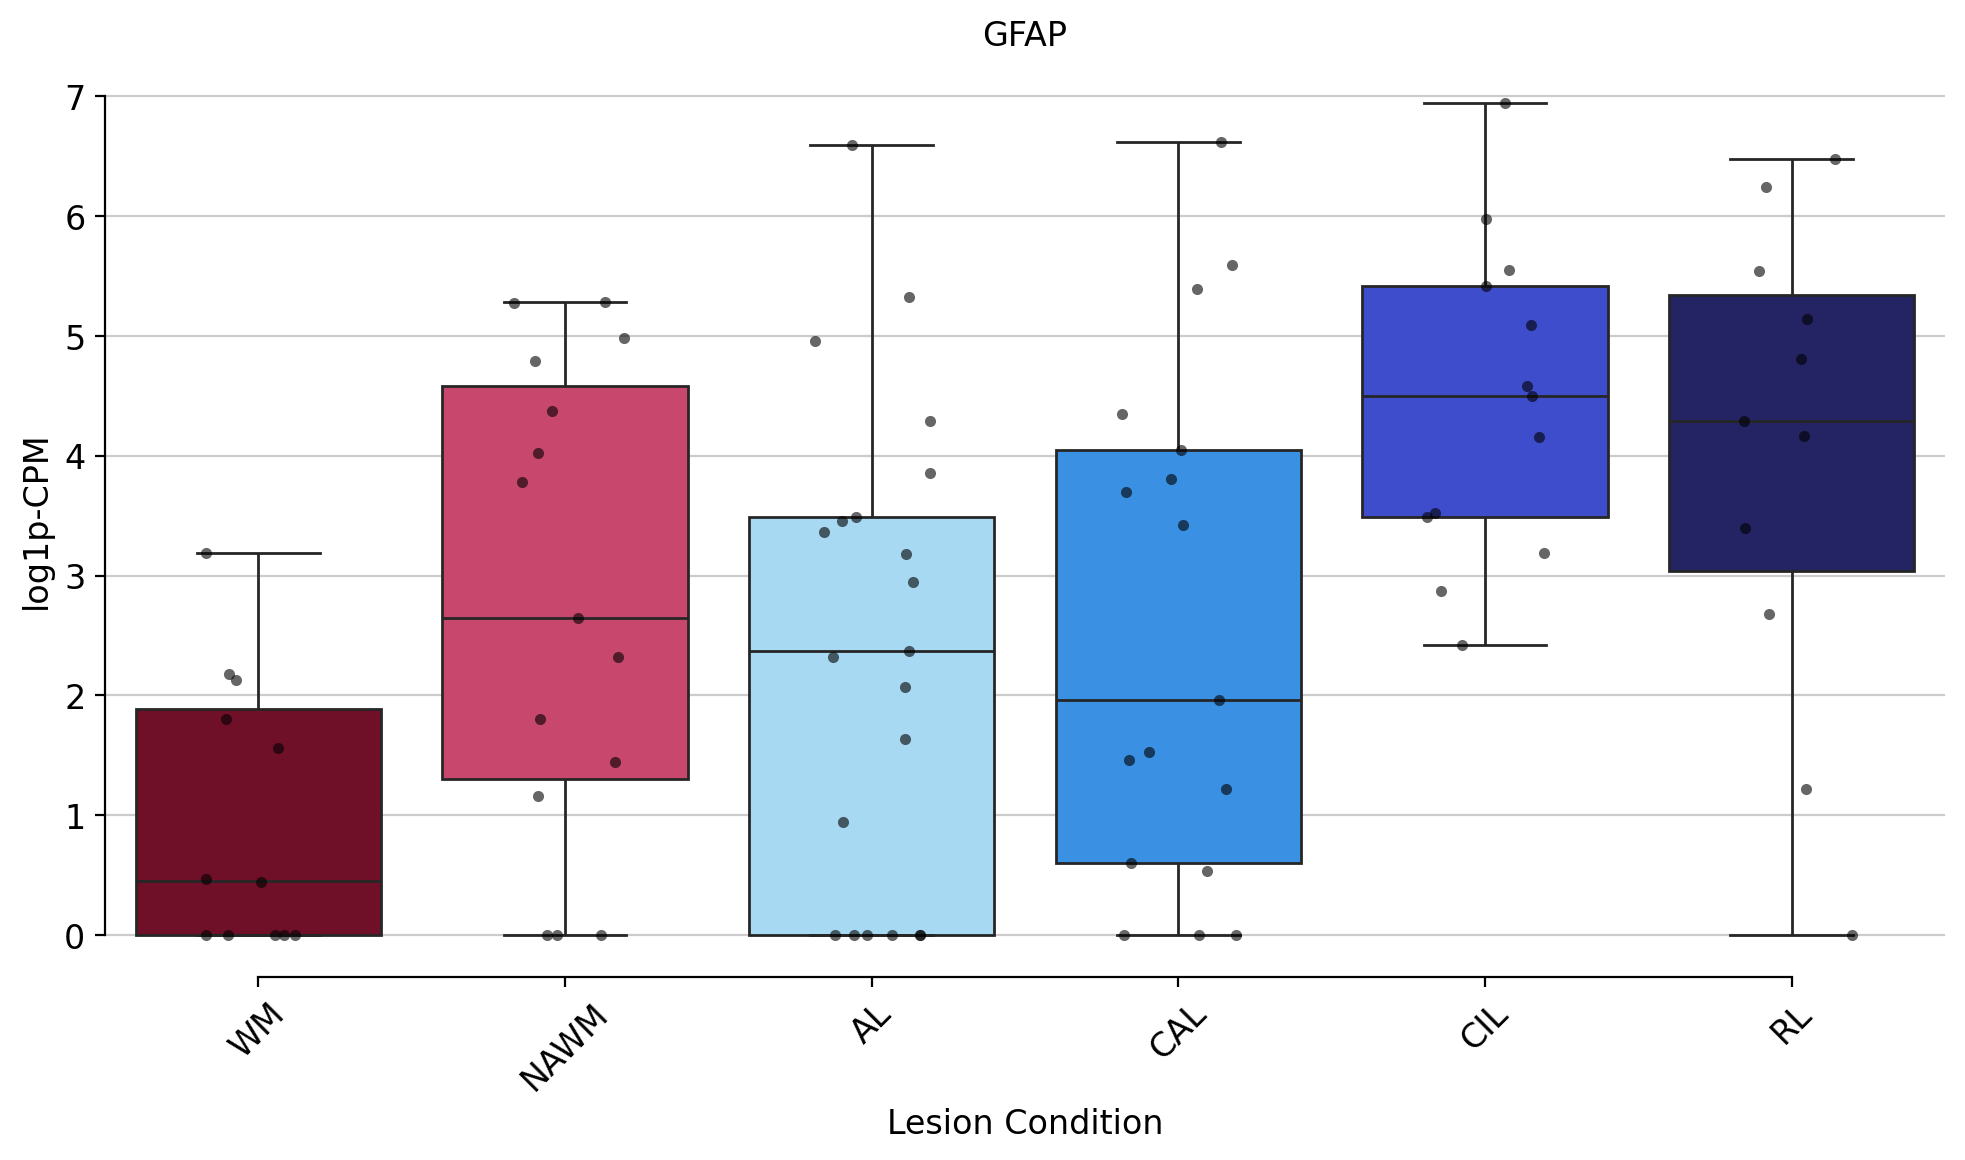

In [56]:
import seaborn as sns

# Specify your gene
gene_to_plot = "GFAP"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}

custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]

plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"{gene_to_plot}")
plt.ylabel("log1p-CPM")
plt.xlabel("Lesion Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

/tmp/2208807.1.long/ipykernel_3941917/1113644518.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


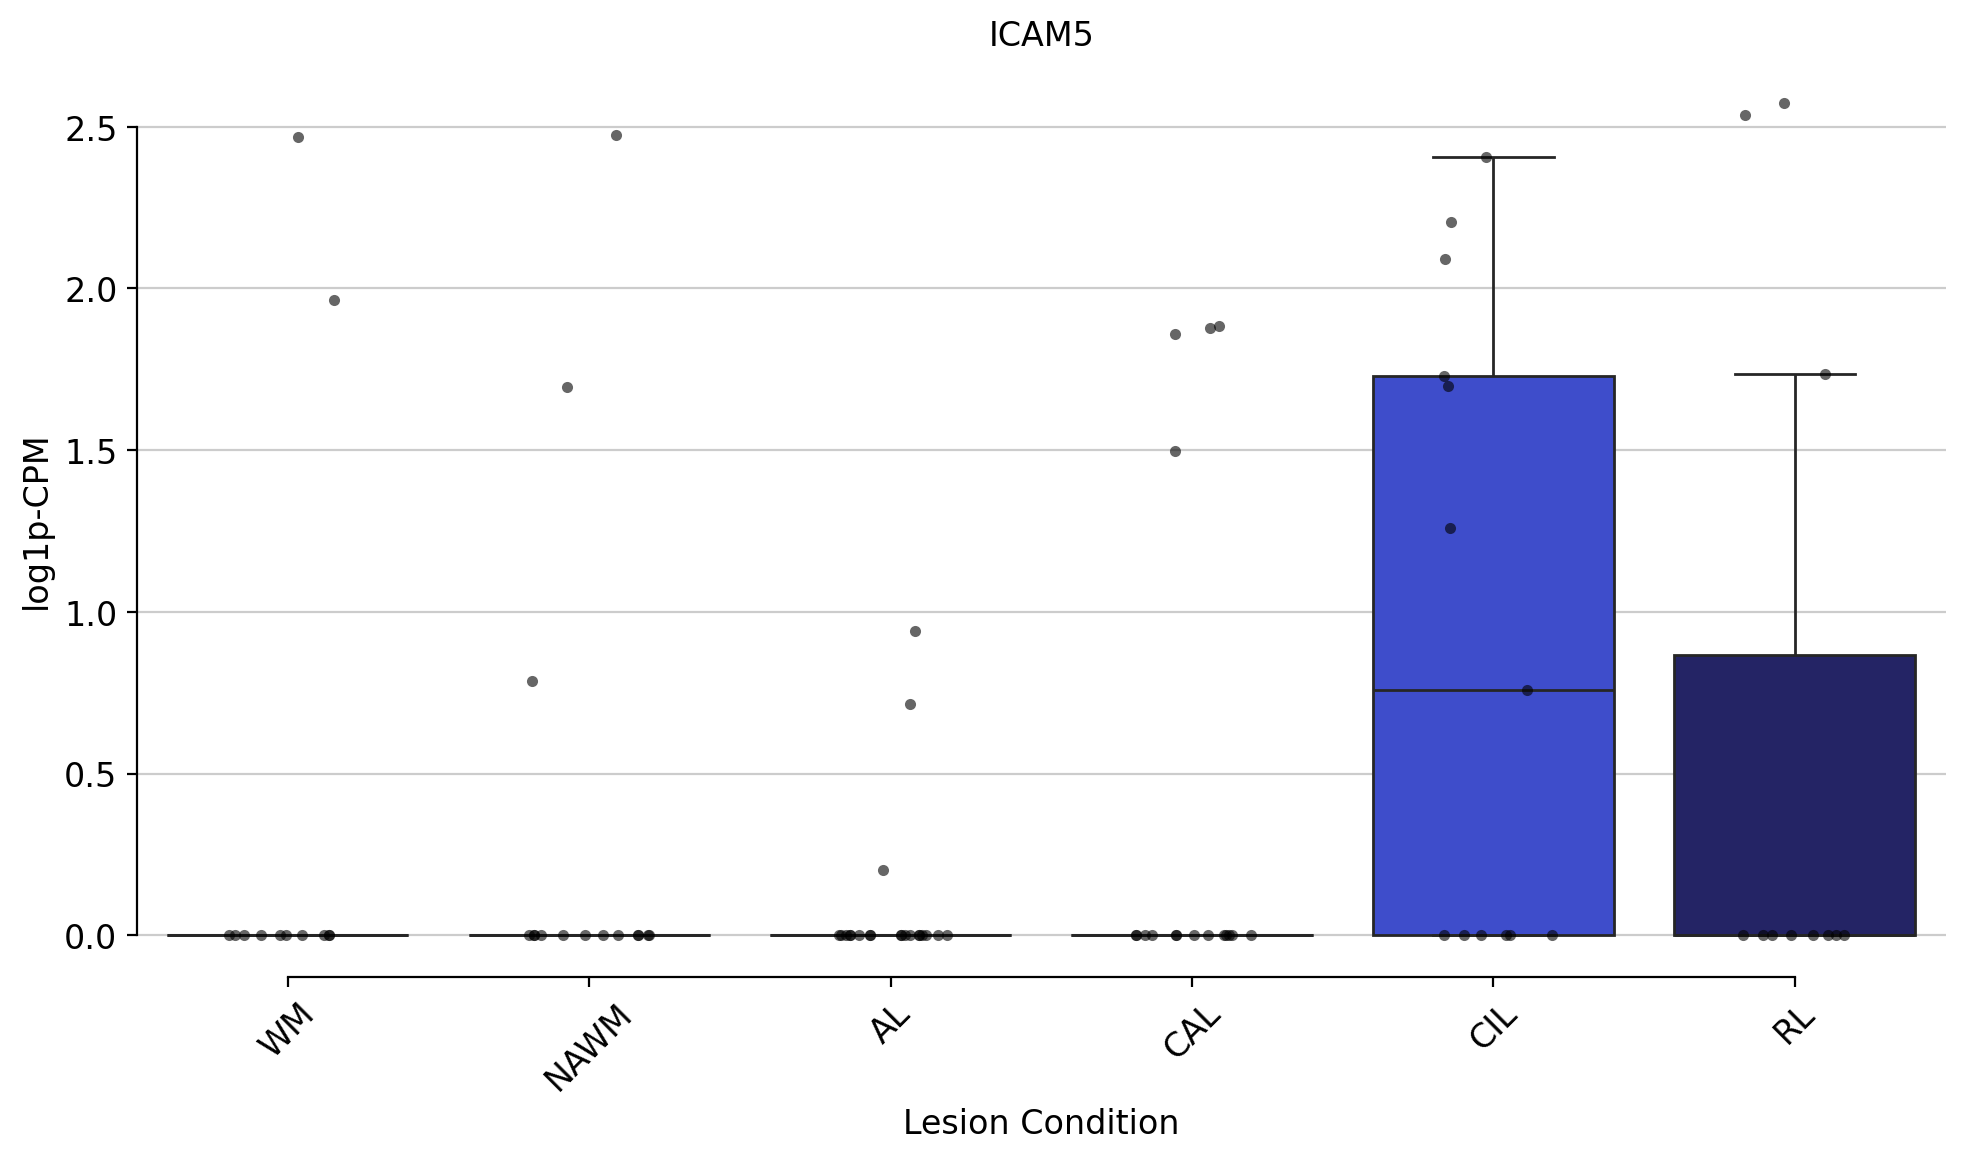

In [57]:
import seaborn as sns

# Specify your gene
gene_to_plot = "ICAM5"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}

custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]

plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"{gene_to_plot}")
plt.ylabel("log1p-CPM")
plt.xlabel("Lesion Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

# Combine the dfs

In [58]:
# Step 1: Rename relevant columns in each DataFrame to prepare for merge
def prepare_df(df, label):
    df = df[['gene', 'logFC', 'FDR']].copy()
    df.rename(columns={
        'logFC': f'logFC_{label}',
        'FDR': f'FDR_{label}'
    }, inplace=True)
    return df

# Apply the preparation
df_NAWM = prepare_df(MOL_NAWM, 'NAWM')
df_AL   = prepare_df(MOL_AL, 'AL')
df_CAL  = prepare_df(MOL_CAL, 'CAL')
df_CIL  = prepare_df(MOL_CIL, 'CIL')
df_RL   = prepare_df(MOL_RL, 'RL')

# Step 2: Merge all dataframes on 'gene'
from functools import reduce

dfs = [df_NAWM, df_AL, df_CAL, df_CIL, df_RL]
combined_df = reduce(lambda left, right: pd.merge(left, right, on='gene', how='outer'), dfs)

# Step 3: Check the result
print(combined_df.shape)
combined_df.head()

(13029, 11)


,gene,logFC_NAWM,FDR_NAWM,logFC_AL,FDR_AL,logFC_CAL,FDR_CAL,logFC_CIL,FDR_CIL,logFC_RL,FDR_RL
0,A1BG,0.781247,0.271213,0.829288,0.128626,0.456509,0.570989,0.539465,0.414327,0.211053,0.856082
1,A1BG-AS1,0.890775,0.154784,NaN,NaN,0.385819,0.677134,1.508447,0.068035,0.713026,0.356417
2,A2M,-0.200306,0.552444,-0.327187,0.374407,-0.647658,0.063148,-0.827091,0.000542,-0.931266,0.019102
3,A2ML1-AS1,-0.117251,0.867215,-0.852691,0.281284,-0.638992,0.472324,-0.374010,0.509140,0.451006,0.429793
4,A3GALT2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.647666,0.120722


In [59]:
# Before filtering: shape
print("Before filtering:", combined_df.shape)

# Identify all FDR columns
fdr_columns = [col for col in combined_df.columns if col.startswith("FDR_")]

# Create a boolean mask: True if ANY FDR column < 0.05
significant_mask = (combined_df[fdr_columns] < 0.05).any(axis=1)

# Filter the DataFrame
filtered_df = combined_df[significant_mask].copy()

# After filtering: shape
print("After filtering:", filtered_df.shape)

Before filtering: (13029, 11)
After filtering: (2919, 11)


In [ ]:
#filtered_df.to_csv("./files/combined_df_glmm_full_sig_genes.csv", index=False)

# Orthos

In [19]:
# Read the CSV file
mart = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single/mart_export_unique.txt')

# Rename the columns
mart = mart.rename(columns={
    'Gene stable ID': 'eid_hs',
    'Gene name': 'gene_hs',
    'Mouse gene stable ID': 'eid_mm',
    'Mouse gene name': 'gene_mm'
})

# Optionally, display the first few rows to check the data
print(mart.head())

length_of_mart = len(mart)
print(f"The length of the mart DataFrame is: {length_of_mart}")

            eid_hs  gene_hs              eid_mm  gene_mm
0  ENSG00000198888   MT-ND1  ENSMUSG00000064341   mt-Nd1
1  ENSG00000198763   MT-ND2  ENSMUSG00000064345   mt-Nd2
2  ENSG00000198804   MT-CO1  ENSMUSG00000064351   mt-Co1
3  ENSG00000198712   MT-CO2  ENSMUSG00000064354   mt-Co2
4  ENSG00000228253  MT-ATP8  ENSMUSG00000064356  mt-Atp8
The length of the mart DataFrame is: 25768


In [20]:
# One to one orthologues - dont have same mm/hs gene in the table 2x
oto_orthologues=mart[~mart.duplicated('eid_mm',keep=False).values & 
               ~mart.duplicated('eid_hs',keep=False).values]

length_of_mart = len(oto_orthologues)
print(f"The length of the mart DataFrame is: {length_of_mart}")

The length of the mart DataFrame is: 17140


In [21]:
# Optionally, display the first few rows to check the data
print(oto_orthologues.head())

            eid_hs  gene_hs              eid_mm  gene_mm
0  ENSG00000198888   MT-ND1  ENSMUSG00000064341   mt-Nd1
1  ENSG00000198763   MT-ND2  ENSMUSG00000064345   mt-Nd2
2  ENSG00000198804   MT-CO1  ENSMUSG00000064351   mt-Co1
3  ENSG00000198712   MT-CO2  ENSMUSG00000064354   mt-Co2
4  ENSG00000228253  MT-ATP8  ENSMUSG00000064356  mt-Atp8


In [22]:
MOL_NAWM

,gene,logFC_WM,se,pvalue,convergence,pdHess,logLik,AIC,error,FDR,status,logFC
0,HIST2H2BE,1.329526,0.190164,2.720480e-12,0,True,-105.234605,228.469210,NaN,5.300403e-09,OK,-1.329526
1,DOCK8,0.448478,0.063227,1.311491e-12,0,True,-189.821991,397.643982,NaN,5.300403e-09,OK,-0.448478
2,CGNL1,2.221592,0.317313,2.536592e-12,0,True,-109.969268,237.938537,NaN,5.300403e-09,OK,-2.221592
3,STARD13,-1.101068,0.166795,4.074953e-11,0,True,-168.994648,355.989296,NaN,6.805172e-08,OK,1.101068
4,PKN2,0.313100,0.047920,6.410276e-11,0,True,-146.238449,310.476898,NaN,8.551626e-08,OK,-0.313100
...,...,...,...,...,...,...,...,...,...,...,...,...
8734,GDPD1,-0.000530,0.169121,9.975016e-01,0,True,-85.342273,188.684547,NaN,9.997821e-01,OK,0.000530
8735,ASPSCR1,0.000056,0.114752,9.996110e-01,0,True,-90.508643,199.017287,NaN,9.997821e-01,OK,-0.000056
8736,SLX4IP,-0.000082,0.112583,9.994168e-01,0,True,-127.449168,272.898335,NaN,9.997821e-01,OK,0.000082
8737,RANBP1,-0.000140,0.198527,9.994379e-01,0,True,-79.658746,177.317491,NaN,9.997821e-01,OK,0.000140


In [23]:
# Merge the dataframes
MOL_NAWM = MOL_NAWM.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_hs',
                      how='left')

# Select only the desired columns and rename if necessary
MOL_NAWM = MOL_NAWM[['gene', 'gene_hs', 'gene_mm', 'logFC', 'FDR']]
MOL_NAWM['logFC'] = MOL_NAWM['logFC'].astype(float)
MOL_NAWM['FDR'] = MOL_NAWM['FDR'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = MOL_NAWM['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {MOL_NAWM.shape}")
MOL_NAWM = MOL_NAWM.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {MOL_NAWM.shape}")

The number of NaN values in the 'gene_hs' column is: 1980
Shape with NaN: (8739, 5)
Shape after trimming: (6759, 5)


In [24]:
# Filter for upregulated genes
MOL_NAWM_up = MOL_NAWM[(MOL_NAWM.FDR < 0.05) & (MOL_NAWM.logFC >= 0.585)]
print(MOL_NAWM_up.shape)

# Filter for downregulated genes
MOL_NAWM_down = MOL_NAWM[(MOL_NAWM.FDR < 0.05) & (MOL_NAWM.logFC <= -0.585)]
print(MOL_NAWM_down.shape)

(191, 5)
(69, 5)


In [25]:
# Merge the dataframes
MOL_AL = MOL_AL.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_hs',
                      how='left')

# Select only the desired columns and rename if necessary
MOL_AL = MOL_AL[['gene', 'gene_hs', 'gene_mm', 'logFC', 'FDR']]
MOL_AL['logFC'] = MOL_AL['logFC'].astype(float)
MOL_AL['FDR'] = MOL_AL['FDR'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = MOL_AL['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {MOL_AL.shape}")
MOL_AL = MOL_AL.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {MOL_AL.shape}")

The number of NaN values in the 'gene_hs' column is: 2412
Shape with NaN: (10675, 5)
Shape after trimming: (8263, 5)


In [26]:
# Filter for upregulated genes
MOL_AL_up = MOL_AL[(MOL_AL.FDR < 0.05) & (MOL_AL.logFC >= 0.585)]
print(MOL_AL_up.shape)

# Filter for downregulated genes
MOL_AL_down = MOL_AL[(MOL_AL.FDR < 0.05) & (MOL_AL.logFC <= -0.585)]
print(MOL_AL_down.shape)

(245, 5)
(193, 5)


In [27]:
Cd44_row = MOL_AL[MOL_AL['gene'] == 'CD44']
print(Cd44_row)

     gene gene_hs gene_mm     logFC       FDR
259  CD44    CD44    Cd44  1.939361  0.005402


In [28]:
Snx10_row = MOL_AL[MOL_AL['gene'] == 'SNX10']
print(Snx10_row)

       gene gene_hs gene_mm     logFC       FDR
1450  SNX10   SNX10   Snx10  0.557935  0.106366


In [29]:
# Merge the dataframes
MOL_CAL = MOL_CAL.merge(
    oto_orthologues,
    left_on='gene',
    right_on='gene_hs',
    how='left'
)

# Select only the desired columns and rename if necessary
MOL_CAL = MOL_CAL[['gene', 'gene_hs', 'gene_mm', 'logFC', 'FDR']]
MOL_CAL['logFC'] = MOL_CAL['logFC'].astype(float)
MOL_CAL['FDR'] = MOL_CAL['FDR'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = MOL_CAL['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {MOL_CAL.shape}")
MOL_CAL = MOL_CAL.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {MOL_CAL.shape}")

# Filter for upregulated genes
MOL_CAL_up = MOL_CAL[(MOL_CAL.FDR < 0.05) & (MOL_CAL.logFC >= 0.585)]
print(MOL_CAL_up.shape)

# Filter for downregulated genes
MOL_CAL_down = MOL_CAL[(MOL_CAL.FDR < 0.05) & (MOL_CAL.logFC <= -0.585)]
print(MOL_CAL_down.shape)

The number of NaN values in the 'gene_hs' column is: 2370
Shape with NaN: (10749, 5)
Shape after trimming: (8379, 5)
(281, 5)
(428, 5)


In [30]:
# Merge the dataframes
MOL_CIL = MOL_CIL.merge(
    oto_orthologues,
    left_on='gene',
    right_on='gene_hs',
    how='left'
)

# Select only the desired columns and rename if necessary
MOL_CIL = MOL_CIL[['gene', 'gene_hs', 'gene_mm', 'logFC', 'FDR']]
MOL_CIL['logFC'] = MOL_CIL['logFC'].astype(float)
MOL_CIL['FDR'] = MOL_CIL['FDR'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = MOL_CIL['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {MOL_CIL.shape}")
MOL_CIL = MOL_CIL.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {MOL_CIL.shape}")

# Filter for upregulated genes
MOL_CIL_up = MOL_CIL[(MOL_CIL.FDR < 0.05) & (MOL_CIL.logFC >= 0.585)]
print(MOL_CIL_up.shape)

# Filter for downregulated genes
MOL_CIL_down = MOL_CIL[(MOL_CIL.FDR < 0.05) & (MOL_CIL.logFC <= -0.585)]
print(MOL_CIL_down.shape)

The number of NaN values in the 'gene_hs' column is: 2034
Shape with NaN: (9491, 5)
Shape after trimming: (7457, 5)
(295, 5)
(223, 5)


In [31]:
# Merge the dataframes
MOL_RL = MOL_RL.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_hs',
                      how='left')

# Select only the desired columns and rename if necessary
MOL_RL = MOL_RL[['gene', 'gene_hs', 'gene_mm', 'logFC', 'FDR']]
MOL_RL['logFC'] = MOL_RL['logFC'].astype(float)
MOL_RL['FDR'] = MOL_RL['FDR'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = MOL_RL['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {MOL_RL.shape}")
MOL_RL = MOL_RL.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {MOL_RL.shape}")

The number of NaN values in the 'gene_hs' column is: 2153
Shape with NaN: (9714, 5)
Shape after trimming: (7561, 5)


In [32]:
# Filter for upregulated genes
MOL_RL_up = MOL_RL[(MOL_RL.FDR < 0.05) & (MOL_RL.logFC >= 0.585)]
print(MOL_RL_up.shape)

# Filter for downregulated genes
MOL_RL_down = MOL_RL[(MOL_RL.FDR < 0.05) & (MOL_RL.logFC <= -0.585)]
print(MOL_RL_down.shape)

(259, 5)
(189, 5)


## Mouse-- WAS WITH THE INDIV CELLS

In [33]:
LPC_demyel_bam = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/Microglia_revision/files/LPC_demyel_Mgctrl_v_BAMs_voom_wqw_NEW.csv', index_col=None)
LPC_demyel_bam.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
LPC_demyel_bam.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
LPC_demyel_bam.shape

(9786, 7)

In [34]:
LPC_demyel = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/Microglia_revision/files/LPC_demyel_bulk_MG_voom_wqw_NEW.csv', index_col=None)
LPC_demyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
LPC_demyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
LPC_demyel.shape

(11357, 7)

In [35]:
LPC_remyel = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/Microglia_revision/files/LPC_remyel_MG_bulk_voom_wqw.csv', index_col=None)
LPC_remyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
LPC_remyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
LPC_remyel.shape

(10670, 7)

In [36]:
Cupr_demyel = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/Microglia_revision/files/Cupr_demyel_Mg_voom_wqw_NEW.csv', index_col=None)
Cupr_demyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
Cupr_demyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
Cupr_demyel.shape

(11057, 7)

In [37]:
# Merge the dataframes
LPC_demyel_bam = LPC_demyel_bam.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_mm',
                      how='left')

# Select only the desired columns and rename if necessary
LPC_demyel_bam = LPC_demyel_bam[['gene', 'gene_hs', 'gene_mm', 'logFC', 'AveExpr', 't', 'Pvalue', 'Padj', 'B']]
LPC_demyel_bam['logFC'] = LPC_demyel_bam['logFC'].astype(float)
LPC_demyel_bam['Padj'] = LPC_demyel_bam['Padj'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = LPC_demyel_bam['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {LPC_demyel_bam.shape}")
LPC_demyel_bam = LPC_demyel_bam.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {LPC_demyel_bam.shape}")

The number of NaN values in the 'gene_hs' column is: 1486
Shape with NaN: (9786, 9)
Shape after trimming: (8300, 9)


In [38]:
# Filter for upregulated genes
LPC_demyel_bam_up = LPC_demyel_bam[(LPC_demyel_bam.Padj < 0.05) & (LPC_demyel_bam.logFC >= 0.585)]
print(LPC_demyel_bam_up.shape)

# Filter for downregulated genes
LPC_demyel_bam_down = LPC_demyel_bam[(LPC_demyel_bam.Padj < 0.05) & (LPC_demyel_bam.logFC <= -0.585)]
print(LPC_demyel_bam_down.shape)

(1267, 9)
(3023, 9)


In [39]:
# Merge the dataframes
LPC_demyel = LPC_demyel.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_mm',
                      how='left')

# Select only the desired columns and rename if necessary
LPC_demyel = LPC_demyel[['gene', 'gene_hs', 'gene_mm', 'logFC', 'AveExpr', 't', 'Pvalue', 'Padj', 'B']]
LPC_demyel['logFC'] = LPC_demyel['logFC'].astype(float)
LPC_demyel['Padj'] = LPC_demyel['Padj'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = LPC_demyel['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {LPC_demyel.shape}")
LPC_demyel = LPC_demyel.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {LPC_demyel.shape}")

The number of NaN values in the 'gene_hs' column is: 2135
Shape with NaN: (11357, 9)
Shape after trimming: (9222, 9)


In [40]:
# Filter for upregulated genes
LPC_demyel_up = LPC_demyel[(LPC_demyel.Padj < 0.05) & (LPC_demyel.logFC >= 0.585)]
print(LPC_demyel_up.shape)

# Filter for downregulated genes
LPC_demyel_down = LPC_demyel[(LPC_demyel.Padj < 0.05) & (LPC_demyel.logFC <= -0.585)]
print(LPC_demyel_down.shape)

(887, 9)
(2095, 9)


In [41]:
# Merge the dataframes
LPC_remyel = LPC_remyel.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_mm',
                      how='left')

# Select only the desired columns and rename if necessary
LPC_remyel = LPC_remyel[['gene', 'gene_hs', 'gene_mm', 'logFC', 'AveExpr', 't', 'Pvalue', 'Padj', 'B']]
LPC_remyel['logFC'] = LPC_remyel['logFC'].astype(float)
LPC_remyel['Padj'] = LPC_remyel['Padj'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = LPC_remyel['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {LPC_remyel.shape}")
LPC_remyel = LPC_remyel.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {LPC_remyel.shape}")

The number of NaN values in the 'gene_hs' column is: 1779
Shape with NaN: (10670, 9)
Shape after trimming: (8891, 9)


In [42]:
# Filter for upregulated genes
LPC_remyel_up = LPC_remyel[(LPC_remyel.Padj < 0.05) & (LPC_remyel.logFC >= 0.585)]
print(LPC_remyel_up.shape)

# Filter for downregulated genes
LPC_remyel_down = LPC_remyel[(LPC_remyel.Padj < 0.05) & (LPC_remyel.logFC <= -0.585)]
print(LPC_remyel_down.shape)

(543, 9)
(1926, 9)


In [43]:
# Merge the dataframes
Cupr_demyel = Cupr_demyel.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_mm',
                      how='left')

# Select only the desired columns and rename if necessary
Cupr_demyel = Cupr_demyel[['gene', 'gene_hs', 'gene_mm', 'logFC', 'AveExpr', 't', 'Pvalue', 'Padj', 'B']]
Cupr_demyel['logFC'] = Cupr_demyel['logFC'].astype(float)
Cupr_demyel['Padj'] = Cupr_demyel['Padj'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = Cupr_demyel['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {Cupr_demyel.shape}")
Cupr_demyel = Cupr_demyel.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {Cupr_demyel.shape}")

The number of NaN values in the 'gene_hs' column is: 1883
Shape with NaN: (11057, 9)
Shape after trimming: (9174, 9)


In [44]:
# Filter for upregulated genes
Cupr_demyel_up = Cupr_demyel[(Cupr_demyel.Padj < 0.05) & (Cupr_demyel.logFC >= 0.585)]
print(Cupr_demyel_up.shape)

# Filter for downregulated genes
Cupr_demyel_down = Cupr_demyel[(Cupr_demyel.Padj < 0.05) & (Cupr_demyel.logFC <= -0.585)]
print(Cupr_demyel_down.shape)

(338, 9)
(1841, 9)


# Jaccard and spearman

In [45]:
%load_ext autoreload
%autoreload 2


import pandas as pd
import pertpy as pt
import scanpy as sc
import numpy as np
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, colors

from matplotlib.colors import TwoSlopeNorm

import itertools
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

plt.rcParams["figure.figsize"] = (7, 7)
import numpy as np

sc.settings.verbosity = 3


#Define a nice colour map for gene expression
colors2 = plt.cm.plasma(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.7,0.8,20))
colorsComb = np.vstack([colors3, colors2])
mymap2 = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

## r2py setup
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

## Define color palette
pal = sb.color_palette('Paired').as_hex()
design_palette = {'ACR':pal[3], 'CR':pal[7], 'AR':pal[9], 'joint_CR':pal[6]}
design_palette_df = pd.DataFrame(design_palette.values(), index =design_palette.keys() )
design_palette_df.columns = ['color']

import os,sys

figdir = './figures/'
if not os.path.exists(figdir):
    os.mkdir(figdir)
sc.settings.figdir = figdir

In [46]:
%%R
library(tidyverse)
library(reshape2)
library(patchwork)
library(ggrastr)
library(shadowtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(forcats)
library(data.table)

remove_x_axis <- function(){
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(), axis.title.x = element_blank())  
}

remove_y_axis <- function(){
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(), axis.title.y = element_blank())  
}

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘reshape2’

The following object is masked from ‘package:tidyr’:

    smiths

data.table 1.16.4 using 1 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attaching package: ‘data.table’

The following objects are masked from ‘package:reshape2’:

    dcast, melt

The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year

The following objects are masked from ‘package:dplyr’:

    between, first, last

The following object is masked from ‘package:purrr’:

    transpose



In [47]:
dfs = {
    "MOL_NAWM": MOL_NAWM,
    "MOL_AL": MOL_AL,
    "MOL_CAL": MOL_CAL,
    "MOL_CIL": MOL_CIL,
    "MOL_RL": MOL_RL,
    "LPC_demyel": LPC_demyel,
    "LPC_remyel": LPC_remyel,
    "Cupr_demyel": Cupr_demyel
}

# --- thresholds ---
alpha = 0.05
lfc_up = 0.585
lfc_down = -0.585

# --- helper to find adjusted-p column automatically ---
def get_p_col(df):
    for c in ["Padj", "FDR", "adj.P.Val", "qval"]:
        if c in df.columns:
            return c
    raise ValueError(f"No adjusted p-value column found in {df.columns}")

# --- apply classification ---
for name, df in dfs.items():
    p_col = get_p_col(df)
    df["direction"] = "ns"  # default not significant
    
    df.loc[(df["logFC"] >= lfc_up) & (df[p_col] < alpha), "direction"] = "up"
    df.loc[(df["logFC"] <= lfc_down) & (df[p_col] < alpha), "direction"] = "down"
    
    print(f"{name}: up={sum(df['direction']=='up')}, down={sum(df['direction']=='down')}, ns={sum(df['direction']=='ns')}")

MOL_NAWM: up=191, down=69, ns=6499
MOL_AL: up=245, down=193, ns=7825
MOL_CAL: up=281, down=428, ns=7670
MOL_CIL: up=295, down=223, ns=6939
MOL_RL: up=259, down=189, ns=7113
LPC_demyel: up=887, down=2095, ns=6240
LPC_remyel: up=543, down=1926, ns=6422
Cupr_demyel: up=338, down=1841, ns=6995


In [48]:
pairs = list(itertools.combinations(dfs.keys(), 2))
results = []

for a, b in pairs:
    df1 = dfs[a]
    df2 = dfs[b]
    
    # --- Genes DE in at least one dataset ---
    deg_genes = set(df1[df1['direction'] != 'ns']['gene_hs']).union(
                set(df2[df2['direction'] != 'ns']['gene_hs']))
    
    # --- Keep only genes measured in both datasets ---
    shared_genes = deg_genes.intersection(set(df1['gene_hs'])).intersection(set(df2['gene_hs']))
    
    # --- Subset for calculations ---
    df1_sub = df1[df1['gene_hs'].isin(shared_genes)].set_index('gene_hs')
    df2_sub = df2[df2['gene_hs'].isin(shared_genes)].set_index('gene_hs')
    
    # --- Jaccard for up/down DEGs ---
    up1 = set(df1_sub.loc[df1_sub['direction']=='up'].index)
    up2 = set(df2_sub.loc[df2_sub['direction']=='up'].index)
    up_shared = len(up1 & up2)
    up_union = len(up1 | up2)
    j_up = up_shared / up_union if up_union > 0 else 0

    down1 = set(df1_sub.loc[df1_sub['direction']=='down'].index)
    down2 = set(df2_sub.loc[df2_sub['direction']=='down'].index)
    down_shared = len(down1 & down2)
    down_union = len(down1 | down2)
    j_down = down_shared / down_union if down_union > 0 else 0

    # --- Spearman correlation on union of DEGs ---
    genes_list = list(shared_genes)
    if len(genes_list) > 1:  # need at least 2 points
        rho, pval = spearmanr(df1_sub.loc[genes_list, 'logFC'],
                              df2_sub.loc[genes_list, 'logFC'])
    else:
        rho, pval = (float('nan'), float('nan'))
    
    # --- append results ---
    results.append({
        "dataset1": a,
        "dataset2": b,
        # Up counts
        "up_df1": len(up1),
        "up_df2": len(up2),
        "up_shared": up_shared,
        "up_union": up_union,
        "jaccard_up": j_up,
        # Down counts
        "down_df1": len(down1),
        "down_df2": len(down2),
        "down_shared": down_shared,
        "down_union": down_union,
        "jaccard_down": j_down,
        # Spearman
        "spearman_rho": rho,
        "spearman_pval": pval,
        "shared_genes": len(shared_genes)
    })

# Final DataFrame
jaccard_spearman_degs_df = pd.DataFrame(results)
print(jaccard_spearman_degs_df)

      dataset1     dataset2  up_df1  up_df2  up_shared  up_union  jaccard_up  \
0     MOL_NAWM       MOL_AL     180     179         93       266    0.349624   
1     MOL_NAWM      MOL_CAL     175     201         71       305    0.232787   
2     MOL_NAWM      MOL_CIL     164     216         92       288    0.319444   
3     MOL_NAWM       MOL_RL     163     183         58       288    0.201389   
4     MOL_NAWM   LPC_demyel     124     537         35       626    0.055911   
5     MOL_NAWM   LPC_remyel     116     343         32       427    0.074941   
6     MOL_NAWM  Cupr_demyel     124     184         22       286    0.076923   
7       MOL_AL      MOL_CAL     214     250        110       354    0.310734   
8       MOL_AL      MOL_CIL     199     264         98       365    0.268493   
9       MOL_AL       MOL_RL     188     239         66       361    0.182825   
10      MOL_AL   LPC_demyel     176     650         40       786    0.050891   
11      MOL_AL   LPC_remyel     168     

In [49]:
# Jaccard Up
min_j_up = jaccard_spearman_degs_df['jaccard_up'].min()
max_j_up = jaccard_spearman_degs_df['jaccard_up'].max()

# Jaccard Down
min_j_down = jaccard_spearman_degs_df['jaccard_down'].min()
max_j_down = jaccard_spearman_degs_df['jaccard_down'].max()

# Spearman rho
min_rho = jaccard_spearman_degs_df['spearman_rho'].min()
max_rho = jaccard_spearman_degs_df['spearman_rho'].max()

print(f"Jaccard Up: min={min_j_up:.3f}, max={max_j_up:.3f}")
print(f"Jaccard Down: min={min_j_down:.3f}, max={max_j_down:.3f}")
print(f"Spearman rho: min={min_rho:.3f}, max={max_rho:.3f}")

Jaccard Up: min=0.026, max=0.350
Jaccard Down: min=0.012, max=0.545
Spearman rho: min=0.075, max=0.922


In [50]:
jaccard_spearman_degs_df.to_csv("jaccard_spearman_degs_MG_df2.csv", index=False)
#df = pd.read_csv("jaccard_spearman_degs_df.csv")

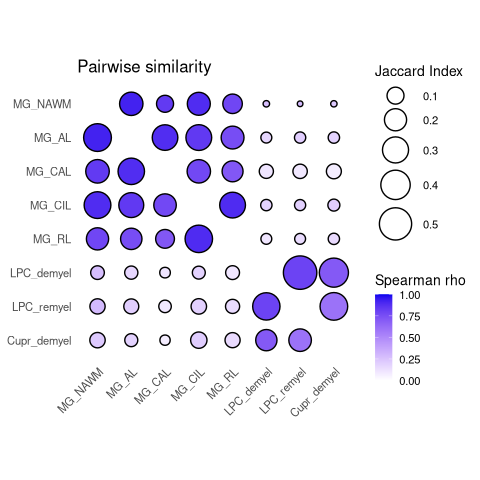

In [51]:
%%R -i jaccard_spearman_degs_df
dataset_order <- c("MOL_NAWM", "MOL_AL", "MOL_CAL", "MOL_CIL", "MOL_RL",
                   "LPC_demyel", "LPC_remyel", "Cupr_demyel")
# Create numeric positions
dataset_index <- setNames(seq_along(dataset_order), dataset_order)
# Prepare upper triangle (Jaccard Up) - original data
upper_df <- jaccard_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset1],
    y = dataset_index[dataset2],
    size = jaccard_up,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )
# Prepare lower triangle (Jaccard Down) - SWAP x and y coordinates
lower_df <- jaccard_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset2],  # Swapped!
    y = dataset_index[dataset1],  # Swapped!
    size = jaccard_down,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )
# Create diagonal with NA size (won't be plotted)
diag_df <- data.frame(
  x = seq_along(dataset_order),
  y = seq_along(dataset_order),
  size = NA,
  color = 1,
  significant = FALSE
)
# Combine all data
plot_df <- bind_rows(upper_df, lower_df, diag_df)

# Rename MOL_ to MG_ in dataset_order for labels
dataset_labels <- sub("MOL_", "MG_", dataset_order)

# Convert x/y to factors with renamed labels
plot_df <- plot_df %>%
  mutate(
    x = factor(x, levels = seq_along(dataset_order), labels = dataset_labels),
    y = factor(y, levels = seq_along(dataset_order), labels = dataset_labels),
    outline_color = ifelse(significant, "black", "grey70")
  )
plot_df_no_diag <- plot_df %>% filter(!is.na(size))
# Create the plot object
p <- ggplot(plot_df_no_diag, aes(x = x, y = y)) +
  geom_point(aes(size = size, fill = color, color = outline_color), shape = 21, stroke = 1) +
  scale_color_identity() +
  scale_fill_gradient2(low = "#CD1076", mid = "white", high = "#0000EE", 
                       midpoint = 0, limits = c(0, 1), name = "Spearman rho") +
  scale_size_continuous(range = c(2, 15), name = "Jaccard Index") +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  labs(title = "Pairwise similarity")
# Display the plot
print(p)
# Save the plot
ggsave("./figures/jaccard_spearman_plot_MG.png", plot = p, 
       width = 7, height = 7, dpi = 300, bg = "white")

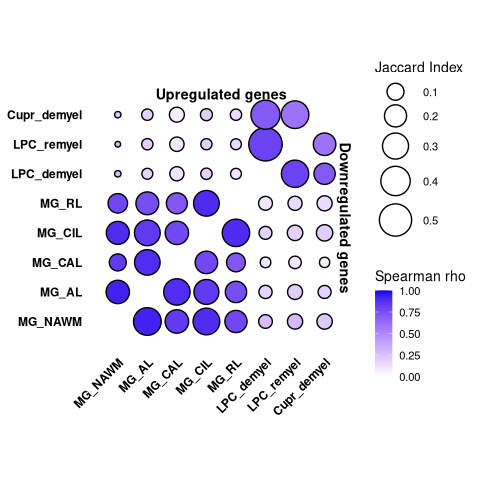

In [52]:
%%R -i jaccard_spearman_degs_df

dataset_order <- c("MOL_NAWM", "MOL_AL", "MOL_CAL", "MOL_CIL", "MOL_RL",
                   "LPC_demyel", "LPC_remyel", "Cupr_demyel")

# Create numeric positions
dataset_index <- setNames(seq_along(dataset_order), dataset_order)

# Prepare upper triangle (Jaccard Up) - SWAP to put in lower left
upper_df <- jaccard_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset2],  # Swapped!
    y = dataset_index[dataset1],  # Swapped!
    size = jaccard_up,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )

# Prepare lower triangle (Jaccard Down) - original positions for upper right
lower_df <- jaccard_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset1],
    y = dataset_index[dataset2],
    size = jaccard_down,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )

# Create diagonal with NA size (won't be plotted)
diag_df <- data.frame(
  x = seq_along(dataset_order),
  y = seq_along(dataset_order),
  size = NA,
  color = 1,
  significant = FALSE
)

# Combine all data
plot_df <- bind_rows(upper_df, lower_df, diag_df)

# Rename MOL_ to MG_ in dataset_order for labels
dataset_labels <- sub("MOL_", "MG_", dataset_order)

# Convert x/y to factors with renamed labels
plot_df <- plot_df %>%
  mutate(
    x = factor(x, levels = seq_along(dataset_order), labels = dataset_labels),
    y = factor(y, levels = seq_along(dataset_order), labels = dataset_labels),
    outline_color = ifelse(significant, "black", "grey70")
  )
plot_df_no_diag <- plot_df %>% filter(!is.na(size))
# Create the plot object
p <- ggplot(plot_df_no_diag, aes(x = x, y = y)) +
  geom_point(aes(size = size, fill = color, color = outline_color), shape = 21, stroke = 1) +
  scale_color_identity() +
  scale_fill_gradient2(low = "#CD1076", mid = "white", high = "#0000EE", 
                       midpoint = 0, limits = c(0, 1), name = "Spearman rho") +
  scale_size_continuous(range = c(2, 15), name = "Jaccard Index") +
  scale_x_discrete(expand = expansion(add = 1)) +
  scale_y_discrete(expand = expansion(add = 1)) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12, face = "bold", color="black"),
    axis.text.y = element_text(size = 12, face = "bold", color="black"),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  labs(title = "") +
  annotate("text", x = 4.5, y = 8.7, label = "Upregulated genes", 
           angle = 0, size = 5, fontface = "bold") +
  annotate("text", x = 8.7, y = 4.5, label = "Downregulated genes", 
           angle = 270, size = 5, fontface = "bold")

# Display the plot
print(p)

# Save the plot
ggsave("./figures/jaccard_spearman_plot_labeled.png", plot = p, 
       width = 7, height = 7, dpi = 300, bg = "white")

In [53]:
import itertools
import pandas as pd
from scipy.stats import spearmanr

pairs = list(itertools.combinations(dfs.keys(), 2))
results = []

for a, b in pairs:
    df1 = dfs[a]
    df2 = dfs[b]
    
    # Genes DE in at least one dataset
    deg_genes = set(df1[df1['direction'] != 'ns']['gene_hs']).union(
                set(df2[df2['direction'] != 'ns']['gene_hs']))
    
    # Keep only genes measured in both datasets
    shared_genes = deg_genes.intersection(set(df1['gene_hs'])).intersection(set(df2['gene_hs']))
    
    # Subset for calculations
    df1_sub = df1[df1['gene_hs'].isin(shared_genes)].set_index('gene_hs')
    df2_sub = df2[df2['gene_hs'].isin(shared_genes)].set_index('gene_hs')
    
    # --- UP ---
    up1 = set(df1_sub.loc[df1_sub['direction']=='up'].index)
    up2 = set(df2_sub.loc[df2_sub['direction']=='up'].index)
    up_shared = len(up1 & up2)
    up_union = len(up1 | up2)
    up_min = min(len(up1), len(up2))
    j_up = up_shared / up_min if up_min > 0 else 0   # <-- Overlap coefficient replaces Jaccard
    
    # --- DOWN ---
    down1 = set(df1_sub.loc[df1_sub['direction']=='down'].index)
    down2 = set(df2_sub.loc[df2_sub['direction']=='down'].index)
    down_shared = len(down1 & down2)
    down_union = len(down1 | down2)
    down_min = min(len(down1), len(down2))
    j_down = down_shared / down_min if down_min > 0 else 0   # <-- Overlap coefficient replaces Jaccard
    
    # --- Spearman correlation (unchanged) ---
    genes_list = list(shared_genes)
    if len(genes_list) > 1:
        rho, pval = spearmanr(df1_sub.loc[genes_list, 'logFC'],
                              df2_sub.loc[genes_list, 'logFC'])
    else:
        rho, pval = (float('nan'), float('nan'))
    
    # --- Append results ---
    results.append({
        "dataset1": a,
        "dataset2": b,
        # Up counts
        "up_df1": len(up1),
        "up_df2": len(up2),
        "up_shared": up_shared,
        "up_union": up_union,
        "overlap_coeff_up": j_up,     # <-- This now contains the overlap coefficient
        # Down counts
        "down_df1": len(down1),
        "down_df2": len(down2),
        "down_shared": down_shared,
        "down_union": down_union,
        "overlap_coeff_down": j_down, # <-- This also now contains the overlap coefficient
        # Spearman correlation
        "spearman_rho": rho,
        "spearman_pval": pval,
        "shared_genes": len(shared_genes)
    })

overlap_spearman_degs_df = pd.DataFrame(results)

# Jaccard Up
min_ov_up = overlap_spearman_degs_df['overlap_coeff_up'].min()
max_ov_up = overlap_spearman_degs_df['overlap_coeff_up'].max()

# Jaccard Down
min_ov_down = overlap_spearman_degs_df['overlap_coeff_down'].min()
max_ov_down = overlap_spearman_degs_df['overlap_coeff_down'].max()

# Spearman rho
min_rho = overlap_spearman_degs_df['spearman_rho'].min()
max_rho = overlap_spearman_degs_df['spearman_rho'].max()

print(f"OV Up: min={min_ov_up:.3f}, max={max_ov_up:.3f}")
print(f"OV Down: min={min_ov_down:.3f}, max={max_ov_down:.3f}")
print(f"Spearman rho: min={min_rho:.3f}, max={max_rho:.3f}")

overlap_spearman_degs_df.to_csv("overlap_spearman_degs_df.csv", index=False)

OV Up: min=0.053, max=0.639
OV Down: min=0.339, max=0.750
Spearman rho: min=0.075, max=0.922


In [54]:
# Replace "MOL_" with "MG_" in dataset1 and dataset2 columns
overlap_spearman_degs_df["dataset1"] = overlap_spearman_degs_df["dataset1"].str.replace("MOL_", "MG_")
overlap_spearman_degs_df["dataset2"] = overlap_spearman_degs_df["dataset2"].str.replace("MOL_", "MG_")

# Now save to CSV
overlap_spearman_degs_df.to_csv("overlap_spearman_degs_df_MG.csv", index=False)

In [55]:
# Replace "MOL_" with "MG_" in dataset1 and dataset2 columns
overlap_spearman_degs_df["dataset1"] = overlap_spearman_degs_df["dataset1"].str.replace("Cupr_", "CPZ_")
overlap_spearman_degs_df["dataset2"] = overlap_spearman_degs_df["dataset2"].str.replace("Cupr_", "CPZ_")

# Now save to CSV
overlap_spearman_degs_df.to_csv("overlap_spearman_degs_df_MG.csv", index=False)

In [56]:
# Upregulated overlap
overlap_up = set(MOL_AL_up["gene_hs"]).intersection(set(LPC_demyel_up["gene_hs"]))

# Downregulated overlap
overlap_down = set(MOL_AL_down["gene_hs"]).intersection(set(LPC_demyel_down["gene_hs"]))

print("\n### UPREGULATED overlap (MOL_AL ∩ LPC_demyel):")
print(sorted(overlap_up))

print("\n### DOWNREGULATED overlap (MOL_AL ∩ LPC_demyel):")
print(sorted(overlap_down))

print("\nCounts:")
print("Up overlap:", len(overlap_up))
print("Down overlap:", len(overlap_down))


### UPREGULATED overlap (MOL_AL ∩ LPC_demyel):
['ANTXR2', 'APOC1', 'APOE', 'ARHGAP10', 'ARRDC4', 'BST2', 'CD44', 'CDK18', 'CSF1', 'CTSZ', 'DSE', 'FAM20C', 'FMN1', 'GNG12', 'GPR65', 'HGF', 'HIKESHI', 'IDH1', 'IGF2R', 'IQGAP1', 'LAP3', 'LPL', 'MDFIC', 'MFSD1', 'MRPL18', 'MYO1E', 'NOCT', 'NPC2', 'NUDC', 'PLXNC1', 'PMP22', 'PMVK', 'POLR2F', 'SASH1', 'SESTD1', 'ST14', 'TPP1', 'TSPO', 'VAV3', 'VIM']

### DOWNREGULATED overlap (MOL_AL ∩ LPC_demyel):
['ANKRD44', 'ATXN7L3', 'BACH2', 'BANK1', 'C4orf19', 'CACNB2', 'CTTNBP2NL', 'DDB2', 'DGKA', 'DOCK4', 'ENTPD1', 'FAM117B', 'FMNL3', 'FRMD4A', 'IFNGR1', 'KIF21B', 'LIPC', 'MACO1', 'MAP2K6', 'MED12L', 'MEF2C', 'MGME1', 'MLXIPL', 'MMP28', 'NAV3', 'NOS1AP', 'P2RY13', 'P3H2', 'PBX1', 'PDE4D', 'PER3', 'PLA2G4A', 'PLCL2', 'PRDM11', 'PROX2', 'PTGS1', 'SALL1', 'SDK1', 'SEMA3C', 'SH2D3C', 'TAL1', 'TBC1D9', 'TLN2', 'TTC7A', 'UST', 'VCL', 'ZEB1', 'ZFP36L1', 'ZFP36L2', 'ZSWIM6']

Counts:
Up overlap: 40
Down overlap: 50


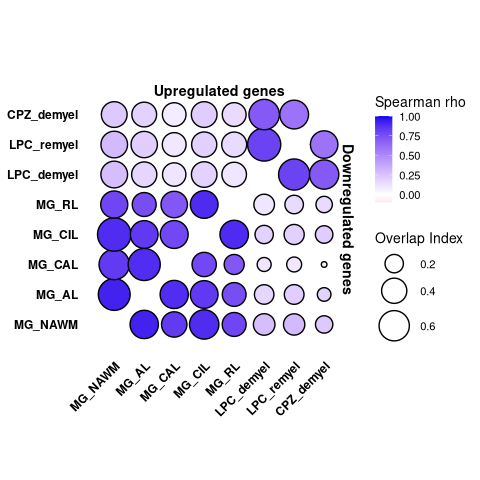

In [57]:
%%R -i overlap_spearman_degs_df

dataset_order <- c("MG_NAWM", "MG_AL", "MG_CAL", "MG_CIL", "MG_RL",
                   "LPC_demyel", "LPC_remyel", "CPZ_demyel")

# Create numeric positions
dataset_index <- setNames(seq_along(dataset_order), dataset_order)

# Prepare upper triangle (Overlap Up) - SWAP to put in lower left
upper_df <- overlap_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset2],  # Swapped!
    y = dataset_index[dataset1],  # Swapped!
    size = overlap_coeff_up,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )

# Prepare lower triangle (Overlap Down) - original positions for upper right
lower_df <- overlap_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset1],
    y = dataset_index[dataset2],
    size = overlap_coeff_down,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )

# Create diagonal with NA size (won't be plotted)
diag_df <- data.frame(
  x = seq_along(dataset_order),
  y = seq_along(dataset_order),
  size = NA,
  color = 1,
  significant = FALSE
)

# Combine all data
plot_df <- bind_rows(upper_df, lower_df, diag_df)

# Convert x/y to factors
plot_df <- plot_df %>%
  mutate(
    x = factor(x, levels = seq_along(dataset_order), labels = dataset_order),
    y = factor(y, levels = seq_along(dataset_order), labels = dataset_order),
    outline_color = ifelse(significant, "black", "grey70")
  )

plot_df_no_diag <- plot_df %>% filter(!is.na(size))

# Create the plot object
p <- ggplot(plot_df_no_diag, aes(x = x, y = y)) +
  geom_point(aes(size = size, fill = color, color = outline_color), shape = 21, stroke = 1) +
  scale_color_identity() +
  scale_fill_gradient2(low = "#CD1076", mid = "white", high = "#0000EE", 
                       midpoint = 0, limits = c(-0.1, 1), name = "Spearman rho") +
  scale_size_continuous(range = c(2, 15), name = "Overlap Index") +
  scale_x_discrete(expand = expansion(add = 1)) +
  scale_y_discrete(expand = expansion(add = 1)) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12, face = "bold", color="black"),
    axis.text.y = element_text(size = 12, face = "bold", color="black"),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  labs(title = "") +
  annotate("text", x = 4.5, y = 8.8, label = "Upregulated genes", 
           angle = 0, size = 5, fontface = "bold") +
  annotate("text", x = 8.8, y = 4.5, label = "Downregulated genes", 
           angle = 270, size = 5, fontface = "bold")

# Display the plot
print(p)

# Save the plot
ggsave("./figures/Overlap_spearman_plot_labeled.png", plot = p, 
       width = 7, height = 7, dpi = 300, bg = "white")

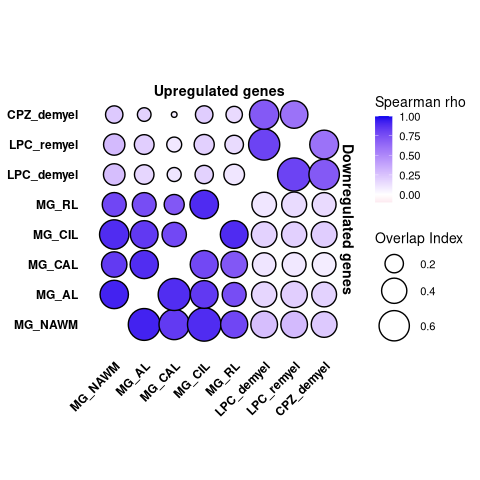

In [62]:
%%R -i overlap_spearman_degs_df

dataset_order <- c("MG_NAWM", "MG_AL", "MG_CAL", "MG_CIL", "MG_RL",
                   "LPC_demyel", "LPC_remyel", "CPZ_demyel")

# Create numeric positions
dataset_index <- setNames(seq_along(dataset_order), dataset_order)

# Upper triangle (Overlap Up) - above diagonal
upper_df <- overlap_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset1],
    y = dataset_index[dataset2],
    size = overlap_coeff_up,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )

# Lower triangle (Overlap Down) - below diagonal
lower_df <- overlap_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset2],
    y = dataset_index[dataset1],
    size = overlap_coeff_down,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )

# Create diagonal with NA size (won't be plotted)
diag_df <- data.frame(
  x = seq_along(dataset_order),
  y = seq_along(dataset_order),
  size = NA,
  color = 1,
  significant = FALSE
)

# Combine all data
plot_df <- bind_rows(upper_df, lower_df, diag_df)

# Convert x/y to factors
plot_df <- plot_df %>%
  mutate(
    x = factor(x, levels = seq_along(dataset_order), labels = dataset_order),
    y = factor(y, levels = seq_along(dataset_order), labels = dataset_order),
    outline_color = ifelse(significant, "black", "grey70")
  )

plot_df_no_diag <- plot_df %>% filter(!is.na(size))

# Create the plot object
p <- ggplot(plot_df_no_diag, aes(x = x, y = y)) +
  geom_point(aes(size = size, fill = color, color = outline_color), shape = 21, stroke = 1) +
  scale_color_identity() +
  scale_fill_gradient2(low = "#CD1076", mid = "white", high = "#0000EE", 
                       midpoint = 0, limits = c(-0.1, 1), name = "Spearman rho") +
  scale_size_continuous(range = c(2, 15), name = "Overlap Index") +
  scale_x_discrete(expand = expansion(add = 1)) +
  scale_y_discrete(expand = expansion(add = 1)) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12, face = "bold", color="black"),
    axis.text.y = element_text(size = 12, face = "bold", color="black"),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  labs(title = "") +
  annotate("text", x = 4.5, y = 8.8, label = "Upregulated genes", 
           angle = 0, size = 5, fontface = "bold") +
  annotate("text", x = 8.8, y = 4.5, label = "Downregulated genes", 
           angle = 270, size = 5, fontface = "bold")

# Display the plot
print(p)

# Save the plot
ggsave("./figures/Overlap_spearman_plot_labeled.png", plot = p, 
       width = 7, height = 7, dpi = 300, bg = "white")

## Bar charts

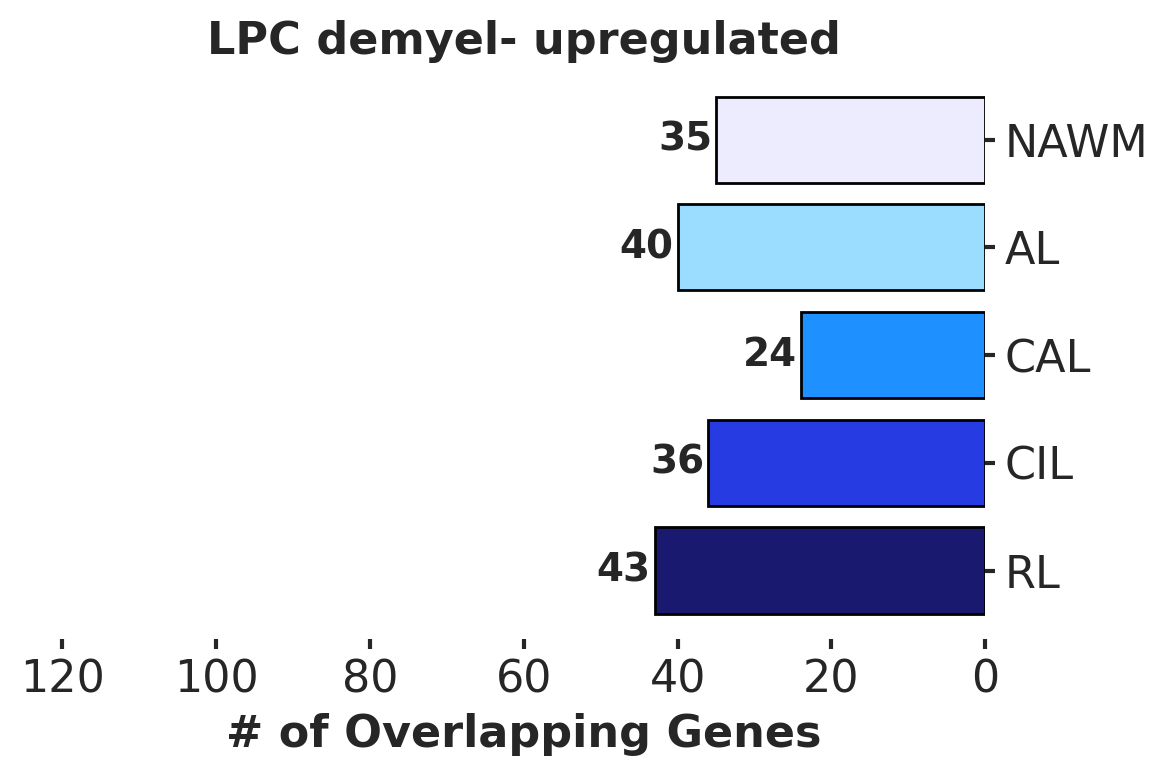

In [58]:
import seaborn as sns

# Lesion names and counts
lesions = ["NAWM", 'AL', 'CAL', 'CIL', 'RL']
gene_counts = [35, 40, 24, 36, 43]

# Colors for each lesion
lesion_colors = ["#ececfe", "#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(120, 0)
ax.set_xticks([0, 20, 40, 60, 80, 100, 120])
ax.set_xticklabels(['0', '20', '40', '60', '80', '100', '120'])

# Title
ax.set_title("LPC demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_demyel.png", dpi=300, bbox_inches='tight')

plt.show()

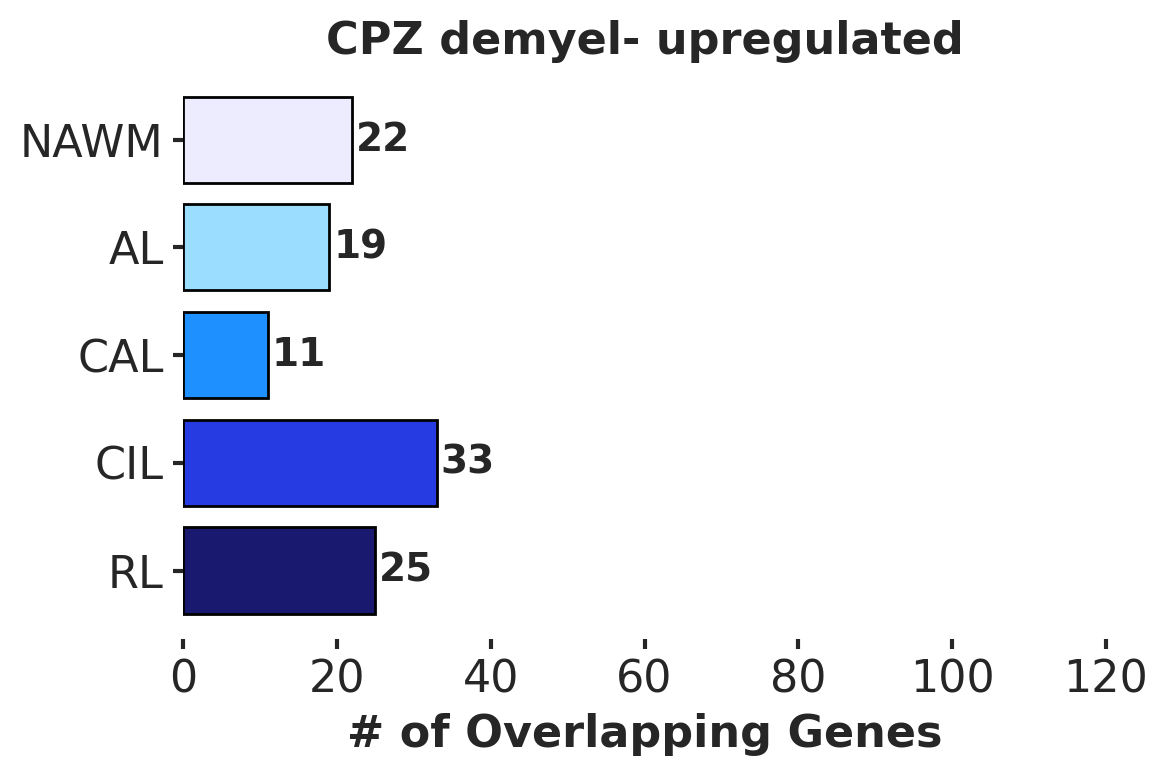

In [59]:
# Lesion names and CPZ counts
lesions = ['NAWM', 'AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [22, 19, 11, 33, 25]

# Colors for each lesion
lesion_colors = ["#ececfe", "#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(0, 120)
ax.set_xticks([0, 20, 40, 60, 80, 100, 120])
ax.set_xticklabels(['0', '20', '40', '60', '80', '100', '120'])

# Title
ax.set_title("CPZ demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_CPZ_demyel.png", dpi=300, bbox_inches='tight')

plt.show()

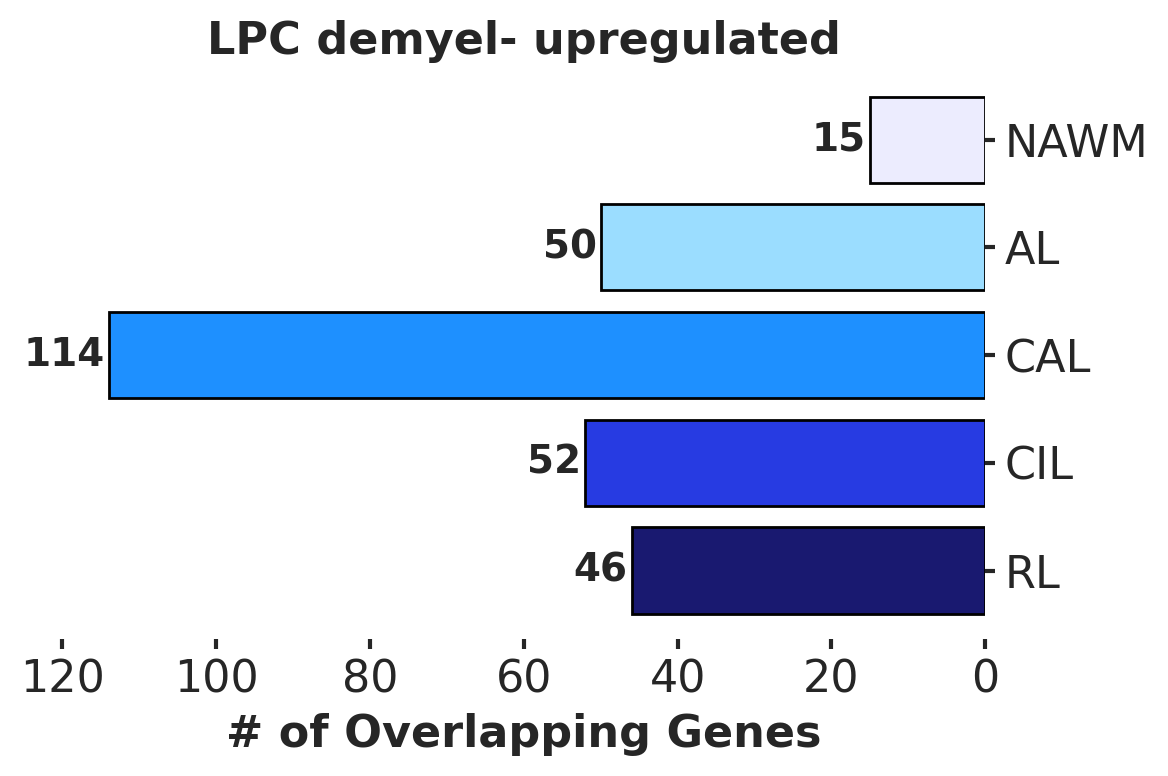

In [60]:
import seaborn as sns

# Lesion names and counts
lesions = ["NAWM", 'AL', 'CAL', 'CIL', 'RL']
gene_counts = [15, 50, 114, 52, 46]

# Colors for each lesion
lesion_colors = ["#ececfe", "#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(120, 0)
ax.set_xticks([0, 20, 40, 60, 80, 100, 120])
ax.set_xticklabels(['0', '20', '40', '60', '80', '100', '120'])

# Title
ax.set_title("LPC demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_demyel_down.png", dpi=300, bbox_inches='tight')

plt.show()

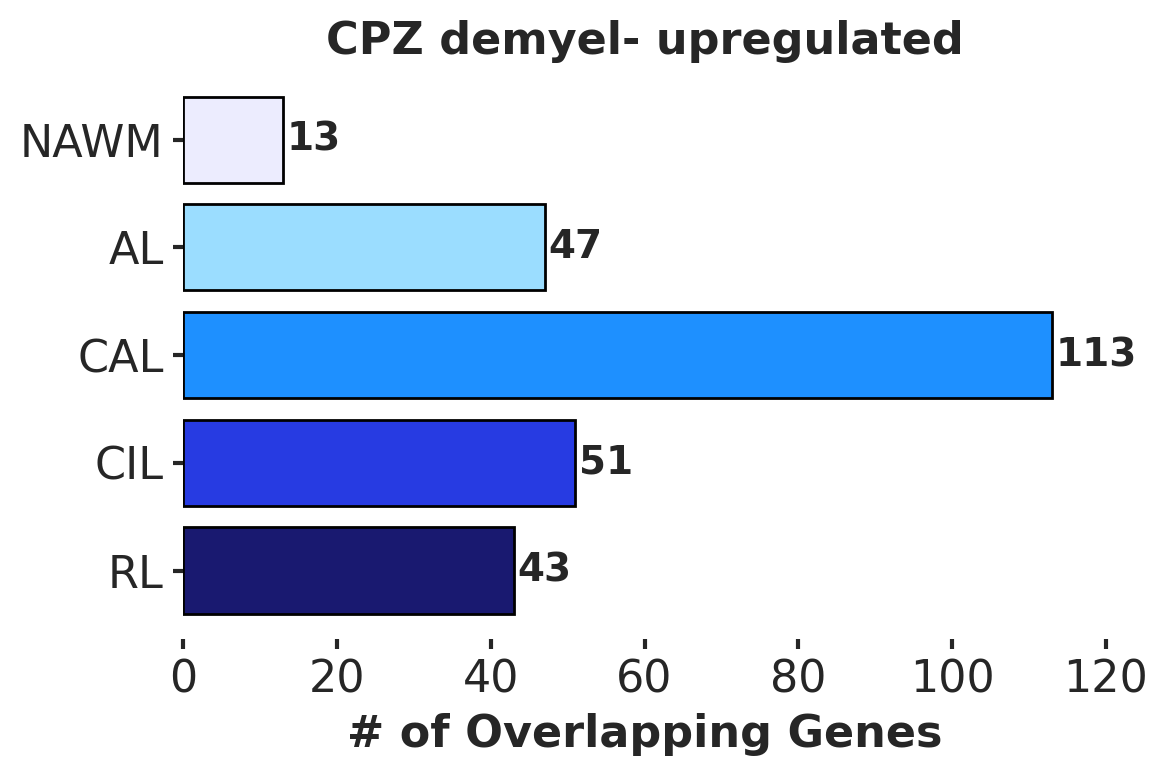

In [87]:
# Lesion names and CPZ counts
lesions = ['NAWM', 'AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [13, 47, 113, 51, 43]

# Colors for each lesion
lesion_colors = ["#ececfe", "#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(0, 120)
ax.set_xticks([0, 20, 40, 60, 80, 100, 120])
ax.set_xticklabels(['0', '20', '40', '60', '80', '100', '120'])

# Title
ax.set_title("CPZ demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_CPZ_demyel_down.png", dpi=300, bbox_inches='tight')

plt.show()

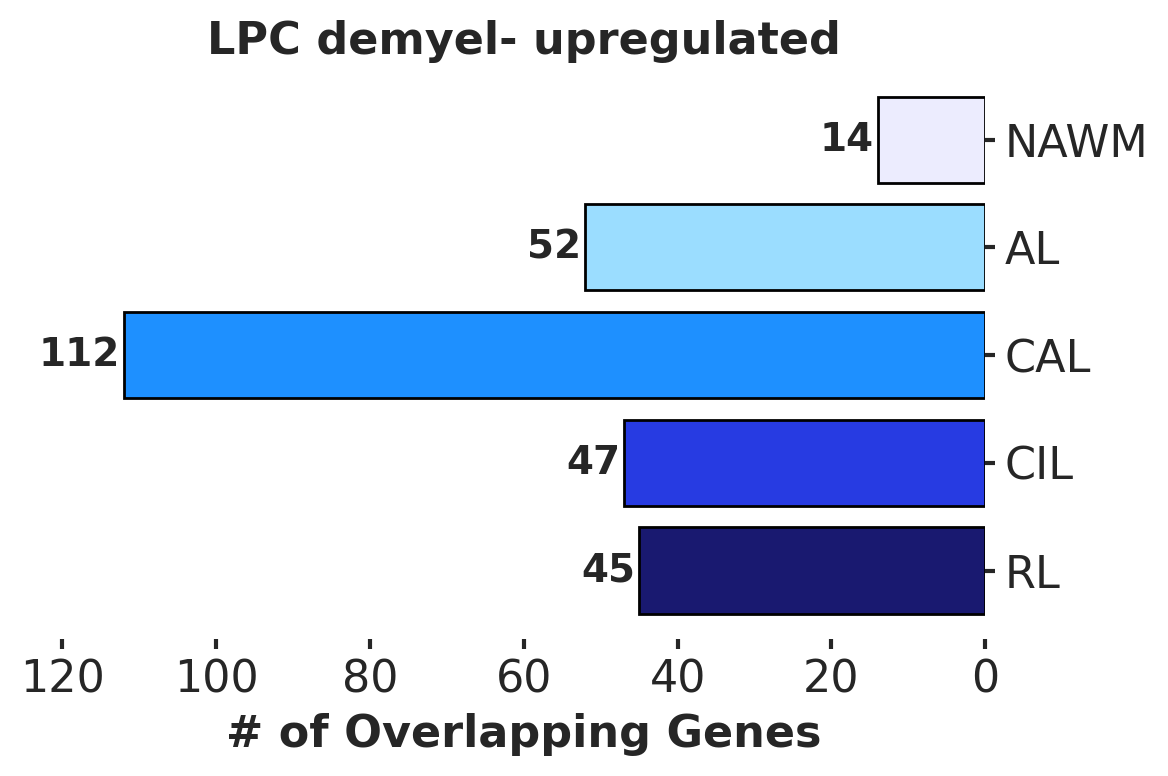

In [88]:
import seaborn as sns

# Lesion names and counts
lesions = ["NAWM", 'AL', 'CAL', 'CIL', 'RL']
gene_counts = [14, 52, 112, 47, 45]

# Colors for each lesion
lesion_colors = ["#ececfe", "#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(120, 0)
ax.set_xticks([0, 20, 40, 60, 80, 100, 120])
ax.set_xticklabels(['0', '20', '40', '60', '80', '100', '120'])

# Title
ax.set_title("LPC demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_remyel.png", dpi=300, bbox_inches='tight')

plt.show()

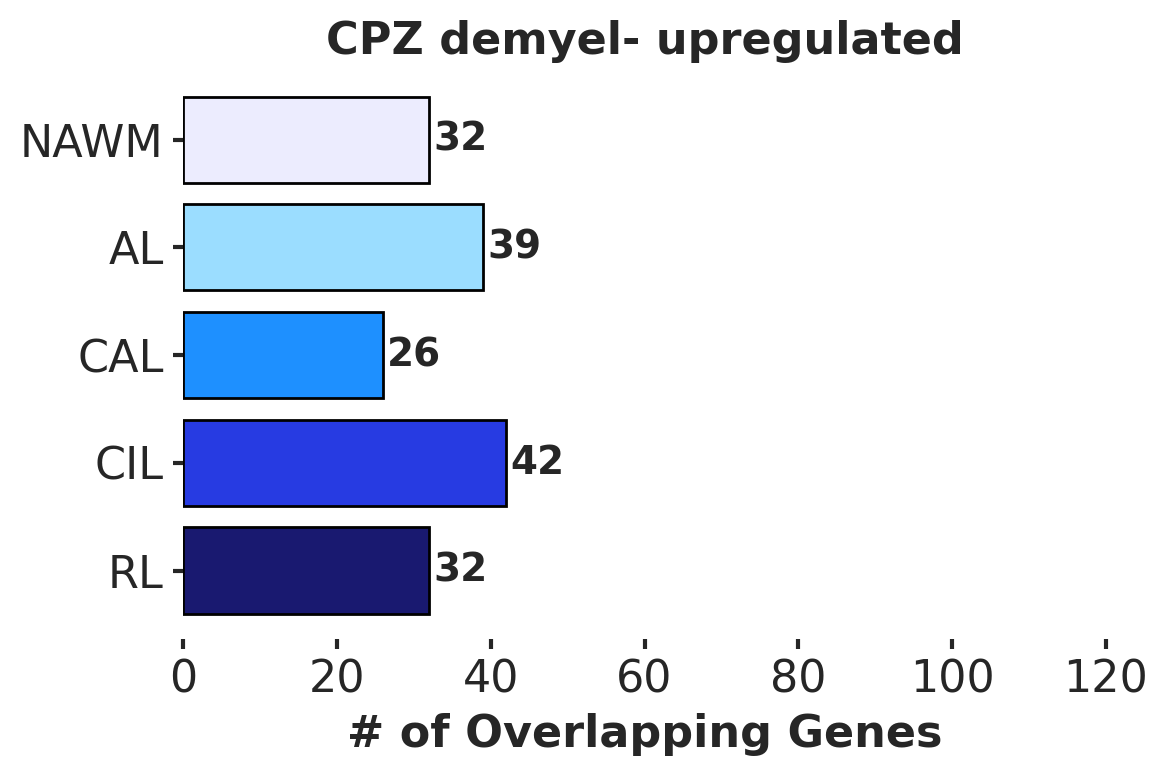

In [89]:
# Lesion names and CPZ counts
lesions = ['NAWM', 'AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [32, 39, 26, 42, 32]

# Colors for each lesion
lesion_colors = ["#ececfe", "#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(0, 120)
ax.set_xticks([0, 20, 40, 60, 80, 100, 120])
ax.set_xticklabels(['0', '20', '40', '60', '80', '100', '120'])

# Title
ax.set_title("CPZ demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_remyel_down.png", dpi=300, bbox_inches='tight')

plt.show()

In [95]:
# Upregulated overlap
overlap_up = set(MOL_AL_up["gene_hs"]).intersection(set(LPC_demyel_up["gene_hs"]))

# Downregulated overlap
overlap_down = set(MOL_AL_down["gene_hs"]).intersection(set(LPC_demyel_down["gene_hs"]))

print("\n### UPREGULATED overlap (MOL_AL ∩ LPC_demyel):")
print(sorted(overlap_up))

print("\n### DOWNREGULATED overlap (MOL_AL ∩ LPC_demyel):")
print(sorted(overlap_down))

print("\nCounts:")
print("Up overlap:", len(overlap_up))
print("Down overlap:", len(overlap_down))


### UPREGULATED overlap (MOL_AL ∩ LPC_demyel):
['ANTXR2', 'APOC1', 'APOE', 'ARHGAP10', 'ARRDC4', 'BST2', 'CD44', 'CDK18', 'CSF1', 'CTSZ', 'DSE', 'FAM20C', 'FMN1', 'GNG12', 'GPR65', 'HGF', 'HIKESHI', 'IDH1', 'IGF2R', 'IQGAP1', 'LAP3', 'LPL', 'MDFIC', 'MFSD1', 'MRPL18', 'MYO1E', 'NOCT', 'NPC2', 'NUDC', 'PLXNC1', 'PMP22', 'PMVK', 'POLR2F', 'SASH1', 'SESTD1', 'ST14', 'TPP1', 'TSPO', 'VAV3', 'VIM']

### DOWNREGULATED overlap (MOL_AL ∩ LPC_demyel):
['ANKRD44', 'ATXN7L3', 'BACH2', 'BANK1', 'C4orf19', 'CACNB2', 'CTTNBP2NL', 'DDB2', 'DGKA', 'DOCK4', 'ENTPD1', 'FAM117B', 'FMNL3', 'FRMD4A', 'IFNGR1', 'KIF21B', 'LIPC', 'MACO1', 'MAP2K6', 'MED12L', 'MEF2C', 'MGME1', 'MLXIPL', 'MMP28', 'NAV3', 'NOS1AP', 'P2RY13', 'P3H2', 'PBX1', 'PDE4D', 'PER3', 'PLA2G4A', 'PLCL2', 'PRDM11', 'PROX2', 'PTGS1', 'SALL1', 'SDK1', 'SEMA3C', 'SH2D3C', 'TAL1', 'TBC1D9', 'TLN2', 'TTC7A', 'UST', 'VCL', 'ZEB1', 'ZFP36L1', 'ZFP36L2', 'ZSWIM6']

Counts:
Up overlap: 40
Down overlap: 50


In [96]:
import itertools
import pandas as pd

# 1️⃣ Store your gene sets in dictionaries
# Keys are dataset names, values are DataFrames of up/down DEGs
up_dict = {
    "NAWM": MOL_NAWM_up,
    "AL": MOL_AL_up,
    "CAL": MOL_CAL_up,
    "CIL": MOL_CIL_up,
    "RL": MOL_RL_up,
    "LPC_demyel": LPC_demyel_up,
    "LPC_remyel": LPC_remyel_up,
    "Cupr_demyel": Cupr_demyel_up
}

down_dict = {
    "NAWM": MOL_NAWM_down,
    "AL": MOL_AL_down,
    "CAL": MOL_CAL_down,
    "CIL": MOL_CIL_down,
    "RL": MOL_RL_down,
    "LPC_demyel": LPC_demyel_down,
    "LPC_remyel": LPC_remyel_down,
    "Cupr_demyel": Cupr_demyel_down
}

# 2️⃣ Create a list of all dataset names
datasets = list(up_dict.keys())

# 3️⃣ Loop over all pairwise combinations
overlap_results = []

for d1, d2 in itertools.combinations(datasets, 2):
    # Upregulated overlap
    up_overlap = set(up_dict[d1]["gene_hs"]).intersection(set(up_dict[d2]["gene_hs"]))
    # Downregulated overlap
    down_overlap = set(down_dict[d1]["gene_hs"]).intersection(set(down_dict[d2]["gene_hs"]))
    
    overlap_results.append({
        "dataset1": d1,
        "dataset2": d2,
        "up_overlap_count": len(up_overlap),
        "up_overlap_genes": ", ".join(sorted(up_overlap)),
        "down_overlap_count": len(down_overlap),
        "down_overlap_genes": ", ".join(sorted(down_overlap))
    })

# 4️⃣ Convert results to a DataFrame
overlap_df = pd.DataFrame(overlap_results)

# 5️⃣ Optional: save to CSV
overlap_df.to_csv("all_pairwise_DEG_overlaps.csv", index=False)

# Preview
overlap_df.head()

,dataset1,dataset2,up_overlap_count,up_overlap_genes,down_overlap_count,down_overlap_genes
0,NAWM,AL,93,"ABHD3, ACTN1, ADGRG6, AHNAK, AHSA1, ALDH1A2, A...",43,"ADGRG5, ATP2A3, BACH2, BANK1, C12orf42, C12orf..."
1,NAWM,CAL,71,"ABHD3, ACTN1, ADGRG6, ALDH1A2, ARHGAP10, BAG3,...",40,"ADAMTSL2, ADGRG5, ARID3B, ARL5C, ATP2A3, BANK1..."
2,NAWM,CIL,92,"ABCA1, ABHD3, ACSL1, ACTN1, ADD3, ADGRG6, ALDH...",48,"ADAMTSL2, ADGRG5, BANK1, BLNK, C12orf42, C12or..."
3,NAWM,RL,58,"ABCA1, ADD3, ADGRG6, ALDH1A2, APOC1, BST2, CD1...",30,"ADGRG5, ATP2A3, BANK1, BLNK, C12orf42, C12orf7..."
4,NAWM,LPC_demyel,35,"ABCA1, ANXA2, AP2M1, APOC1, APRT, ARHGAP10, AR...",15,"ARID3B, BACH2, BANK1, BIN2, CACNB2, FOS, KHDRB..."


In [100]:
# List of MOL subtypes to compare
mol_subtypes = ["AL", "CAL", "CIL", "RL"]

# Initialize dictionaries to store gene sets
LPC_dict = {
    "AL": set(MOL_AL_up["gene_hs"]),
    "CAL": set(MOL_CAL_up["gene_hs"]),
    "CIL": set(MOL_CIL_up["gene_hs"]),
    "RL": set(MOL_RL_up["gene_hs"])
}

CPZ_dict = {
    "AL": set(MOL_AL_up["gene_hs"]),   # assuming the same MOL_* dfs are used for CPZ comparison
    "CAL": set(MOL_CAL_up["gene_hs"]),
    "CIL": set(MOL_CIL_up["gene_hs"]),
    "RL": set(MOL_RL_up["gene_hs"])
}

# Genes in LPC_demyel
LPC_genes = set(LPC_demyel_up["gene_hs"])

# Genes in CPZ_demyel
CPZ_genes = set(Cupr_demyel_up["gene_hs"])

In [101]:
# Loop through MOL subtypes and get unique overlaps
unique_LPC_overlaps = {}

for mol in mol_subtypes:
    # Overlap with LPC
    overlap_LPC = LPC_genes.intersection(LPC_dict[mol])
    
    # Overlap with CPZ
    overlap_CPZ = CPZ_genes.intersection(CPZ_dict[mol])
    
    # Keep only genes shared with LPC but NOT with CPZ
    unique_genes = overlap_LPC - overlap_CPZ
    
    unique_LPC_overlaps[mol] = unique_genes
    print(f"\nUnique LPC_demyel ∩ MOL_{mol} (not in CPZ_demyel): {len(unique_genes)} genes")
    print(", ".join(sorted(unique_genes)))


Unique LPC_demyel ∩ MOL_AL (not in CPZ_demyel): 23 genes
ANTXR2, ARHGAP10, CDK18, CTSZ, DSE, GPR65, HGF, HIKESHI, IDH1, IGF2R, LAP3, MDFIC, MFSD1, MRPL18, MYO1E, NPC2, NUDC, PMP22, PMVK, POLR2F, SESTD1, TPP1, VAV3

Unique LPC_demyel ∩ MOL_CAL (not in CPZ_demyel): 17 genes
APP, ARHGAP10, CDK18, CTSZ, FLOT2, GPR65, HSPA4L, IDH1, MRPL18, NUDC, POLR2F, SEM1, SESTD1, SOD2, SSR4, TRPS1, UBE2D1

Unique LPC_demyel ∩ MOL_CIL (not in CPZ_demyel): 14 genes
ARHGAP10, ARID5B, CDK18, FKBP14, FLOT2, GPR65, IGF2R, MDFIC, MYO1E, PAM, PMP22, POLR2F, SESTD1, SLC31A2

Unique LPC_demyel ∩ MOL_RL (not in CPZ_demyel): 24 genes
ABHD17C, CDK18, DDX41, DMXL2, EPB41L3, FCER1G, GALC, GRINA, GUK1, IGF2R, IQGAP2, MCM6, MDFIC, MPHOSPH6, PAM, PLA2G7, POLR2F, SESTD1, SLC31A2, SOD2, TPP1, TRPS1, VAV3, ZNF704


In [102]:
# Collect all unique LPC_demyel overlaps per MOL subtype
LPC_unique = {
    "AL": {"ANTXR2", "ARHGAP10", "CDK18", "CTSZ", "DSE", "GPR65", "HGF", "HIKESHI", "IDH1",
           "IGF2R", "LAP3", "MDFIC", "MFSD1", "MRPL18", "MYO1E", "NPC2", "NUDC", "PMP22",
           "PMVK", "POLR2F", "SESTD1", "TPP1", "VAV3"},
    "CAL": {"APP", "ARHGAP10", "CDK18", "CTSZ", "FLOT2", "GPR65", "HSPA4L", "IDH1", "MRPL18",
            "NUDC", "POLR2F", "SEM1", "SESTD1", "SOD2", "SSR4", "TRPS1", "UBE2D1"},
    "CIL": {"ARHGAP10", "ARID5B", "CDK18", "FKBP14", "FLOT2", "GPR65", "IGF2R", "MDFIC",
            "MYO1E", "PAM", "PMP22", "POLR2F", "SESTD1", "SLC31A2"},
    "RL": {"ABHD17C", "CDK18", "DDX41", "DMXL2", "EPB41L3", "FCER1G", "GALC", "GRINA",
           "GUK1", "IGF2R", "IQGAP2", "MCM6", "MDFIC", "MPHOSPH6", "PAM", "PLA2G7",
           "POLR2F", "SESTD1", "SLC31A2", "SOD2", "TPP1", "TRPS1", "VAV3", "ZNF704"}
}

# Find intersection across all four lists
common_genes = set.intersection(*LPC_unique.values())
print("Genes common across AL, CAL, CIL, RL (unique LPC_demyel overlaps):")
print(sorted(common_genes))

Genes common across AL, CAL, CIL, RL (unique LPC_demyel overlaps):
['CDK18', 'POLR2F', 'SESTD1']


In [107]:
# Create gene lists from the new DataFrames
genes_MOL_AL_all_up = MOL_AL_up['gene'].tolist()
genes_MOL_CAL_all_up = MOL_CAL_up['gene'].tolist()
genes_MOL_CIL_all_up = MOL_CIL_up['gene'].tolist()
genes_MOL_RL_all_up = MOL_RL_up['gene'].tolist()

genes_LPC_demyel_all_up = LPC_demyel_up['gene_hs'].tolist()
genes_LPC_remyel_all_up = LPC_remyel_up['gene_hs'].tolist()
genes_Cupr_demyel_all_up = Cupr_demyel_up['gene_hs'].tolist()

In [108]:
# Convert lists to sets for upregulated genes
set_MOL_AL_up_all = set(genes_MOL_AL_all_up)
set_MOL_CAL_up_all = set(genes_MOL_CAL_all_up)
set_MOL_CIL_up_all = set(genes_MOL_CIL_all_up)
set_MOL_RL_up_all = set(genes_MOL_RL_all_up)

set_LPC_demyel_all_up = set(genes_LPC_demyel_all_up)
set_LPC_remyel_all_up = set(genes_LPC_remyel_all_up)
set_Cupr_demyel_all_up = set(genes_Cupr_demyel_all_up)

In [110]:
# Create gene lists from the new DataFrames
genes_MOL_AL_all_down = MOL_AL_down['gene'].tolist()
genes_MOL_CAL_all_down = MOL_CAL_down['gene'].tolist()
genes_MOL_CIL_all_down = MOL_CIL_down['gene'].tolist()
genes_MOL_RL_all_down = MOL_RL_down['gene'].tolist()

genes_LPC_demyel_all_down = LPC_demyel_down['gene_hs'].tolist()
genes_LPC_remyel_all_down = LPC_remyel_down['gene_hs'].tolist()
genes_Cupr_demyel_all_down = Cupr_demyel_down['gene_hs'].tolist()

In [111]:
# Convert lists to sets for upregulated genes
set_MOL_AL_down_all = set(genes_MOL_AL_all_down)
set_MOL_CAL_down_all = set(genes_MOL_CAL_all_down)
set_MOL_CIL_down_all = set(genes_MOL_CIL_all_down)
set_MOL_RL_down_all = set(genes_MOL_RL_all_down)

set_LPC_demyel_all_down = set(genes_LPC_demyel_all_down)
set_LPC_remyel_all_down = set(genes_LPC_remyel_all_down)
set_Cupr_demyel_all_down = set(genes_Cupr_demyel_all_down)

In [113]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_MOL_CAL_up_all & set_MOL_CIL_up_all & set_MOL_RL_up_all & set_LPC_demyel_all_up & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 2
Overlapping upregulated genes: {'ST14', 'PLXNC1'}


In [112]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_MOL_CAL_down_all & set_MOL_CIL_down_all & set_MOL_RL_down_all & set_LPC_demyel_all_down & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 8
Overlapping upregulated genes: {'FMNL3', 'PER3', 'PTGS1', 'TLN2', 'BANK1', 'PRDM11', 'CACNB2', 'NOS1AP'}


In [114]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_cupr_not_lpc = (union_AL_CAL_CIL_RL & set_Cupr_demyel_all_up) - set_LPC_demyel_all_up

print("Number of overlapping upregulated genes (Cupr but not LPC):", len(overlap_cupr_not_lpc))
print("Overlapping upregulated genes (Cupr but not LPC):", overlap_cupr_not_lpc)

Number of overlapping upregulated genes (Cupr but not LPC): 15
Overlapping upregulated genes (Cupr but not LPC): {'METRNL', 'CPT1A', 'PDLIM7', 'NOD2', 'TUBB6', 'CSRP1', 'FGR', 'TMEM163', 'LDLRAD3', 'RRAGD', 'TAF10', 'GPX3', 'ZFAND2A', 'STMN1', 'PIM1'}


In [115]:
# Genes that overlap with Cupr but NOT with LPC
overlap_lpc_not_cupr = (union_AL_CAL_CIL_RL & set_LPC_demyel_all_up) - set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (LPC but not CPZ):", len(overlap_lpc_not_cupr))
print("Overlapping upregulated genes (LPC but not CPZ):", overlap_lpc_not_cupr)

Number of overlapping upregulated genes (LPC but not CPZ): 48
Overlapping upregulated genes (LPC but not CPZ): {'HSPA4L', 'HGF', 'MCM6', 'APP', 'FCER1G', 'FKBP14', 'ANTXR2', 'CTSZ', 'IGF2R', 'MYO1E', 'EPB41L3', 'GRINA', 'GUK1', 'GALC', 'PMP22', 'MPHOSPH6', 'MFSD1', 'ABHD17C', 'PLA2G7', 'MDFIC', 'LAP3', 'SSR4', 'VAV3', 'PMVK', 'IDH1', 'POLR2F', 'GPR65', 'SLC31A2', 'TRPS1', 'UBE2D1', 'DDX41', 'SESTD1', 'SOD2', 'HIKESHI', 'IQGAP2', 'CDK18', 'DSE', 'TPP1', 'MRPL18', 'NUDC', 'PAM', 'NPC2', 'FLOT2', 'ARHGAP10', 'ARID5B', 'SEM1', 'ZNF704', 'DMXL2'}


In [116]:
# Genes that overlap with Cupr but NOT with LPC
overlap_lpc_and_cupr = union_AL_CAL_CIL_RL & set_LPC_demyel_all_up & set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (LPC and CPZ):", len(overlap_lpc_and_cupr))
print("Overlapping upregulated genes (LPC and CPZ):", overlap_lpc_and_cupr)

Number of overlapping upregulated genes (LPC and CPZ): 37
Overlapping upregulated genes (LPC and CPZ): {'ST14', 'PLIN2', 'TSPO', 'SH3PXD2B', 'MAN2A1', 'NOCT', 'GNG12', 'LGALS3', 'PLXNC1', 'SASH1', 'CSF1', 'RAP2B', 'LMNB1', 'BST2', 'GLRX', 'CD44', 'PKM', 'APOE', 'PLD3', 'DAB2', 'FAM20C', 'APOC1', 'CXCL16', 'LPL', 'VIM', 'ARRDC4', 'HTATIP2', 'SNTB2', 'SMIM3', 'COLEC12', 'FABP5', 'CD72', 'ABCA1', 'FMN1', 'PSAT1', 'SDC3', 'IQGAP1'}


In [117]:
# Union of AL, CAL, CIL, and RL downregulated genes
shared_all_MS = set_MOL_AL_down_all & set_MOL_CAL_down_all & set_MOL_CIL_down_all & set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
shared_all = shared_all_MS & set_Cupr_demyel_all_down & set_LPC_demyel_all_down

print("Number of overlapping downregulated genes (Cdownr but not LPC):", len(shared_all))
print("Overlapping downregulated genes (Cdownr but not LPC):", shared_all)

Number of overlapping downregulated genes (Cdownr but not LPC): 8
Overlapping downregulated genes (Cdownr but not LPC): {'FMNL3', 'PER3', 'PTGS1', 'TLN2', 'BANK1', 'PRDM11', 'CACNB2', 'NOS1AP'}


In [118]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_cdownr_not_lpc = (union_AL_CAL_CIL_RL & set_Cupr_demyel_all_down) - set_LPC_demyel_all_down

print("Number of overlapping downregulated genes (Cdownr but not LPC):", len(overlap_cdownr_not_lpc))
print("Overlapping downregulated genes (Cdownr but not LPC):", overlap_cdownr_not_lpc)

Number of overlapping downregulated genes (Cdownr but not LPC): 48
Overlapping downregulated genes (Cdownr but not LPC): {'DENND6A', 'TRIM36', 'DNAJC18', 'TEF', 'GTF2B', 'OTULINL', 'KLF3', 'STRBP', 'FMO5', 'DACT3', 'IL6ST', 'ADCK2', 'KLHDC1', 'EFNB2', 'FBXL12', 'SETBP1', 'RASAL2', 'CARD9', 'PLXDC1', 'SRC', 'SLC44A2', 'FADS1', 'CTSO', 'GAL3ST4', 'CCDC146', 'RNF166', 'TRPV2', 'MTMR10', 'ACSS1', 'PPP6R2', 'C4orf33', 'RIC3', 'PPFIBP2', 'OXR1', 'ZNF689', 'FLVCR1', 'TMEM175', 'RALGPS1', 'CIRBP', 'RHOT2', 'MPHOSPH9', 'MIPOL1', 'NCF1', 'ZHX3', 'PTPRB', 'SCRN3', 'HCFC2', 'H6PD'}


In [119]:
# Genes that overlap with Cdownr but NOT with LPC
overlap_lpc_not_cdownr = (union_AL_CAL_CIL_RL & set_LPC_demyel_all_down) - set_Cupr_demyel_all_down

print("Number of overlapping downregulated genes (LPC but not CPZ):", len(overlap_lpc_not_cdownr))
print("Overlapping downregulated genes (LPC but not CPZ):", overlap_lpc_not_cdownr)

Number of overlapping downregulated genes (LPC but not CPZ): 58
Overlapping downregulated genes (LPC but not CPZ): {'DEPDC7', 'PRIMPOL', 'ATXN7L3', 'PRKCH', 'PDGFB', 'LIPC', 'KLF12', 'SH2D3C', 'RGS10', 'RSRP1', 'HLA-DOA', 'DDIT3', 'EPB41L2', 'TM6SF1', 'HNRNPDL', 'M1AP', 'NEB', 'IPCEF1', 'ABI1', 'CLCN5', 'RAB2B', 'KDM1B', 'CEP85', 'PLCL2', 'BTG2', 'CSF3R', 'TMEM119', 'TLR7', 'RFFL', 'CAMK1D', 'ZFP36L1', 'SMAD6', 'GLCCI1', 'JPT1', 'ARHGAP17', 'FOS', 'WNT5B', 'CHD4', 'SFMBT2', 'PLA2G4A', 'NEMP1', 'PRKCD', 'MEF2C', 'MACO1', 'LRRK1', 'SEMA3C', 'RBMS2', 'CCT6B', 'MLXIPL', 'OSBPL2', 'KIF21B', 'LDLRAD4', 'SINHCAF', 'ZEB1', 'NOL4L', 'ZSWIM6', 'EGR2', 'EML4'}


In [120]:
# Genes that overlap with Cdownr but NOT with LPC
overlap_lpc_and_cdownr = union_AL_CAL_CIL_RL & set_LPC_demyel_all_down & set_Cupr_demyel_all_down

print("Number of overlapping downregulated genes (LPC and CPZ):", len(overlap_lpc_and_cdownr))
print("Overlapping downregulated genes (LPC and CPZ):", overlap_lpc_and_cdownr)

Number of overlapping downregulated genes (LPC and CPZ): 106
Overlapping downregulated genes (LPC and CPZ): {'IFNGR1', 'TMEM168', 'MMP28', 'DDB2', 'FAM117B', 'BIN2', 'C4orf19', 'PER3', 'ZC3H6', 'NHS', 'DOCK4', 'ERMAP', 'SALL1', 'AP1B1', 'DUSP7', 'RTN4RL1', 'VCL', 'PBX1', 'DIPK1A', 'TBC1D9', 'SRSF5', 'NOS1AP', 'ARAP3', 'USP6NL', 'RNF19B', 'KDM3B', 'PRKN', 'ITGAM', 'ZFP36L2', 'P2RY12', 'VRK2', 'PTPRO', 'MGME1', 'SUSD3', 'PRDM11', 'SDK1', 'DBP', 'CTTNBP2NL', 'ABCB4', 'SLC25A45', 'MAP2K6', 'ANKRD44', 'PALD1', 'ARHGAP12', 'UST', 'BCO2', 'ARID3B', 'NCKAP5L', 'FMNL3', 'SNX29', 'DNHD1', 'GARNL3', 'SLC29A3', 'OSBPL11', 'CTNND1', 'TLN2', 'NR1D2', 'BACH2', 'IDH2', 'ENTPD1', 'INPP5D', 'PLK3', 'NAV3', 'TIAM1', 'CX3CR1', 'RHOBTB2', 'ULK2', 'ADRB2', 'BANK1', 'PHF7', 'SELPLG', 'P2RY13', 'MEF2A', 'TAL1', 'ZNF467', 'DGKA', 'SMAD7', 'LPCAT2', 'B3GNT2', 'PLD4', 'HPGDS', 'ARHGAP4', 'KHDRBS3', 'RNF34', 'TK2', 'OPRM1', 'MGLL', 'P3H2', 'TTC7A', 'PDE4D', 'TLR3', 'MED12L', 'SERPINF1', 'PROX2', 'FGD2', 'CACNB2',

# Subset gene list together

In [90]:
## IMPORTANT FILTER FOR GENES TESTING IN ALL CONDITIONS

genes_all = set(MOL_AL['gene']) & \
                set(MOL_CAL['gene']) & \
                set(MOL_CIL['gene']) & \
                set(MOL_RL['gene']) & \
                set(LPC_demyel['gene_hs']) & \
                set(LPC_remyel['gene_hs']) & \
                set(Cupr_demyel['gene_hs'])


len(genes_all)

3957

In [91]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene'].isin(genes_all)]

# Apply filtering to each DEG DataFrame
MOL_AL_up_all = filter_genes(MOL_AL_up)
MOL_CAL_up_all = filter_genes(MOL_CAL_up)
MOL_CIL_up_all = filter_genes(MOL_CIL_up)
MOL_RL_up_all = filter_genes(MOL_RL_up)

print(MOL_AL_up_all.shape)
print(MOL_CAL_up_all.shape)
print(MOL_CIL_up_all.shape)
print(MOL_RL_up_all.shape)

# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene_hs'].isin(genes_all)]

Cupr_demyel_up_all = filter_genes(Cupr_demyel_up)
LPC_demyel_up_all = filter_genes(LPC_demyel_up)
LPC_remyel_up_all = filter_genes(LPC_remyel_up)

print(Cupr_demyel_up_all.shape)
print(LPC_demyel_up_all.shape)
print(LPC_remyel_up_all.shape)

(108, 5)
(126, 5)
(133, 5)
(136, 5)
(159, 9)
(422, 9)
(314, 9)


In [92]:
Anxa2_row = LPC_demyel_up_all[LPC_demyel_up_all['gene'] == 'Anxa2']
print(Anxa2_row)

      gene gene_hs gene_mm     logFC   AveExpr         t    Pvalue     Padj  \
783  Anxa2   ANXA2   Anxa2  4.341415  5.120452  6.044912  0.000059  0.00085   

            B  
783  2.156841  


In [93]:
# Create gene lists from the new DataFrames
genes_MOL_AL_all_up = MOL_AL_up_all['gene'].tolist()
genes_MOL_CAL_all_up = MOL_CAL_up_all['gene'].tolist()
genes_MOL_CIL_all_up = MOL_CIL_up_all['gene'].tolist()
genes_MOL_RL_all_up = MOL_RL_up_all['gene'].tolist()

genes_LPC_demyel_all_up = LPC_demyel_up_all['gene_hs'].tolist()
genes_LPC_remyel_all_up = LPC_remyel_up_all['gene_hs'].tolist()
genes_Cupr_demyel_all_up = Cupr_demyel_up_all['gene_hs'].tolist()

In [94]:
# Convert lists to sets for upregulated genes
set_MOL_AL_up_all = set(genes_MOL_AL_all_up)
set_MOL_CAL_up_all = set(genes_MOL_CAL_all_up)
set_MOL_CIL_up_all = set(genes_MOL_CIL_all_up)
set_MOL_RL_up_all = set(genes_MOL_RL_all_up)

set_LPC_demyel_all_up = set(genes_LPC_demyel_all_up)
set_LPC_remyel_all_up = set(genes_LPC_remyel_all_up)
set_Cupr_demyel_all_up = set(genes_Cupr_demyel_all_up)

In [95]:
# Create gene lists from the dfs:
genes_MOL_AL_all_up = MOL_AL_up_all['gene'].tolist()
genes_MOL_CAL_all_up = MOL_CAL_up_all['gene'].tolist()
genes_MOL_CIL_all_up = MOL_CIL_up_all['gene'].tolist()
genes_MOL_RL_all_up = MOL_RL_up_all['gene'].tolist()

# Define the function to create a DataFrame
def create_gene_df(genes_list, column_name):
    return pd.DataFrame(genes_list, columns=[column_name])

# Create DataFrames for each gene list
MOL_AL_all_up_df = create_gene_df(genes_MOL_AL_all_up, 'MOL_AL_all_up')
MOL_CAL_all_up_df = create_gene_df(genes_MOL_CAL_all_up, 'MOL_CAL_all_up')
MOL_CIL_all_up_df = create_gene_df(genes_MOL_CIL_all_up, 'MOL_CIL_all_up')
MOL_RL_all_up_df = create_gene_df(genes_MOL_RL_all_up, 'MOL_RL_all_up')

# Create DataFrames for each gene list
MOL_AL_all_up_df = pd.DataFrame({'MOL_AL_all_up': True, 'Name': genes_MOL_AL_all_up})
MOL_CAL_all_up_df = pd.DataFrame({'MOL_CAL_all_up': True, 'Name': genes_MOL_CAL_all_up})
MOL_CIL_all_up_df = pd.DataFrame({'MOL_CIL_all_up': True, 'Name': genes_MOL_CIL_all_up})
MOL_RL_all_up_df = pd.DataFrame({'MOL_RL_all_up': True, 'Name': genes_MOL_RL_all_up})

In [96]:
# Create gene lists from the dfs:
genes_LPC_demyel_all_up = LPC_demyel_up_all['gene_hs'].tolist()
genes_LPC_remyel_all_up = LPC_remyel_up_all['gene_hs'].tolist()
genes_Cupr_demyel_all_up = Cupr_demyel_up_all['gene_hs'].tolist()

# Define the function to create a DataFrame
def create_gene_df(genes_list, column_name):
    return pd.DataFrame(genes_list, columns=[column_name])

# Create DataFrames for each gene list
LPC_demyel_all_up_df = create_gene_df(genes_LPC_demyel_all_up, 'LPC_demyel_all_up')
LPC_remyel_all_up_df = create_gene_df(genes_LPC_remyel_all_up, 'LPC_remyel_all_up')
Cupr_demyel_all_up_df = create_gene_df(genes_Cupr_demyel_all_up, 'Cupr_demyel_all_up')

# Create DataFrames for each gene list using the new gene lists
#OPC_de_up_df = pd.DataFrame({'OPC_de_up': True, 'Name': genes_OPC_de_up})
LPC_demyel_all_up_df = pd.DataFrame({'LPC_demyel_all_up': True, 'Name': genes_LPC_demyel_all_up})
LPC_remyel_all_up_df = pd.DataFrame({'LPC_remyel_all_up': True, 'Name': genes_LPC_remyel_all_up})
Cupr_demyel_all_up_df = pd.DataFrame({'Cupr_demyel_all_up': True, 'Name': genes_Cupr_demyel_all_up})

In [97]:
# Hierarchically merge all the DataFrames on 'Gene'
up_df = MOL_AL_all_up_df.merge(
    MOL_CAL_all_up_df.merge(
        MOL_CIL_all_up_df.merge(
            MOL_RL_all_up_df.merge(
                LPC_demyel_all_up_df.merge(
                    Cupr_demyel_all_up_df, on='Name', how='outer'
                ), on='Name', how='outer'
            ), on='Name', how='outer'
        ), on='Name', how='outer'
    ), on='Name', how='outer'
)

# Replace NaN with False
up_df = up_df.fillna(False)

# Set 'Gene' as the index (optional, but useful for plotting)
up_df_plot = up_df.set_index([
    'MOL_AL_all_up', 'MOL_CAL_all_up', 'MOL_CIL_all_up', 'MOL_RL_all_up', 'LPC_demyel_all_up', 'Cupr_demyel_all_up'
])

# Print the final merged DataFrame
print("Upregulated genes across all conditions (hierarchically merged):")
print(up_df_plot)

Upregulated genes across all conditions (hierarchically merged):
                                                                                                   Name
MOL_AL_all_up MOL_CAL_all_up MOL_CIL_all_up MOL_RL_all_up LPC_demyel_all_up Cupr_demyel_all_up         
False         False          True           True          True              True                  ABCA1
                             False          False         True              False                 ABCB8
                             True           False         False             False                 ABCC3
True          True           True           False         False             False                 ABHD3
False         False          False          False         True              False                   ABR
...                                                                                                 ...
                                                                            False                  ZEB2

/tmp/2271180.1.long/ipykernel_2089480/3954829171.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  up_df = up_df.fillna(False)


In [98]:
# Dictionary to map old index names to new index names
index_name_map = {
    'MOL_AL_all_up': 'AL',
    'MOL_CAL_all_up': 'CAL',
    'MOL_CIL_all_up': 'CIL',
    'MOL_RL_all_up': 'RL',
    'LPC_demyel_all_up': 'LPC_demyel',
    'Cupr_demyel_all_up': 'CPZ_demyel',
}

# Rename the index levels using the dictionary
up_df_plot.index = up_df_plot.index.rename(index_name_map)

print("Updated Upregulated genes DataFrame:")
print(up_df_plot)

Updated Upregulated genes DataFrame:
                                                  Name
AL    CAL   CIL   RL    LPC_demyel CPZ_demyel         
False False True  True  True       True          ABCA1
            False False True       False         ABCB8
            True  False False      False         ABCC3
True  True  True  False False      False         ABHD3
False False False False True       False           ABR
...                                                ...
                                   False          ZEB2
True  True  True  False False      True        ZFAND2A
False False False True  True       False        ZNF704
                  False True       False        ZNHIT3
True  True  True  False False      False           ZYX

[709 rows x 1 columns]


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

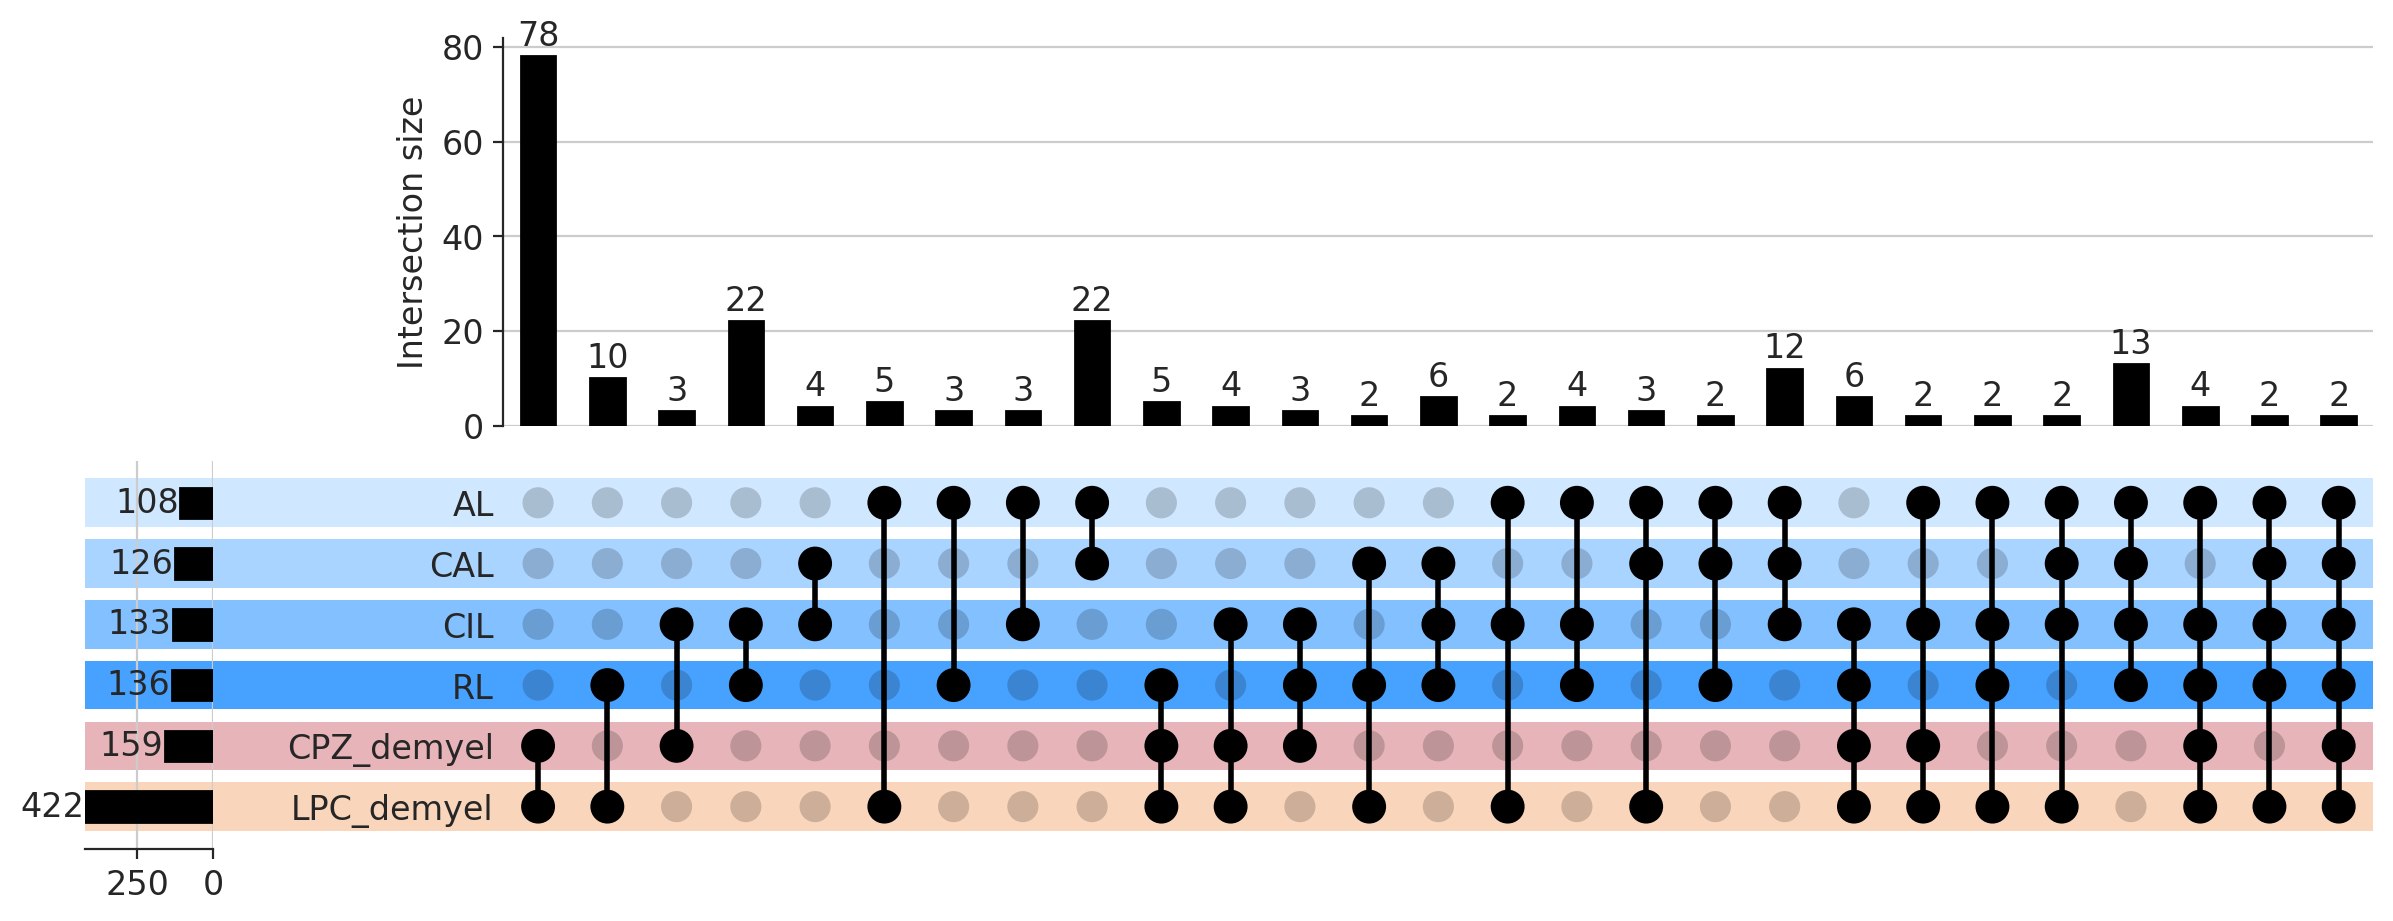

In [99]:
# Create UpSet plot
upset = UpSet(up_df_plot, subset_size='count', show_counts=True, facecolor="black", min_degree=2,
              min_subset_size=2)

# Style the subsets
upset.style_categories(
    'AL',
    shading_facecolor="#cfe7ff",
)

# Style the subsets
upset.style_categories(
    'CAL',
    shading_facecolor="#a9d4ff",
)

# Style the subsets
upset.style_categories(
    'CIL',
    shading_facecolor="#82c0ff",
)

# Style the subsets
upset.style_categories(
    'RL',
    shading_facecolor="#47a2ff",
)

# Style the subsets
upset.style_categories(
    'LPC_demyel',
    shading_facecolor="#f9d5bb",
)

# Style the subsets
upset.style_categories(
    'CPZ_demyel',
    shading_facecolor="#e7b5b9",
)

#upset.style_subsets(present=["CPZ_demyel"], facecolor="#c5183b", label="CPZ overlap")
#upset.style_subsets(present=["CPZ_demyel"], edgecolor="#e12f54", linewidth=4)

# Plot the UpSet plot
upset.plot()
plt.suptitle("")

# Save the plot as PDF
#plt.savefig('./figures/upset_plot_MOL_hs_mm_Cupr_overlap_up_n3_revision.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [100]:
# Convert lists to sets for upregulated genes
set_MOL_AL_up_all = set(genes_MOL_AL_all_up)
set_MOL_CAL_up_all = set(genes_MOL_CAL_all_up)
set_MOL_CIL_up_all = set(genes_MOL_CIL_all_up)
set_MOL_RL_up_all = set(genes_MOL_RL_all_up)

set_LPC_demyel_all_up = set(genes_LPC_demyel_all_up)
set_LPC_remyel_all_up = set(genes_LPC_remyel_all_up)
set_Cupr_demyel_all_up = set(genes_Cupr_demyel_all_up)

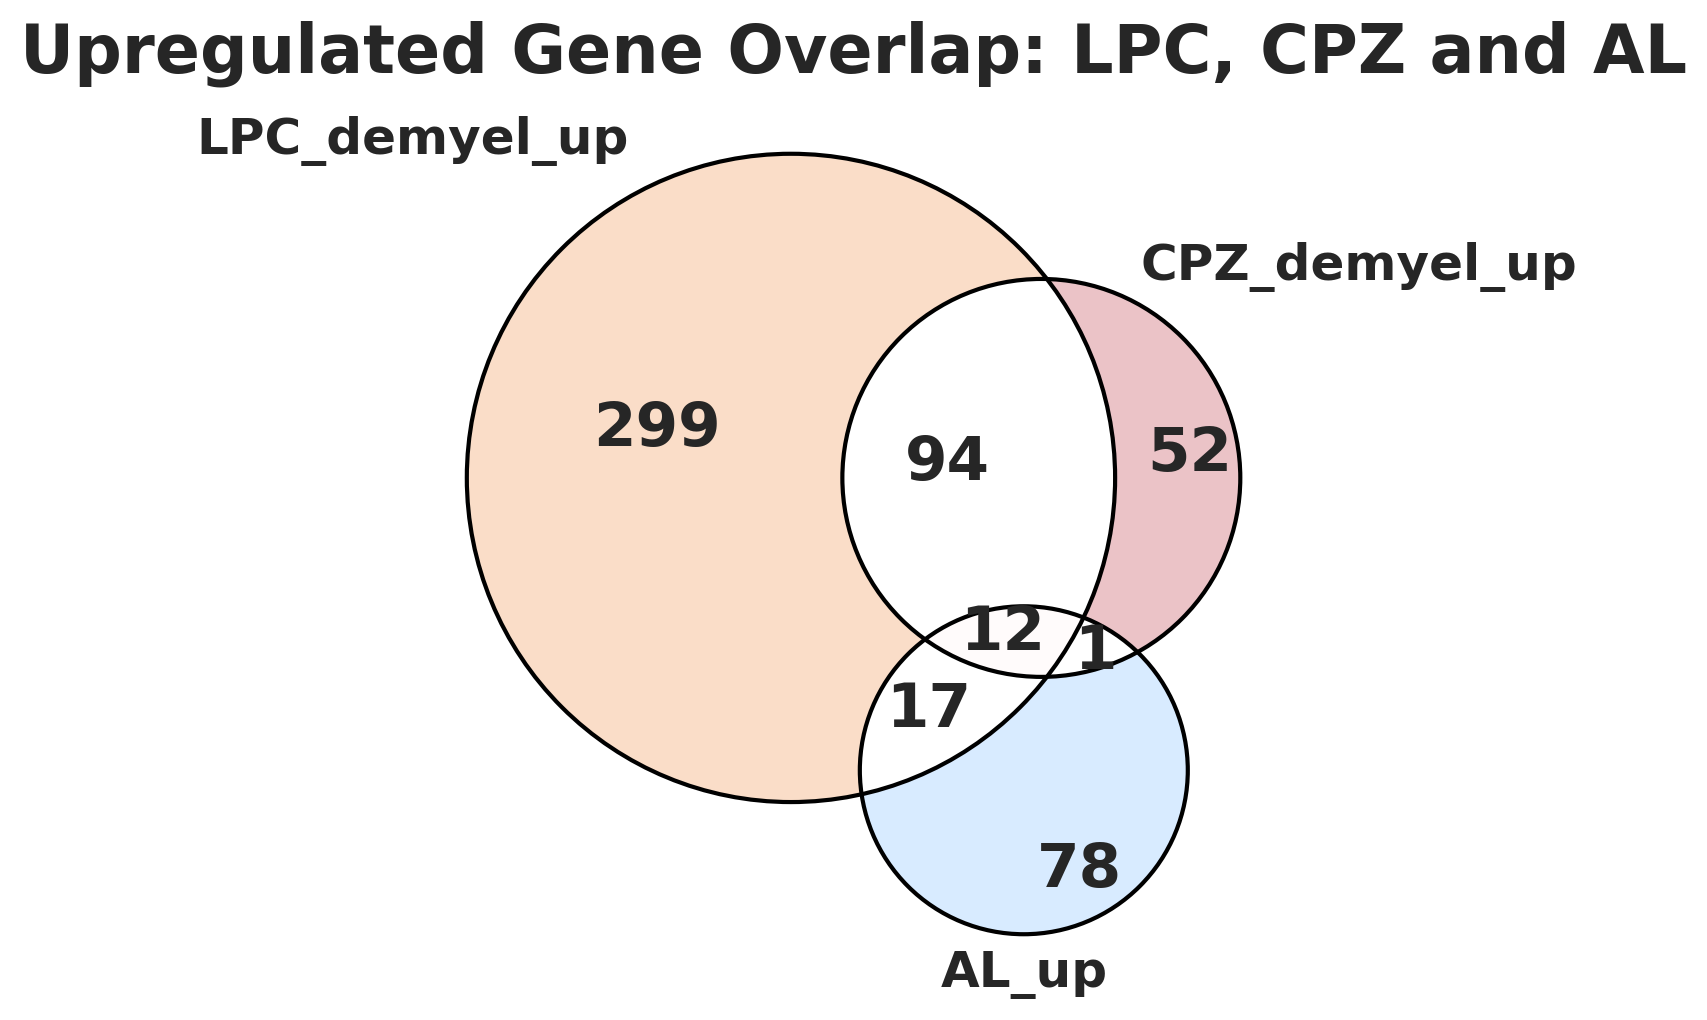

In [101]:
plot_venn3_from_sets(
    set1=set_LPC_demyel_all_up,
    set2=set_Cupr_demyel_all_up,
    set3=set_MOL_AL_up_all,
    labels=('LPC_demyel_up', 'CPZ_demyel_up', 'AL_up'),
    colors=('#f9d5bb', '#e7b5b9', '#cfe7ff'),
    title='Upregulated Gene Overlap: LPC, CPZ and AL',
    #save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

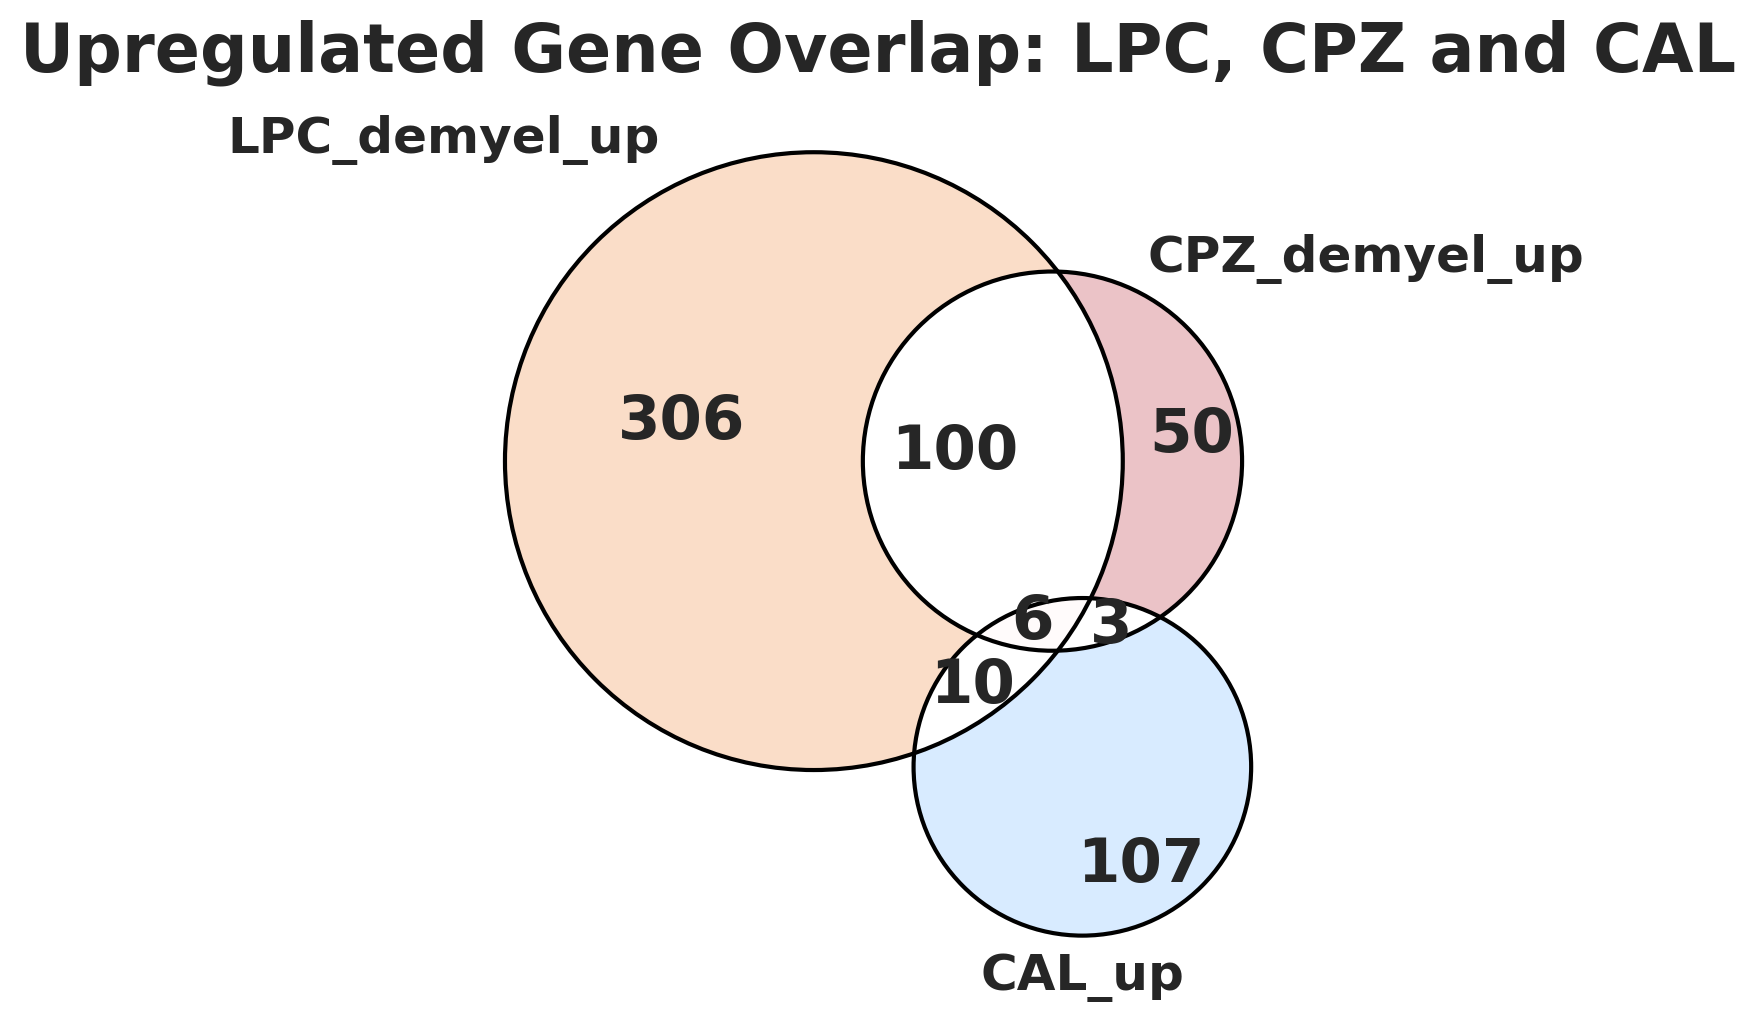

In [102]:
plot_venn3_from_sets(
    set1=set_LPC_demyel_all_up,
    set2=set_Cupr_demyel_all_up,
    set3=set_MOL_CAL_up_all,
    labels=('LPC_demyel_up', 'CPZ_demyel_up', 'CAL_up'),
    colors=('#f9d5bb', '#e7b5b9', '#cfe7ff'),
    title='Upregulated Gene Overlap: LPC, CPZ and CAL',
    #save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

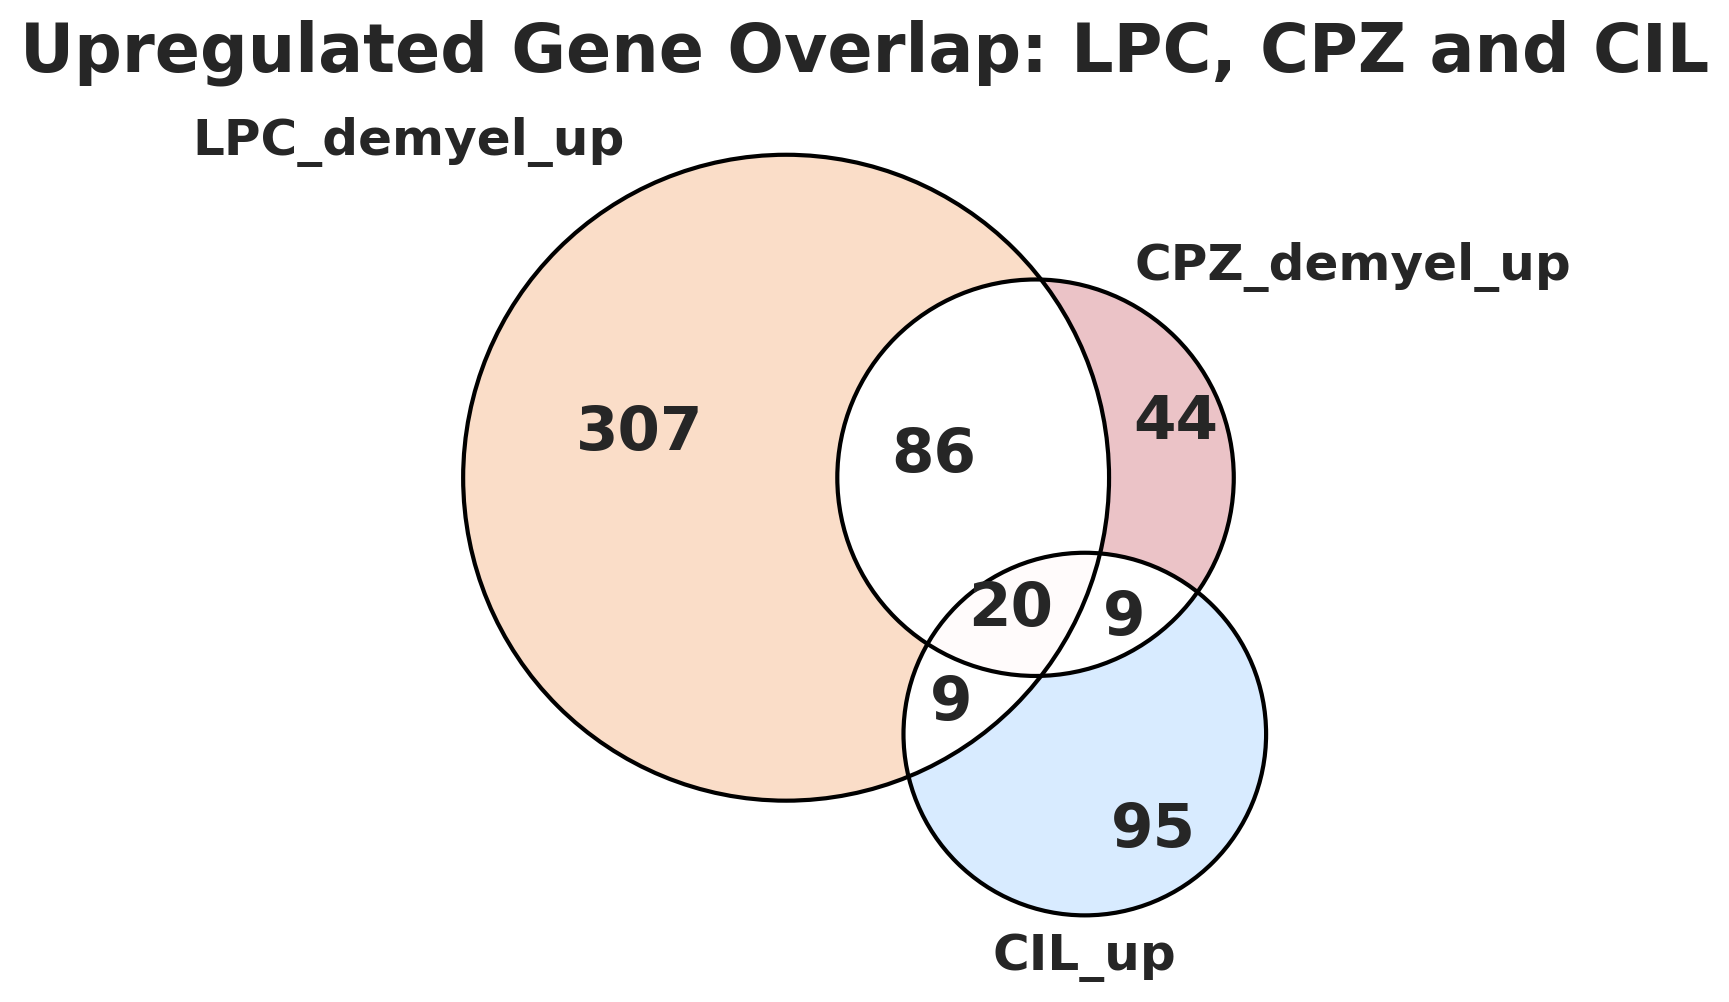

In [103]:
plot_venn3_from_sets(
    set1=set_LPC_demyel_all_up,
    set2=set_Cupr_demyel_all_up,
    set3=set_MOL_CIL_up_all,
    labels=('LPC_demyel_up', 'CPZ_demyel_up', 'CIL_up'),
    colors=('#f9d5bb', '#e7b5b9', '#cfe7ff'),
    title='Upregulated Gene Overlap: LPC, CPZ and CIL',
    #save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

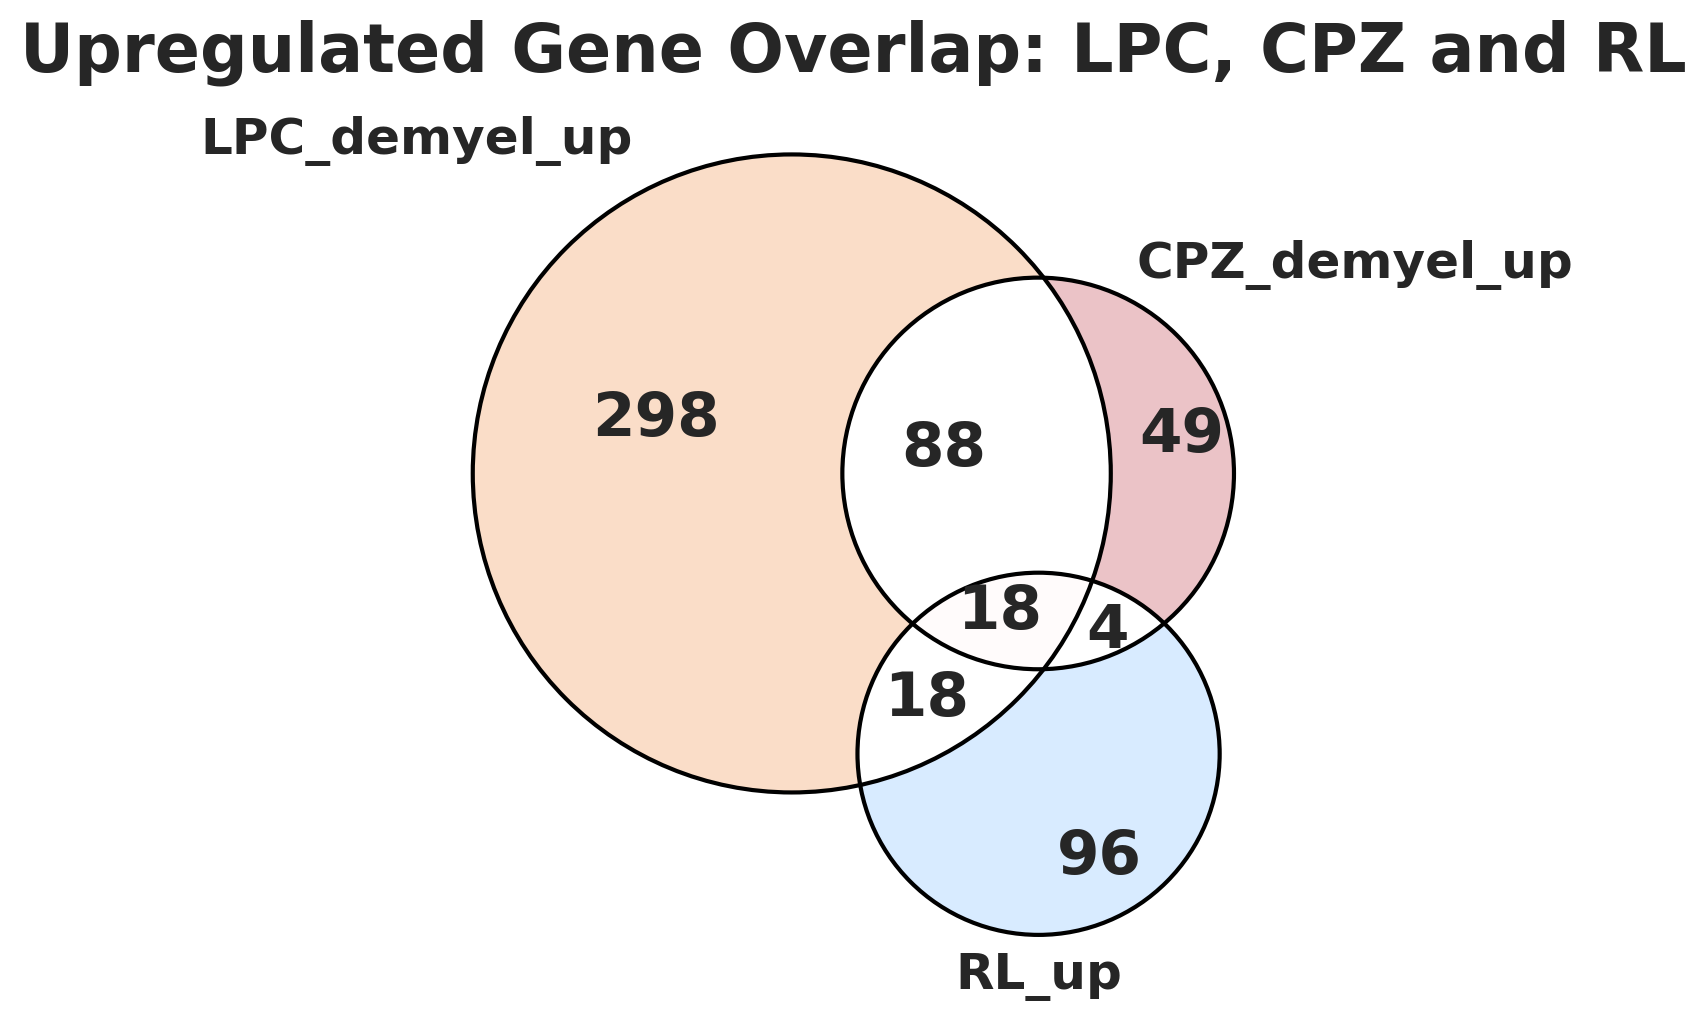

In [104]:
plot_venn3_from_sets(
    set1=set_LPC_demyel_all_up,
    set2=set_Cupr_demyel_all_up,
    set3=set_MOL_RL_up_all,
    labels=('LPC_demyel_up', 'CPZ_demyel_up', 'RL_up'),
    colors=('#f9d5bb', '#e7b5b9', '#cfe7ff'),
    title='Upregulated Gene Overlap: LPC, CPZ and RL',
    #save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

In [206]:
## COMMONE GENES: at least 1 lesion and both CPZ/LPC

# Genes that are common to LPC and Cuprizone demyelination
shared_demyel = set_LPC_demyel_all_up & set_Cupr_demyel_all_up

# Genes present in at least one of the MOL lesion sets
mol_union = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes found in both shared demyelination and at least one MOL lesion
overlap_genes = shared_demyel & mol_union

# Print results
print("Number of overlapping genes:", len(overlap_genes))
print("Overlapping genes:", overlap_genes)

Number of overlapping genes: 27
Overlapping genes: {'FAM20C', 'BST2', 'PLD3', 'FMN1', 'ABCA1', 'LMNB1', 'RAP2B', 'MAN2A1', 'APOC1', 'SH3PXD2B', 'SMIM3', 'APOE', 'LPL', 'CD44', 'CXCL16', 'SNTB2', 'PLIN2', 'GLRX', 'SDC3', 'IQGAP1', 'FABP5', 'VIM', 'LGALS3', 'PKM', 'CD72', 'SASH1', 'PLXNC1'}


In [105]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_MOL_CAL_up_all & set_MOL_CIL_up_all & set_MOL_RL_up_all & set_LPC_demyel_all_up & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 2
Overlapping upregulated genes: {'PLXNC1', 'ST14'}


In [106]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_MOL_CAL_up_all & set_MOL_CIL_up_all & set_MOL_RL_up_all & set_LPC_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 4
Overlapping upregulated genes: {'POLR2F', 'CDK18', 'PLXNC1', 'ST14'}


In [107]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_LPC_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 29
Overlapping upregulated genes: {'POLR2F', 'FAM20C', 'MFSD1', 'ST14', 'BST2', 'FMN1', 'CDK18', 'APOC1', 'APOE', 'MDFIC', 'LPL', 'MRPL18', 'IDH1', 'NPC2', 'CTSZ', 'CD44', 'IGF2R', 'PMP22', 'MYO1E', 'DSE', 'PMVK', 'LAP3', 'TPP1', 'GPR65', 'IQGAP1', 'VIM', 'ARHGAP10', 'SASH1', 'PLXNC1'}


In [108]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_up_all & set_LPC_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 16
Overlapping upregulated genes: {'POLR2F', 'FAM20C', 'IDH1', 'SOD2', 'CTSZ', 'TRPS1', 'GPR65', 'ST14', 'BST2', 'FABP5', 'VIM', 'APP', 'ARHGAP10', 'CDK18', 'MRPL18', 'PLXNC1'}


In [109]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_up_all & set_LPC_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 29
Overlapping upregulated genes: {'POLR2F', 'SLC31A2', 'ST14', 'FMN1', 'CDK18', 'ABCA1', 'LMNB1', 'RAP2B', 'APOC1', 'SH3PXD2B', 'SMIM3', 'MDFIC', 'LPL', 'ARHGAP10', 'CD44', 'IGF2R', 'PMP22', 'MYO1E', 'SNTB2', 'PLIN2', 'GPR65', 'SDC3', 'IQGAP1', 'FABP5', 'VIM', 'LGALS3', 'CD72', 'SASH1', 'PLXNC1'}


In [110]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_up_all & set_LPC_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 36
Overlapping upregulated genes: {'DMXL2', 'POLR2F', 'SLC31A2', 'ST14', 'BST2', 'PLD3', 'EPB41L3', 'CDK18', 'ABCA1', 'MCM6', 'MAN2A1', 'TRPS1', 'APOC1', 'SH3PXD2B', 'SMIM3', 'MDFIC', 'LPL', 'MPHOSPH6', 'PKM', 'SOD2', 'IGF2R', 'CXCL16', 'PLIN2', 'ZNF704', 'GRINA', 'TPP1', 'GLRX', 'PLA2G7', 'SDC3', 'IQGAP1', 'DDX41', 'GUK1', 'CD72', 'SASH1', 'FCER1G', 'PLXNC1'}


In [111]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_MOL_CAL_up_all & set_MOL_CIL_up_all & set_MOL_RL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 2
Overlapping upregulated genes: {'PLXNC1', 'ST14'}


In [112]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 13
Overlapping upregulated genes: {'FAM20C', 'ZFAND2A', 'CD44', 'ST14', 'APOC1', 'BST2', 'IQGAP1', 'APOE', 'FMN1', 'VIM', 'SASH1', 'LPL', 'PLXNC1'}


In [113]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 9
Overlapping upregulated genes: {'FAM20C', 'LDLRAD3', 'ZFAND2A', 'ST14', 'BST2', 'FABP5', 'VIM', 'PIM1', 'PLXNC1'}


In [114]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 29
Overlapping upregulated genes: {'TUBB6', 'FGR', 'ST14', 'FMN1', 'ABCA1', 'LMNB1', 'RAP2B', 'APOC1', 'SH3PXD2B', 'GPX3', 'SMIM3', 'LPL', 'LDLRAD3', 'METRNL', 'CD44', 'SNTB2', 'PLIN2', 'CPT1A', 'ZFAND2A', 'SDC3', 'NOD2', 'IQGAP1', 'SASH1', 'FABP5', 'VIM', 'LGALS3', 'CD72', 'PIM1', 'PLXNC1'}


In [115]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 22
Overlapping upregulated genes: {'FGR', 'ST14', 'BST2', 'PLD3', 'ABCA1', 'MAN2A1', 'APOC1', 'SH3PXD2B', 'SMIM3', 'LPL', 'LDLRAD3', 'METRNL', 'CXCL16', 'PLIN2', 'GLRX', 'SDC3', 'NOD2', 'IQGAP1', 'PKM', 'CD72', 'SASH1', 'PLXNC1'}


In [116]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_LPC_demyel_all_up & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 12
Overlapping upregulated genes: {'FAM20C', 'CD44', 'ST14', 'APOC1', 'BST2', 'IQGAP1', 'APOE', 'FMN1', 'VIM', 'SASH1', 'LPL', 'PLXNC1'}


In [117]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_up_all & set_LPC_demyel_all_up & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 6
Overlapping upregulated genes: {'FAM20C', 'ST14', 'BST2', 'FABP5', 'VIM', 'PLXNC1'}


In [118]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_up_all & set_LPC_demyel_all_up & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 20
Overlapping upregulated genes: {'ST14', 'FMN1', 'ABCA1', 'LMNB1', 'RAP2B', 'APOC1', 'SH3PXD2B', 'SMIM3', 'LPL', 'CD44', 'SNTB2', 'PLIN2', 'SDC3', 'IQGAP1', 'FABP5', 'VIM', 'LGALS3', 'CD72', 'SASH1', 'PLXNC1'}


In [119]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_up_all & set_LPC_demyel_all_up & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 18
Overlapping upregulated genes: {'CD72', 'GLRX', 'MAN2A1', 'ST14', 'APOC1', 'CXCL16', 'BST2', 'PLD3', 'SH3PXD2B', 'SDC3', 'SMIM3', 'IQGAP1', 'PKM', 'PLIN2', 'SASH1', 'ABCA1', 'LPL', 'PLXNC1'}


In [120]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_cupr_not_lpc = (union_AL_CAL_CIL_RL & set_Cupr_demyel_all_up) - set_LPC_demyel_all_up

print("Number of overlapping upregulated genes (Cupr but not LPC):", len(overlap_cupr_not_lpc))
print("Overlapping upregulated genes (Cupr but not LPC):", overlap_cupr_not_lpc)

Number of overlapping upregulated genes (Cupr but not LPC): 9
Overlapping upregulated genes (Cupr but not LPC): {'TUBB6', 'LDLRAD3', 'METRNL', 'ZFAND2A', 'FGR', 'NOD2', 'GPX3', 'CPT1A', 'PIM1'}


In [121]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_lpc_not_cupr = (union_AL_CAL_CIL_RL & set_LPC_demyel_all_up) - set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (LPC but not CPZ):", len(overlap_lpc_not_cupr))
print("Overlapping upregulated genes (LPC but not CPZ):", overlap_lpc_not_cupr)

Number of overlapping upregulated genes (LPC but not CPZ): 31
Overlapping upregulated genes (LPC but not CPZ): {'POLR2F', 'DMXL2', 'MFSD1', 'SLC31A2', 'EPB41L3', 'CDK18', 'MCM6', 'TRPS1', 'MDFIC', 'MRPL18', 'MPHOSPH6', 'IDH1', 'NPC2', 'SOD2', 'CTSZ', 'PMP22', 'IGF2R', 'MYO1E', 'DSE', 'APP', 'PMVK', 'ZNF704', 'GRINA', 'LAP3', 'TPP1', 'PLA2G7', 'DDX41', 'GUK1', 'ARHGAP10', 'FCER1G', 'GPR65'}


In [122]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_lpc_and_cupr = union_AL_CAL_CIL_RL & set_LPC_demyel_all_up & set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (LPC and CPZ):", len(overlap_lpc_and_cupr))
print("Overlapping upregulated genes (LPC and CPZ):", overlap_lpc_and_cupr)

Number of overlapping upregulated genes (LPC and CPZ): 28
Overlapping upregulated genes (LPC and CPZ): {'FAM20C', 'ST14', 'BST2', 'PLD3', 'FMN1', 'ABCA1', 'LMNB1', 'RAP2B', 'MAN2A1', 'APOC1', 'SH3PXD2B', 'SMIM3', 'APOE', 'LPL', 'CD44', 'CXCL16', 'SNTB2', 'PLIN2', 'GLRX', 'SDC3', 'IQGAP1', 'FABP5', 'VIM', 'LGALS3', 'PKM', 'CD72', 'SASH1', 'PLXNC1'}


In [123]:
print("Overlapping upregulated genes (LPC and CPZ):", ", ".join(overlap_lpc_and_cupr))

Overlapping upregulated genes (LPC and CPZ): FAM20C, ST14, BST2, PLD3, FMN1, ABCA1, LMNB1, RAP2B, MAN2A1, APOC1, SH3PXD2B, SMIM3, APOE, LPL, CD44, CXCL16, SNTB2, PLIN2, GLRX, SDC3, IQGAP1, FABP5, VIM, LGALS3, PKM, CD72, SASH1, PLXNC1


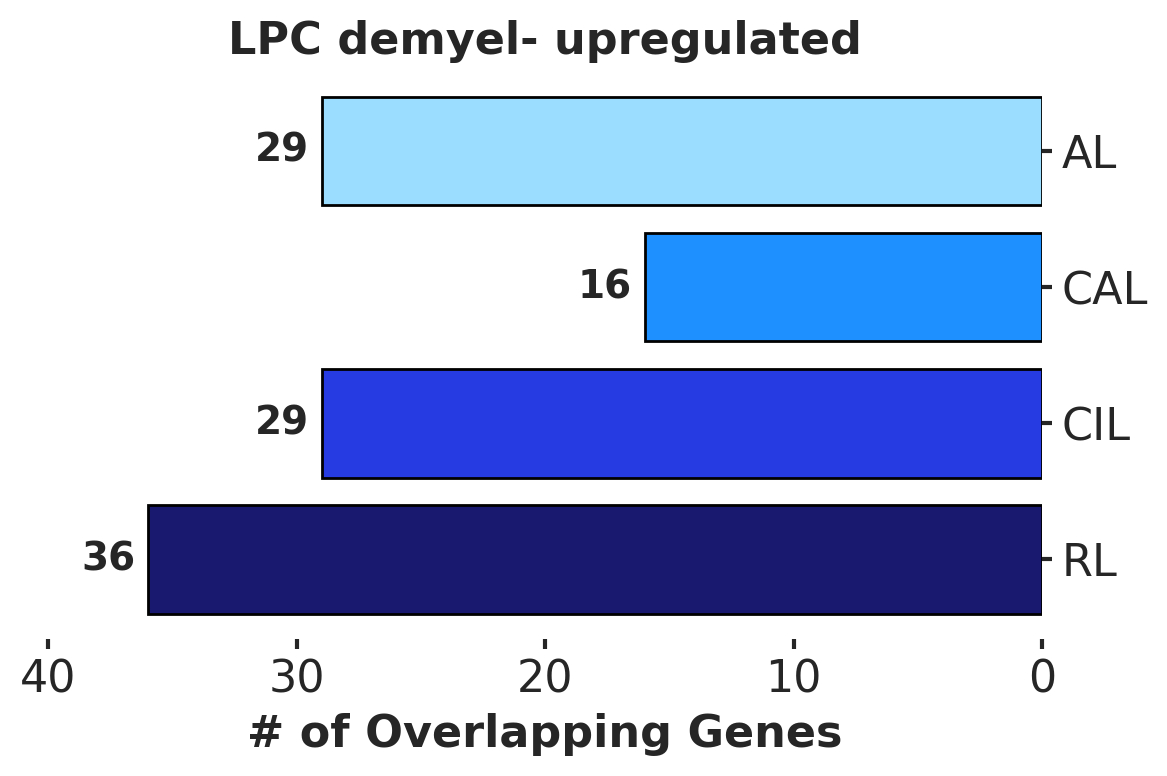

In [128]:
import seaborn as sns

# Lesion names and counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts = [29, 16, 29, 36]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 10, 20, 30, 40])
ax.set_xticklabels(['0', '10', '20', '30', '40'])

# Title
ax.set_title("LPC demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_demyel_MG.png", dpi=300, bbox_inches='tight')

plt.show()

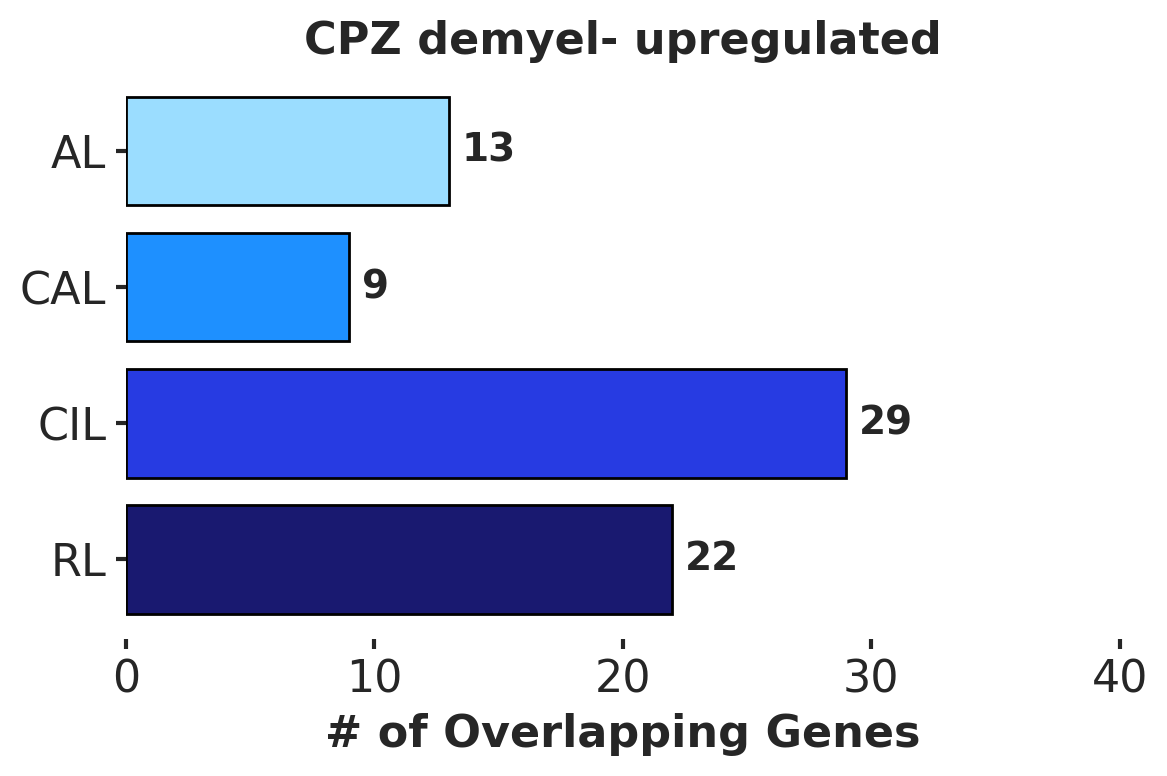

In [129]:
# Lesion names and CPZ counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [13, 9, 29, 22]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 10, 20, 30, 40])
ax.set_xticklabels(['0', '10', '20', '30', '40'])

# Title
ax.set_title("CPZ demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_CPZ_demyel_MG.png", dpi=300, bbox_inches='tight')

plt.show()

## Now down!

In [130]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene'].isin(genes_all)]

# Apply filtering to each DEG DataFrame
MOL_AL_down_all = filter_genes(MOL_AL_down)
MOL_CAL_down_all = filter_genes(MOL_CAL_down)
MOL_CIL_down_all = filter_genes(MOL_CIL_down)
MOL_RL_down_all = filter_genes(MOL_RL_down)

print(MOL_AL_down_all.shape)
print(MOL_CAL_down_all.shape)
print(MOL_CIL_down_all.shape)
print(MOL_RL_down_all.shape)

# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene_hs'].isin(genes_all)]

Cupr_demyel_down_all = filter_genes(Cupr_demyel_down)
LPC_demyel_down_all = filter_genes(LPC_demyel_down)
LPC_remyel_down_all = filter_genes(LPC_remyel_down)

print(Cupr_demyel_down_all.shape)
print(LPC_demyel_down_all.shape)
print(LPC_remyel_down_all.shape)

(96, 5)
(202, 5)
(99, 5)
(96, 5)
(768, 9)
(1012, 9)
(1018, 9)


In [131]:
Anxa2_row = LPC_demyel_down_all[LPC_demyel_down_all['gene'] == 'Anxa2']
print(Anxa2_row)

Empty DataFrame
Columns: [gene, gene_hs, gene_mm, logFC, AveExpr, t, Pvalue, Padj, B]
Index: []


In [132]:
# Create gene lists from the new DataFrames
genes_MOL_AL_all_down = MOL_AL_down_all['gene'].tolist()
genes_MOL_CAL_all_down = MOL_CAL_down_all['gene'].tolist()
genes_MOL_CIL_all_down = MOL_CIL_down_all['gene'].tolist()
genes_MOL_RL_all_down = MOL_RL_down_all['gene'].tolist()

genes_LPC_demyel_all_down = LPC_demyel_down_all['gene_hs'].tolist()
genes_LPC_remyel_all_down = LPC_remyel_down_all['gene_hs'].tolist()
genes_Cupr_demyel_all_down = Cupr_demyel_down_all['gene_hs'].tolist()

In [133]:
# Convert lists to sets for upregulated genes
set_MOL_AL_down_all = set(genes_MOL_AL_all_down)
set_MOL_CAL_down_all = set(genes_MOL_CAL_all_down)
set_MOL_CIL_down_all = set(genes_MOL_CIL_all_down)
set_MOL_RL_down_all = set(genes_MOL_RL_all_down)

set_LPC_demyel_all_down = set(genes_LPC_demyel_all_down)
set_LPC_remyel_all_down = set(genes_LPC_remyel_all_down)
set_Cupr_demyel_all_down = set(genes_Cupr_demyel_all_down)

In [134]:
# Create gene lists from the dfs:
genes_MOL_AL_all_down = MOL_AL_down_all['gene'].tolist()
genes_MOL_CAL_all_down = MOL_CAL_down_all['gene'].tolist()
genes_MOL_CIL_all_down = MOL_CIL_down_all['gene'].tolist()
genes_MOL_RL_all_down = MOL_RL_down_all['gene'].tolist()

# Define the function to create a DataFrame
def create_gene_df(genes_list, column_name):
    return pd.DataFrame(genes_list, columns=[column_name])

# Create DataFrames for each gene list
MOL_AL_all_down_df = create_gene_df(genes_MOL_AL_all_down, 'MOL_AL_all_down')
MOL_CAL_all_down_df = create_gene_df(genes_MOL_CAL_all_down, 'MOL_CAL_all_down')
MOL_CIL_all_down_df = create_gene_df(genes_MOL_CIL_all_down, 'MOL_CIL_all_down')
MOL_RL_all_down_df = create_gene_df(genes_MOL_RL_all_down, 'MOL_RL_all_down')

# Create DataFrames for each gene list
MOL_AL_all_down_df = pd.DataFrame({'MOL_AL_all_down': True, 'Name': genes_MOL_AL_all_down})
MOL_CAL_all_down_df = pd.DataFrame({'MOL_CAL_all_down': True, 'Name': genes_MOL_CAL_all_down})
MOL_CIL_all_down_df = pd.DataFrame({'MOL_CIL_all_down': True, 'Name': genes_MOL_CIL_all_down})
MOL_RL_all_down_df = pd.DataFrame({'MOL_RL_all_down': True, 'Name': genes_MOL_RL_all_down})

In [135]:
# Create gene lists from the dfs:
genes_LPC_demyel_all_down = LPC_demyel_down_all['gene_hs'].tolist()
genes_LPC_remyel_all_down = LPC_remyel_down_all['gene_hs'].tolist()
genes_Cupr_demyel_all_down = Cupr_demyel_down_all['gene_hs'].tolist()

# Define the function to create a DataFrame
def create_gene_df(genes_list, column_name):
    return pd.DataFrame(genes_list, columns=[column_name])

# Create DataFrames for each gene list
LPC_demyel_all_down_df = create_gene_df(genes_LPC_demyel_all_down, 'LPC_demyel_all_down')
LPC_remyel_all_down_df = create_gene_df(genes_LPC_remyel_all_down, 'LPC_remyel_all_down')
Cupr_demyel_all_down_df = create_gene_df(genes_Cupr_demyel_all_down, 'Cupr_demyel_all_down')

# Create DataFrames for each gene list using the new gene lists
#OPC_de_down_df = pd.DataFrame({'OPC_de_down': True, 'Name': genes_OPC_de_down})
LPC_demyel_all_down_df = pd.DataFrame({'LPC_demyel_all_down': True, 'Name': genes_LPC_demyel_all_down})
LPC_remyel_all_down_df = pd.DataFrame({'LPC_remyel_all_down': True, 'Name': genes_LPC_remyel_all_down})
Cupr_demyel_all_down_df = pd.DataFrame({'Cupr_demyel_all_down': True, 'Name': genes_Cupr_demyel_all_down})

In [136]:
# Hierarchically merge all the DataFrames on 'Gene'
down_df = MOL_AL_all_down_df.merge(
    MOL_CAL_all_down_df.merge(
        MOL_CIL_all_down_df.merge(
            MOL_RL_all_down_df.merge(
                LPC_demyel_all_down_df.merge(
                    Cupr_demyel_all_down_df, on='Name', how='outer'
                ), on='Name', how='outer'
            ), on='Name', how='outer'
        ), on='Name', how='outer'
    ), on='Name', how='outer'
)

# Replace NaN with False
down_df = down_df.fillna(False)

# Set 'Gene' as the index (optional, but useful for plotting)
down_df_plot = down_df.set_index([
    'MOL_AL_all_down', 'MOL_CAL_all_down', 'MOL_CIL_all_down', 'MOL_RL_all_down', 'LPC_demyel_all_down', 'Cupr_demyel_all_down'
])

# Print the final merged DataFrame
print("Upregulated genes across all conditions (hierarchically merged):")
print(down_df_plot)

Upregulated genes across all conditions (hierarchically merged):
                                                                                                               Name
MOL_AL_all_down MOL_CAL_all_down MOL_CIL_all_down MOL_RL_all_down LPC_demyel_all_down Cupr_demyel_all_down         
False           False            False            False           False               True                    ABCC3
True            True             True             True            False               False                   ABCC4
False           False            False            False           True                True                    ABCG2
                                                                                      True                   ABHD15
                                                                                      False                   ABHD2
...                                                                                                             ...
       

/tmp/2271180.1.long/ipykernel_2089480/3050655249.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  down_df = down_df.fillna(False)


In [137]:
# Dictionary to map old index names to new index names
index_name_map = {
    'MOL_AL_all_down': 'AL',
    'MOL_CAL_all_down': 'CAL',
    'MOL_CIL_all_down': 'CIL',
    'MOL_RL_all_down': 'RL',
    'LPC_demyel_all_down': 'LPC_demyel',
    'Cupr_demyel_all_down': 'CPZ_demyel',
}

# Rename the index levels using the dictionary
down_df_plot.index = down_df_plot.index.rename(index_name_map)

print("Updated Upregulated genes DataFrame:")
print(down_df_plot)

Updated Upregulated genes DataFrame:
                                                  Name
AL    CAL   CIL   RL    LPC_demyel CPZ_demyel         
False False False False False      True          ABCC3
True  True  True  True  False      False         ABCC4
False False False False True       True          ABCG2
                                   True         ABHD15
                                   False         ABHD2
...                                                ...
                                   True         ZRANB1
                                   True        ZSCAN18
                                   False       ZSCAN21
True  False False False True       False        ZSWIM6
False False False False True       False           ZYX

[1425 rows x 1 columns]


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

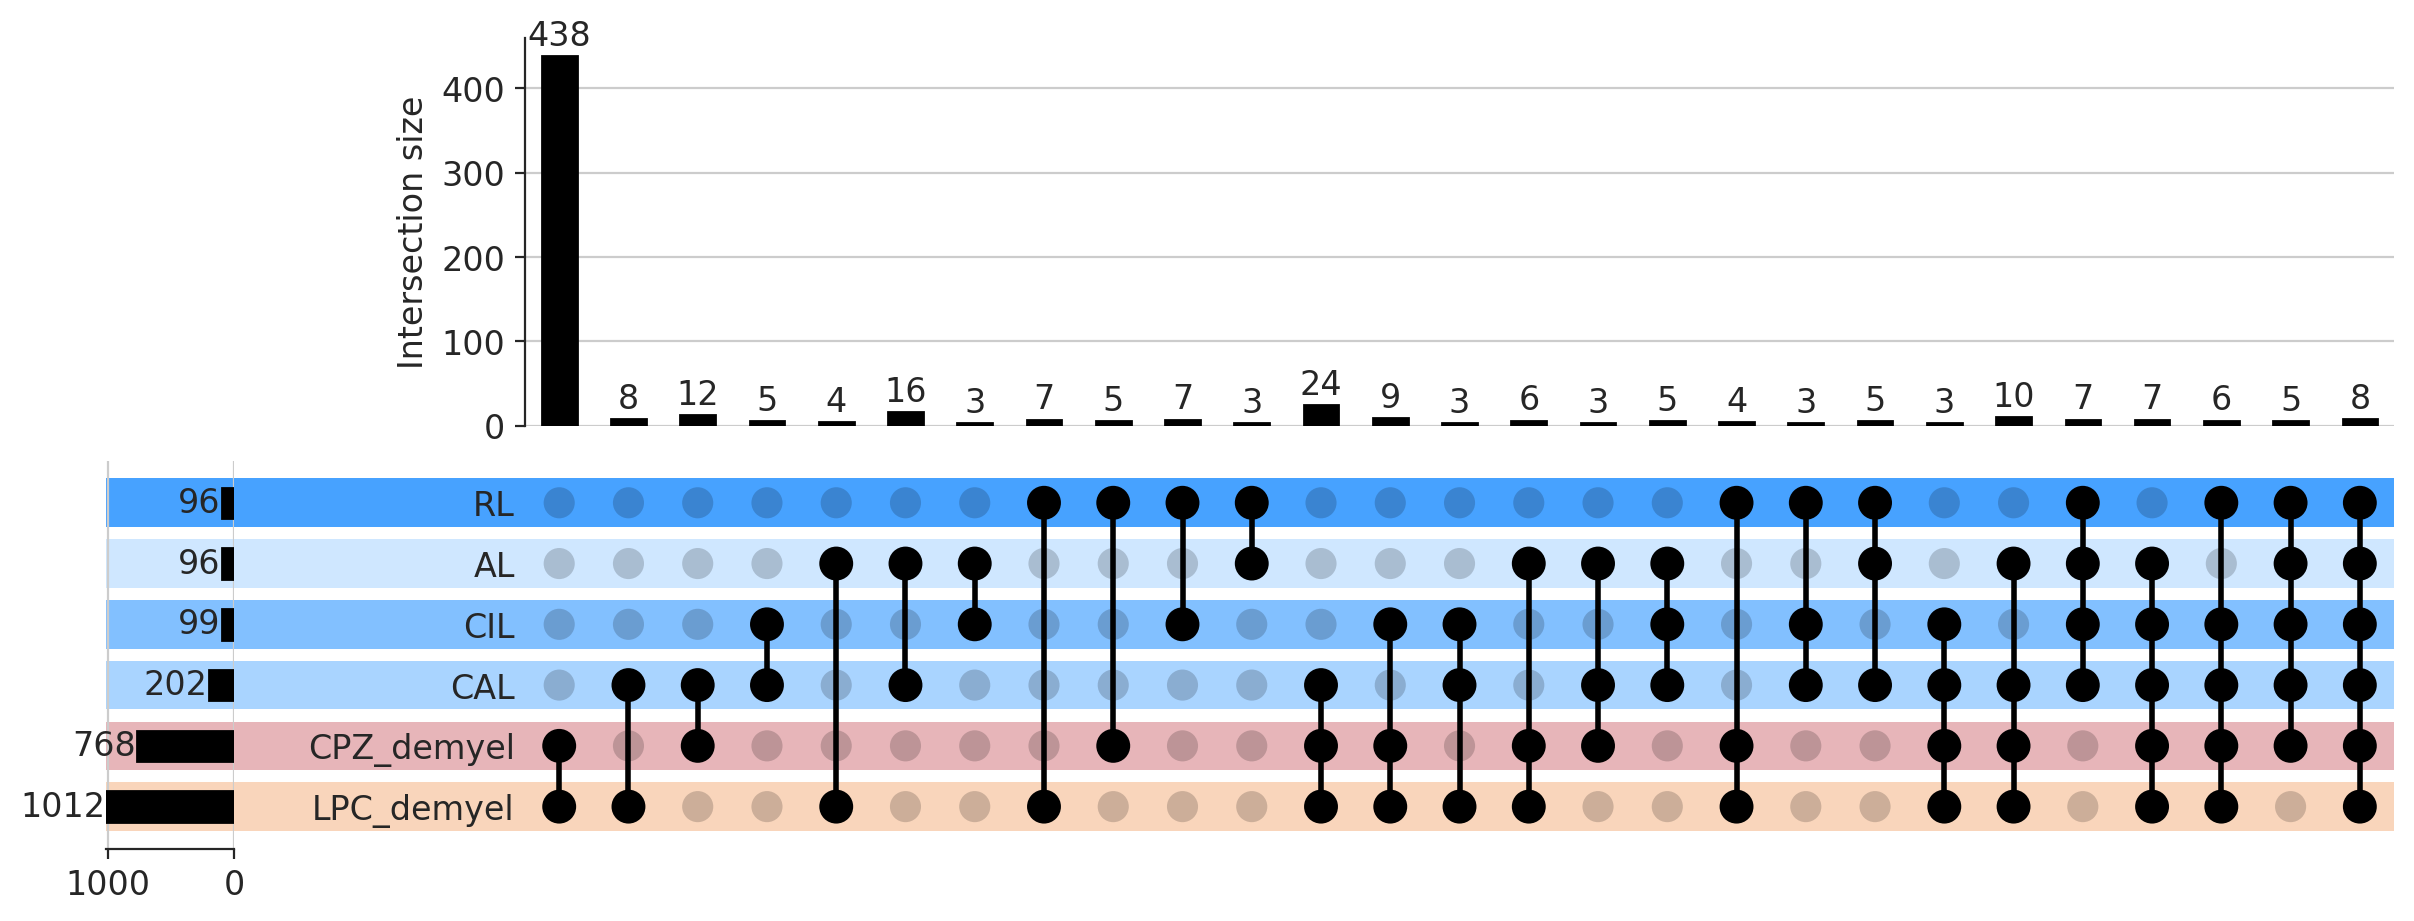

In [138]:
# Create UpSet plot
upset = UpSet(down_df_plot, subset_size='count', show_counts=True, facecolor="black", min_degree=2,
              min_subset_size=3)

# Style the subsets
upset.style_categories(
    'AL',
    shading_facecolor="#cfe7ff",
)

# Style the subsets
upset.style_categories(
    'CAL',
    shading_facecolor="#a9d4ff",
)

# Style the subsets
upset.style_categories(
    'CIL',
    shading_facecolor="#82c0ff",
)

# Style the subsets
upset.style_categories(
    'RL',
    shading_facecolor="#47a2ff",
)

# Style the subsets
upset.style_categories(
    'LPC_demyel',
    shading_facecolor="#f9d5bb",
)

# Style the subsets
upset.style_categories(
    'CPZ_demyel',
    shading_facecolor="#e7b5b9",
)

#upset.style_subsets(present=["CPZ_demyel"], facecolor="#c5183b", label="CPZ overlap")
#upset.style_subsets(present=["CPZ_demyel"], edgecolor="#e12f54", linewidth=4)

# Plot the UpSet plot
upset.plot()
plt.suptitle("")

# Save the plot as PDF
#plt.savefig('./figures/upset_plot_MOL_hs_mm_Cupr_overlap_down_n3_revision.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

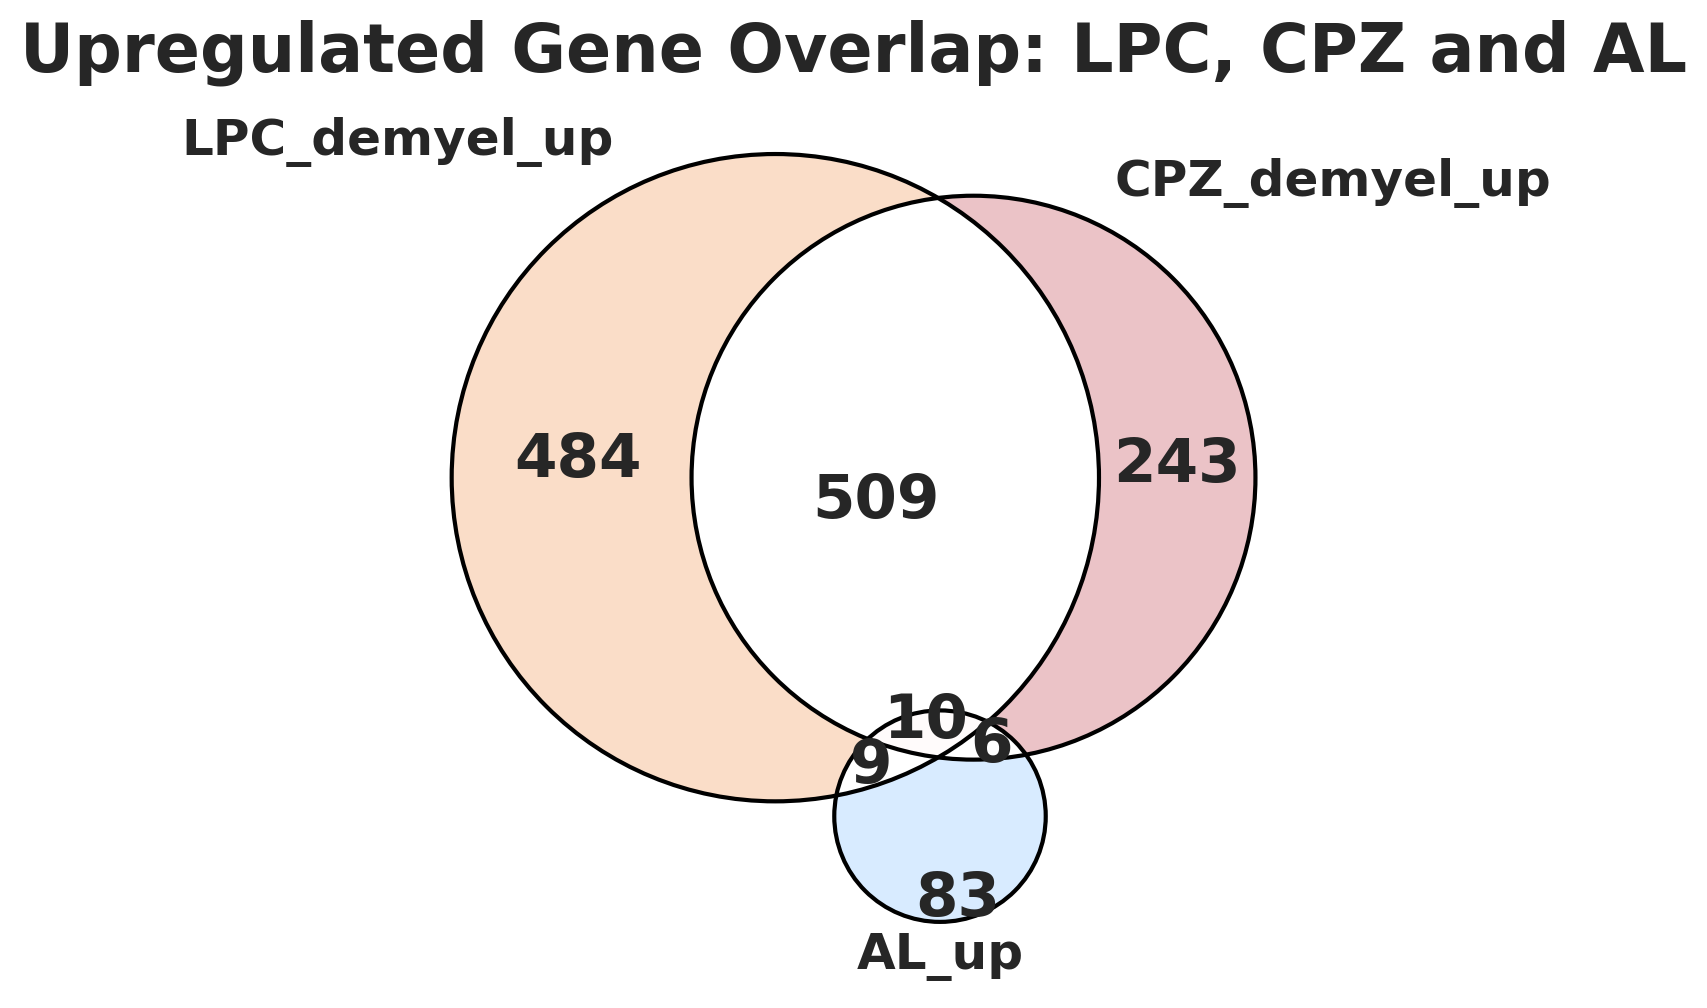

In [158]:
plot_venn3_from_sets(
    set1=set_LPC_demyel_all_down,
    set2=set_Cupr_demyel_all_down,
    set3=set_MOL_AL_up_all,
    labels=('LPC_demyel_up', 'CPZ_demyel_up', 'AL_up'),
    colors=('#f9d5bb', '#e7b5b9', '#cfe7ff'),
    title='Upregulated Gene Overlap: LPC, CPZ and AL',
    #save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

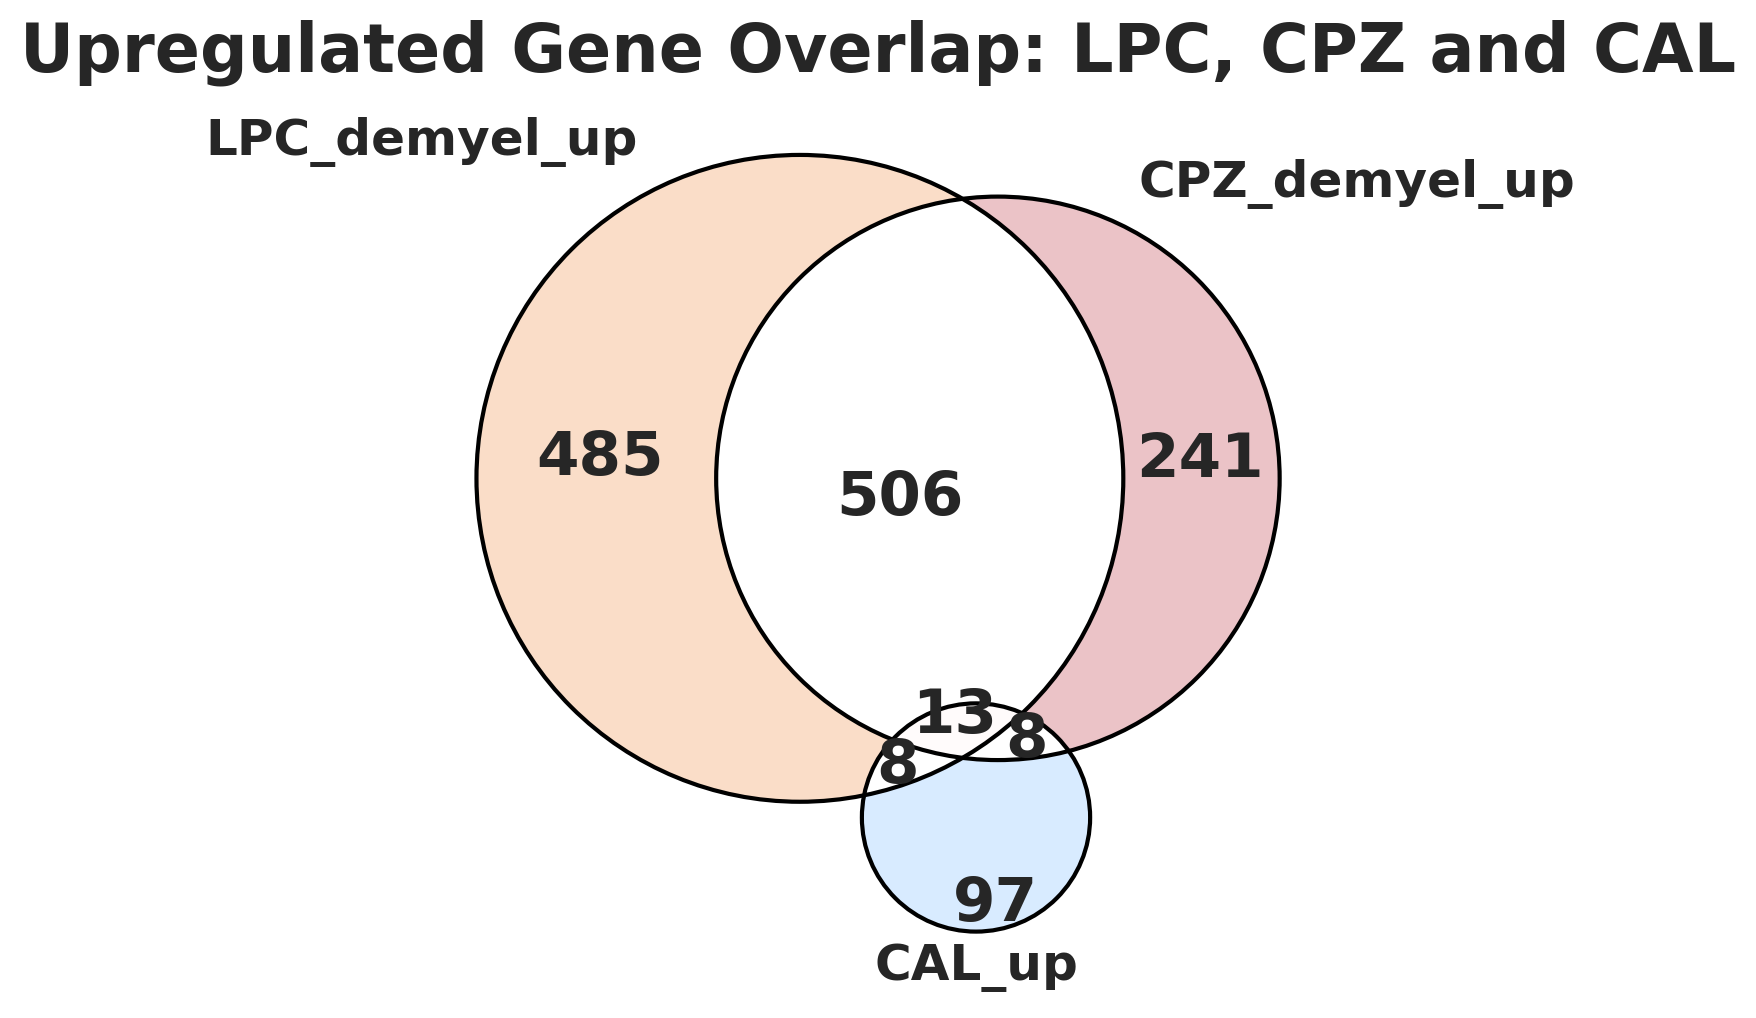

In [159]:
plot_venn3_from_sets(
    set1=set_LPC_demyel_all_down,
    set2=set_Cupr_demyel_all_down,
    set3=set_MOL_CAL_up_all,
    labels=('LPC_demyel_up', 'CPZ_demyel_up', 'CAL_up'),
    colors=('#f9d5bb', '#e7b5b9', '#cfe7ff'),
    title='Upregulated Gene Overlap: LPC, CPZ and CAL',
    #save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

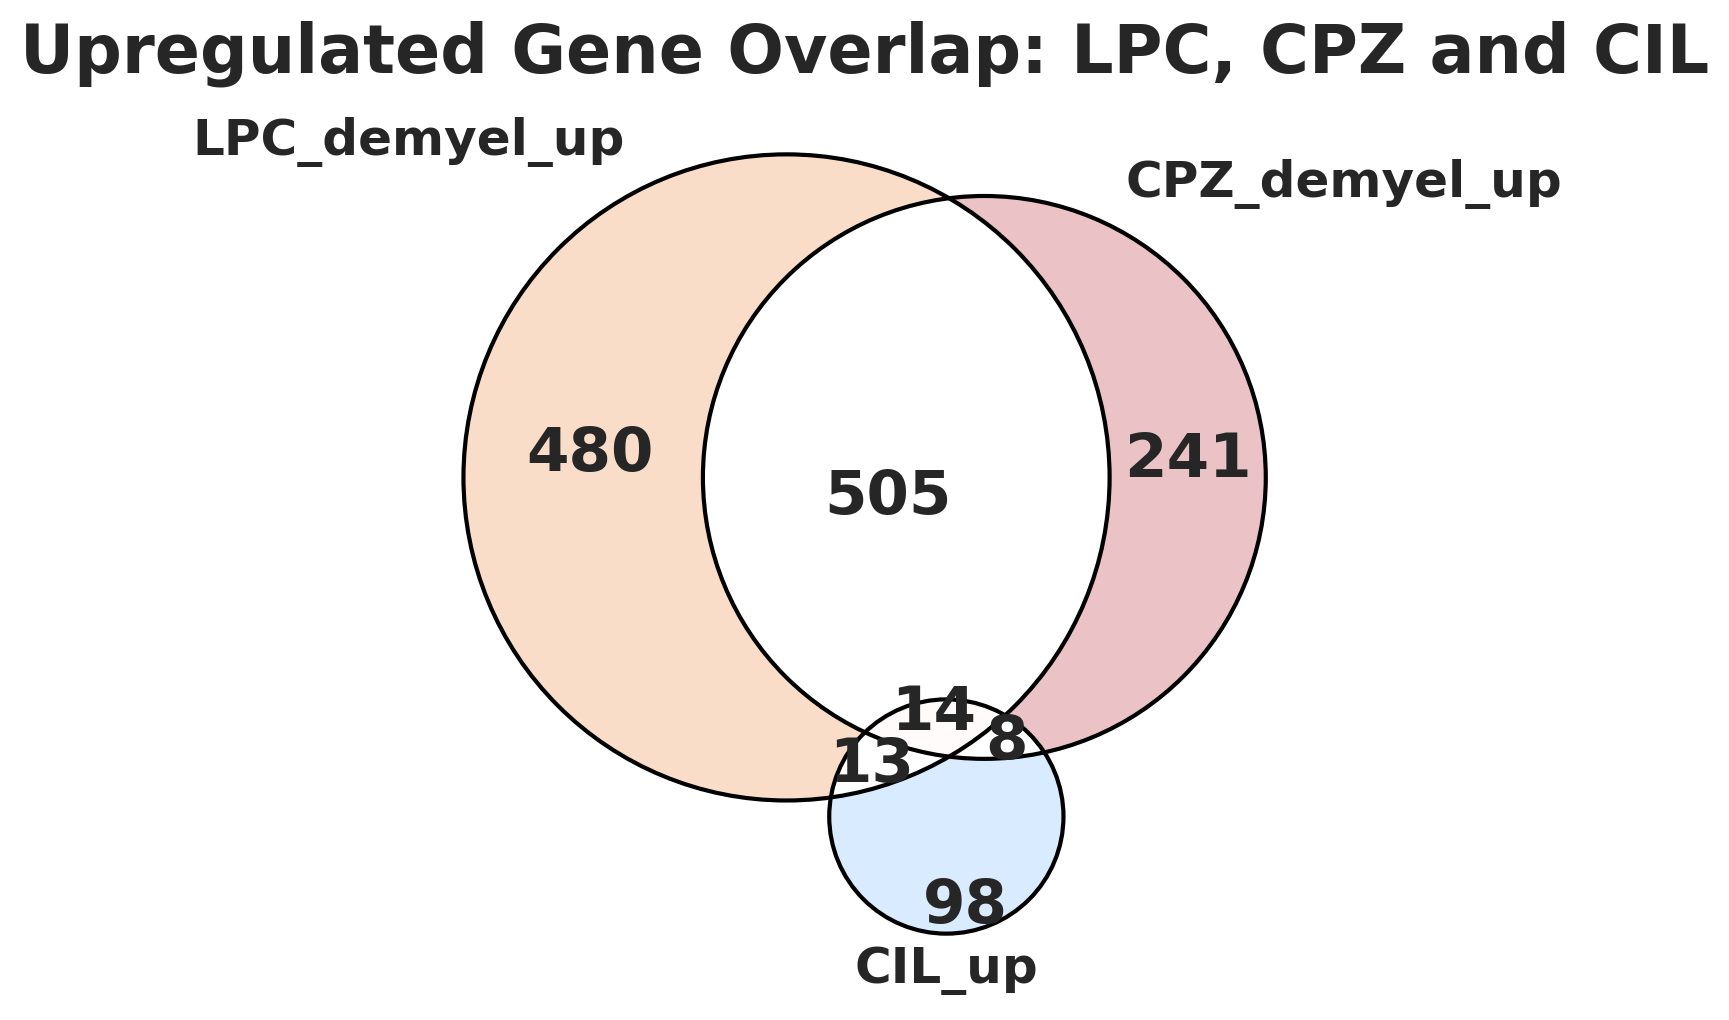

In [160]:
plot_venn3_from_sets(
    set1=set_LPC_demyel_all_down,
    set2=set_Cupr_demyel_all_down,
    set3=set_MOL_CIL_up_all,
    labels=('LPC_demyel_up', 'CPZ_demyel_up', 'CIL_up'),
    colors=('#f9d5bb', '#e7b5b9', '#cfe7ff'),
    title='Upregulated Gene Overlap: LPC, CPZ and CIL',
    #save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

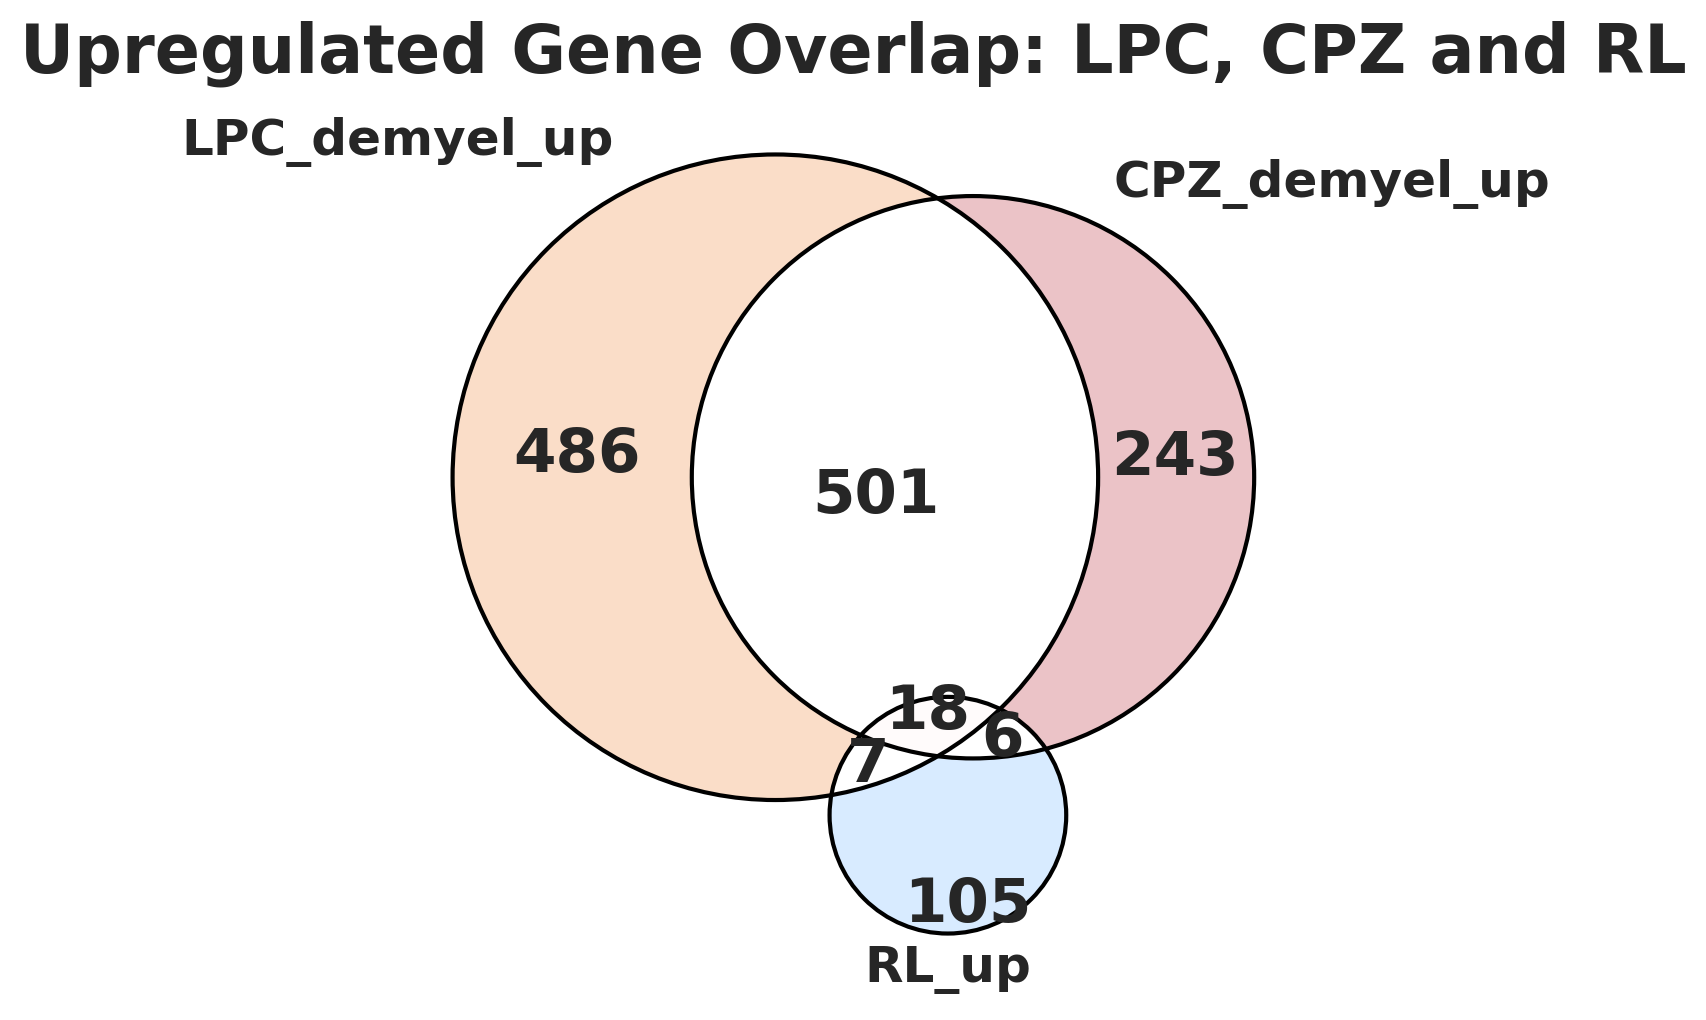

In [161]:
plot_venn3_from_sets(
    set1=set_LPC_demyel_all_down,
    set2=set_Cupr_demyel_all_down,
    set3=set_MOL_RL_up_all,
    labels=('LPC_demyel_up', 'CPZ_demyel_up', 'RL_up'),
    colors=('#f9d5bb', '#e7b5b9', '#cfe7ff'),
    title='Upregulated Gene Overlap: LPC, CPZ and RL',
    #save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

In [205]:
## COMMONE GENES: at least 1 lesion and both CPZ/LPC

# Genes that are common to LPC and Cuprizone demyelination
shared_demyel = set_LPC_demyel_all_down & set_Cupr_demyel_all_down

# Genes present in at least one of the MOL lesion sets
mol_union = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes found in both shared demyelination and at least one MOL lesion
overlap_genes = shared_demyel & mol_union

# Print results
print("Number of overlapping genes:", len(overlap_genes))
print("Overlapping genes:", overlap_genes)

Number of overlapping genes: 77
Overlapping genes: {'FMNL3', 'PRKN', 'HPGDS', 'PTGS1', 'C4orf19', 'NAV3', 'PER3', 'CYB561A3', 'SALL1', 'TTC7A', 'BANK1', 'BACH2', 'DBP', 'CTTNBP2NL', 'P3H2', 'MGLL', 'NHS', 'UST', 'MORN1', 'PLD4', 'IFNGR1', 'TAL1', 'FGD2', 'CX3CR1', 'B3GNT2', 'P2RY12', 'PLD1', 'SUSD3', 'TBC1D9', 'DOCK4', 'PHF7', 'TK2', 'ULK2', 'NOS1AP', 'BCO2', 'GSDME', 'CHKA', 'FRMD4A', 'PRDM11', 'VRK2', 'RNF19B', 'SNX29', 'PALD1', 'OPRM1', 'DUSP7', 'ADRB2', 'DIPK1A', 'GARNL3', 'ZFP36L2', 'MEF2A', 'MGME1', 'CACNB2', 'TLN2', 'DOCK8', 'ARAP3', 'AP1B1', 'MED12L', 'SDK1', 'SRSF5', 'ANKRD44', 'DNHD1', 'PBX1', 'FAM117B', 'NR1D2', 'ENTPD1', 'ARID3B', 'DGKA', 'INPP5D', 'LPCAT2', 'ITGAM', 'RTN4RL1', 'PTPRO', 'WSB1', 'VCL', 'DDB2', 'OSBPL11', 'TIAM1'}


In [139]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_MOL_CAL_down_all & set_MOL_CIL_down_all & set_MOL_RL_down_all & set_LPC_demyel_all_down & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 8
Overlapping upregulated genes: {'FMNL3', 'CACNB2', 'PTGS1', 'TLN2', 'BANK1', 'NOS1AP', 'PRDM11', 'PER3'}


In [140]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_MOL_CAL_down_all & set_MOL_CIL_down_all & set_MOL_RL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 8
Overlapping upregulated genes: {'FMNL3', 'CACNB2', 'TLN2', 'PTGS1', 'BANK1', 'NOS1AP', 'PRDM11', 'PER3'}


In [141]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 42
Overlapping upregulated genes: {'FMNL3', 'UST', 'PBX1', 'FAM117B', 'PTGS1', 'IFNGR1', 'TAL1', 'C4orf19', 'NAV3', 'PER3', 'MEF2C', 'SH2D3C', 'SALL1', 'ENTPD1', 'ZFP36L2', 'CACNB2', 'MGME1', 'TLN2', 'TTC7A', 'BANK1', 'DGKA', 'MMP28', 'BACH2', 'TBC1D9', 'MLXIPL', 'ATXN7L3', 'DOCK4', 'CTTNBP2NL', 'ZFP36L1', 'P3H2', 'ZEB1', 'SDK1', 'MED12L', 'VCL', 'PLCL2', 'ANKRD44', 'DDB2', 'NOS1AP', 'ZSWIM6', 'FRMD4A', 'PRDM11', 'PLA2G4A'}


In [142]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 77
Overlapping upregulated genes: {'FMNL3', 'PRKN', 'PTGS1', 'SERPINF1', 'LDLRAD4', 'C4orf19', 'PER3', 'SALL1', 'TTC7A', 'BANK1', 'ERMAP', 'DBP', 'CTTNBP2NL', 'P3H2', 'MGLL', 'RSRP1', 'CSF3R', 'MORN1', 'PLD4', 'IFNGR1', 'FGD2', 'CX3CR1', 'M1AP', 'ABI1', 'PLD1', 'SUSD3', 'TBC1D9', 'DOCK4', 'PHF7', 'TK2', 'HNRNPDL', 'ULK2', 'NOS1AP', 'GSDME', 'CHKA', 'RFFL', 'FRMD4A', 'PRDM11', 'VRK2', 'RNF19B', 'SNX29', 'PALD1', 'PRKCH', 'OPRM1', 'CAMK1D', 'DIPK1A', 'ADRB2', 'CACNB2', 'MEF2A', 'ZFP36L2', 'TLN2', 'FOS', 'EML4', 'DOCK8', 'MLXIPL', 'AP1B1', 'RAB2B', 'MED12L', 'SRSF5', 'ANKRD44', 'DNHD1', 'FAM117B', 'NR1D2', 'ENTPD1', 'ARID3B', 'PRKCD', 'RGS10', 'MMP28', 'INPP5D', 'PTPRO', 'ZEB1', 'WSB1', 'VCL', 'OSBPL11', 'DDB2', 'TIAM1', 'PLA2G4A'}


In [143]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 42
Overlapping upregulated genes: {'FMNL3', 'HPGDS', 'PTGS1', 'MORN1', 'PLD4', 'IFNGR1', 'TAL1', 'CX3CR1', 'C4orf19', 'M1AP', 'SMAD6', 'B3GNT2', 'NAV3', 'PER3', 'P2RY12', 'OPRM1', 'CAMK1D', 'CYB561A3', 'SALL1', 'DUSP7', 'DIPK1A', 'ADRB2', 'CACNB2', 'TLN2', 'BANK1', 'RGS10', 'MMP28', 'FOS', 'SUSD3', 'DBP', 'KHDRBS3', 'ARAP3', 'CTTNBP2NL', 'ZFP36L1', 'RTN4RL1', 'LRRK1', 'P3H2', 'MED12L', 'TIAM1', 'NOS1AP', 'BCO2', 'PRDM11'}


In [144]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 36
Overlapping upregulated genes: {'FMNL3', 'PTGS1', 'TLR7', 'PLD4', 'PALD1', 'TAL1', 'CX3CR1', 'GLCCI1', 'NAV3', 'PER3', 'SH2D3C', 'NOL4L', 'OPRM1', 'DIPK1A', 'DDIT3', 'GARNL3', 'CACNB2', 'TLN2', 'PRKCD', 'BANK1', 'RGS10', 'KLF12', 'SUSD3', 'DBP', 'EML4', 'MLXIPL', 'LPCAT2', 'ITGAM', 'ZFP36L1', 'LRRK1', 'MGLL', 'EPB41L2', 'IPCEF1', 'NOS1AP', 'NHS', 'PRDM11'}


In [145]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_MOL_CAL_down_all & set_MOL_CIL_down_all & set_MOL_RL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 13
Overlapping upregulated genes: {'STRBP', 'TRIM36', 'FMNL3', 'CACNB2', 'OTULINL', 'TLN2', 'PTGS1', 'BANK1', 'NOS1AP', 'PLXDC1', 'PRDM11', 'PER3', 'OXR1'}


In [146]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 41
Overlapping upregulated genes: {'FMNL3', 'UST', 'CCDC146', 'PBX1', 'FAM117B', 'PTGS1', 'IFNGR1', 'TAL1', 'FADS1', 'C4orf19', 'NAV3', 'PER3', 'SALL1', 'ENTPD1', 'ZFP36L2', 'CACNB2', 'MGME1', 'TLN2', 'TTC7A', 'BANK1', 'DGKA', 'MMP28', 'BACH2', 'TBC1D9', 'OXR1', 'DOCK4', 'CTTNBP2NL', 'P3H2', 'OTULINL', 'PLXDC1', 'SDK1', 'MED12L', 'SRC', 'VCL', 'TRIM36', 'ANKRD44', 'DDB2', 'NOS1AP', 'FRMD4A', 'PRDM11', 'STRBP'}


In [147]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 81
Overlapping upregulated genes: {'PPFIBP2', 'FMNL3', 'PRKN', 'PTGS1', 'SERPINF1', 'C4orf19', 'ADCK2', 'PER3', 'SALL1', 'TTC7A', 'BANK1', 'ERMAP', 'DBP', 'PPP6R2', 'OXR1', 'C4orf33', 'CTTNBP2NL', 'P3H2', 'MGLL', 'SLC44A2', 'CCDC146', 'MORN1', 'PLD4', 'IFNGR1', 'FGD2', 'CX3CR1', 'PLD1', 'SUSD3', 'TBC1D9', 'DOCK4', 'PHF7', 'TK2', 'SRC', 'ULK2', 'ZHX3', 'NOS1AP', 'GSDME', 'CHKA', 'FRMD4A', 'PRDM11', 'VRK2', 'RNF19B', 'SNX29', 'PALD1', 'FADS1', 'OPRM1', 'DIPK1A', 'ADRB2', 'CACNB2', 'MEF2A', 'ZFP36L2', 'TLN2', 'DOCK8', 'AP1B1', 'RALGPS1', 'PLXDC1', 'MED12L', 'SRSF5', 'TRIM36', 'ANKRD44', 'DNHD1', 'TRPV2', 'STRBP', 'RHOT2', 'DENND6A', 'FAM117B', 'KLF3', 'NR1D2', 'ENTPD1', 'ARID3B', 'CIRBP', 'MMP28', 'INPP5D', 'OTULINL', 'PTPRO', 'WSB1', 'VCL', 'OSBPL11', 'DDB2', 'TIAM1', 'H6PD'}


In [148]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 43
Overlapping upregulated genes: {'FMNL3', 'HPGDS', 'PTGS1', 'MORN1', 'PLD4', 'IFNGR1', 'TAL1', 'CX3CR1', 'C4orf19', 'B3GNT2', 'ADCK2', 'NAV3', 'PER3', 'P2RY12', 'OPRM1', 'DUSP7', 'CYB561A3', 'SALL1', 'DIPK1A', 'ADRB2', 'CACNB2', 'TLN2', 'BANK1', 'MMP28', 'SUSD3', 'DBP', 'OXR1', 'KHDRBS3', 'ARAP3', 'CTTNBP2NL', 'RTN4RL1', 'P3H2', 'OTULINL', 'PLXDC1', 'IL6ST', 'MED12L', 'TRIM36', 'TIAM1', 'GAL3ST4', 'NOS1AP', 'BCO2', 'PRDM11', 'STRBP'}


In [149]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 34
Overlapping upregulated genes: {'FMNL3', 'PTGS1', 'PLD4', 'PALD1', 'TAL1', 'CX3CR1', 'NAV3', 'PER3', 'OPRM1', 'DIPK1A', 'GARNL3', 'CACNB2', 'TLN2', 'BANK1', 'SUSD3', 'DBP', 'OXR1', 'LPCAT2', 'ITGAM', 'NCF1', 'DNAJC18', 'OTULINL', 'MGLL', 'CARD9', 'PLXDC1', 'IL6ST', 'TRIM36', 'MIPOL1', 'GAL3ST4', 'NOS1AP', 'NHS', 'RASAL2', 'PRDM11', 'STRBP'}


In [150]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_LPC_demyel_all_down & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 33
Overlapping upregulated genes: {'FMNL3', 'UST', 'PBX1', 'FAM117B', 'PTGS1', 'IFNGR1', 'TAL1', 'C4orf19', 'NAV3', 'PER3', 'SALL1', 'ENTPD1', 'ZFP36L2', 'CACNB2', 'MGME1', 'TLN2', 'TTC7A', 'BANK1', 'DGKA', 'MMP28', 'BACH2', 'TBC1D9', 'DOCK4', 'CTTNBP2NL', 'P3H2', 'SDK1', 'MED12L', 'VCL', 'ANKRD44', 'DDB2', 'NOS1AP', 'FRMD4A', 'PRDM11'}


In [151]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_down_all & set_LPC_demyel_all_down & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 60
Overlapping upregulated genes: {'VRK2', 'FMNL3', 'PRKN', 'FAM117B', 'SERPINF1', 'PTGS1', 'MORN1', 'PLD4', 'RNF19B', 'SNX29', 'PALD1', 'IFNGR1', 'FGD2', 'CX3CR1', 'C4orf19', 'PER3', 'OPRM1', 'SALL1', 'DIPK1A', 'ADRB2', 'NR1D2', 'ENTPD1', 'CACNB2', 'MEF2A', 'ZFP36L2', 'ARID3B', 'PLD1', 'TLN2', 'TTC7A', 'BANK1', 'ERMAP', 'MMP28', 'SUSD3', 'DBP', 'DOCK8', 'INPP5D', 'TBC1D9', 'DOCK4', 'CTTNBP2NL', 'P3H2', 'PHF7', 'AP1B1', 'MGLL', 'PTPRO', 'TK2', 'MED12L', 'SRSF5', 'WSB1', 'VCL', 'ANKRD44', 'OSBPL11', 'DDB2', 'TIAM1', 'ULK2', 'NOS1AP', 'GSDME', 'CHKA', 'DNHD1', 'FRMD4A', 'PRDM11'}


In [152]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_down_all & set_LPC_demyel_all_down & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 35
Overlapping upregulated genes: {'FMNL3', 'HPGDS', 'PTGS1', 'MORN1', 'PLD4', 'IFNGR1', 'TAL1', 'CX3CR1', 'C4orf19', 'B3GNT2', 'NAV3', 'PER3', 'P2RY12', 'DUSP7', 'OPRM1', 'CYB561A3', 'SALL1', 'DIPK1A', 'ADRB2', 'CACNB2', 'TLN2', 'BANK1', 'MMP28', 'SUSD3', 'DBP', 'KHDRBS3', 'ARAP3', 'CTTNBP2NL', 'RTN4RL1', 'P3H2', 'MED12L', 'TIAM1', 'NOS1AP', 'BCO2', 'PRDM11'}


In [153]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_down_all & set_LPC_demyel_all_down & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 22
Overlapping upregulated genes: {'FMNL3', 'PTGS1', 'PLD4', 'PALD1', 'TAL1', 'CX3CR1', 'NAV3', 'PER3', 'OPRM1', 'DIPK1A', 'GARNL3', 'CACNB2', 'TLN2', 'BANK1', 'SUSD3', 'DBP', 'LPCAT2', 'ITGAM', 'MGLL', 'NOS1AP', 'NHS', 'PRDM11'}


In [154]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_cupr_not_lpc = (union_AL_CAL_CIL_RL & set_Cupr_demyel_all_down) - set_LPC_demyel_all_down

print("Number of overlapping downregulated genes (Cupr but not LPC):", len(overlap_cupr_not_lpc))
print("Overlapping downregulated genes (Cupr but not LPC):", overlap_cupr_not_lpc)

Number of overlapping downregulated genes (Cupr but not LPC): 28
Overlapping downregulated genes (Cupr but not LPC): {'PPFIBP2', 'RHOT2', 'DENND6A', 'CCDC146', 'KLF3', 'FADS1', 'ADCK2', 'CIRBP', 'PPP6R2', 'OXR1', 'C4orf33', 'NCF1', 'DNAJC18', 'OTULINL', 'CARD9', 'RALGPS1', 'PLXDC1', 'IL6ST', 'SRC', 'TRIM36', 'MIPOL1', 'ZHX3', 'GAL3ST4', 'SLC44A2', 'H6PD', 'RASAL2', 'TRPV2', 'STRBP'}


In [155]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_lpc_not_cupr = (union_AL_CAL_CIL_RL & set_LPC_demyel_all_down) - set_Cupr_demyel_all_down

print("Number of overlapping downregulated genes (LPC but not cupr):", len(overlap_lpc_not_cupr))
print("Overlapping downregulated genes (LPC but not cupr):", overlap_lpc_not_cupr)

Number of overlapping downregulated genes (LPC but not cupr): 32
Overlapping downregulated genes (LPC but not cupr): {'TLR7', 'LDLRAD4', 'M1AP', 'SMAD6', 'GLCCI1', 'SH2D3C', 'PRKCH', 'MEF2C', 'ABI1', 'NOL4L', 'CAMK1D', 'DDIT3', 'PRKCD', 'RGS10', 'KLF12', 'FOS', 'EML4', 'MLXIPL', 'ATXN7L3', 'ZFP36L1', 'LRRK1', 'RAB2B', 'ZEB1', 'HNRNPDL', 'RSRP1', 'PLCL2', 'EPB41L2', 'CSF3R', 'IPCEF1', 'ZSWIM6', 'RFFL', 'PLA2G4A'}


In [156]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_lpc_and_cupr = union_AL_CAL_CIL_RL & set_LPC_demyel_all_down & set_Cupr_demyel_all_down

print("Number of overlapping downregulated genes (LPC and cupr):", len(overlap_lpc_and_cupr))
print("Overlapping downregulated genes (LPC and cupr):", overlap_lpc_and_cupr)

Number of overlapping downregulated genes (LPC and cupr): 81
Overlapping downregulated genes (LPC and cupr): {'FMNL3', 'PRKN', 'HPGDS', 'SERPINF1', 'PTGS1', 'C4orf19', 'NAV3', 'PER3', 'CYB561A3', 'SALL1', 'TTC7A', 'ERMAP', 'BANK1', 'BACH2', 'DBP', 'CTTNBP2NL', 'P3H2', 'MGLL', 'NHS', 'UST', 'MORN1', 'PLD4', 'IFNGR1', 'TAL1', 'FGD2', 'CX3CR1', 'B3GNT2', 'P2RY12', 'PLD1', 'SUSD3', 'TBC1D9', 'KHDRBS3', 'DOCK4', 'PHF7', 'TK2', 'ULK2', 'NOS1AP', 'BCO2', 'GSDME', 'CHKA', 'FRMD4A', 'PRDM11', 'VRK2', 'RNF19B', 'SNX29', 'PALD1', 'OPRM1', 'DUSP7', 'ADRB2', 'DIPK1A', 'GARNL3', 'ZFP36L2', 'MEF2A', 'MGME1', 'CACNB2', 'TLN2', 'DOCK8', 'ARAP3', 'AP1B1', 'MED12L', 'SDK1', 'SRSF5', 'ANKRD44', 'DNHD1', 'PBX1', 'FAM117B', 'NR1D2', 'ENTPD1', 'ARID3B', 'DGKA', 'MMP28', 'INPP5D', 'LPCAT2', 'ITGAM', 'RTN4RL1', 'PTPRO', 'WSB1', 'VCL', 'DDB2', 'OSBPL11', 'TIAM1'}


In [157]:
print("Overlapping upregulated genes (LPC and CPZ):", ", ".join(overlap_lpc_and_cupr))

Overlapping upregulated genes (LPC and CPZ): FMNL3, PRKN, HPGDS, SERPINF1, PTGS1, C4orf19, NAV3, PER3, CYB561A3, SALL1, TTC7A, ERMAP, BANK1, BACH2, DBP, CTTNBP2NL, P3H2, MGLL, NHS, UST, MORN1, PLD4, IFNGR1, TAL1, FGD2, CX3CR1, B3GNT2, P2RY12, PLD1, SUSD3, TBC1D9, KHDRBS3, DOCK4, PHF7, TK2, ULK2, NOS1AP, BCO2, GSDME, CHKA, FRMD4A, PRDM11, VRK2, RNF19B, SNX29, PALD1, OPRM1, DUSP7, ADRB2, DIPK1A, GARNL3, ZFP36L2, MEF2A, MGME1, CACNB2, TLN2, DOCK8, ARAP3, AP1B1, MED12L, SDK1, SRSF5, ANKRD44, DNHD1, PBX1, FAM117B, NR1D2, ENTPD1, ARID3B, DGKA, MMP28, INPP5D, LPCAT2, ITGAM, RTN4RL1, PTPRO, WSB1, VCL, DDB2, OSBPL11, TIAM1


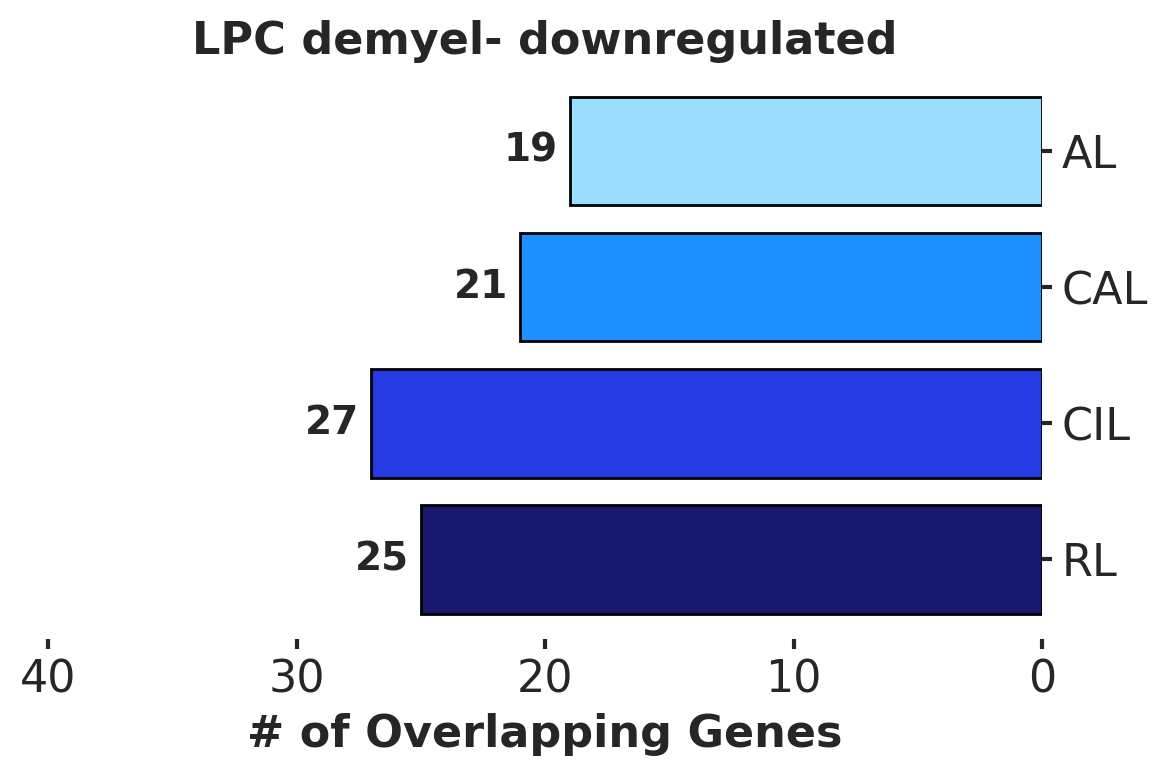

In [168]:
import seaborn as sns

# Lesion names and counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts = [19, 21, 27, 25]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 10, 20, 30, 40])
ax.set_xticklabels(['0', '10', '20', '30', '40'])

# Title
ax.set_title("LPC demyel- downregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_demyel_MG_down.png", dpi=300, bbox_inches='tight')

plt.show()

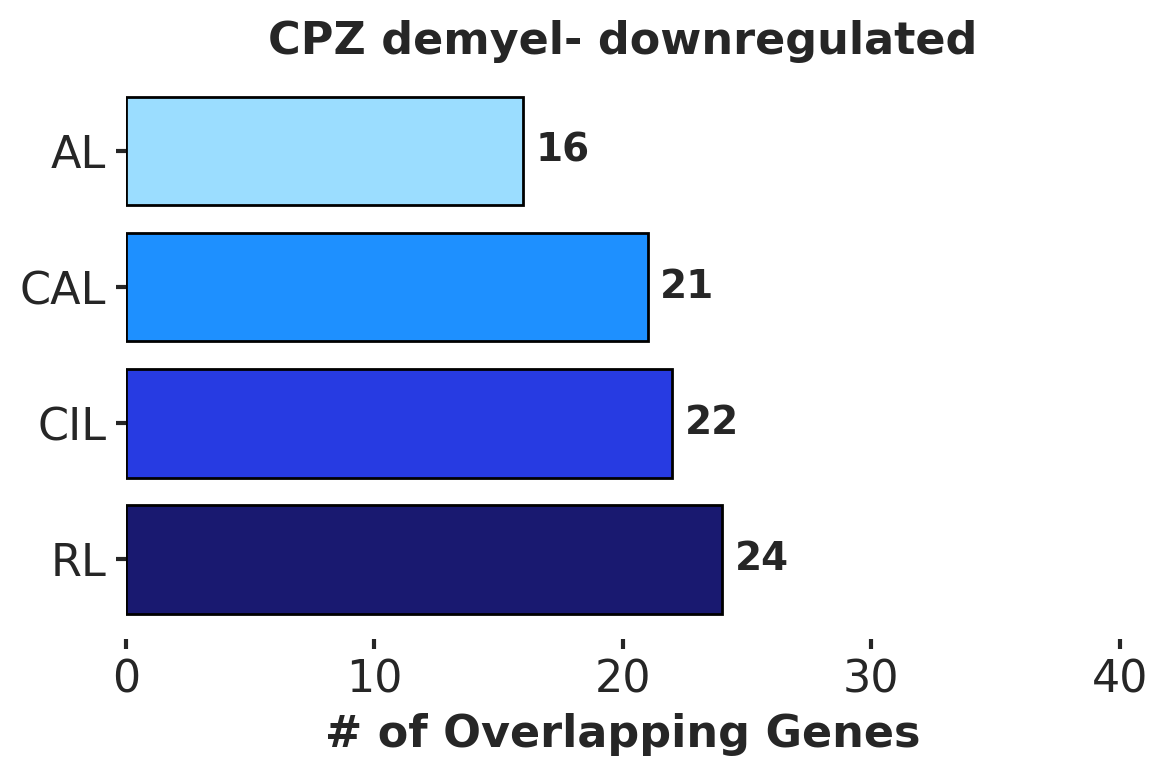

In [169]:
# Lesion names and CPZ counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [16, 21, 22, 24]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 10, 20, 30, 40])
ax.set_xticklabels(['0', '10', '20', '30', '40'])

# Title
ax.set_title("CPZ demyel- downregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_CPZ_demyel_MG_down.png", dpi=300, bbox_inches='tight')

plt.show()

## Add remyelination and BAMs?

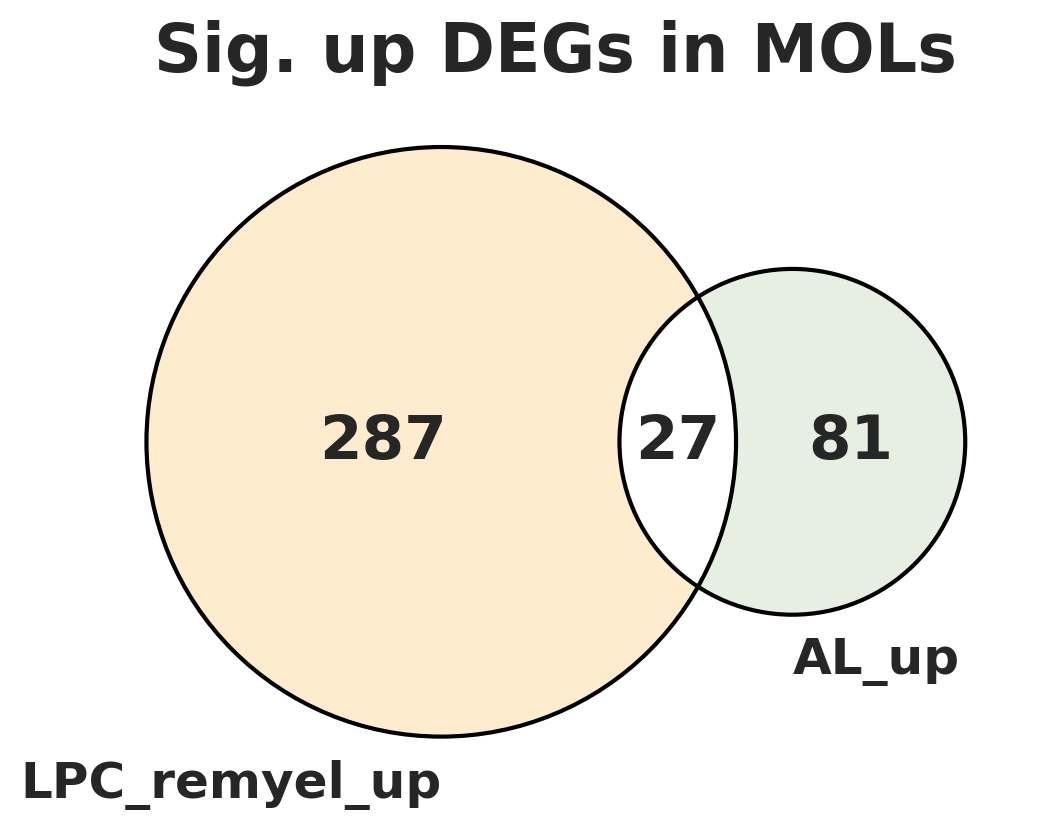

In [172]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_up,
    set2=set_MOL_AL_up_all,
    labels=('LPC_remyel_up', 'AL_up'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs'
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

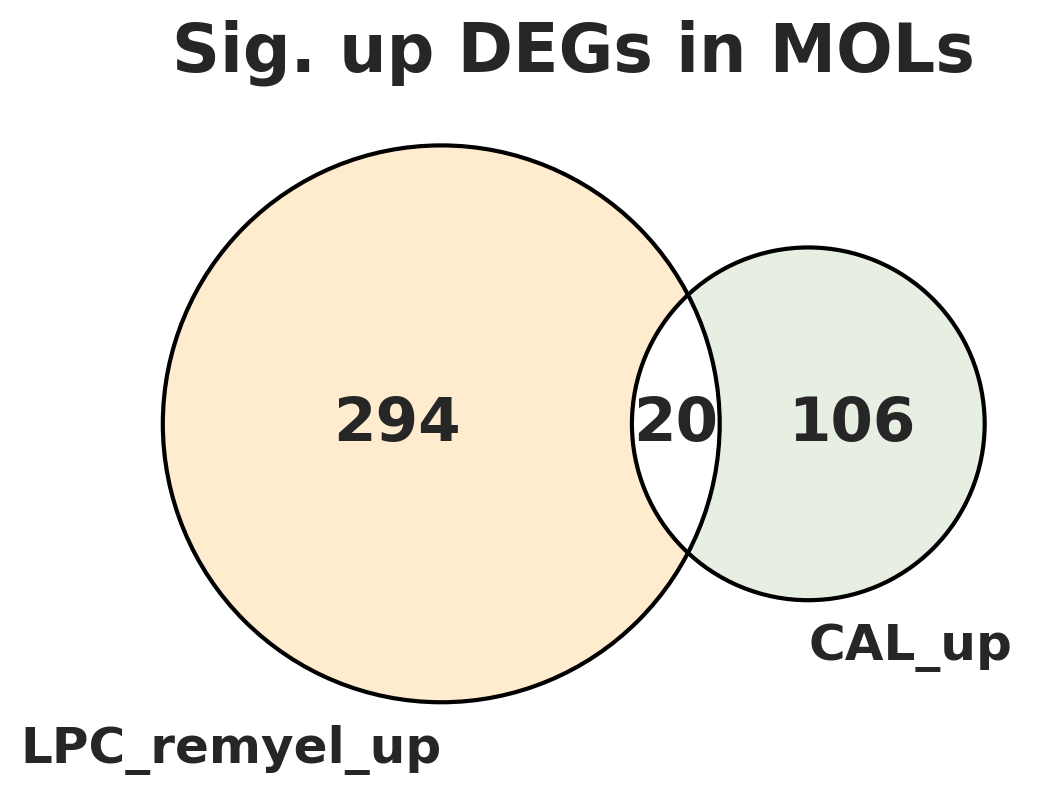

In [173]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_up,
    set2=set_MOL_CAL_up_all,
    labels=('LPC_remyel_up', 'CAL_up'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs'
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

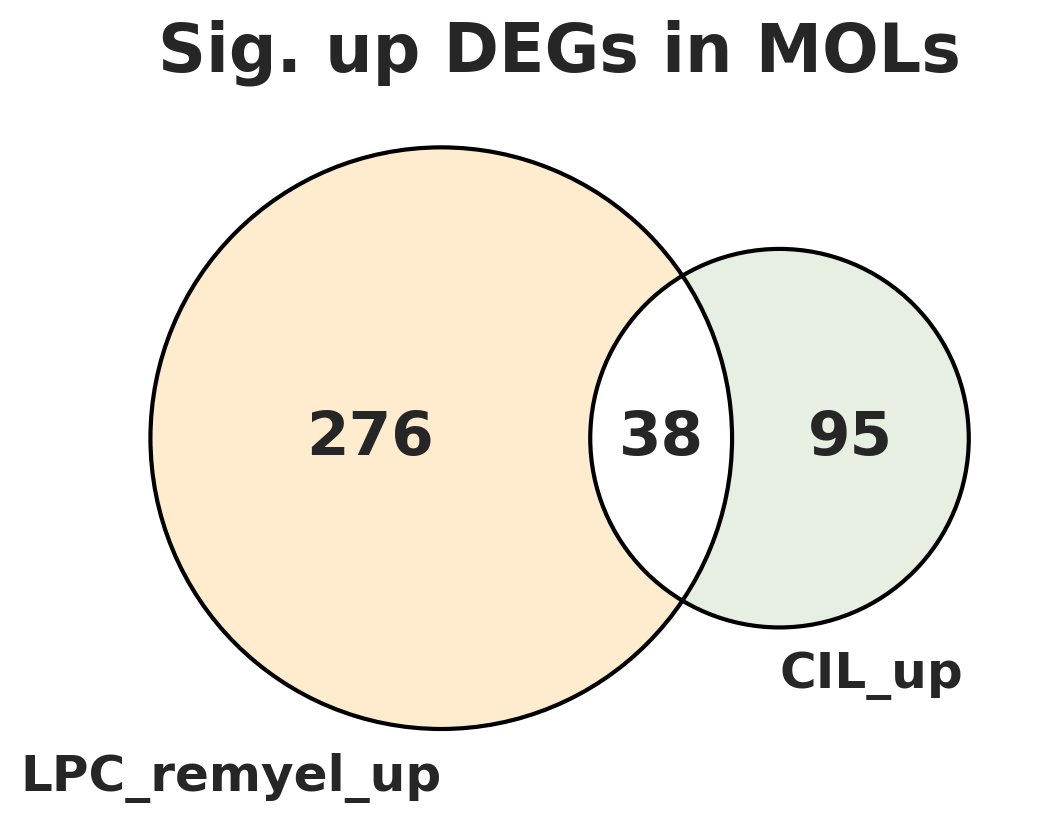

In [174]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_up,
    set2=set_MOL_CIL_up_all,
    labels=('LPC_remyel_up', 'CIL_up'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs',
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

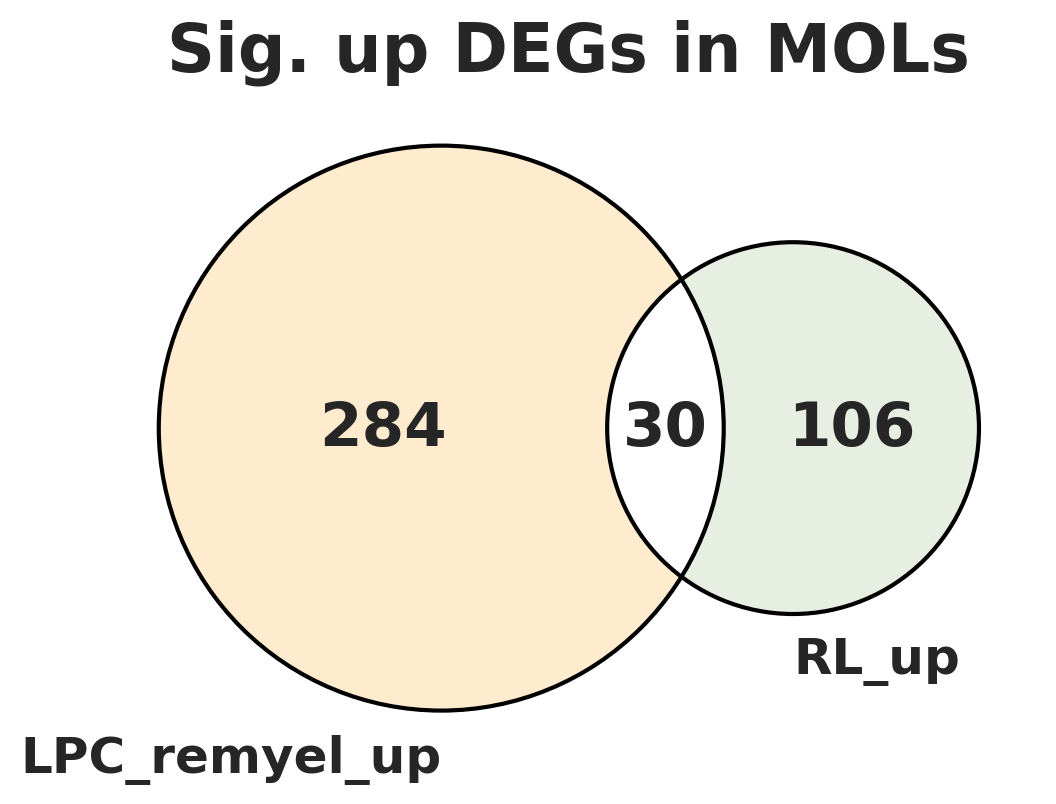

In [175]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_up,
    set2=set_MOL_RL_up_all,
    labels=('LPC_remyel_up', 'RL_up'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs',
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

In [ ]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_cupr_not_lpc = (union_AL_CAL_CIL_RL & set_LPC_remyel_all_up) - set_LPC_demyel_all_up - set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (Cupr but not LPC):", len(overlap_cupr_not_lpc))
print("Overlapping upregulated genes (Cupr but not LPC):", overlap_cupr_not_lpc)

In [ ]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_lpc_not_cupr = (union_AL_CAL_CIL_RL & set_LPC_remyel_all_up & set_LPC_demyel_all_up) - set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (LPC but not CPZ):", len(overlap_lpc_not_cupr))
print("Overlapping upregulated genes (LPC but not CPZ):", overlap_lpc_not_cupr)

In [ ]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_lpc_and_cupr = union_AL_CAL_CIL_RL & set_LPC_demyel_all_up & set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (LPC and CPZ):", len(overlap_lpc_and_cupr))
print("Overlapping upregulated genes (LPC and CPZ):", overlap_lpc_and_cupr)

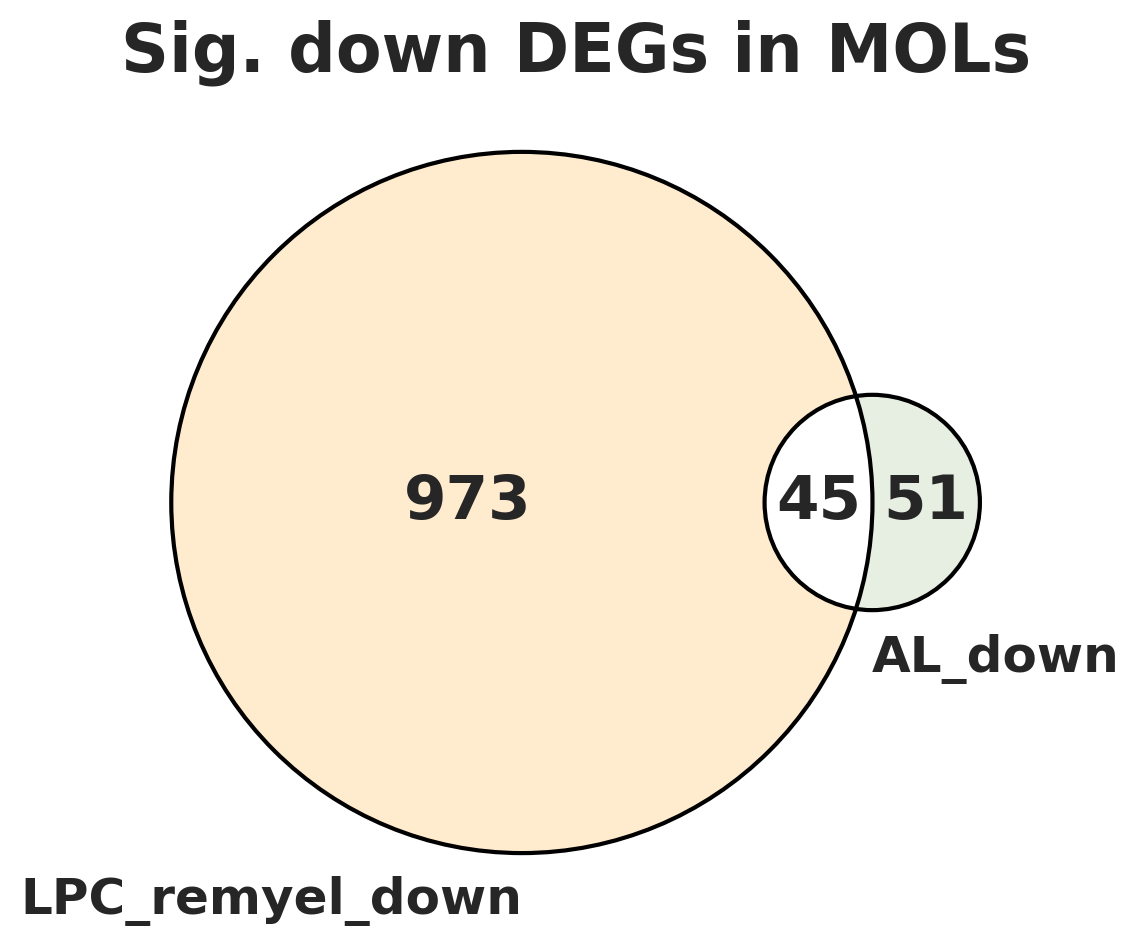

In [178]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_down,
    set2=set_MOL_AL_down_all,
    labels=('LPC_remyel_down', 'AL_down'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. down DEGs in MOLs',
    #save_path='./figures/venn2_LPC_demyel_EAE_down.png'  # None
)

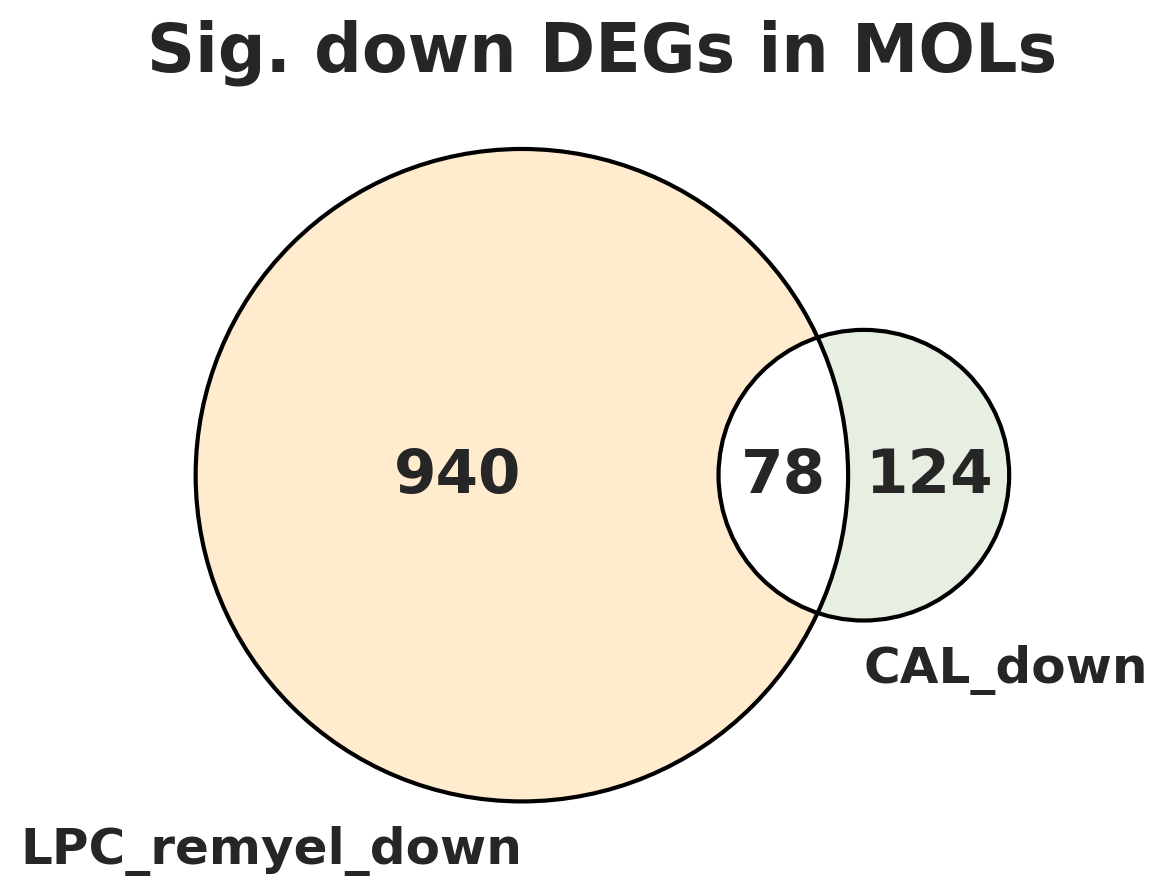

In [179]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_down,
    set2=set_MOL_CAL_down_all,
    labels=('LPC_remyel_down', 'CAL_down'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. down DEGs in MOLs',
    #save_path='./figures/venn2_LPC_demyel_EAE_down.png'  # None
)

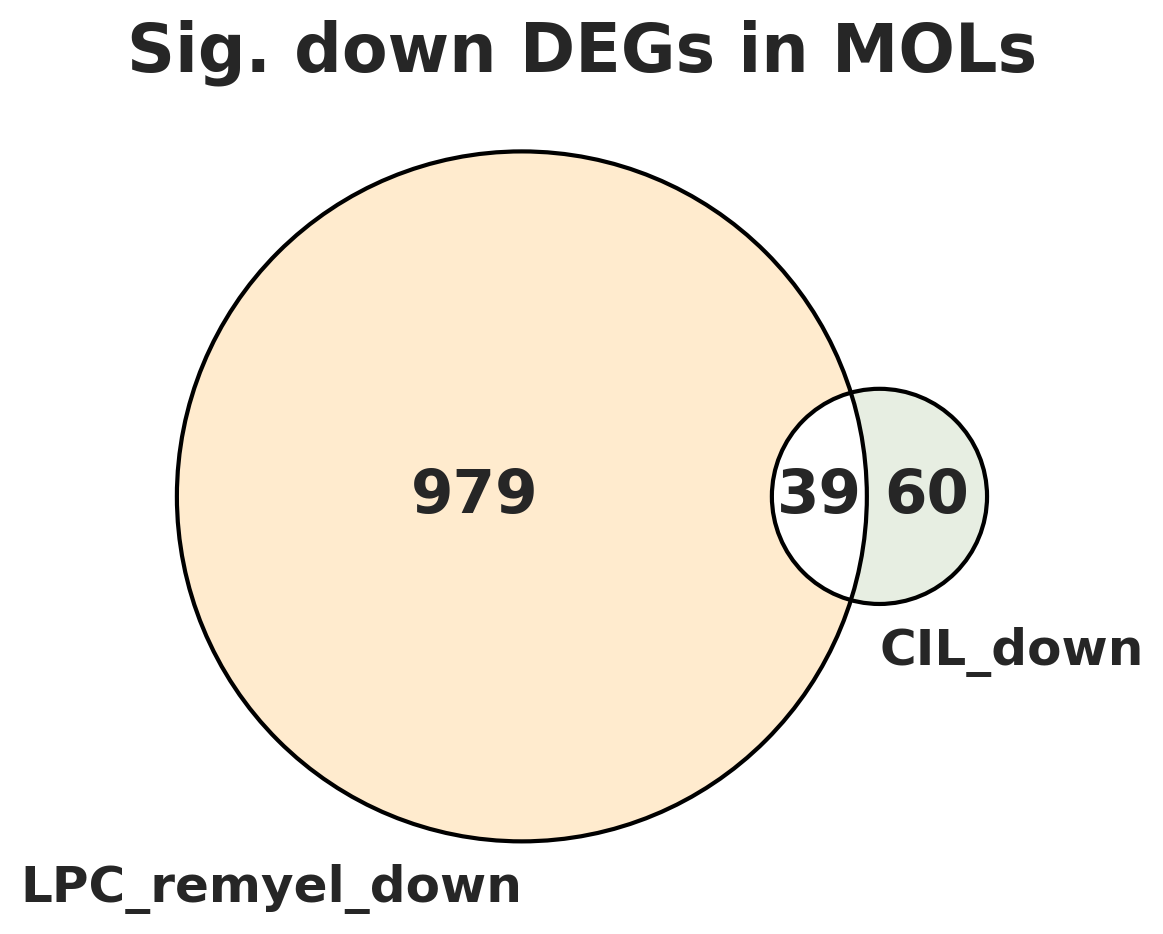

In [180]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_down,
    set2=set_MOL_CIL_down_all,
    labels=('LPC_remyel_down', 'CIL_down'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. down DEGs in MOLs',
    #save_path='./figures/venn2_LPC_demyel_EAE_down.png'  # None
)

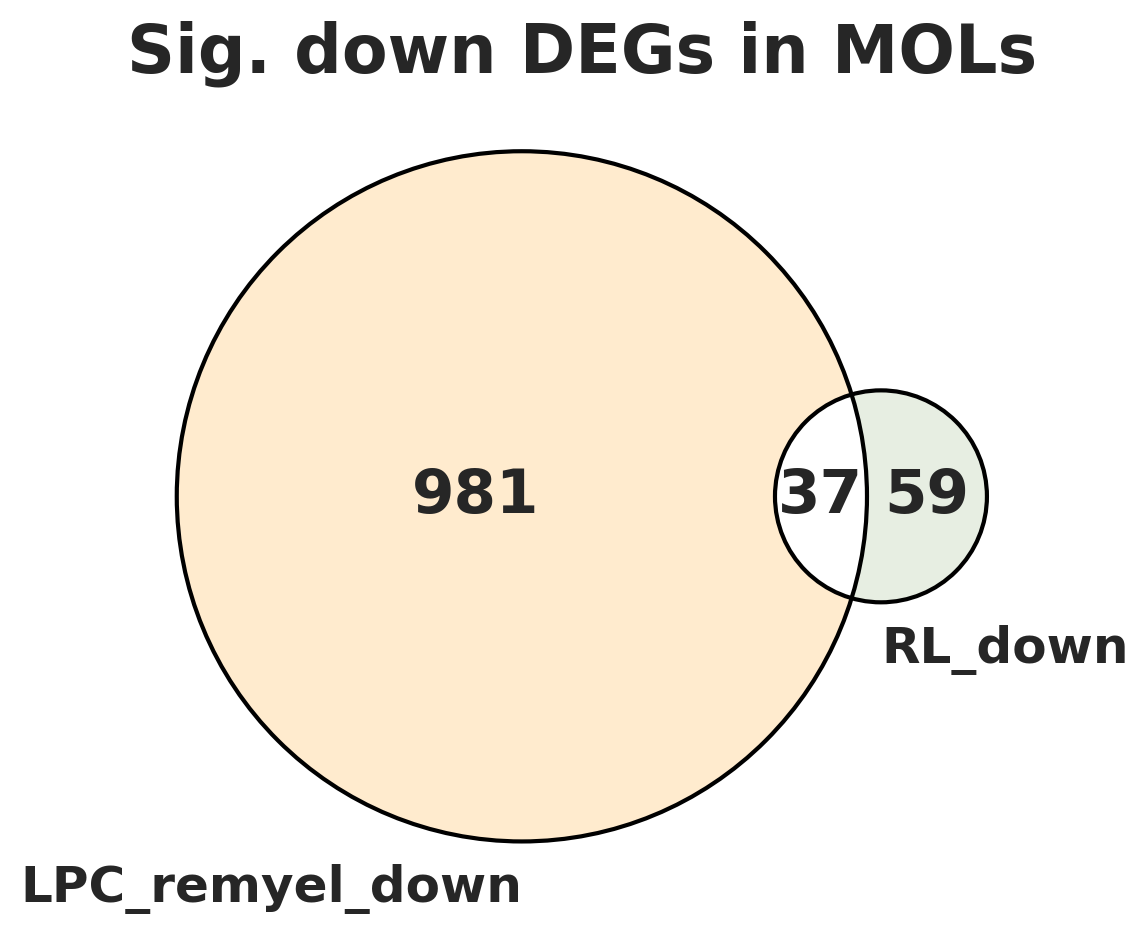

In [181]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_down,
    set2=set_MOL_RL_down_all,
    labels=('LPC_remyel_down', 'RL_down'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. down DEGs in MOLs',
    #save_path='./figures/venn2_LPC_demyel_EAE_down.png'  # None
)

In [ ]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_cupr_not_lpc = (union_AL_CAL_CIL_RL & set_Cupr_demyel_all_down) - set_LPC_demyel_all_down

print("Number of overlapping downregulated genes (Cupr but not LPC):", len(overlap_cupr_not_lpc))
print("Overlapping downregulated genes (Cupr but not LPC):", overlap_cupr_not_lpc)

In [ ]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_lpc_not_cupr = (union_AL_CAL_CIL_RL & set_LPC_demyel_all_down) - set_Cupr_demyel_all_down

print("Number of overlapping downregulated genes (LPC but not cupr):", len(overlap_lpc_not_cupr))
print("Overlapping downregulated genes (LPC but not cupr):", overlap_lpc_not_cupr)

In [ ]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_lpc_and_cupr = union_AL_CAL_CIL_RL & set_LPC_demyel_all_down & set_Cupr_demyel_all_down

print("Number of overlapping downregulated genes (LPC and cupr):", len(overlap_lpc_and_cupr))
print("Overlapping downregulated genes (LPC and cupr):", overlap_lpc_and_cupr)

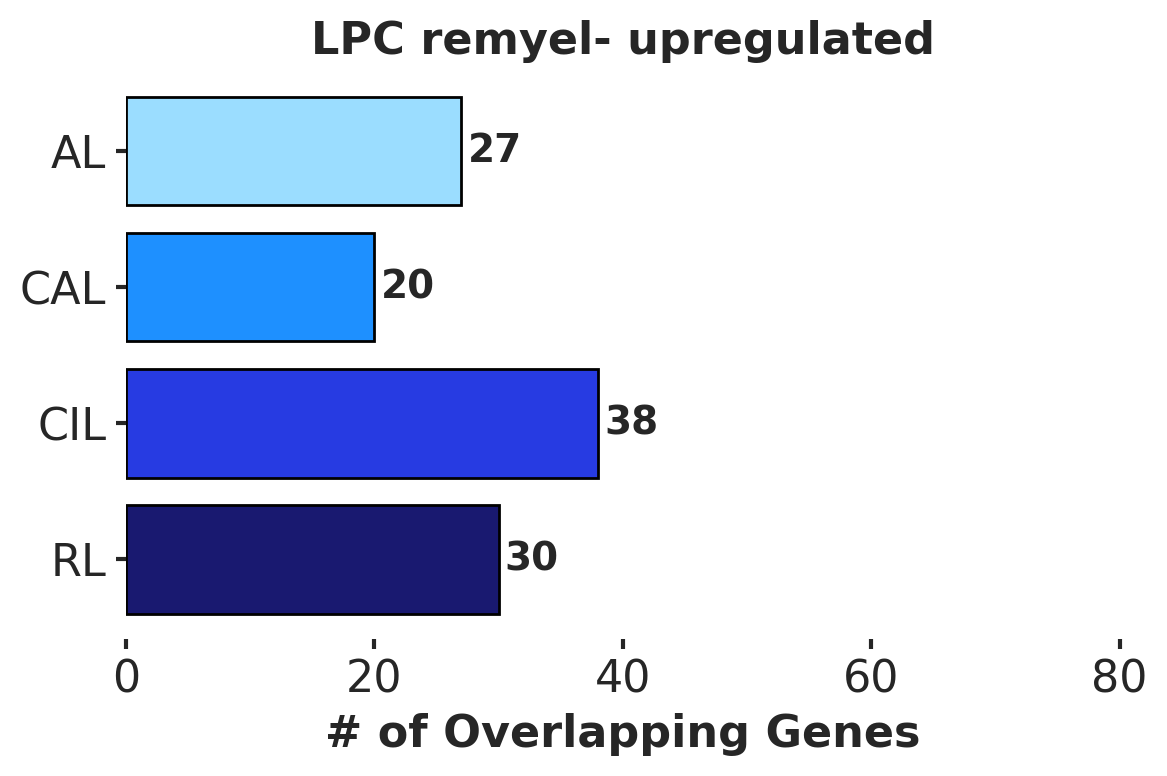

In [211]:
# Lesion names and CPZ counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [27, 20, 38, 30]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 20, 40, 60, 80])
ax.set_xticklabels(['0', '20', '40', '60', '80'])

# Title
ax.set_title("LPC remyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_remyel.png", dpi=300, bbox_inches='tight')

plt.show()

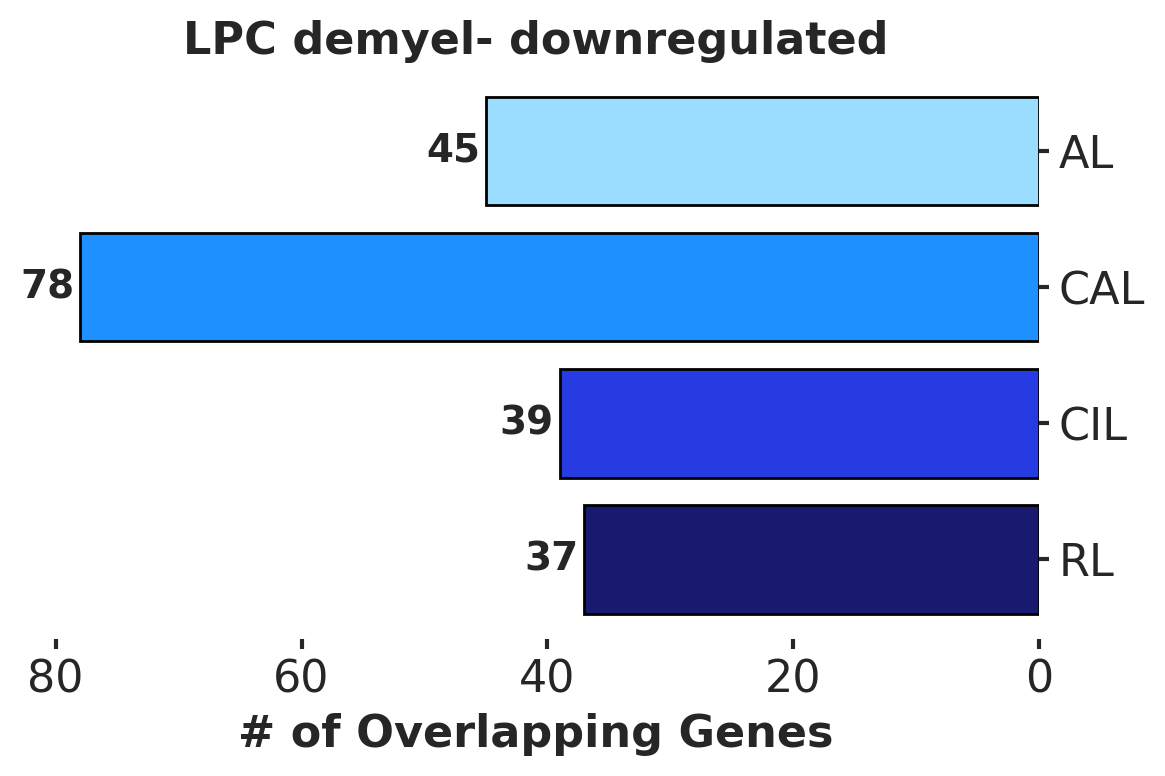

In [212]:
import seaborn as sns

# Lesion names and counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts = [45, 78, 39, 37]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 20, 40, 60, 80])
ax.set_xticklabels(['0', '20', '40', '60', '80'])

# Title
ax.set_title("LPC demyel- downregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_remyel_DOWN.png", dpi=300, bbox_inches='tight')

plt.show()

## BAMs

In [183]:
## IMPORTANT FILTER FOR GENES TESTING IN ALL CONDITIONS

genes_all = set(MOL_AL['gene']) & \
                set(MOL_CAL['gene']) & \
                set(MOL_CIL['gene']) & \
                set(MOL_RL['gene']) & \
                set(LPC_demyel_bam['gene_hs'])


len(genes_all)

3899

In [184]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene'].isin(genes_all)]

# Apply filtering to each DEG DataFrame
MOL_AL_up_all = filter_genes(MOL_AL_up)
MOL_CAL_up_all = filter_genes(MOL_CAL_up)
MOL_CIL_up_all = filter_genes(MOL_CIL_up)
MOL_RL_up_all = filter_genes(MOL_RL_up)

print(MOL_AL_up_all.shape)
print(MOL_CAL_up_all.shape)
print(MOL_CIL_up_all.shape)
print(MOL_RL_up_all.shape)

# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene_hs'].isin(genes_all)]

LPC_demyel_bam_up_all = filter_genes(LPC_demyel_bam_up)

print(LPC_demyel_bam_up_all.shape)

(110, 5)
(123, 5)
(140, 5)
(144, 5)
(615, 9)


In [185]:
# Create gene lists from the new DataFrames
genes_MOL_AL_all_up = MOL_AL_up_all['gene'].tolist()
genes_MOL_CAL_all_up = MOL_CAL_up_all['gene'].tolist()
genes_MOL_CIL_all_up = MOL_CIL_up_all['gene'].tolist()
genes_MOL_RL_all_up = MOL_RL_up_all['gene'].tolist()

genes_LPC_demyel_bam_up_all = LPC_demyel_bam_up_all['gene_hs'].tolist()

In [186]:
# Convert lists to sets for upregulated genes
set_MOL_AL_up_all = set(genes_MOL_AL_all_up)
set_MOL_CAL_up_all = set(genes_MOL_CAL_all_up)
set_MOL_CIL_up_all = set(genes_MOL_CIL_all_up)
set_MOL_RL_up_all = set(genes_MOL_RL_all_up)

set_LPC_demyel_bam_up_all = set(genes_LPC_demyel_bam_up_all)

In [191]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene'].isin(genes_all)]

# Apply filtering to each DEG DataFrame
MOL_AL_down_all = filter_genes(MOL_AL_down)
MOL_CAL_down_all = filter_genes(MOL_CAL_down)
MOL_CIL_down_all = filter_genes(MOL_CIL_down)
MOL_RL_down_all = filter_genes(MOL_RL_down)

print(MOL_AL_down_all.shape)
print(MOL_CAL_down_all.shape)
print(MOL_CIL_down_all.shape)
print(MOL_RL_down_all.shape)

# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene_hs'].isin(genes_all)]

LPC_demyel_bam_down_all = filter_genes(LPC_demyel_bam_down)

print(LPC_demyel_bam_down_all.shape)

(98, 5)
(191, 5)
(91, 5)
(95, 5)
(1504, 9)


In [192]:
# Create gene lists from the new DataFrames
genes_MOL_AL_all_down = MOL_AL_down_all['gene'].tolist()
genes_MOL_CAL_all_down = MOL_CAL_down_all['gene'].tolist()
genes_MOL_CIL_all_down = MOL_CIL_down_all['gene'].tolist()
genes_MOL_RL_all_down = MOL_RL_down_all['gene'].tolist()

genes_LPC_demyel_bam_down_all = LPC_demyel_bam_down_all['gene_hs'].tolist()

In [193]:
# Convert lists to sets for downregulated genes
set_MOL_AL_down_all = set(genes_MOL_AL_all_down)
set_MOL_CAL_down_all = set(genes_MOL_CAL_all_down)
set_MOL_CIL_down_all = set(genes_MOL_CIL_all_down)
set_MOL_RL_down_all = set(genes_MOL_RL_all_down)

set_LPC_demyel_bam_down_all = set(genes_LPC_demyel_bam_down_all)

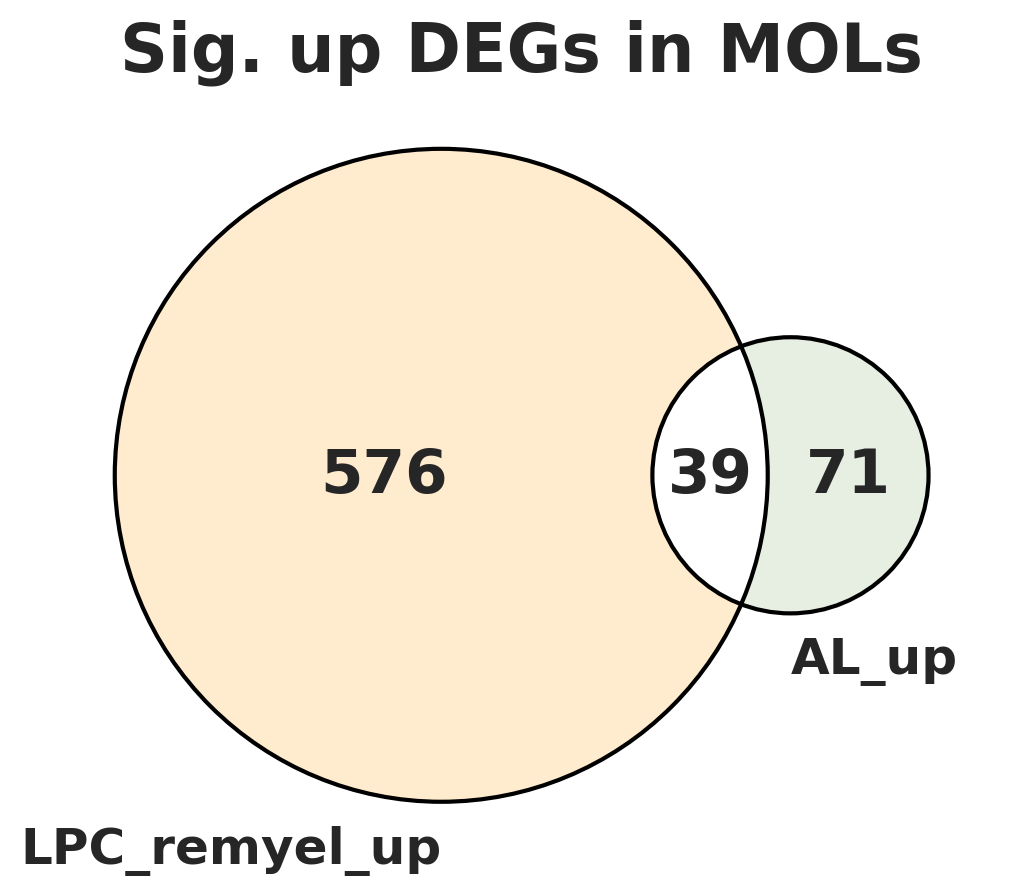

In [187]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_demyel_bam_up_all,
    set2=set_MOL_AL_up_all,
    labels=('LPC_remyel_up', 'AL_up'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs'
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

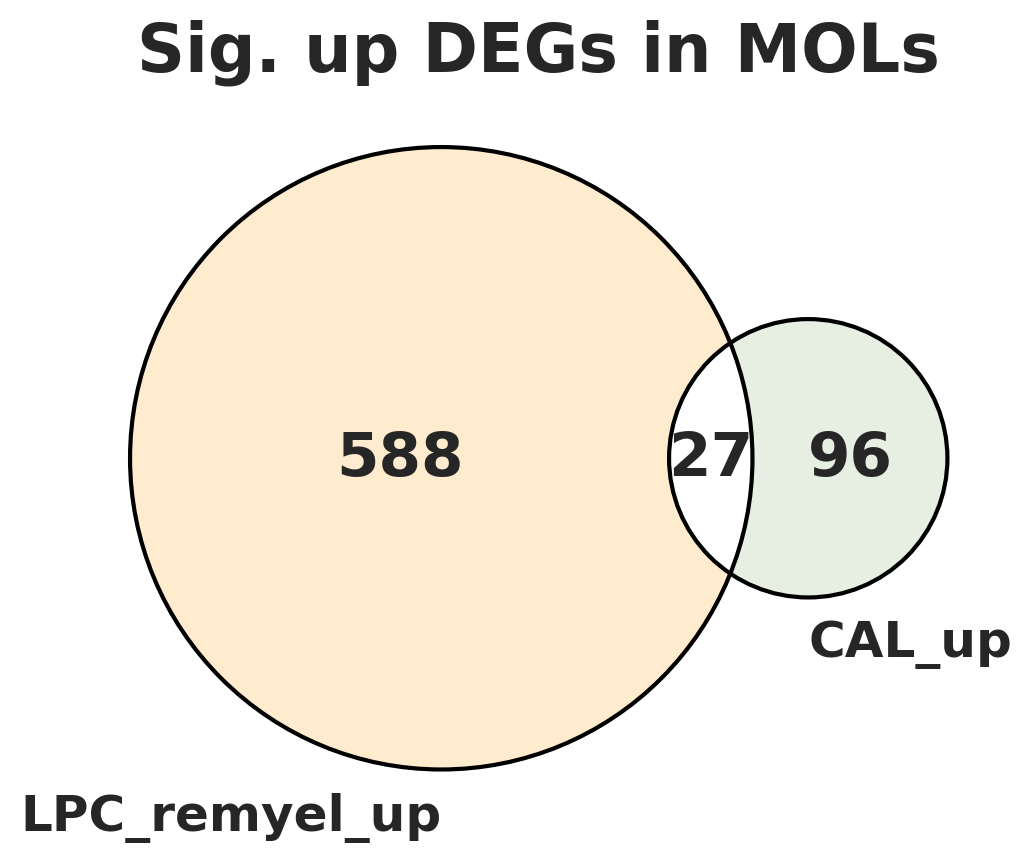

In [188]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_demyel_bam_up_all,
    set2=set_MOL_CAL_up_all,
    labels=('LPC_remyel_up', 'CAL_up'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs'
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

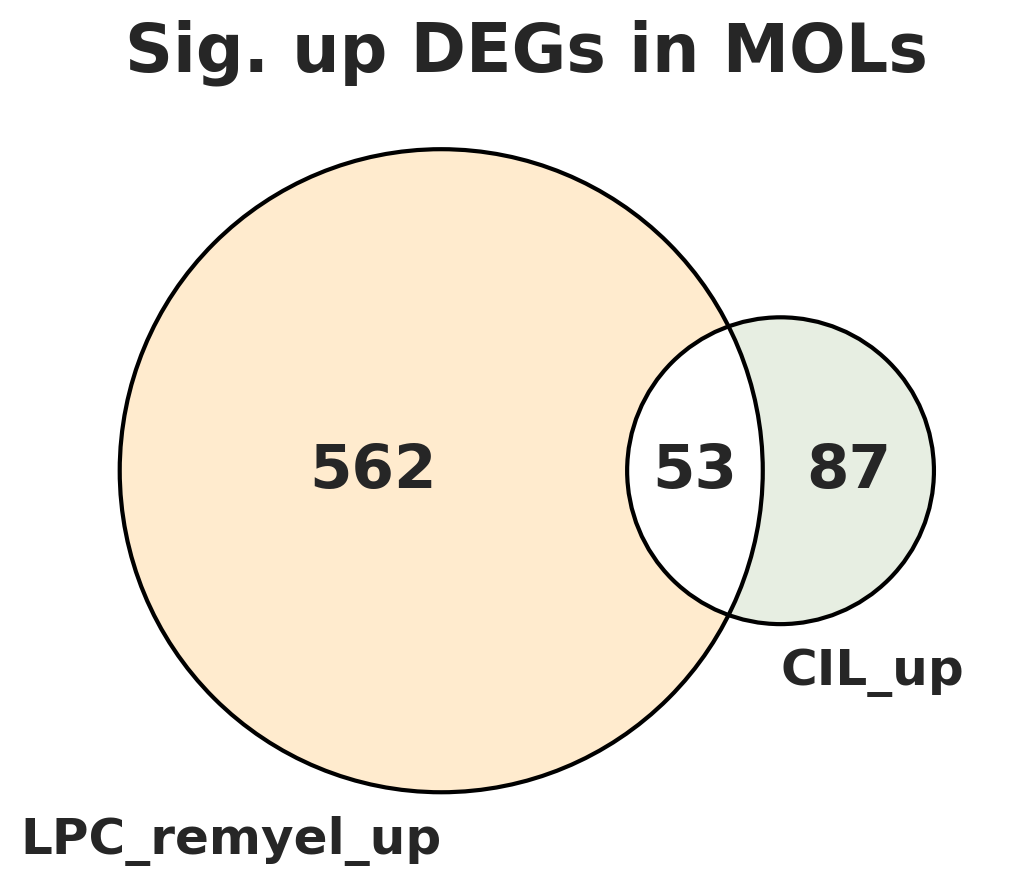

In [189]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_demyel_bam_up_all,
    set2=set_MOL_CIL_up_all,
    labels=('LPC_remyel_up', 'CIL_up'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs',
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

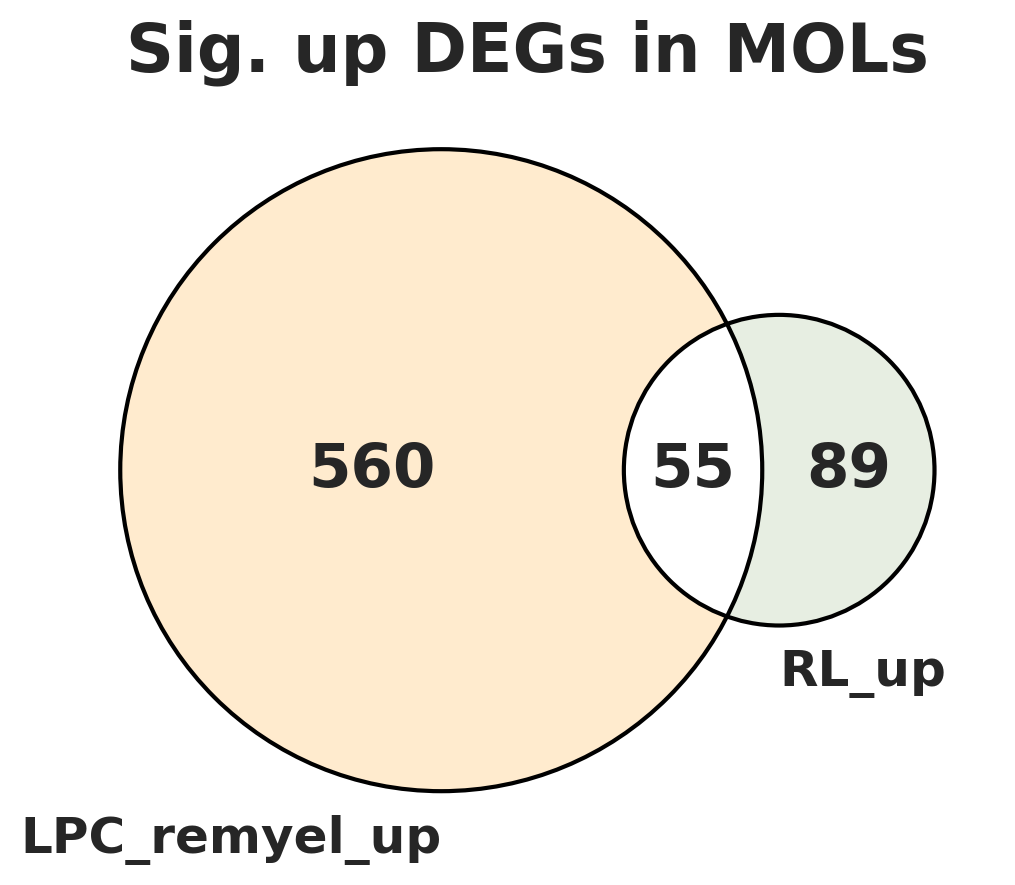

In [190]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_demyel_bam_up_all,
    set2=set_MOL_RL_up_all,
    labels=('LPC_remyel_up', 'RL_up'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs',
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

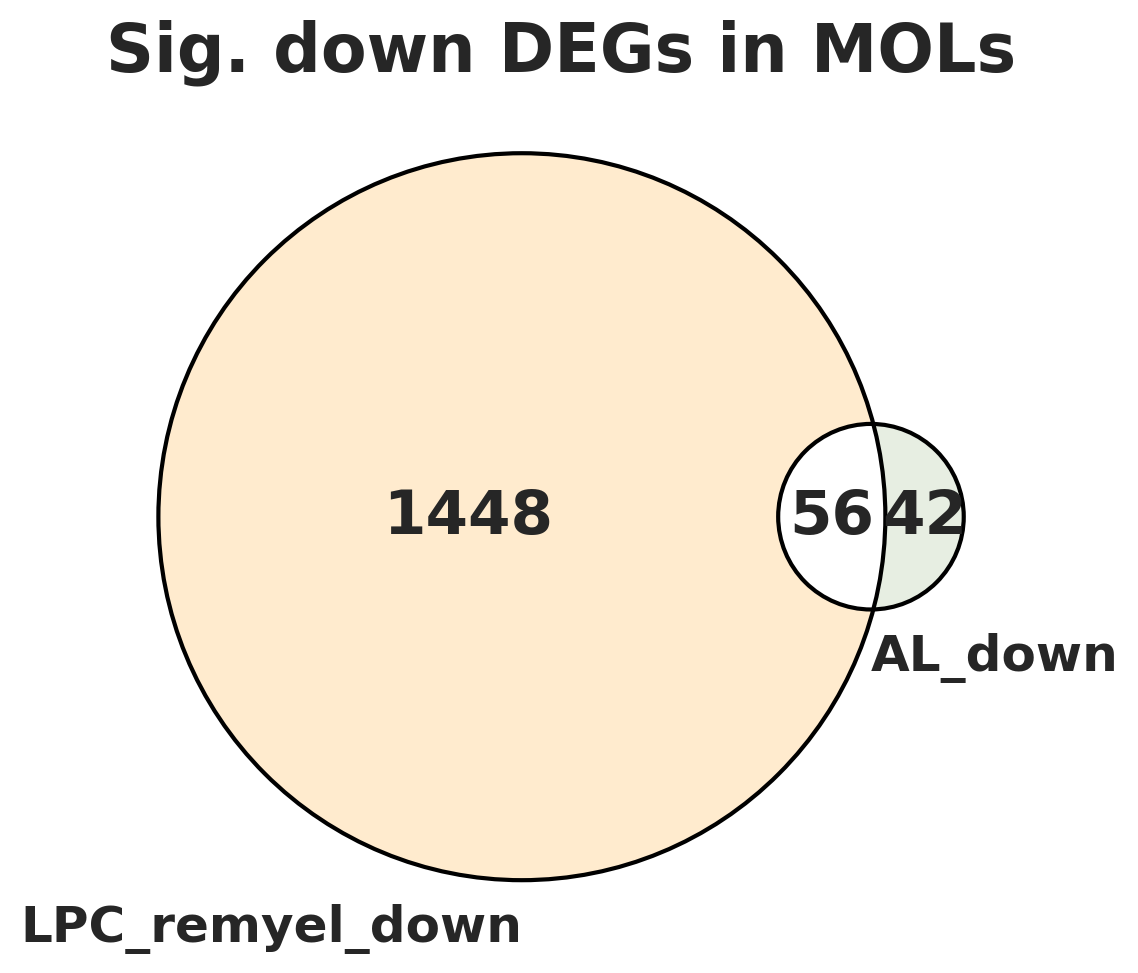

In [194]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_demyel_bam_down_all,
    set2=set_MOL_AL_down_all,
    labels=('LPC_remyel_down', 'AL_down'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. down DEGs in MOLs',
    #save_path='./figures/venn2_LPC_demyel_EAE_down.png'  # None
)

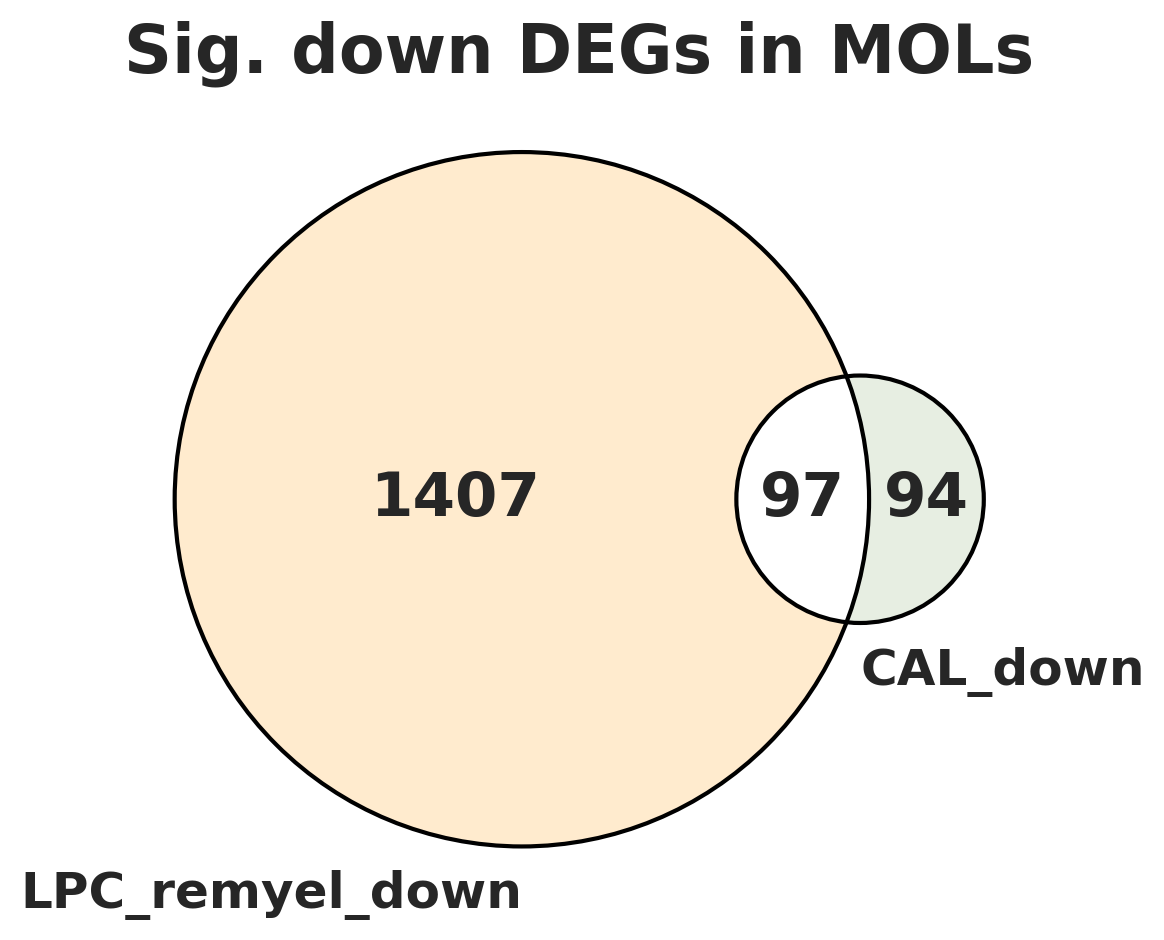

In [195]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_demyel_bam_down_all,
    set2=set_MOL_CAL_down_all,
    labels=('LPC_remyel_down', 'CAL_down'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. down DEGs in MOLs',
    #save_path='./figures/venn2_LPC_demyel_EAE_down.png'  # None
)

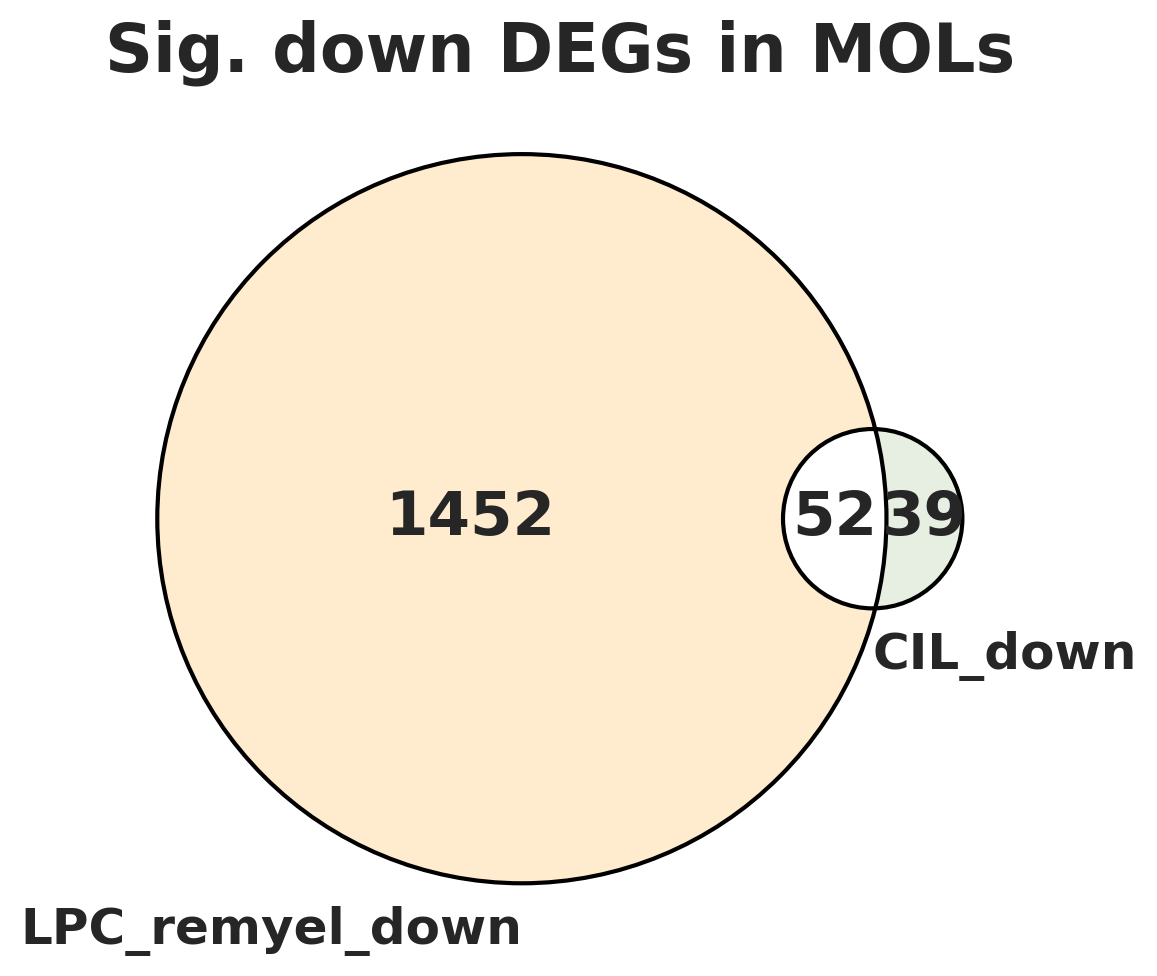

In [196]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_demyel_bam_down_all,
    set2=set_MOL_CIL_down_all,
    labels=('LPC_remyel_down', 'CIL_down'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. down DEGs in MOLs',
    #save_path='./figures/venn2_LPC_demyel_EAE_down.png'  # None
)

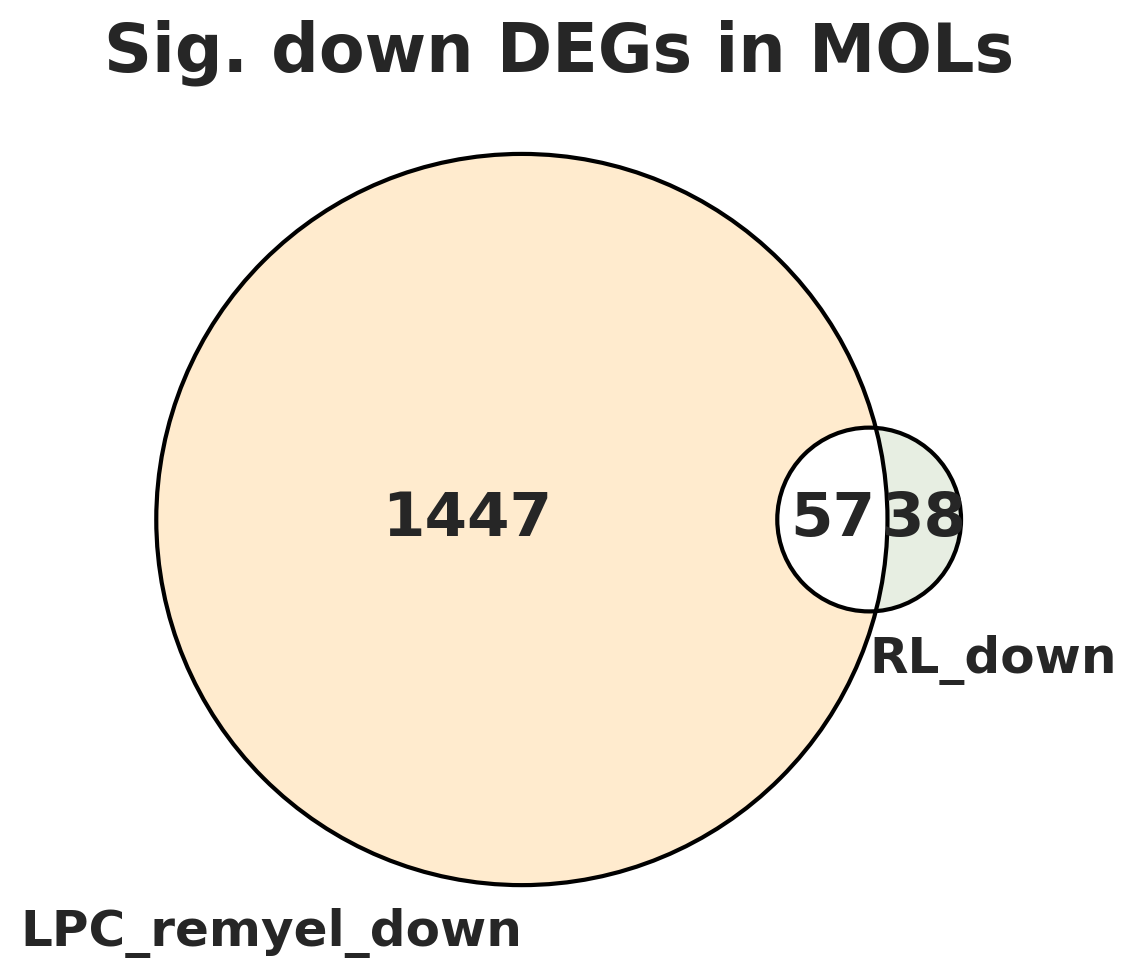

In [197]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_demyel_bam_down_all,
    set2=set_MOL_RL_down_all,
    labels=('LPC_remyel_down', 'RL_down'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. down DEGs in MOLs',
    #save_path='./figures/venn2_LPC_demyel_EAE_down.png'  # None
)

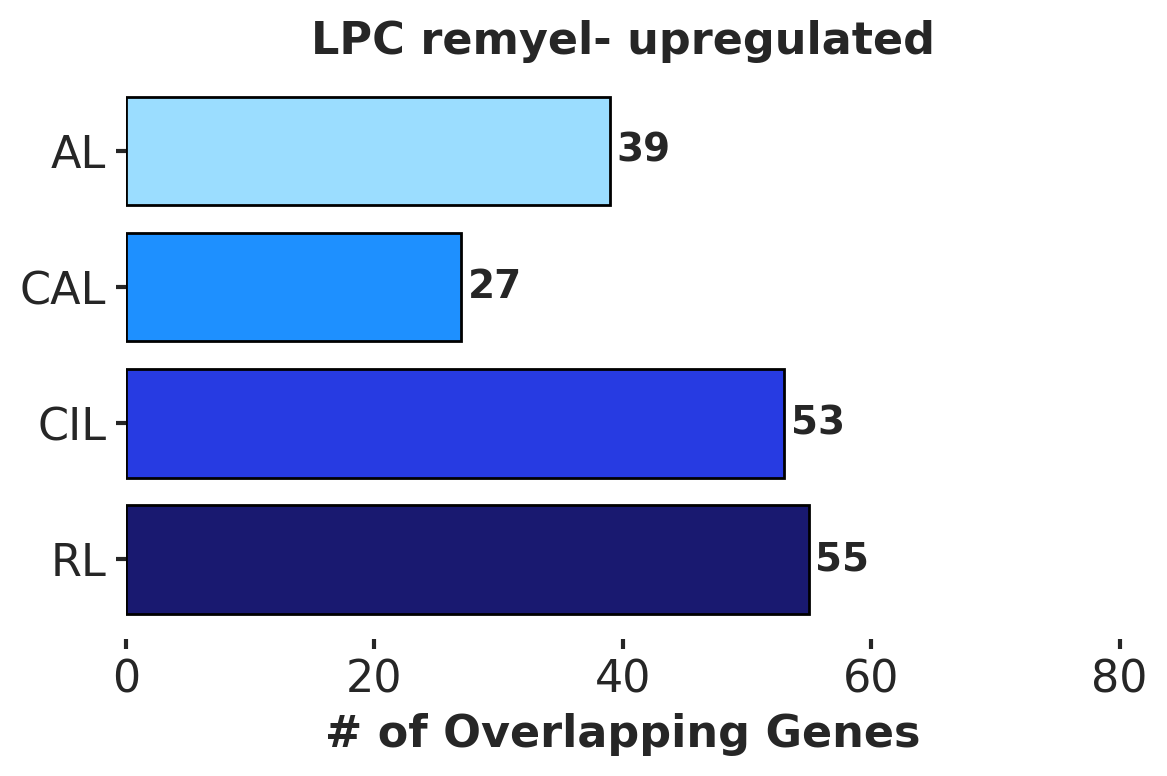

In [202]:
# Lesion names and CPZ counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [39, 27, 53, 55]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 20, 40, 60, 80])
ax.set_xticklabels(['0', '20', '40', '60', '80'])

# Title
ax.set_title("LPC remyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_BAm.png", dpi=300, bbox_inches='tight')

plt.show()

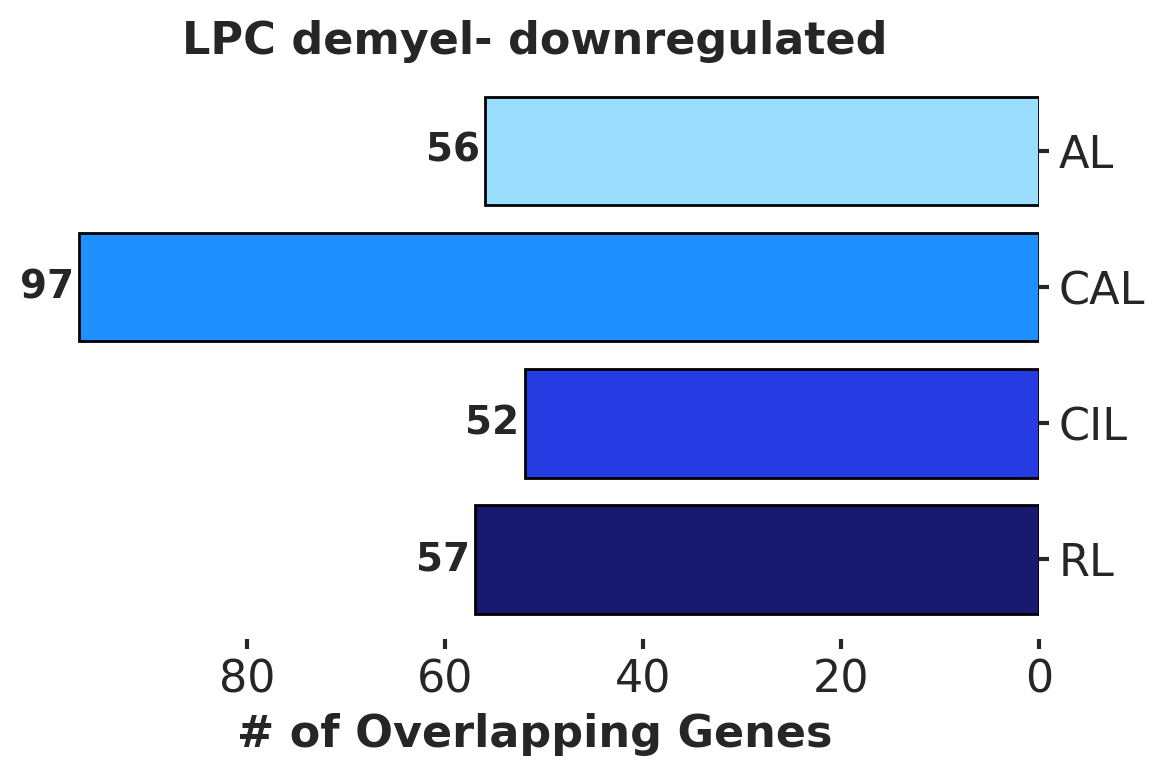

In [201]:
import seaborn as sns

# Lesion names and counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts = [56, 97, 52, 57]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 20, 40, 60, 80])
ax.set_xticklabels(['0', '20', '40', '60', '80'])

# Title
ax.set_title("LPC demyel- downregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_BAM_DOWN.png", dpi=300, bbox_inches='tight')

plt.show()

# Heatmap:

In [8]:
%load_ext autoreload
%autoreload 2

import matplotlib
import matplotlib.pyplot as plt
import pertpy as pt
import scanpy as sc
import pandas as pd
import seaborn as sb

plt.rcParams["figure.figsize"] = (7, 7)
import numpy as np

sc.settings.verbosity = 3


import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, colors

#Define a nice colour map for gene expression
colors2 = plt.cm.plasma(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.7,0.8,20))
colorsComb = np.vstack([colors3, colors2])
mymap2 = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

## r2py setup
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

## Define color palette
pal = sb.color_palette('Paired').as_hex()
design_palette = {'ACR':pal[3], 'CR':pal[7], 'AR':pal[9], 'joint_CR':pal[6]}
design_palette_df = pd.DataFrame(design_palette.values(), index =design_palette.keys() )
design_palette_df.columns = ['color']

import os,sys

figdir = './figures/'
if not os.path.exists(figdir):
    os.mkdir(figdir)
sc.settings.figdir = figdir

In [9]:
%%R
library(tidyverse)
library(reshape2)
library(patchwork)
library(ggrastr)
library(shadowtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(forcats)
library(data.table)

remove_x_axis <- function(){
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(), axis.title.x = element_blank())  
}

remove_y_axis <- function(){
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(), axis.title.y = element_blank())  
}

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘reshape2’

The following object is masked from ‘package:tidyr’:

    smiths

data.table 1.16.4 using 1 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attaching package: ‘data.table’

The following objects are masked from ‘package:reshape2’:

    dcast, melt

The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year

The following objects are masked from ‘package:dplyr’:

    between, first, last

The following object is masked from ‘package:purrr’:

    transpose



## Pseudobulk

In [ ]:
adata_pb = sc.read('./pb_adata_MG_sep.h5ad')
adata_pb

In [ ]:
print(f"All samples: {adata_pb.shape[0]}")

# Extract the data as a pandas DataFrame
df = adata_pb.obs[['cell_type', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)
summary_table

In [ ]:
adata_sub= adata_pb[np.in1d(adata_pb.obs['cell_type'], 
                           ['Mg'])].copy()

print("Dimensions of adata_sub:", adata_sub.shape)

In [ ]:
# Check if the 'sample_rep' column exists
if 'sample_lesion' in adata_sub.obs.columns:
    # Set the 'sample_rep' column as the index
    adata_sub.obs.set_index('sample_lesion', inplace=True)
else:
    print("The column 'sample' does not exist in adata_sub.obs.")

adata_sub.obs.index.name = None

In [ ]:
# Add the index back as a column called 'sample_lesion'
adata_sub.obs['sample_lesion'] = adata_sub.obs.index

In [ ]:
# Replace space with underscore in the 'seq_pool' column
adata_sub.obs['seq_pool'] = adata_sub.obs['seq_pool'].str.replace(' ', '_')

In [ ]:
adata_sub.obs['indiv_id'] = adata_sub.obs['sample'].str.split('-').str[0]
adata_sub.obs[:5]

In [ ]:
adata_sub.obs['cell_stim'] = adata_sub.obs['cell_type'].astype(str) + '_' + adata_sub.obs['stim'].astype(str)

In [ ]:
# Extract the data as a pandas DataFrame
df = adata_sub.obs[['cell_type', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)
summary_table

In [ ]:
# Calculate library size
lib_size = adata_sub.layers['counts'].sum(axis=1)
cpm = (adata_sub.layers['counts'].T / lib_size).T * 1e6

# Take log2(CPM + 1)
log2cpm = np.log2(cpm + 1)

# Store it (optional)
adata_sub.layers['log2CPM'] = log2cpm

In [ ]:
# Create a DataFrame from log2CPM layer (genes x samples)
log2cpm_df = pd.DataFrame(
    adata_sub.layers['log2CPM'],
    index=adata_sub.obs.index,
    columns=adata_sub.var_names
)

# Add group labels to the DataFrame
log2cpm_df['group'] = adata_sub.obs['stim'].values

# Group by pseudobulk group and average
pseudobulk_df = log2cpm_df.groupby('group').mean().T  # Now genes x groups
pseudobulk_df.head

In [ ]:
print(MOL_NAWM.shape)
print(MOL_AL.shape)
print(MOL_CAL.shape)
print(MOL_CIL.shape)
print(MOL_RL.shape)

In [ ]:
# Keep only gene, logFC, FDR
df_MOL_NAWM = MOL_NAWM[['gene', 'logFC', 'FDR']].copy()
df_MOL_AL = MOL_AL[['gene', 'logFC', 'FDR']].copy()
df_MOL_CAL = MOL_CAL[['gene', 'logFC', 'FDR']].copy()
df_MOL_CIL = MOL_CIL[['gene', 'logFC', 'FDR']].copy()
df_MOL_RL = MOL_RL[['gene', 'logFC', 'FDR']].copy()

# Rename columns to avoid name conflicts
df_MOL_NAWM.columns = ['gene', 'logFC_NAWM', 'FDR_NAWM']
df_MOL_AL.columns = ['gene', 'logFC_AL', 'FDR_AL']
df_MOL_CAL.columns = ['gene', 'logFC_CAL', 'FDR_CAL']
df_MOL_CIL.columns = ['gene', 'logFC_CIL', 'FDR_CIL']
df_MOL_RL.columns = ['gene', 'logFC_RL', 'FDR_RL']

# Merge all five dataframes on gene
deg_merged = (
    df_MOL_NAWM
    .merge(df_MOL_AL, on='gene', how='outer')
    .merge(df_MOL_CAL, on='gene', how='outer')
    .merge(df_MOL_CIL, on='gene', how='outer')
    .merge(df_MOL_RL, on='gene', how='outer')
)

# Check the final shape
print(deg_merged.shape)

In [ ]:
# Subset: keep genes where any FDR column is < 0.05
deg_sig = deg_merged[
    (deg_merged['FDR_NAWM'] <= 0.05) |
    (deg_merged['FDR_AL'] <= 0.05) |
    (deg_merged['FDR_CAL'] <= 0.05) |
    (deg_merged['FDR_CIL'] <= 0.05) |
    (deg_merged['FDR_RL'] <= 0.05)
].copy()

print("Significant subset shape:", deg_sig.shape)

# Define DEG status per condition (FDR <= 0.05 and |logFC| >= 0.585)
deg_sig['DEG_NAWM'] = (
    (deg_sig['FDR_NAWM'] <= 0.05) &
    (deg_sig['logFC_NAWM'].abs() >= 0.585)
)
deg_sig['DEG_AL'] = (
    (deg_sig['FDR_AL'] <= 0.05) &
    (deg_sig['logFC_AL'].abs() >= 0.585)
)
deg_sig['DEG_CAL'] = (
    (deg_sig['FDR_CAL'] <= 0.05) &
    (deg_sig['logFC_CAL'].abs() >= 0.585)
)
deg_sig['DEG_CIL'] = (
    (deg_sig['FDR_CIL'] <= 0.05) &
    (deg_sig['logFC_CIL'].abs() >= 0.585)
)
deg_sig['DEG_RL'] = (
    (deg_sig['FDR_RL'] <= 0.05) &
    (deg_sig['logFC_RL'].abs() >= 0.585)
)

# Function to assign significance symbols
def get_sig_symbol(fdr, deg):
    if not deg or pd.isnull(fdr):
        return ''
    elif fdr < 0.001:
        return '***'
    elif fdr < 0.01:
        return '**'
    elif fdr < 0.05:
        return '*'
    else:
        return ''

# Apply significance symbol labeling for each condition
deg_sig['Sig_NAWM'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_NAWM'], row['DEG_NAWM']), axis=1
)
deg_sig['Sig_AL'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_AL'], row['DEG_AL']), axis=1
)
deg_sig['Sig_CAL'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_CAL'], row['DEG_CAL']), axis=1
)
deg_sig['Sig_CIL'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_CIL'], row['DEG_CIL']), axis=1
)
deg_sig['Sig_RL'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_RL'], row['DEG_RL']), axis=1
)

# Preview the results
deg_sig.head()

In [ ]:
# Merge by gene name
merged_df = deg_sig.merge(
    pseudobulk_df, 
    left_on='gene', 
    right_index=True,  # pseudobulk_df uses gene names as index
    how='left'
)

In [ ]:
# Save merged_df with DEGs and asterisks
merged_df.to_csv("merged_deg_expression_df.csv")

# Save pseudobulk log2CPM expression data
pseudobulk_df.to_csv("pseudobulk_log2CPM_df.csv")

# Save DEG significance data
deg_sig.to_csv("deg_significance_df.csv")

In [ ]:
merged_df.shape

## GSEA

In [10]:
%%R

# Load the data.table package
library(data.table)

# Read the files back into R
NAWM_df <- fread("./files/filtered_fgseaResSignificant_NAWM_all_glmm_zscore_MG_noPVM.csv")
AL_df <- fread("./files/filtered_fgseaResSignificant_AL_all_glmm_zscore_MG_noPVM.csv")
CAL_df <- fread("./files/filtered_fgseaResSignificant_CAL_all_glmm_zscore_MG_noPVM.csv")
CIL_df <- fread("./files/filtered_fgseaResSignificant_CIL_all_glmm_zscore_MG_noPVM.csv")
RL_df <- fread("./files/filtered_fgseaResSignificant_RL_all_glmm_zscore_MG_noPVM.csv")

In [11]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
NAWM_df$pathway <- gsub("^HALLMARK_", "", NAWM_df$pathway)
AL_df$pathway <- gsub("^HALLMARK_", "", AL_df$pathway)
CAL_df$pathway <- gsub("^HALLMARK_", "", CAL_df$pathway)
CIL_df$pathway <- gsub("^HALLMARK_", "", CIL_df$pathway)
RL_df$pathway <- gsub("^HALLMARK_", "", RL_df$pathway)

In [12]:
%%R

print(unique(NAWM_df$pathway))
print(unique(AL_df$pathway))
print(unique(CAL_df$pathway))
print(unique(CIL_df$pathway))
print(unique(RL_df$pathway))

 [1] "ADIPOGENESIS"                      "ALLOGRAFT_REJECTION"              
 [3] "APOPTOSIS"                         "COAGULATION"                      
 [5] "COMPLEMENT"                        "EPITHELIAL_MESENCHYMAL_TRANSITION"
 [7] "ESTROGEN_RESPONSE_LATE"            "FATTY_ACID_METABOLISM"            
 [9] "INFLAMMATORY_RESPONSE"             "MITOTIC_SPINDLE"                  
[11] "MTORC1_SIGNALING"                  "MYC_TARGETS_V1"                   
[13] "OXIDATIVE_PHOSPHORYLATION"         "REACTIVE_OXYGEN_SPECIES_PATHWAY"  
[15] "TGF_BETA_SIGNALING"                "TNFA_SIGNALING_VIA_NFKB"          
[17] "UNFOLDED_PROTEIN_RESPONSE"         "UV_RESPONSE_UP"                   
[19] "XENOBIOTIC_METABOLISM"            
 [1] "ADIPOGENESIS"              "APOPTOSIS"                
 [3] "COMPLEMENT"                "MTORC1_SIGNALING"         
 [5] "MYC_TARGETS_V1"            "P53_PATHWAY"              
 [7] "TNFA_SIGNALING_VIA_NFKB"   "UNFOLDED_PROTEIN_RESPONSE"
 [9] "UV_RESPONSE_UP" 

In [31]:
%%R

# Define the pathway of interest
pathway_of_interest <- "IL2_STAT5_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- NAWM_df[NAWM_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list1 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list1, collapse = ", "))

In [32]:
%%R

# Define the pathway of interest
pathway_of_interest <- "IL2_STAT5_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- AL_df[AL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list2 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list2, collapse = ", "))

In [33]:
%%R

# Define the pathway of interest
pathway_of_interest <- "IL2_STAT5_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- CAL_df[CAL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list3 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list3, collapse = ", "))

In [34]:
%%R

# Define the pathway of interest
pathway_of_interest <- "IL2_STAT5_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- CIL_df[CIL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list4 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list4, collapse = ", "))

In [35]:
%%R

# Define the pathway of interest
pathway_of_interest <- "IL2_STAT5_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- RL_df[RL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list5 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list5, collapse = ", "))

IL18R1, GLIPR2, NDRG1, GALM, PLIN2, HIPK2, IL4R, MXD1, IL10, IGF2R, RRAGD, GPR65, NRP1, NFIL3, IFITM3, MYO1E, MAP3K8, PLSCR1, IL2RA, RORA, CDKN1C, GSTO1, CDCP1, TRAF1, HOPX, CASP3, SLC1A5, AHNAK, SNX14, SERPINB6, SLC2A3, SYNGR2, IGF1R, P4HA1, XBP1, APLP1, PHLDA1, SNX9, TNFRSF1B, IL10RA, IL1R2, RHOH, CISH, RNH1, CDC42SE2, COCH, GADD45B, CD81

In [36]:
%%R
# Assuming you already have gene_list1 through gene_list5

# Combine them using union
union_AL_CAL_CIL_RL <- Reduce(union, list(gene_list1, gene_list2, gene_list3, gene_list4, gene_list5))

# Print the union of genes
cat("union inflamm:", paste(union_AL_CAL_CIL_RL, collapse = ", "), "\n")

# If you just want the number of unique genes
cat("Number of unique genes:", length(union_AL_CAL_CIL_RL), "\n")


union inflamm: IL18R1, GLIPR2, NDRG1, GALM, PLIN2, HIPK2, IL4R, MXD1, IL10, IGF2R, RRAGD, GPR65, NRP1, NFIL3, IFITM3, MYO1E, MAP3K8, PLSCR1, IL2RA, RORA, CDKN1C, GSTO1, CDCP1, TRAF1, HOPX, CASP3, SLC1A5, AHNAK, SNX14, SERPINB6, SLC2A3, SYNGR2, IGF1R, P4HA1, XBP1, APLP1, PHLDA1, SNX9, TNFRSF1B, IL10RA, IL1R2, RHOH, CISH, RNH1, CDC42SE2, COCH, GADD45B, CD81 
Number of unique genes: 48 


In [37]:
%%R
# Assuming union_AL_CAL_CIL_RL contains your unioned gene list

# Wrap each gene in quotes
quoted_genes <- paste0('"', union_AL_CAL_CIL_RL, '"')

# Print as a comma-separated string
cat(paste(quoted_genes, collapse = ", "), "\n")

"IL18R1", "GLIPR2", "NDRG1", "GALM", "PLIN2", "HIPK2", "IL4R", "MXD1", "IL10", "IGF2R", "RRAGD", "GPR65", "NRP1", "NFIL3", "IFITM3", "MYO1E", "MAP3K8", "PLSCR1", "IL2RA", "RORA", "CDKN1C", "GSTO1", "CDCP1", "TRAF1", "HOPX", "CASP3", "SLC1A5", "AHNAK", "SNX14", "SERPINB6", "SLC2A3", "SYNGR2", "IGF1R", "P4HA1", "XBP1", "APLP1", "PHLDA1", "SNX9", "TNFRSF1B", "IL10RA", "IL1R2", "RHOH", "CISH", "RNH1", "CDC42SE2", "COCH", "GADD45B", "CD81" 


In [21]:
%%R
merged_df <- fread("merged_deg_expression_df.csv")
head(merged_df)

      V1   gene logFC_NAWM     FDR_NAWM    logFC_AL     FDR_AL   logFC_CAL
   <int> <char>      <num>        <num>       <num>      <num>       <num>
1:     1    A2M -0.2129282 0.5162541701 -0.34156389 0.34276460 -0.65300269
2:    10  AARS2         NA           NA -0.03369739 0.95570611  0.09763675
3:    17  ABCA1  0.9236855 0.0009372917  0.84472241 0.03122119  0.32612691
4:    25  ABCB4 -0.7410198 0.2034103782 -0.78462046 0.31895238          NA
5:    30  ABCC2         NA           NA  0.74750261 0.04355432          NA
6:    31  ABCC3  0.9358809 0.2188217005  0.67297278 0.38727324  0.34078347
      FDR_CAL  logFC_CIL      FDR_CIL   logFC_RL     FDR_RL DEG_NAWM DEG_AL
        <num>      <num>        <num>      <num>      <num>   <lgcl> <lgcl>
1: 0.06006281 -0.8357895 0.0004610808 -0.9300210 0.01274445    FALSE  FALSE
2: 0.80216915  0.4423248 0.0057454681         NA         NA    FALSE  FALSE
3: 0.36529273  0.7771317 0.0005344002  0.7158569 0.01603120     TRUE   TRUE
4:         NA       

In [22]:
%%R
library(GSA)
library(msigdbr)
library(fgsea)
library(tidyverse) # includes ggplot2, for data visualisation. dplyr, for data manipulation.
library(RColorBrewer) # for a colourful plot

In [23]:
%%R

all_gene_sets = msigdbr(species = "human")

msigdbr_df <- msigdbr(species = "human", category = "H")

pathwaysH = split(x = msigdbr_df$gene_symbol, f = msigdbr_df$gs_name)

In [38]:
%%R

# ---- 1️⃣ Define the pathway ----
# (you’re actually pulling HALLMARK_HYPOXIA here — rename variable if desired)
hypoxia_genes <- pathwaysH$HALLMARK_IL2_STAT5_SIGNALING

# ---- 2️⃣ Filter merged_df for those genes ----
hypoxia_table <- merged_df %>%
  filter(gene %in% hypoxia_genes) %>%
  select(
    gene,
    Sig_NAWM,  Sig_AL,  Sig_CAL, Sig_CIL, Sig_RL,
    logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL
  )

# ---- 3️⃣ Replace NAs in Sig columns with blanks for nicer display ----
hypoxia_table <- hypoxia_table %>%
  mutate(across(starts_with("Sig_"), ~ ifelse(is.na(.x), "", .x)))

write.csv(hypoxia_table, "IL2_sig_logFC_table.csv", row.names = FALSE)

In [29]:
%%R

# ---- 1️⃣ Define the pathway ----
# (you’re actually pulling HALLMARK_HYPOXIA here — rename variable if desired)
hypoxia_genes <- pathwaysH$HALLMARK_UV_RESPONSE_UP

# ---- 2️⃣ Filter merged_df for those genes ----
hypoxia_table <- merged_df %>%
  filter(gene %in% hypoxia_genes) %>%
  select(
    gene,
    Sig_NAWM,  Sig_AL,  Sig_CAL, Sig_CIL, Sig_RL,
    logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL
  )

# ---- 3️⃣ Replace NAs in Sig columns with blanks for nicer display ----
hypoxia_table <- hypoxia_table %>%
  mutate(across(starts_with("Sig_"), ~ ifelse(is.na(.x), "", .x)))

write.csv(hypoxia_table, "UV_sig_logFC_table.csv", row.names = FALSE)

In [30]:
%%R

# ---- 1️⃣ Define the pathway ----
# (you’re actually pulling HALLMARK_HYPOXIA here — rename variable if desired)
hypoxia_genes <- pathwaysH$HALLMARK_UNFOLDED_PROTEIN_RESPONSE

# ---- 2️⃣ Filter merged_df for those genes ----
hypoxia_table <- merged_df %>%
  filter(gene %in% hypoxia_genes) %>%
  select(
    gene,
    Sig_NAWM,  Sig_AL,  Sig_CAL, Sig_CIL, Sig_RL,
    logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL
  )

# ---- 3️⃣ Replace NAs in Sig columns with blanks for nicer display ----
hypoxia_table <- hypoxia_table %>%
  mutate(across(starts_with("Sig_"), ~ ifelse(is.na(.x), "", .x)))

write.csv(hypoxia_table, "UPR_sig_logFC_table.csv", row.names = FALSE)

In [26]:
%%R

# ---- 1️⃣ Define the pathway ----
# (you’re actually pulling HALLMARK_HYPOXIA here — rename variable if desired)
hypoxia_genes <- pathwaysH$HALLMARK_MTORC1_SIGNALING

# ---- 2️⃣ Filter merged_df for those genes ----
hypoxia_table <- merged_df %>%
  filter(gene %in% hypoxia_genes) %>%
  select(
    gene,
    Sig_NAWM,  Sig_AL,  Sig_CAL, Sig_CIL, Sig_RL,
    logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL
  )

# ---- 3️⃣ Replace NAs in Sig columns with blanks for nicer display ----
hypoxia_table <- hypoxia_table %>%
  mutate(across(starts_with("Sig_"), ~ ifelse(is.na(.x), "", .x)))

write.csv(hypoxia_table, "MTORC_sig_logFC_table.csv", row.names = FALSE)

In [27]:
%%R

# ---- 1️⃣ Define the pathway ----
# (you’re actually pulling HALLMARK_HYPOXIA here — rename variable if desired)
hypoxia_genes <- pathwaysH$HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION

# ---- 2️⃣ Filter merged_df for those genes ----
hypoxia_table <- merged_df %>%
  filter(gene %in% hypoxia_genes) %>%
  select(
    gene,
    Sig_NAWM,  Sig_AL,  Sig_CAL, Sig_CIL, Sig_RL,
    logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL
  )

# ---- 3️⃣ Replace NAs in Sig columns with blanks for nicer display ----
hypoxia_table <- hypoxia_table %>%
  mutate(across(starts_with("Sig_"), ~ ifelse(is.na(.x), "", .x)))

write.csv(hypoxia_table, "EMT_sig_logFC_table.csv", row.names = FALSE)

In [66]:
%%R
write.csv(hypoxia_table, "comp_sig_logFC_table.csv", row.names = FALSE)

In [67]:
%%R

# ---- 1️⃣ Define the pathway ----
# (you’re actually pulling HALLMARK_HYPOXIA here — rename variable if desired)
hypoxia_genes <- pathwaysH$HALLMARK_HYPOXIA

# ---- 2️⃣ Filter merged_df for those genes ----
hypoxia_table <- merged_df %>%
  filter(gene %in% hypoxia_genes) %>%
  select(
    gene,
    Sig_NAWM,  Sig_AL,  Sig_CAL, Sig_CIL, Sig_RL,
    logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL
  )

# ---- 3️⃣ Replace NAs in Sig columns with blanks for nicer display ----
hypoxia_table <- hypoxia_table %>%
  mutate(across(starts_with("Sig_"), ~ ifelse(is.na(.x), "", .x)))

# ---- 4️⃣ Arrange alphabetically by gene ----
hypoxia_table <- hypoxia_table %>%
  arrange(gene)

# ---- 5️⃣ Show the first 10 rows ----
head(hypoxia_table, 10)

write.csv(hypoxia_table, "hypox_sig_logFC_table.csv", row.names = FALSE)

In [68]:
%%R

# ---- 1️⃣ Define the pathway ----
# (you’re actually pulling HALLMARK_HYPOXIA here — rename variable if desired)
hypoxia_genes <- pathwaysH$HALLMARK_GLYCOLYSIS

# ---- 2️⃣ Filter merged_df for those genes ----
hypoxia_table <- merged_df %>%
  filter(gene %in% hypoxia_genes) %>%
  select(
    gene,
    Sig_NAWM,  Sig_AL,  Sig_CAL, Sig_CIL, Sig_RL,
    logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL
  )

# ---- 3️⃣ Replace NAs in Sig columns with blanks for nicer display ----
hypoxia_table <- hypoxia_table %>%
  mutate(across(starts_with("Sig_"), ~ ifelse(is.na(.x), "", .x)))

# ---- 4️⃣ Arrange alphabetically by gene ----
hypoxia_table <- hypoxia_table %>%
  arrange(gene)

# ---- 5️⃣ Show the first 10 rows ----
head(hypoxia_table, 10)

write.csv(hypoxia_table, "glyc_sig_logFC_table.csv", row.names = FALSE)

In [77]:
%%R

# ---- 1️⃣ Define the pathway ----
# (you’re actually pulling HALLMARK_HYPOXIA here — rename variable if desired)
hypoxia_genes <- pathwaysH$HALLMARK_INFLAMMATORY_RESPONSE

# ---- 2️⃣ Filter merged_df for those genes ----
hypoxia_table <- merged_df %>%
  filter(gene %in% hypoxia_genes) %>%
  select(
    gene,
    Sig_NAWM,  Sig_AL,  Sig_CAL, Sig_CIL, Sig_RL,
    logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL
  )

# ---- 3️⃣ Replace NAs in Sig columns with blanks for nicer display ----
hypoxia_table <- hypoxia_table %>%
  mutate(across(starts_with("Sig_"), ~ ifelse(is.na(.x), "", .x)))

# ---- 4️⃣ Arrange alphabetically by gene ----
hypoxia_table <- hypoxia_table %>%
  arrange(gene)

# ---- 5️⃣ Show the first 10 rows ----
head(hypoxia_table, 10)

write.csv(hypoxia_table, "inflam_sig_logFC_table.csv", row.names = FALSE)

In [37]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HYPOXIA"

# Subset the data to get the row with the specified pathway
selected_row <- CIL_df[CIL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list4 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list4, collapse = ", "))

PAM, FOSL2, PIM1, NDST1, SDC3, LARGE1, ISG20, PLIN2, PLAC8, ENO2, MT2A, SDC2, NDRG1, NFIL3, TES, PFKL, CDKN1C, PGM1, GYS1, ACKR3, LDHA, PFKP, ADM, MAFF, ERRFI1, NOCT, AK4, VEGFA, PLAUR, RBPJ, ENO1, HMOX1, P4HA1, SAP30, TPI1, GRHPR, PPP1R3C, SLC6A6, ANXA2, HDLBP, BNIP3L, SLC2A5, DDIT4, MXI1, GAPDH, SLC2A1, GLRX, PGK1, ERO1A, GPI

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HYPOXIA"

# Subset the data to get the row with the specified pathway
selected_row <- RL_df[RL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list5 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list5, collapse = ", "))

In [ ]:
%%R
# Assuming you already have gene_list1 through gene_list5

# Combine them using union
union_HYPOXIA <- Reduce(union, list(gene_list4, gene_list5))

# If you just want the number of unique genes
cat("Number of unique genes:", length(union_HYPOXIA), "\n")

# Wrap each gene in quotes
quoted_genes <- paste0('"', union_HYPOXIA, '"')

# Print as a comma-separated string
cat(paste(quoted_genes, collapse = ", "), "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "OXIDATIVE_PHOSPHORYLATION"

# Subset the data to get the row with the specified pathway
selected_row <- NAWM_df[NAWM_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list1 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
# Wrap each gene in quotes
quoted_genes <- paste0('"', gene_list1, '"')

# Print as a comma-separated string
cat(paste(quoted_genes, collapse = ", "), "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "GLYCOLYSIS"

# Subset the data to get the row with the specified pathway
selected_row <- AL_df[AL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list2 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list2, collapse = ", "))

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "GLYCOLYSIS"

# Subset the data to get the row with the specified pathway
selected_row <- CIL_df[CIL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list4 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list4, collapse = ", "))

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "GLYCOLYSIS"

# Subset the data to get the row with the specified pathway
selected_row <- RL_df[RL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list5 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list5, collapse = ", "))

In [ ]:
%%R
# Assuming you already have gene_list1 through gene_list5

# Combine them using union
union_glyc <- Reduce(union, list(gene_list2, gene_list4, gene_list5))

# If you just want the number of unique genes
cat(paste(union_glyc, collapse = ", "), "\n")

In [ ]:
%%R
# Assuming union_AL_CAL_CIL_RL contains your unioned gene list

# Wrap each gene in quotes
quoted_genes <- paste0('"', union_glyc, '"')

# Print as a comma-separated string
cat(paste(quoted_genes, collapse = ", "), "\n")

## Plot

In [10]:
%%R

merged_df <- fread("merged_deg_expression_df.csv")

In [11]:
%%R
dim(merged_df)

[1] 2399   28


In [12]:
%%R

# Define updated gene sets from each cytokine
# Combine and deduplicate TNFa genes
TNFa_genes <- unique(c(
  "BIRC3", "TGIF1", "NFKBIA", "ATP2B1", "IRF1", "IER5", "CEBPD", "LITAF", 
  "GADD45A", "FOS", "TNIP2", "IFIH1", "GFPT2", "CDKN1A", "SGK1", "IRS2", 
  "KLF9", "NR4A1", "MARCKS", "BIRC2", "NFKB2", "CLCF1", "IL18", "NFKBIE", 
  "SOCS3", "BMP2", "TRIB1", "G0S2", "DUSP4", "SAT1", "ID2", "NINJ1", "TNC", 
  "CCND1", "B4GALT1", "TRAF1", "DRAM1", "ACKR3", "EIF1", "SERPINE1", "SMAD3", 
  "KLF10", "TNIP1", "KLF2", "SOD2", "PDLIM5", "RELA", "CEBPB", "EGR1", "CSF1", 
  "BCL6", "DRAM1", "KLF6", "SPSB1", "IL6ST", "PNRC1", "ETS2", "F3", "FOSL2", 
  "EGR3", "BHLHE40", "MAFF", "B4GALT5", "TSC22D1", "ZFP36", "NFAT5", "NFKB1", 
  "BTG1", "KYNU", "PANX1", "PPP1R15A", "CFLAR", "MAP2K3", "PHLDA1", "MCL1", 
  "GEM", "GADD45A", "SAT1", "FOSB", "JUNB", "TNFAIP8", "PTPRE", "EBPD", "TRIP10", 
  "GADD45B", "PLK2", "IL15RA", "ICOSLG", "RNF19B", "PFKFB3", "LDLR", "BCL3", 
  "PLAUR", "GCH1", "EFNA1", "KDM6B", "FOSL1", "RIPK2", "ZC3H12A", "TNFAIP6", 
  "MARCKS", "CD83", "PPP1R15A", "STAT5A", "BTG3", "SERPINB8", "ATF3"
))

# Combine and deduplicate IFNg genes
IFNg_genes <- unique(c(
  "UBE2L6", "HLA-B", "PSMB8", "TAPBP", "NFKBIA", "PSME1", "CIITA", "IRF1", 
  "PIM1", "PML", "APOL6", "IFIH1", "CDKN1A", "NMI", "SAMHD1", "PTPN6", 
  "CD40", "CD38", "TXNIP", "HLA-A", "CASP4", "EIF2AK2", "MTHFD2", "B2M", 
  "IRF7", "ADAR", "SOCS3", "PSMB2", "TOR1B", "STAT3", "TRIM25", "SERPING1", 
  "HERC6", "TRIM26", "PSMB9", "NOD1", "RTP4", "PARP12", "TAP1", "IFITM3", 
  "NLRC5", "HELZ2", "ISG20", "PARP14", "CASP7", "SLC25A28", "PLSCR1", "EPSTI1", 
  "LATS2", "IFI35", "OGFR", "CASP8", "CD274", "NFKB1", "BTG1", "MX1", "SP110", 
  "PELI1", "CMPK2", "IL15", "IL15RA", "PSME2", "GCH1", "ZNFX1", "IRF9", "PFKP", 
  "LY6E", "SOD2", "IRF4", "RIPK2", "FPR1", "RBCK1", "STAT1", "IL10RA", "CD74", 
  "IFITM3", "ARID5B", "PLA2G4A", "B2M"
))

# Combine and deduplicate IFNa genes
IFNa_genes <- unique(c(
  "UBE2L6", "PSMB8", "PSME1", "NUB1", "IRF1", "IFIH1", "MVB12A", "NMI", "TXNIP", 
  "EIF2AK2", "B2M", "IRF7", "ADAR", "SELL", "TMEM140", "TRIM25", "HERC6", 
  "TRIM26", "PSMB9", "RTP4", "PARP12", "TAP1", "IFITM3", "UBA7", "CNP", "CD47", 
  "IFITM2", "BST2", "GBP2", "HELZ2", "TENT5A", "PARP9", "ISG20", "CSF1", 
  "PARP14", "SLC25A28", "PLSCR1", "EPSTI1", "IFI35", "OGFR", "CASP8", "MX1", 
  "SP110", "CD74", "CMPK2", "PSME2", "NCOA7", "IRF9", "DDX60", "HLA-C", "LY6E", 
  "MOV10", "RIPK2"
))


# All genes mentioned in annotations
all_genes <- unique(c(TNFa_genes, IFNg_genes, IFNa_genes))

# ---- 2. Create annotation dataframe (wide) ----
annotation_df <- data.frame(
  gene = all_genes,
  `TNF-α` = all_genes %in% TNFa_genes,
  `IFN-γ` = all_genes %in% IFNg_genes,
  `IFN-α` = all_genes %in% IFNa_genes
)

#colnames(annotation_df)
dim(annotation_df)

[1] 184   4


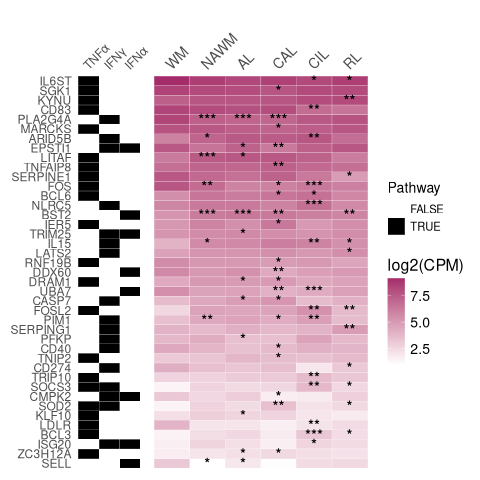

In [13]:
%%R

# Gene list you want to plot
target_genes <- unique(c(TNFa_genes, IFNg_genes, IFNa_genes))

# Reorder columns
group_order <- c("WM", "NAWM", "AL", "CAL", "CIL", "RL")

# ---- 0. Filter genes to only include those with at least 1 significant status ----
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  filter(if_any(c(Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL), ~ . != "")) %>%  # only keep significant genes
  select(gene, all_of(group_order),
         Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM")


# Add significance asterisks
df_expr <- df_expr %>%
  mutate(Signif = case_when(
    Group == "NAWM" ~ Sig_NAWM,
    Group == "AL" ~ Sig_AL,
    Group == "CAL" ~ Sig_CAL,
    Group == "CIL" ~ Sig_CIL,
    Group == "RL" ~ Sig_RL,
    TRUE ~ ""
  ))

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Reorder genes for plotting
df_expr$gene <- fct_reorder(df_expr$gene, df_expr$log2CPM, .fun = mean)

# Get gene levels from df_expr BEFORE it becomes a factor (as character)
gene_levels <- levels(df_expr$gene)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `TNFα` = `TNF.α`,
  `IFNγ` = `IFN.γ`,
  `IFNα` = `IFN.α`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("TNFα", "IFNγ", "IFNα"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=12),  # consistent with heatmap
    axis.text.y = element_text(size = 12),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- 2. Heatmap (hide gene labels) ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Signif), color = "black", size = 5, vjust = 0.5, fontface = "bold") +  # bigger, bold asterisks
  scale_fill_gradient(low = "white", high = "#a52c6b", name = "log2(CPM)") +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 14),  # bigger text
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 14),       # legend text size
    legend.title = element_text(size = 16),      # legend title size
    plot.title = element_text(hjust = 0.5, size = 16)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(legend.position = "right",
        text = element_text(size = 14))   # increase all base text size as a backup

# ---- 4. Print & save ----
print(final_plot)

# Optional save
#ggsave("final_heatmap_corrections.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

In [14]:
%%R

# Define updated gene sets from each cytokine
# Combine and deduplicate TNFa genes
MTORC1 <- unique(c(
    "SHMT2", "PSMB5", "NUPR1", "SERPINH1", "TES", "ADD3", "HSPA4", "HSPD1", "CANX", 
    "PDAP1", "TM7SF2", "STIP1", "M6PR", "SQSTM1", "QDPR", "RPA1", "NAMPT", "PPIA", 
    "CYB5B", "DHFR", "PRDX1", "PSMD14", "ATP5MC1", "CTSC", "SDF2L1", "GAPDH", "P4HA1", 
    "GTF2H1", "ELOVL5", "CACYBP", "PNO1", "PPA1", "PITPNB", "PGK1", "LGMN", "PSMD12", 
    "XBP1", "SCD", "HSPA9", "CD9", "LDHA", "IDH1", "CCT6A", "LTA4H", "PSPH", "PHGDH", 
    "HSP90B1", "ME1", "NFIL3", "CALR", "UBE2D3", "SLA", "HSPA5", "EIF2S2", "ACLY", "MTHFD2", 
    "HMBS", "PGM1", "NFKBIB", "SLC7A5", "PPP1R15A", "EDEM1", "SERP1", "SLC1A5", "UFM1", 
    "PSME3", "RPN1", "PSAT1", "PFKL", "SLC7A11", "DHCR24", "NMT1", "AK4", "UCHL5", "ACSL3", 
    "ENO1", "TFRC", "TPI1", "ARPC5L", "ATP6V1D", "SLC6A6", "IMMT", "DHCR7", "DDIT4", "SLC2A1", 
    "GLRX", "BHLHE40", "ERO1A", "GPI", "ASNS", "USO1", "EGLN3", "PDK1", "CXCR4", "GBE1", "PLOD2", 
    "HPRT1", "SLC2A3", "MAP2K3", "RAB1A", "TBK1", "PSMC2", "ITGB2", "BCAT1", "VLDLR" 
))

hypoxia <- unique(c(
    "PAM", "TGFBI", "NDST1", "SDC3", "PIM1", "B3GALT6", "LARGE1", "FOSL2", "PLIN2", "ISG20", "PLAC8", 
    "ENO2", "MT2A", "SDC2", "NDRG1", "NFIL3", "PFKL", "TES", "PGM1", "GYS1", "LDHA", "SIAH2", "ACKR3", 
    "CDKN1C", "ADM", "PFKP", "ERRFI1", "PLAUR", "VEGFA", "AK4", "MAFF", "RBPJ", "ENO1", "NOCT", "SAP30", 
    "HMOX1", "P4HA1", "TPI1", "AKAP12", "GRHPR", "PPP1R3C", "ANXA2", "SLC6A6", "HDLBP", "GAPDH", "BNIP3L", 
    "SLC2A5", "DDIT4", "MXI1", "PGK1", "SLC2A1", "FBP1", "GLRX", "BHLHE40", "ERO1A", "TNFAIP3", "GPI", 
    "UGP2", "RRAGD", "RORA", "PDK1", "PHKG1", "KLF7", "XPNPEP1", "CXCR4", "GBE1", "P4HA2", "SLC2A3", 
    "FAM162A", "ZNF292", "CCNG2", "NEDD4L", "PDK3", "ANKZF1" 
))

oxphos <- unique(c(
    "POLR2F", "ATP6AP1", "ATP6V1F", "CPT1A", "ATP5MC3", "NDUFA2", "PDK4", "ATP5MC2", "TOMM70", 
     "TIMM10", "SLC25A11", "UQCR10", "NDUFS8", "NDUFS7", "ATP6V1C1", "TIMM9", "PRDX3", "HADHA", 
     "PHYH", "SLC25A20", "MRPS11", "MGST3", "SURF1", "ATP5F1D", "PHB2", "ATP5MC1", "ECHS1", "COX6B1", 
     "UQCRC1", "ATP5F1E", "TIMM50", "ALAS1", "PDP1", "ATP5PB", "ATP1B1", "ATP5PF", "GPX4", "HADHB", 
     "CYC1", "COX5B", "TIMM8B", "COX4I1", "VDAC2", "HSPA9", "LDHA", "CYB5R3", "ATP5F1B", "NDUFA3", 
     "MPC1", "SLC25A5", "UQCRQ", "ATP6V1G1", "ECH1", "ETFB", "COX7A2L", "MTX2", "NDUFB7", "MDH1", 
     "NDUFB6", "UQCRB", "NDUFA5", "UQCRFS1", "COX7B", "OXA1L", "COX5A", "IDH3B", "NQO2", "HTRA2", 
     "ATP6V1D", "GLUD1", "COX7A2", "DLAT", "NDUFB5", "ATP5PD", "ACADVL", "DECR1", "COX7C", "TIMM13", 
     "NDUFA4", "ATP5ME"  
 ))

glyc <- unique(c(
    "TGFBI", "IDH1", "B3GAT3", "PLOD1", "PYGL", "CD44", "TGFA", "CHPF2", "RRAGD", "ME1", 
    "P4HA1", "SDHC", "SDC3", "MERTK", "CYB5A", "SOD1", "UGP2", "VEGFA", "FKBP4", "EGFR", 
    "HSPA5", "GNE", "ALDH9A1", "B3GALT6", "GALK2", "GFPT1", "CENPA", "GYS1", "MDH1", "HDLBP", 
    "QSOX1", "AGRN", "PGK1", "TALDO1", "GMPPB", "LDHA", "ALG1", "PPP2CB", "ENO2", "DSC2", "PAM", 
    "STMN1", "ISG20", "SDC2", "PHKA2", "PC", "ARPP19", "PFKP", "POLR3K", "PKM", "AK4", "ENO1", 
    "PYGB", "SAP30", "TPI1", "SLC16A3", "LHPP", "HOMER1", "PGAM1", "DDIT4", "GALE", "MXI1", 
    "HS2ST1", "GLRX", "PKP2", "EGLN3", "CXCR4", "PLOD2", "P4HA2", "ERO1A", "FAM162A", "ZNF292", 
    "PDK3", "ANKZF1", "COPB2" 
 ))


# All genes mentioned in annotations
all_genes <- unique(c(MTORC1, hypoxia, oxphos, glyc))

# ---- 2. Create annotation dataframe (wide) ----
annotation_df <- data.frame(
  gene = all_genes,
  `MTORC1` = all_genes %in% MTORC1,
  `Hypoxia` = all_genes %in% hypoxia,
  `OxPhos` = all_genes %in% oxphos,
  `Glycolysis` = all_genes %in% glyc
)

#colnames(annotation_df)
dim(annotation_df)

[1] 272   5


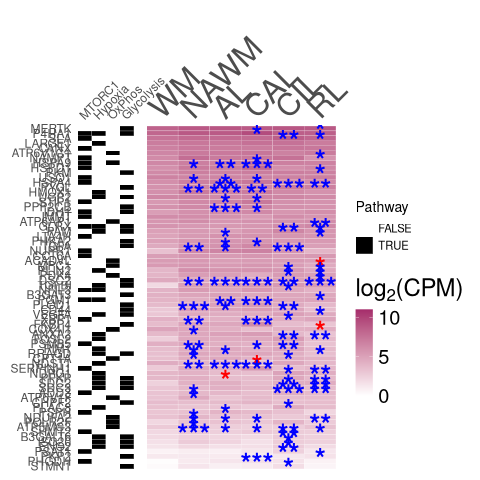

In [15]:
%%R

# Gene list you want to plot
target_genes <- all_genes

# Reorder columns
group_order <- c("WM", "NAWM", "AL", "CAL", "CIL", "RL")

# ---- Add logFC values into the long df ----
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL,
         logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "NAWM" ~ Sig_NAWM,
      Group == "AL"   ~ Sig_AL,
      Group == "CAL"  ~ Sig_CAL,
      Group == "CIL"  ~ Sig_CIL,
      Group == "RL"   ~ Sig_RL,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "NAWM" ~ logFC_NAWM,
      Group == "AL"   ~ logFC_AL,
      Group == "CAL"  ~ logFC_CAL,
      Group == "CIL"  ~ logFC_CIL,
      Group == "RL"   ~ logFC_RL,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,                  # no sig = no color
      logFC_val > 0 ~ "blue",                       # upregulated
      logFC_val < 0 ~ "red",                        # downregulated
      TRUE ~ "blue"
    )
  )

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Reorder genes for plotting
df_expr$gene <- fct_reorder(df_expr$gene, df_expr$log2CPM, .fun = mean)

# Get gene levels from df_expr BEFORE it becomes a factor (as character)
gene_levels <- levels(df_expr$gene)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `MTORC1` = `MTORC1`,
  `Hypoxia` = `Hypoxia`,
  `OxPhos` = `OxPhos`,
  `Glycolysis` = `Glycolysis`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("MTORC1", "Hypoxia", "OxPhos", "Glycolysis"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=12),  # consistent with heatmap
    axis.text.y = element_text(size = 12),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- Modify heatmap with colored asterisks ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = Signif, color = AsteriskColor),
    size = 10, vjust = 0.6, fontface = "bold"
  ) +
  scale_color_identity() +   # respects the "black"/"blue" directly
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      breaks = c(0, 5, 10), limits = c(0, 11)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    plot.title = element_text(hjust = 0.5, size = 24)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(legend.position = "right",
        text = element_text(size = 14))   # increase all base text size as a backup

# ---- 4. Print & save ----
print(final_plot)

# Optional save
#ggsave("final_heatmap_corrections.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

In [16]:
%%R

# Define updated gene sets from each cytokine
# Combine and deduplicate TNFa genes
MTORC1 <- unique(c(
    "SHMT2", "PSMB5", "NUPR1", "SERPINH1", "TES", "ADD3", "HSPA4", "HSPD1", "CANX", 
    "PDAP1", "TM7SF2", "STIP1", "M6PR", "SQSTM1", "QDPR", "RPA1", "NAMPT", "PPIA", 
    "CYB5B", "DHFR", "PRDX1", "PSMD14", "ATP5MC1", "CTSC", "SDF2L1", "GAPDH", "P4HA1", 
    "GTF2H1", "ELOVL5", "CACYBP", "PNO1", "PPA1", "PITPNB", "PGK1", "LGMN", "PSMD12", 
    "XBP1", "SCD", "HSPA9", "CD9", "LDHA", "IDH1", "CCT6A", "LTA4H", "PSPH", "PHGDH", 
    "HSP90B1", "ME1", "NFIL3", "CALR", "UBE2D3", "SLA", "HSPA5", "EIF2S2", "ACLY", "MTHFD2", 
    "HMBS", "PGM1", "NFKBIB", "SLC7A5", "PPP1R15A", "EDEM1", "SERP1", "SLC1A5", "UFM1", 
    "PSME3", "RPN1", "PSAT1", "PFKL", "SLC7A11", "DHCR24", "NMT1", "AK4", "UCHL5", "ACSL3", 
    "ENO1", "TFRC", "TPI1", "ARPC5L", "ATP6V1D", "SLC6A6", "IMMT", "DHCR7", "DDIT4", "SLC2A1", 
    "GLRX", "BHLHE40", "ERO1A", "GPI", "ASNS", "USO1", "EGLN3", "PDK1", "CXCR4", "GBE1", "PLOD2", 
    "HPRT1", "SLC2A3", "MAP2K3", "RAB1A", "TBK1", "PSMC2", "ITGB2", "BCAT1", "VLDLR" 
))

hypoxia <- unique(c(
    "PAM", "TGFBI", "NDST1", "SDC3", "PIM1", "B3GALT6", "LARGE1", "FOSL2", "PLIN2", "ISG20", "PLAC8", 
    "ENO2", "MT2A", "SDC2", "NDRG1", "NFIL3", "PFKL", "TES", "PGM1", "GYS1", "LDHA", "SIAH2", "ACKR3", 
    "CDKN1C", "ADM", "PFKP", "ERRFI1", "PLAUR", "VEGFA", "AK4", "MAFF", "RBPJ", "ENO1", "NOCT", "SAP30", 
    "HMOX1", "P4HA1", "TPI1", "AKAP12", "GRHPR", "PPP1R3C", "ANXA2", "SLC6A6", "HDLBP", "GAPDH", "BNIP3L", 
    "SLC2A5", "DDIT4", "MXI1", "PGK1", "SLC2A1", "FBP1", "GLRX", "BHLHE40", "ERO1A", "TNFAIP3", "GPI", 
    "UGP2", "RRAGD", "RORA", "PDK1", "PHKG1", "KLF7", "XPNPEP1", "CXCR4", "GBE1", "P4HA2", "SLC2A3", 
    "FAM162A", "ZNF292", "CCNG2", "NEDD4L", "PDK3", "ANKZF1" 
))

glyc <- unique(c(
    "TGFBI", "IDH1", "B3GAT3", "PLOD1", "PYGL", "CD44", "TGFA", "CHPF2", "RRAGD", "ME1", 
    "P4HA1", "SDHC", "SDC3", "MERTK", "CYB5A", "SOD1", "UGP2", "VEGFA", "FKBP4", "EGFR", 
    "HSPA5", "GNE", "ALDH9A1", "B3GALT6", "GALK2", "GFPT1", "CENPA", "GYS1", "MDH1", "HDLBP", 
    "QSOX1", "AGRN", "PGK1", "TALDO1", "GMPPB", "LDHA", "ALG1", "PPP2CB", "ENO2", "DSC2", "PAM", 
    "STMN1", "ISG20", "SDC2", "PHKA2", "PC", "ARPP19", "PFKP", "POLR3K", "PKM", "AK4", "ENO1", 
    "PYGB", "SAP30", "TPI1", "SLC16A3", "LHPP", "HOMER1", "PGAM1", "DDIT4", "GALE", "MXI1", 
    "HS2ST1", "GLRX", "PKP2", "EGLN3", "CXCR4", "PLOD2", "P4HA2", "ERO1A", "FAM162A", "ZNF292", 
    "PDK3", "ANKZF1", "COPB2" 
 ))


# All genes mentioned in annotations
all_genes <- unique(c(MTORC1, glyc, hypoxia))

# ---- 2. Create annotation dataframe (wide) ----
annotation_df <- data.frame(
  gene = all_genes,
  `MTORC1` = all_genes %in% MTORC1,
  `Glycolysis` = all_genes %in% glyc,
  `Hypoxia` = all_genes %in% hypoxia
)

#colnames(annotation_df)
dim(annotation_df)

[1] 197   4


In [17]:
%%R
# Filter merged_df for genes significant in at least one condition
sig_genes_df <- merged_df %>%
  filter(Sig_NAWM != "" | Sig_AL != "" | Sig_CAL != "" | Sig_CIL != "" | Sig_RL != "")

# Or, equivalently (safer if NAs exist):
sig_genes_df <- merged_df %>%
  filter(if_any(starts_with("Sig_"), ~ !is.na(.) & . != ""))

# Check how many genes are significant
cat("Number of significant genes:", nrow(sig_genes_df), "\n")

# Optionally list unique significant gene names
sig_genes <- unique(sig_genes_df$gene)
cat("Unique significant genes:", length(sig_genes), "\n")

Number of significant genes: 1449 
Unique significant genes: 1449 


In [18]:
%%R
# Keep only genes that are both annotated AND significant
all_genes <- intersect(all_genes, sig_genes)

# If you want to see how many remain:
cat("Genes retained for plotting:", length(all_genes), "\n")

Genes retained for plotting: 48 


In [19]:
%%R
all_genes

 [1] "SHMT2"    "NUPR1"    "SERPINH1" "ADD3"     "HSPA4"    "HSPD1"   
 [7] "STIP1"    "NAMPT"    "P4HA1"    "XBP1"     "HSPA9"    "IDH1"    
[13] "LTA4H"    "PSPH"     "PHGDH"    "NFIL3"    "SLA"      "PGM1"    
[19] "PSAT1"    "GLRX"     "TGFBI"    "PLOD1"    "PYGL"     "CD44"    
[25] "TGFA"     "RRAGD"    "SDC3"     "MERTK"    "VEGFA"    "FKBP4"   
[31] "B3GALT6"  "ENO2"     "DSC2"     "PAM"      "STMN1"    "ISG20"   
[37] "SDC2"     "PFKP"     "PKM"      "PKP2"     "NDST1"    "PIM1"    
[43] "FOSL2"    "PLIN2"    "PLAC8"    "NDRG1"    "HMOX1"    "ANXA2"   


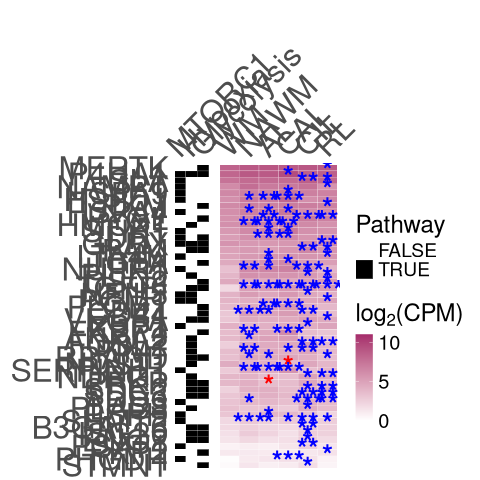

In [20]:
%%R

# Gene list you want to plot
target_genes <- all_genes

# Reorder columns
group_order <- c("WM", "NAWM", "AL", "CAL", "CIL", "RL")

# ---- Add logFC values into the long df ----
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL,
         logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "NAWM" ~ Sig_NAWM,
      Group == "AL"   ~ Sig_AL,
      Group == "CAL"  ~ Sig_CAL,
      Group == "CIL"  ~ Sig_CIL,
      Group == "RL"   ~ Sig_RL,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "NAWM" ~ logFC_NAWM,
      Group == "AL"   ~ logFC_AL,
      Group == "CAL"  ~ logFC_CAL,
      Group == "CIL"  ~ logFC_CIL,
      Group == "RL"   ~ logFC_RL,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,                  # no sig = no color
      logFC_val > 0 ~ "blue",                       # upregulated
      logFC_val < 0 ~ "red",                        # downregulated
      TRUE ~ "blue"
    )
  )

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Reorder genes for plotting
df_expr$gene <- fct_reorder(df_expr$gene, df_expr$log2CPM, .fun = mean)

# Get gene levels from df_expr BEFORE it becomes a factor (as character)
gene_levels <- levels(df_expr$gene)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `MTORC1` = `MTORC1`,
  `Hypoxia` = `Hypoxia`,
  `Glycolysis` = `Glycolysis`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("MTORC1", "Hypoxia", "Glycolysis"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=32),  # consistent with heatmap
    axis.text.y = element_text(size = 32),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- Modify heatmap with colored asterisks ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = Signif, color = AsteriskColor),
    size = 10, vjust = 0.6, fontface = "bold"
  ) +
  scale_color_identity() +   # respects the "black"/"blue" directly
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      breaks = c(0, 5, 10), limits = c(0, 11)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    plot.title = element_text(hjust = 0.5, size = 24)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(
    legend.position = "right",
    text = element_text(size = 24)  # ← general text size fallback (affects e.g. facet labels if any)
  )

# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("MG_heatmap_working.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

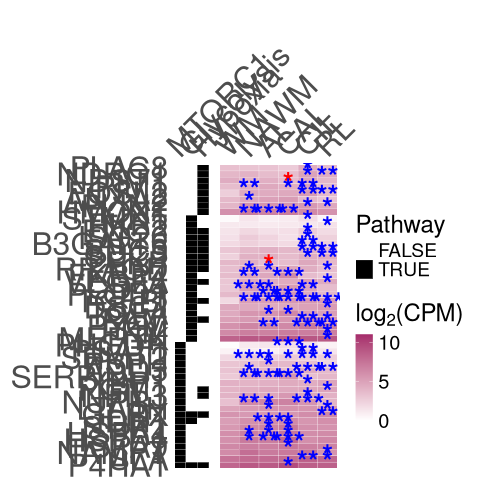

In [21]:
%%R

# Gene list you want to plot
target_genes <- all_genes

# Reorder columns
group_order <- c("WM", "NAWM", "AL", "CAL", "CIL", "RL")

# ---- Add logFC values into the long df ----
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL,
         logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "NAWM" ~ Sig_NAWM,
      Group == "AL"   ~ Sig_AL,
      Group == "CAL"  ~ Sig_CAL,
      Group == "CIL"  ~ Sig_CIL,
      Group == "RL"   ~ Sig_RL,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "NAWM" ~ logFC_NAWM,
      Group == "AL"   ~ logFC_AL,
      Group == "CAL"  ~ logFC_CAL,
      Group == "CIL"  ~ logFC_CIL,
      Group == "RL"   ~ logFC_RL,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,                  # no sig = no color
      logFC_val > 0 ~ "blue",                       # upregulated
      logFC_val < 0 ~ "red",                        # downregulated
      TRUE ~ "blue"
    )
  )

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `MTORC1` = `MTORC1`,
  `Hypoxia` = `Hypoxia`,
  `Glycolysis` = `Glycolysis`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# ---- Calculate mean log2CPM per gene for ordering ----
gene_mean_expr <- df_expr %>%
  group_by(gene) %>%
  summarize(mean_log2CPM = mean(log2CPM, na.rm = TRUE), .groups = "drop")

# ---- Create gene ordering by pathway priority, then by mean logCPM ----
# Start with all genes and their pathway memberships
gene_pathway_order <- tibble(gene = unique(df_expr$gene)) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  left_join(gene_mean_expr, by = "gene") %>%
  mutate(
    # Assign pathway priority: 1 = MTORC1, 2 = Glycolysis, 3 = Hypoxia, 4 = None
    pathway_priority = case_when(
      MTORC1 ~ 1,
      Glycolysis ~ 2,
      Hypoxia ~ 3,
      TRUE ~ 4
    )
  ) %>%
  arrange(pathway_priority, desc(mean_log2CPM))

# Extract the ordered gene levels
gene_levels <- gene_pathway_order$gene

# Apply the custom gene order to df_expr
df_expr$gene <- factor(df_expr$gene, levels = gene_levels)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("MTORC1", "Glycolysis", "Hypoxia"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=32),  # consistent with heatmap
    axis.text.y = element_text(size = 32),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- Modify heatmap with colored asterisks ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = Signif, color = AsteriskColor),
    size = 10, vjust = 0.6, fontface = "bold"
  ) +
  scale_color_identity() +   # respects the "black"/"blue" directly
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      breaks = c(0, 5, 10), limits = c(0, 11)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    plot.title = element_text(hjust = 0.5, size = 24)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(
    legend.position = "right",
    text = element_text(size = 24)  # ← general text size fallback (affects e.g. facet labels if any)
  )

# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("MG_heatmap_working.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

# Gene by gene plots

In [ ]:
import seaborn as sns

# Specify your gene
gene_to_plot = "GLRX"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}

custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]

plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"{gene_to_plot}")
plt.ylabel("log1p-CPM")
plt.xlabel("Lesion Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns

# Specify your gene
gene_to_plot = "NAMPT"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}

custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]

plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"{gene_to_plot}")
plt.ylabel("log1p-CPM")
plt.xlabel("Lesion Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns

# Specify your gene
gene_to_plot = "NUPR1"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}

custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]

plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"{gene_to_plot}")
plt.ylabel("log1p-CPM")
plt.xlabel("Lesion Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

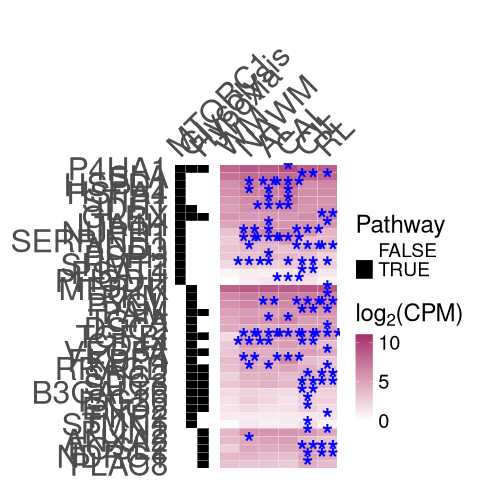

In [22]:
%%R

# Gene list you want to plot
target_genes <- c(
  "SHMT2", "NUPR1", "SERPINH1", "ADD3", "HSPA4", "HSPD1",
  "STIP1", "P4HA1", "IDH1",
  "LTA4H", "PSPH", "PHGDH", "SLA",
  "PSAT1", "GLRX", "TGFBI", "PYGL", "CD44",
  "TGFA", "RRAGD", "SDC3", "MERTK", "VEGFA", "FKBP4",
  "B3GALT6", "ENO2", "DSC2", "PAM", "STMN1", "ISG20",
  "SDC2", "PKM", "PKP2",
  "FOSL2", "PLIN2", "PLAC8", "NDRG1", "ANXA2"
)

# Reorder columns
group_order <- c("WM", "NAWM", "AL", "CAL", "CIL", "RL")

# ---- Add logFC values into the long df ----
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL,
         logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "NAWM" ~ Sig_NAWM,
      Group == "AL"   ~ Sig_AL,
      Group == "CAL"  ~ Sig_CAL,
      Group == "CIL"  ~ Sig_CIL,
      Group == "RL"   ~ Sig_RL,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "NAWM" ~ logFC_NAWM,
      Group == "AL"   ~ logFC_AL,
      Group == "CAL"  ~ logFC_CAL,
      Group == "CIL"  ~ logFC_CIL,
      Group == "RL"   ~ logFC_RL,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,                  # no sig = no color
      logFC_val > 0 ~ "blue",                       # upregulated
      logFC_val < 0 ~ "red",                        # downregulated
      TRUE ~ "blue"
    )
  )

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `MTORC1` = `MTORC1`,
  `Hypoxia` = `Hypoxia`,
  `Glycolysis` = `Glycolysis`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# ---- Calculate mean log2CPM per gene for ordering ----
gene_mean_expr <- df_expr %>%
  group_by(gene) %>%
  summarize(mean_log2CPM = mean(log2CPM, na.rm = TRUE), .groups = "drop")

# ---- Create gene ordering by pathway priority, then by mean logCPM ----
# Start with all genes and their pathway memberships
gene_pathway_order <- tibble(gene = unique(df_expr$gene)) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  left_join(gene_mean_expr, by = "gene") %>%
  mutate(
    # Assign pathway priority: 1 = MTORC1, 2 = Glycolysis, 3 = Hypoxia, 4 = None
    pathway_priority = case_when(
      MTORC1 ~ 1,
      Glycolysis ~ 2,
      Hypoxia ~ 3,
      TRUE ~ 4
    )
  ) %>%
  arrange(pathway_priority, desc(mean_log2CPM))

# Extract the ordered gene levels and reverse them
gene_levels <- rev(gene_pathway_order$gene)

# Apply the custom gene order to df_expr
df_expr$gene <- factor(df_expr$gene, levels = gene_levels)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("MTORC1", "Glycolysis", "Hypoxia"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=32),  # consistent with heatmap
    axis.text.y = element_text(size = 32),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- Modify heatmap with colored asterisks ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = Signif, color = AsteriskColor),
    size = 10, vjust = 0.6, fontface = "bold"
  ) +
  scale_color_identity() +   # respects the "black"/"blue" directly
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      breaks = c(0, 5, 10), limits = c(0, 11)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    plot.title = element_text(hjust = 0.5, size = 24)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(
    legend.position = "right",
    text = element_text(size = 24)  # ← general text size fallback (affects e.g. facet labels if any)
  )

# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("MG_heatmap_working.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

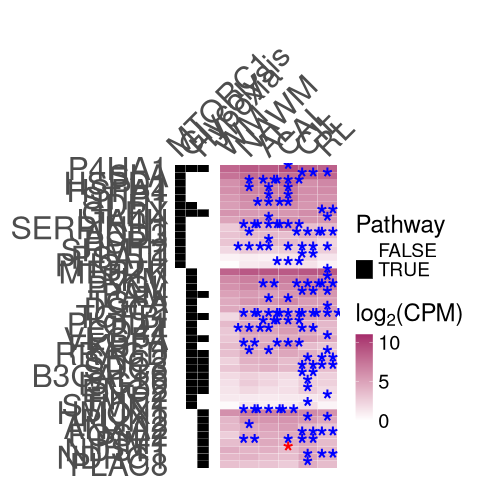

In [23]:
%%R

# Gene list you want to plot
target_genes <- c(
  "SHMT2", "SERPINH1", "ADD3", "HSPA4", "HSPD1",
  "STIP1", "P4HA1", "IDH1",
  "LTA4H", "PSPH", "PHGDH", "SLA",
  "PSAT1", "GLRX", "TGFBI", "PLOD1", "PYGL", "CD44",
  "TGFA", "RRAGD", "SDC3", "MERTK", "VEGFA", "FKBP4",
  "B3GALT6", "ENO2", "DSC2", "PAM", "STMN1", "ISG20",
  "SDC2", "PKM", "PKP2", "NDST1", "PIM1",
  "FOSL2", "PLIN2", "PLAC8", "NDRG1", "HMOX1", "ANXA2"
)

# Reorder columns
group_order <- c("WM", "NAWM", "AL", "CAL", "CIL", "RL")

# ---- Add logFC values into the long df ----
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL,
         logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "NAWM" ~ Sig_NAWM,
      Group == "AL"   ~ Sig_AL,
      Group == "CAL"  ~ Sig_CAL,
      Group == "CIL"  ~ Sig_CIL,
      Group == "RL"   ~ Sig_RL,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "NAWM" ~ logFC_NAWM,
      Group == "AL"   ~ logFC_AL,
      Group == "CAL"  ~ logFC_CAL,
      Group == "CIL"  ~ logFC_CIL,
      Group == "RL"   ~ logFC_RL,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,                  # no sig = no color
      logFC_val > 0 ~ "blue",                       # upregulated
      logFC_val < 0 ~ "red",                        # downregulated
      TRUE ~ "blue"
    )
  )

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `MTORC1` = `MTORC1`,
  `Hypoxia` = `Hypoxia`,
  `Glycolysis` = `Glycolysis`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# ---- Calculate mean log2CPM per gene for ordering ----
gene_mean_expr <- df_expr %>%
  group_by(gene) %>%
  summarize(mean_log2CPM = mean(log2CPM, na.rm = TRUE), .groups = "drop")

# ---- Create gene ordering by pathway priority, then by mean logCPM ----
# Start with all genes and their pathway memberships
gene_pathway_order <- tibble(gene = unique(df_expr$gene)) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  left_join(gene_mean_expr, by = "gene") %>%
  mutate(
    # Assign pathway priority: 1 = MTORC1, 2 = Glycolysis, 3 = Hypoxia, 4 = None
    pathway_priority = case_when(
      MTORC1 ~ 1,
      Glycolysis ~ 2,
      Hypoxia ~ 3,
      TRUE ~ 4
    )
  ) %>%
  arrange(pathway_priority, desc(mean_log2CPM))

# Extract the ordered gene levels and reverse them
gene_levels <- rev(gene_pathway_order$gene)

# Apply the custom gene order to df_expr
df_expr$gene <- factor(df_expr$gene, levels = gene_levels)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("MTORC1", "Glycolysis", "Hypoxia"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=32),  # consistent with heatmap
    axis.text.y = element_text(size = 32),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- Modify heatmap with colored asterisks ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = Signif, color = AsteriskColor),
    size = 10, vjust = 0.6, fontface = "bold"
  ) +
  scale_color_identity() +   # respects the "black"/"blue" directly
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      breaks = c(0, 5, 10), limits = c(0, 11)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    plot.title = element_text(hjust = 0.5, size = 24)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(
    legend.position = "right",
    text = element_text(size = 24)  # ← general text size fallback (affects e.g. facet labels if any)
  )

# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("MG_heatmap_working2.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

# FINAL PLOT

In [91]:
%%R

inflam_genes <- pathwaysH$HALLMARK_INFLAMMATORY_RESPONSE

# Wrap each gene in quotes
inflam_genes <- paste0('"', inflam_genes, '"')

# Print as a comma-separated string
cat(paste(inflam_genes, collapse = ", "), "\n")

"ABCA1", "ABI1", "ACVR1B", "ACVR2A", "ADGRE1", "ADM", "ADORA2B", "ADRM1", "AHR", "APLNR", "AQP9", "ATP2A2", "ATP2B1", "ATP2C1", "AXL", "BDKRB1", "BEST1", "BST2", "BTG2", "C3AR1", "C5AR1", "CALCRL", "CCL17", "CCL2", "CCL20", "CCL22", "CCL24", "CCL5", "CCL5", "CCL7", "CCR7", "CCRL2", "CD14", "CD40", "CD48", "CD55", "CD69", "CD70", "CD82", "CDKN1A", "CHST2", "CLEC5A", "CMKLR1", "CSF1", "CSF3", "CSF3R", "CX3CL1", "CXCL10", "CXCL11", "CXCL6", "CXCL8", "CXCL9", "CXCR6", "CYBB", "DCBLD2", "EBI3", "EDN1", "EIF2AK2", "EMP3", "EREG", "F3", "FFAR2", "FPR1", "FZD5", "GABBR1", "GABBR1", "GABBR1", "GABBR1", "GABBR1", "GABBR1", "GABBR1", "GCH1", "GNA15", "GNAI3", "GP1BA", "GPC3", "GPR132", "GPR183", "HAS2", "HBEGF", "HIF1A", "HPN", "HRH1", "ICAM1", "ICAM4", "ICOSLG", "IFITM1", "IFNAR1", "IFNGR2", "IFNGR2", "IL10", "IL10RA", "IL12B", "IL15", "IL15RA", "IL18", "IL18R1", "IL18RAP", "IL1A", "IL1B", "IL1R1", "IL2RB", "IL4R", "IL6", "IL7R", "INHBA", "IRAK2", "IRF1", "IRF7", "IRF7", "ITGA5", "ITGB3", "ITGB8

In [93]:
%%R

hypoxia_genes <- pathwaysH$HALLMARK_HYPOXIA

# Wrap each gene in quotes
hypoxia_genes <- paste0('"', hypoxia_genes, '"')

# Print as a comma-separated string
cat(paste(hypoxia_genes, collapse = ", "), "\n")

"ACKR3", "ADM", "ADORA2B", "AK4", "AKAP12", "ALDOA", "ALDOB", "ALDOC", "AMPD3", "ANGPTL4", "ANKZF1", "ANXA2", "ATF3", "ATP7A", "B3GALT6", "B4GALNT2", "BCAN", "BCL2", "BGN", "BHLHE40", "BNIP3L", "BRS3", "BTG1", "CA12", "CASP6", "CAV1", "CAVIN1", "CAVIN3", "CCN1", "CCN2", "CCN5", "CCNG2", "CDKN1A", "CDKN1B", "CDKN1C", "CDKN1C", "CHST2", "CHST3", "CITED2", "COL5A1", "CP", "CSRP2", "CXCR4", "DCN", "DDIT3", "DDIT4", "DPYSL4", "DTNA", "DUSP1", "EDN2", "EFNA1", "EFNA3", "EGFR", "ENO1", "ENO2", "ENO3", "ERO1A", "ERRFI1", "ETS1", "EXT1", "F3", "FAM162A", "FBP1", "FOS", "FOSL2", "FOXO3", "GAA", "GALK1", "GAPDH", "GAPDHS", "GBE1", "GCK", "GCNT2", "GCNT2", "GLRX", "GPC1", "GPC3", "GPC4", "GPI", "GPI", "GRHPR", "GYS1", "HAS1", "HDLBP", "HEXA", "HK1", "HK2", "HMOX1", "HOXB9", "HS3ST1", "HSPA5", "IDS", "IER3", "IER3", "IER3", "IER3", "IER3", "IER3", "IER3", "IGFBP1", "IGFBP3", "IL6", "ILVBL", "INHA", "IRS2", "ISG20", "JMJD6", "JUN", "KDELR3", "KDM3A", "KIF5A", "KLF6", "KLF7", "KLHL24", "LALBA", "LARG

In [94]:
%%R

comp_genes <- pathwaysH$HALLMARK_COMPLEMENT

# Wrap each gene in quotes
comp_genes <- paste0('"', comp_genes, '"')

# Print as a comma-separated string
cat(paste(comp_genes, collapse = ", "), "\n")

"ACTN2", "ADAM9", "ADAM9", "ADRA2B", "AKAP10", "ANG", "ANXA5", "APOA4", "APOBEC3F", "APOBEC3G", "APOC1", "ATOX1", "BRPF3", "C1QA", "C1QC", "C1R", "C1R", "C1S", "C2", "C2", "C2", "C2", "C2", "C2", "C2", "C3", "C4BPB", "C9", "CA2", "CALM1", "CALM3", "CASP1", "CASP10", "CASP3", "CASP4", "CASP5", "CASP7", "CASP9", "CBLB", "CCL5", "CCL5", "CD36", "CD40LG", "CD46", "CD55", "CD59", "CDA", "CDH13", "CDK5R1", "CEBPB", "CFB", "CFB", "CFB", "CFB", "CFB", "CFB", "CFB", "CFH", "CLU", "COL4A2", "CP", "CPM", "CPQ", "CR1", "CR2", "CSRP1", "CTSB", "CTSB", "CTSC", "CTSD", "CTSH", "CTSL", "CTSO", "CTSO", "CTSS", "CTSV", "CXCL1", "DGKG", "DGKH", "DOCK10", "DOCK4", "DOCK9", "DPP4", "DUSP5", "DUSP6", "DYRK2", "EHD1", "ERAP2", "F10", "F2", "F3", "F5", "F7", "F8", "FCER1G", "FCN1", "FDX1", "FN1", "FYN", "GATA3", "GCA", "GMFB", "GNAI2", "GNAI3", "GNB2", "GNB4", "GNG2", "GNGT2", "GP1BA", "GP9", "GPD2", "GRB2", "GZMA", "GZMB", "GZMK", "HNF4A", "HPCAL4", "HSPA1A", "HSPA1A", "HSPA1A", "HSPA1A", "HSPA1A", "HSPA5", 

In [95]:
%%R

gly_genes <- pathwaysH$HALLMARK_GLYC

# Wrap each gene in quotes
gly_genes <- paste0('"', gly_genes, '"')

# Print as a comma-separated string
cat(paste(gly_genes, collapse = ", "), "\n")

"ABCB6", "ADORA2B", "AGL", "AGRN", "AK3", "AK4", "AKR1A1", "ALDH7A1", "ALDH9A1", "ALDOA", "ALDOB", "ALG1", "ANG", "ANGPTL4", "ANKZF1", "ARPP19", "ARTN", "AURKA", "B3GALT6", "B3GAT1", "B3GAT3", "B3GNT3", "B4GALT1", "B4GALT2", "B4GALT4", "B4GALT7", "BIK", "BPNT1", "CACNA1H", "CAPN5", "CAPN5", "CAPN5", "CASP6", "CD44", "CDK1", "CENPA", "CHPF", "CHPF2", "CHST1", "CHST12", "CHST2", "CHST4", "CHST6", "CITED2", "CLDN3", "CLDN9", "CLN6", "COG2", "COL5A1", "COPB2", "CTH", "CXCR4", "CYB5A", "DCN", "DDIT4", "DEPDC1", "DLD", "DPYSL4", "DSC2", "ECD", "EFNA3", "EGFR", "EGLN3", "ELF3", "ENO1", "ENO2", "ERO1A", "EXT1", "EXT2", "FAM162A", "FBP2", "FKBP4", "FUT8", "G6PD", "GAL3ST1", "GALE", "GALK1", "GALK2", "GAPDHS", "GCLC", "GFPT1", "GFUS", "GFUS", "GLCE", "GLRX", "GMPPA", "GMPPB", "GNE", "GNPDA1", "GOT1", "GOT2", "GPC1", "GPC3", "GPC4", "GPR87", "GUSB", "GYS1", "GYS2", "HAX1", "HDLBP", "HK2", "HMMR", "HOMER1", "HS2ST1", "HS6ST2", "HSPA5", "IDH1", "IDUA", "IER3", "IER3", "IER3", "IER3", "IER3", "IER3"

In [24]:
%%R

# Define updated gene sets from each cytokine
# Combine and deduplicate TNFa genes
complement <- unique(c(
    "ACTN2", "ADAM9", "ADAM9", "ADRA2B", "AKAP10", "ANG", "ANXA5", "APOA4", "APOBEC3F", "APOBEC3G", "APOC1", "ATOX1", "BRPF3", "C1QA", "C1QC", "C1R", "C1R", "C1S", "C2", "C2", "C2", "C2", "C2", "C2", "C2", "C3", "C4BPB", "C9", "CA2", "CALM1", "CALM3", "CASP1", "CASP10", "CASP3", "CASP4", "CASP5", "CASP7", "CASP9", "CBLB", "CCL5", "CCL5", "CD36", "CD40LG", "CD46", "CD55", "CD59", "CDA", "CDH13", "CDK5R1", "CEBPB", "CFB", "CFB", "CFB", "CFB", "CFB", "CFB", "CFB", "CFH", "CLU", "COL4A2", "CP", "CPM", "CPQ", "CR1", "CR2", "CSRP1", "CTSB", "CTSB", "CTSC", "CTSD", "CTSH", "CTSL", "CTSO", "CTSO", "CTSS", "CTSV", "CXCL1", "DGKG", "DGKH", "DOCK10", "DOCK4", "DOCK9", "DPP4", "DUSP5", "DUSP6", "DYRK2", "EHD1", "ERAP2", "F10", "F2", "F3", "F5", "F7", "F8", "FCER1G", "FCN1", "FDX1", "FN1", "FYN", "GATA3", "GCA", "GMFB", "GNAI2", "GNAI3", "GNB2", "GNB4", "GNG2", "GNGT2", "GP1BA", "GP9", "GPD2", "GRB2", "GZMA", "GZMB", "GZMK", "HNF4A", "HPCAL4", "HSPA1A", "HSPA1A", "HSPA1A", "HSPA1A", "HSPA1A", "HSPA5", "IL6", "IRF1", "IRF2", "IRF7", "IRF7", "ITGAM", "ITIH1", "JAK2", "KCNIP2", "KCNIP3", "KIF2A", "KLK1", "KLKB1", "KYNU", "L3MBTL4", "LAMP2", "LAP3", "LCK", "LCP2", "LGALS3", "LGMN", "LIPA", "LRP1", "LTA4H", "LTF", "LYN", "MAFF", "ME1", "MMP12", "MMP13", "MMP13", "MMP14", "MMP15", "MMP8", "MSRB1", "MT3", "NOTCH4", "NOTCH4", "NOTCH4", "NOTCH4", "NOTCH4", "NOTCH4", "NOTCH4", "OLR1", "PCLO", "PCSK9", "PDGFB", "PDP1", "PFN1", "PHEX", "PIK3CA", "PIK3CG", "PIK3R5", "PIM1", "PLA2G4A", "PLA2G7", "PLAT", "PLAUR", "PLEK", "PLG", "PLSCR1", "PPP2CB", "PPP4C", "PRCP", "PRDM4", "PREP", "PRKCD", "PRSS3", "PRSS36", "PSEN1", "PSMB9", "PSMB9", "PSMB9", "PSMB9", "PSMB9", "PSMB9", "PSMB9", "PSMB9", "RABIF", "RAF1", "RASGRP1", "RBSN", "RCE1", "RHOG", "RNF4", "S100A12", "S100A13", "S100A9", "SCG3", "SERPINA1", "SERPINA1", "SERPINB2", "SERPINC1", "SERPINE1", "SERPING1", "SH2B3", "SIRT6", "SPOCK2", "SRC", "STX4", "TFPI2", "TIMP1", "TIMP2", "TMPRSS6", "TNFAIP3", "USP14", "USP15", "USP16", "USP8", "VCPIP1", "WAS", "XPNPEP1", "ZEB1", "ZFPM2"
))

inflamm <- unique(c(
    "ABCA1", "ABI1", "ACVR1B", "ACVR2A", "ADGRE1", "ADM", "ADORA2B", "ADRM1", "AHR", "APLNR", "AQP9", "ATP2A2", "ATP2B1", "ATP2C1", "AXL", "BDKRB1", "BEST1", "BST2", "BTG2", "C3AR1", "C5AR1", "CALCRL", "CCL17", "CCL2", "CCL20", "CCL22", "CCL24", "CCL5", "CCL5", "CCL7", "CCR7", "CCRL2", "CD14", "CD40", "CD48", "CD55", "CD69", "CD70", "CD82", "CDKN1A", "CHST2", "CLEC5A", "CMKLR1", "CSF1", "CSF3", "CSF3R", "CX3CL1", "CXCL10", "CXCL11", "CXCL6", "CXCL8", "CXCL9", "CXCR6", "CYBB", "DCBLD2", "EBI3", "EDN1", "EIF2AK2", "EMP3", "EREG", "F3", "FFAR2", "FPR1", "FZD5", "GABBR1", "GABBR1", "GABBR1", "GABBR1", "GABBR1", "GABBR1", "GABBR1", "GCH1", "GNA15", "GNAI3", "GP1BA", "GPC3", "GPR132", "GPR183", "HAS2", "HBEGF", "HIF1A", "HPN", "HRH1", "ICAM1", "ICAM4", "ICOSLG", "IFITM1", "IFNAR1", "IFNGR2", "IFNGR2", "IL10", "IL10RA", "IL12B", "IL15", "IL15RA", "IL18", "IL18R1", "IL18RAP", "IL1A", "IL1B", "IL1R1", "IL2RB", "IL4R", "IL6", "IL7R", "INHBA", "IRAK2", "IRF1", "IRF7", "IRF7", "ITGA5", "ITGB3", "ITGB8", "KCNA3", "KCNJ2", "KCNMB2", "KIF1B", "KLF6", "LAMP3", "LCK", "LCP2", "LDLR", "LIF", "LPAR1", "LTA", "LTA", "LTA", "LTA", "LTA", "LTA", "LTA", "LY6E", "LY6E", "LYN", "MARCO", "MEFV", "MEP1A", "MET", "MMP14", "MSR1", "MXD1", "MYC", "NAMPT", "NDP", "NFKB1", "NFKBIA", "NLRP3", "NMI", "NMUR1", "NOD2", "NPFFR2", "OLR1", "OPRK1", "OSM", "OSMR", "P2RX4", "P2RX7", "P2RY2", "PCDH7", "PDE4B", "PDPN", "PIK3R5", "PLAUR", "PROK2", "PSEN1", "PTAFR", "PTGER2", "PTGER4", "PTGIR", "PTPRE", "PVR", "RAF1", "RASGRP1", "RELA", "RGS1", "RGS16", "RHOG", "RIPK2", "RNF144B", "ROS1", "RTP4", "SCARF1", "SCARF1", "SCN1B", "SELE", "SELENOS", "SELL", "SEMA4D", "SERPINE1", "SGMS2", "SLAMF1", "SLC11A2", "SLC1A2", "SLC28A2", "SLC31A1", "SLC31A2", "SLC4A4", "SLC7A1", "SLC7A2", "SPHK1", "SRI", "STAB1", "TACR1", "TACR3", "TAPBP", "TAPBP", "TAPBP", "TAPBP", "TAPBP", "TIMP1", "TLR1", "TLR2", "TLR3", "TNFAIP6", "TNFRSF1B", "TNFRSF9", "TNFSF10", "TNFSF15", "TNFSF9", "TPBG", "TPBG", "VIP" 
))

hypoxia <- unique(c(
    "ACKR3", "ADM", "ADORA2B", "AK4", "AKAP12", "ALDOA", "ALDOB", "ALDOC", "AMPD3", "ANGPTL4", "ANKZF1", "ANXA2", "ATF3", "ATP7A", "B3GALT6", "B4GALNT2", "BCAN", "BCL2", "BGN", "BHLHE40", "BNIP3L", "BRS3", "BTG1", "CA12", "CASP6", "CAV1", "CAVIN1", "CAVIN3", "CCN1", "CCN2", "CCN5", "CCNG2", "CDKN1A", "CDKN1B", "CDKN1C", "CDKN1C", "CHST2", "CHST3", "CITED2", "COL5A1", "CP", "CSRP2", "CXCR4", "DCN", "DDIT3", "DDIT4", "DPYSL4", "DTNA", "DUSP1", "EDN2", "EFNA1", "EFNA3", "EGFR", "ENO1", "ENO2", "ENO3", "ERO1A", "ERRFI1", "ETS1", "EXT1", "F3", "FAM162A", "FBP1", "FOS", "FOSL2", "FOXO3", "GAA", "GALK1", "GAPDH", "GAPDHS", "GBE1", "GCK", "GCNT2", "GCNT2", "GLRX", "GPC1", "GPC3", "GPC4", "GPI", "GPI", "GRHPR", "GYS1", "HAS1", "HDLBP", "HEXA", "HK1", "HK2", "HMOX1", "HOXB9", "HS3ST1", "HSPA5", "IDS", "IER3", "IER3", "IER3", "IER3", "IER3", "IER3", "IER3", "IGFBP1", "IGFBP3", "IL6", "ILVBL", "INHA", "IRS2", "ISG20", "JMJD6", "JUN", "KDELR3", "KDM3A", "KIF5A", "KLF6", "KLF7", "KLHL24", "LALBA", "LARGE1", "LDHA", "LDHA", "LDHC", "LOX", "LXN", "MAFF", "MAP3K1", "MIF", "MIF", "MT1E", "MT2A", "MXI1", "MYH9", "NAGK", "NCAN", "NDRG1", "NDST1", "NDST2", "NEDD4L", "NFIL3", "NOCT", "NR3C1", "P4HA1", "P4HA2", "PAM", "PCK1", "PDGFB", "PDK1", "PDK3", "PFKFB3", "PFKL", "PFKP", "PGAM2", "PGF", "PGK1", "PGM1", "PGM2", "PHKG1", "PIM1", "PKLR", "PKLR", "PKP1", "PLAC8", "PLAUR", "PLIN2", "PNRC1", "PPARGC1A", "PPFIA4", "PPP1R15A", "PPP1R3C", "PRDX5", "PRKCA", "PYGM", "RBPJ", "RORA", "RRAGD", "S100A4", "SAP30", "SCARB1", "SDC2", "SDC3", "SDC4", "SELENBP1", "SERPINE1", "SIAH2", "SLC25A1", "SLC2A1", "SLC2A3", "SLC2A5", "SLC37A4", "SLC37A4", "SLC37A4", "SLC6A6", "SRPX", "STBD1", "STC1", "STC2", "SULT2B1", "TES", "TGFB3", "TGFBI", "TGM2", "TIPARP", "TKTL1", "TMEM45A", "TNFAIP3", "TPBG", "TPBG", "TPD52", "TPI1", "TPST2", "UGP2", "VEGFA", "VHL", "VLDLR", "WSB1", "XPNPEP1", "ZFP36", "ZNF292" 
))

glyc <- unique(c(
    "ABCB6", "ADORA2B", "AGL", "AGRN", "AK3", "AK4", "AKR1A1", "ALDH7A1", "ALDH9A1", "ALDOA", "ALDOB", "ALG1", "ANG", "ANGPTL4", "ANKZF1", "ARPP19", "ARTN", "AURKA", "B3GALT6", "B3GAT1", "B3GAT3", "B3GNT3", "B4GALT1", "B4GALT2", "B4GALT4", "B4GALT7", "BIK", "BPNT1", "CACNA1H", "CAPN5", "CAPN5", "CAPN5", "CASP6", "CD44", "CDK1", "CENPA", "CHPF", "CHPF2", "CHST1", "CHST12", "CHST2", "CHST4", "CHST6", "CITED2", "CLDN3", "CLDN9", "CLN6", "COG2", "COL5A1", "COPB2", "CTH", "CXCR4", "CYB5A", "DCN", "DDIT4", "DEPDC1", "DLD", "DPYSL4", "DSC2", "ECD", "EFNA3", "EGFR", "EGLN3", "ELF3", "ENO1", "ENO2", "ERO1A", "EXT1", "EXT2", "FAM162A", "FBP2", "FKBP4", "FUT8", "G6PD", "GAL3ST1", "GALE", "GALK1", "GALK2", "GAPDHS", "GCLC", "GFPT1", "GFUS", "GFUS", "GLCE", "GLRX", "GMPPA", "GMPPB", "GNE", "GNPDA1", "GOT1", "GOT2", "GPC1", "GPC3", "GPC4", "GPR87", "GUSB", "GYS1", "GYS2", "HAX1", "HDLBP", "HK2", "HMMR", "HOMER1", "HS2ST1", "HS6ST2", "HSPA5", "IDH1", "IDUA", "IER3", "IER3", "IER3", "IER3", "IER3", "IER3", "IER3", "IGFBP3", "IL13RA1", "IRS2", "ISG20", "KDELR3", "KIF20A", "KIF2A", "LCT", "LDHA", "LDHA", "LDHC", "LHPP", "LHX9", "MDH1", "MDH2", "ME1", "ME2", "MED24", "MERTK", "MET", "MIF", "MIF", "MIOX", "MPI", "MXI1", "NANP", "NASP", "NDST3", "NDUFV3", "NOL3", "NSDHL", "NT5E", "P4HA1", "P4HA2", "PAM", "PAXIP1", "PC", "PDK3", "PFKFB1", "PFKP", "PGAM1", "PGAM2", "PGK1", "PGLS", "PGM2", "PHKA2", "PKM", "PKP2", "PLOD1", "PLOD2", "PMM2", "POLR3K", "PPFIA4", "PPIA", "PPP2CB", "PRPS1", "PSMC4", "PSMC4", "PYGB", "PYGL", "QSOX1", "RARS1", "RBCK1", "RPE", "RRAGD", "SAP30", "SDC1", "SDC2", "SDC3", "SDHC", "SLC16A3", "SLC25A10", "SLC25A13", "SLC35A3", "SLC37A4", "SLC37A4", "SLC37A4", "SOD1", "SOX9", "SPAG4", "SRD5A3", "STC1", "STC2", "STMN1", "TALDO1", "TFF3", "TGFA", "TGFBI", "TKTL1", "TPBG", "TPBG", "TPI1", "TPST1", "TXN", "UGP2", "VCAN", "VEGFA", "VLDLR", "XYLT2", "ZNF292" 
 ))


# All genes mentioned in annotations
all_genes <- unique(c(complement, inflamm, glyc, hypoxia))

# ---- 2. Create annotation dataframe (wide) ----
annotation_df <- data.frame(
  gene = all_genes,
  `Complement` = all_genes %in% complement,
  `Inflam` = all_genes %in% inflamm,
  `Glycolysis` = all_genes %in% glyc,
  `Hypoxia` = all_genes %in% hypoxia
)

#colnames(annotation_df)
dim(annotation_df)

[1] 691   5


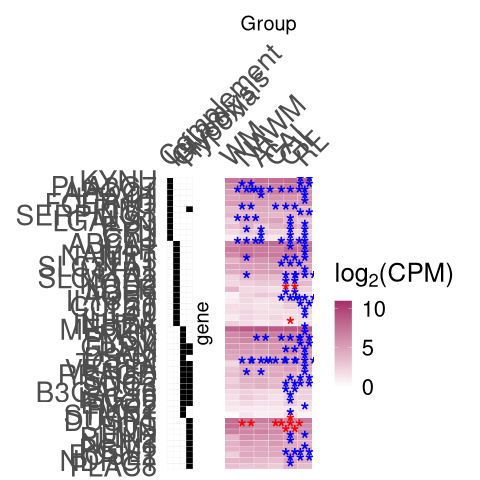

In [25]:
%%R

# ---- Define target genes ----
target_genes <- c(
    "KYNU", "PLA2G7", "SERPING1", "APOC1", "CLU", "CR1",
  "FCER1G", "FYN", "LTA4H", "LGALS3",
  "IL18R1", "SLC31A2", "CCL20", "ABCA1",
  "IL10", "IL15", "IL1R1", "IL4R", "MXD1", "NAMPT",
  "AQP9", "INHBA", "LDLR", "NOD2", "SLC31A1",
  "TGFBI", "FOSL2", "GLRX", "NDRG1", "SDC2", "SDC3", "PAM", "PGM1",
  "PLIN2", "VEGFA", "B3GALT6", "DUSP1", "ENO2", "FOS", "ISG20", "JUN",
  "NFIL3", "PIM1", "PLAC8",
  "TGFBI", "GLRX", "PYGL", "SDC2", "SDC3", "DSC2", "MERTK", "PAM", "PKM", "PKP2",
  "RRAGD", "VEGFA", "B3GALT6", "ENO2", "ISG20", "STMN1"
)

group_order <- c("WM", "NAWM", "AL", "CAL", "CIL", "RL")

# ---- Prepare df_expr ----
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL,
         logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "NAWM" ~ Sig_NAWM,
      Group == "AL"   ~ Sig_AL,
      Group == "CAL"  ~ Sig_CAL,
      Group == "CIL"  ~ Sig_CIL,
      Group == "RL"   ~ Sig_RL,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "NAWM" ~ logFC_NAWM,
      Group == "AL"   ~ logFC_AL,
      Group == "CAL"  ~ logFC_CAL,
      Group == "CIL"  ~ logFC_CIL,
      Group == "RL"   ~ logFC_RL,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,
      logFC_val > 0 ~ "blue",
      logFC_val < 0 ~ "red",
      TRUE ~ "blue"
    )
  )

df_expr$Group <- factor(df_expr$Group, levels = group_order)

# ---- Pathway annotation tidy ----
annotation_long <- annotation_df %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# ---- Calculate mean expression for sorting ----
gene_mean_expr <- df_expr %>%
  group_by(gene) %>%
  summarize(mean_log2CPM = mean(log2CPM, na.rm = TRUE), .groups = "drop")

# ---- Order genes by pathway priority then expression ----
gene_pathway_order <- tibble(gene = unique(df_expr$gene)) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  left_join(gene_mean_expr, by = "gene") %>%
  mutate(
    pathway_priority = case_when(
      Complement ~ 1,
      Inflam ~ 2,
      Glycolysis ~ 3,
      Hypoxia ~ 4,
      TRUE ~ 5
    )
  ) %>%
  arrange(pathway_priority, desc(mean_log2CPM))

gene_levels <- rev(gene_pathway_order$gene)
df_expr$gene <- factor(df_expr$gene, levels = gene_levels)

# ---- Make annotation display with same gene order ----
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("Complement", "Inflam", "Glycolysis", "Hypoxia"))
  )

# ---- Annotation block ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "grey90") +
  scale_fill_manual(values = c("TRUE" = "black", "FALSE" = "white"), guide = "none") +
  scale_x_discrete(position = "top") +
  theme_minimal(base_size = 20) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 28),
    axis.text.y = element_text(size = 28),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    plot.margin = margin(5, 0, 5, 10)
  )

# ---- Heatmap ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Signif, color = AsteriskColor),
            size = 8, vjust = 0.6, fontface = "bold") +
  scale_color_identity() +
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      limits = c(0, 11), breaks = c(0, 5, 10)) +
  scale_x_discrete(position = "top") +
  theme_minimal(base_size = 20) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 28),
    axis.text.y = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 22),
    legend.title = element_text(size = 26),
    panel.grid = element_blank(),
    plot.margin = margin(5, 10, 5, 0)
  )

# ---- Combine & align ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.5, 5), guides = "collect") &
  theme(legend.position = "right")

# ---- Render & save ----
print(final_plot)

ggsave("MG_heatmap_aligned.png", plot = final_plot,
       width = 14, height = 18, units = "in", dpi = 600)

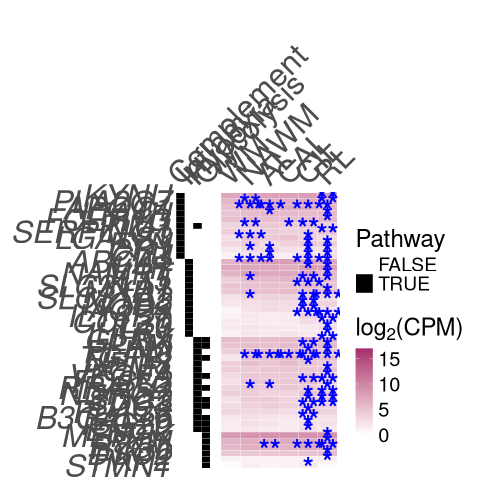

In [27]:
%%R

# ---- Define target genes ----
target_genes <- c(
    "KYNU", "PLA2G7", "SERPING1", "APOC1", "CLU", "CR1",
  "FCER1G", "FYN", "LTA4H", "LGALS3",
  "IL18R1", "SLC31A2", "CCL20", "ABCA1",
  "IL10", "IL15", "IL1R1", "IL4R", "MXD1", "NAMPT",
  "AQP9", "NOD2", "SLC31A1",
  "TGFBI", "FOSL2", "GLRX", "NDRG1", "SDC2", "SDC3", "PAM", "PGM1",
  "PLIN2", "VEGFA", "B3GALT6", "ENO2", "ISG20",
  "NFIL3", "PIM1", "PLAC8",
  "TGFBI", "GLRX", "PYGL", "SDC2", "SDC3", "DSC2", "MERTK", "PAM", "PKM", "PKP2",
  "RRAGD", "VEGFA", "B3GALT6", "ENO2", "ISG20", "STMN1"
)

group_order <- c("WM", "NAWM", "AL", "CAL", "CIL", "RL")


# ---- Prepare df_expr ----
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL,
         logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "NAWM" ~ Sig_NAWM,
      Group == "AL"   ~ Sig_AL,
      Group == "CAL"  ~ Sig_CAL,
      Group == "CIL"  ~ Sig_CIL,
      Group == "RL"   ~ Sig_RL,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "NAWM" ~ logFC_NAWM,
      Group == "AL"   ~ logFC_AL,
      Group == "CAL"  ~ logFC_CAL,
      Group == "CIL"  ~ logFC_CIL,
      Group == "RL"   ~ logFC_RL,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,
      logFC_val > 0 ~ "blue",
      logFC_val < 0 ~ "red",
      TRUE ~ "blue"
    )
  )

df_expr$Group <- factor(df_expr$Group, levels = group_order)


# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# ---- Calculate mean log2CPM per gene for ordering ----
gene_mean_expr <- df_expr %>%
  group_by(gene) %>%
  summarize(mean_log2CPM = mean(log2CPM, na.rm = TRUE), .groups = "drop")

# ---- Create gene ordering by pathway priority, then by mean logCPM ----
# Start with all genes and their pathway memberships
gene_pathway_order <- tibble(gene = unique(df_expr$gene)) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  left_join(gene_mean_expr, by = "gene") %>%
  mutate(
    # Assign pathway priority: 1 = MTORC1, 2 = Glycolysis, 3 = Hypoxia, 4 = None
    pathway_priority = case_when(
      Complement ~ 1,
      Inflam ~ 2,
      Hypoxia ~ 3,
      Glycolysis ~ 4,
      TRUE ~ 5
    )
  ) %>%
  arrange(pathway_priority, desc(mean_log2CPM))

# Extract the ordered gene levels and reverse them
gene_levels <- rev(gene_pathway_order$gene)

# Apply the custom gene order to df_expr
df_expr$gene <- factor(df_expr$gene, levels = gene_levels)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("Complement", "Inflam", "Hypoxia", "Glycolysis"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=32),  # consistent with heatmap
    axis.text.y = element_text(size = 32, face = "italic"),   # ← **Make gene names italic**
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- Modify heatmap with colored asterisks ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = Signif, color = AsteriskColor),
    size = 10, vjust = 0.6, fontface = "bold"
  ) +
  scale_color_identity() +   # respects the "black"/"blue" directly
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      breaks = c(0, 5, 10, 15), limits = c(0, 17)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    plot.title = element_text(hjust = 0.5, size = 24)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(
    legend.position = "right",
    text = element_text(size = 24)  # ← general text size fallback (affects e.g. facet labels if any)
  )

# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("MG_heatmap_ordered_NEW.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)